# Classificar o intervalo das 11h00 às 12h00 como: vela de alta, vela lateral, vela de baixa.

Os horários das 9h, 10h e 11h são os horários de maior volatilidade e volume. Usar os dados OHLCV (preço de abertura e fechamento, preço máximo e mínimo, e volume) que compões uma vela de 5 minutos, do intervaldo das 9h às 10:55h para treinar uma rna com a finalidade de identificar três padrões (venda, compra, lateralidade) para o intervalo das 11h às 11:55h.

1. Abertura do Mercado (9:00 - 10:00)
Este é o momento mais volátil do dia. O preço de abertura é formado no leilão (08:45-9:00) e, quando a negociação começa às 9:00, o mercado absorve todas as notícias e expectativas acumuladas desde o fechamento do dia anterior. Há uma "briga" intensa entre compradores e vendedores para definir a direção inicial do dia.
Características:
* Movimentos de preço (spreads) muito amplos e rápidos.
* Volume de negociação altíssimo.

2. Abertura do Mercado Americano (11:30 - 12:30)
Por quê? O mercado brasileiro tem uma forte correlação com o mercado americano (índice S&P 500). Quando a bolsa de Nova York abre às 11:30 (horário de Brasília), há uma nova injeção de volume e volatilidade no nosso mercado. A direção que o mercado americano toma na sua primeira hora costuma influenciar fortemente o Ibovespa e, consequentemente, o mini-índice.
Características:
* Aumento súbito de volume e volatilidade.
* O mercado brasileiro pode reverter ou acelerar a tendência que vinha seguindo.
* Muitos traders aguardam essa abertura para confirmar suas posições.

O objetivo é executar uma ordem às 11h e encerrar essa ordem às 12h.

## Teste 1: Mapeamento Direto Vela-Neurônio
Testar uma rna em que os dados da primeira vela alimentão o **primeiro neurônio da camada oculta**. Os dados da segunda vela alimentão o **segundo neurônio da camada oculta**, assim por diante, os dados da ultima vela alimentão o ultimo neurônio da camada oculta.

*   **Arquitetura:**
    *   Dados da Vela 1 -> Neurônio 1 da camada oculta.
    *   Dados da Vela 2 -> Neurônio 2 da camada oculta.
    *   ...
    *   Dados da Vela 12 -> Neurônio 12 da camada oculta.
*   **Conceito:** Esta arquitetura força cada neurônio da camada oculta a se **especializar em uma única vela (um ponto específico no tempo)**. O Neurônio 1 aprenderá a extrair características apenas do que aconteceu entre 10:00 e 10:10. O Neurônio 2, do que aconteceu entre 10:10 e 10:20, e assim por diante.
*   **Vantagens:**
    *   **Interpretabilidade (relativa):** É mais fácil intuir o que cada neurônio está "olhando". Você pode analisar os pesos e ver qual das 12 velas teve mais impacto na decisão final.
    *   **Simplicidade Estrutural:** A conexão é esparsa e direta.
*   **Desvantagens/Desafios:**
    *   **Perda de Relações Cruzadas:** O modelo terá muita dificuldade em aprender padrões que envolvem a **interação entre diferentes velas**. Por exemplo, se um padrão de reversão depende da Vela 3 *e* da Vela 8, essa rede não consegue capturar essa relação na camada oculta, pois nenhum neurônio "vê" as duas velas ao mesmo tempo. A combinação das informações só ocorre na camada de saída.
    *   **Rigidez:** O modelo assume que a posição da vela no tempo é a característica mais importante. Ele não consegue identificar um mesmo padrão (ex: um engolfo de alta) se ele ocorrer às 10:30 ou às 11:10, pois seriam neurônios diferentes processando a informação.

## Teste 2: Arquitetura Totalmente Conectada (Dense)
Testar uma rna em que os dados da primeira vela **alimente todos os neurônios da camada oculta**, da segunda vela também alimente todos os neurônios da camada oculta, da terceira vela também, e assim por diante até a última vela.

*   **Arquitetura:**
    *   Cada feature de entrada é conectada a **todos os neurônios** da camada oculta.
*   **Conceito:** Esta é a arquitetura padrão de uma camada densa (ou *Fully Connected Layer*). Cada neurônio da camada oculta tem a capacidade de "olhar" para **todas as features de entrada simultaneamente**. Ele pode aprender a dar pesos diferentes para cada uma e, assim, identificar padrões complexos que envolvem a combinação de múltiplos dados de múltiplas velas.
*   **Vantagens:**
    *   **Capacidade de Aprender Relações Complexas:** É a principal vantagem. Um neurônio pode aprender a ativar se "o volume da Vela 2 for alto E o preço de fechamento da Vela 5 romper o máximo da Vela 4". Ele pode encontrar correlações entre qualquer ponto do intervalo de 2 horas.
    *   **Flexibilidade:** É a abordagem mais comum e poderosa para dados tabulares ou vetoriais, pois não impõe restrições sobre como as features devem interagir.
*   **Desvantagens/Desafios:**
    *   **Maior Risco de Overfitting:** Com mais conexões (mais parâmetros/pesos), o modelo tem mais "liberdade" para simplesmente memorizar os dados de treino em vez de aprender padrões generalizáveis. É crucial usar técnicas de regularização (como Dropout, L1/L2).
    *   **Menos Interpretabilidade:** É mais difícil entender exatamente qual combinação de features levou a uma determinada decisão, pois todos os neurônios veem tudo.

## Qual Abordagem é Melhor?
Para o seu problema, a Arquitetura 2 (Totalmente Conectada) é teoricamente muito superior e tem uma probabilidade de sucesso drasticamente maior.
Motivo: Padrões de mercado raramente dependem de uma única vela de 10 minutos isolada. Eles são, por natureza, uma sequência de eventos. Um padrão de compra pode ser uma queda seguida por uma vela de reversão com alto volume. A Arquitetura 1 teria dificuldade em "conectar" esses dois eventos, enquanto a Arquitetura 2 foi projetada exatamente para isso.

## Etapas para o Projeto

1.  **Pré-processamento de Dados:** 
    *   **Normalização/Padronização:** É fundamental para redes neurais. Usar `MinMaxScaler` ou `StandardScaler` em todos os seus dados de entrada (Abertura, Fechamento, Máximo, Mínimo, Volume).
    *   **Criação de Features (Feature Engineering):** Em vez de usar apenas os dados brutos (OHLCV), podemos criar features mais inteligentes, como:
        *   Tamanho do corpo da vela (`abs(fechamento - abertura)`).
        *   Tamanho da sombra superior (`máximo - max(abertura, fechamento)`).
        *   Médias móveis, RSI, MACD calculados sobre as velas de 10 minutos.

2.  **Arquitetura da Rede (Sugestão para o Teste 2):**
    *   **Camada de Entrada:** vai depender da quantidade de features de cada vela.
    *   **Camada(s) Oculta(s):** Começar com uma ou duas camadas densas. Um bom ponto de partida seria 64 neurônios na primeira e talvez 32 na segunda. Use a função de ativação `ReLU`.
    *   **Dropout:** Adicione camadas de Dropout (ex: `Dropout(0.3)`) após as camadas ocultas para combater o overfitting.
    *   **Camada de Saída:** 3 neurônios (um para cada classe: Compra, Venda, Lateral) com a função de ativação **`softmax`**, ideal para classificação multiclasse.
    *   **Otimizador e Perda:** Use o otimizador `Adam` e a função de perda `categorical_crossentropy`.

3.  **Validação:** Dividir os dados históricos em três conjuntos: **Treino, Validação e Teste**. Treine no primeiro, ajuste os hiperparâmetros (nº de neurônios, taxa de aprendizado, etc.) com base no desempenho do segundo e, no final, avalie o desempenho final no terceiro, que o modelo nunca viu.
 
## Exemplo

Imagine um padrão de compra clássico que se desenrola ao longo de 30 minutos:

1.  **Vela 3 (10:20-10:30):** Uma forte vela de queda, indicando pressão vendedora.
2.  **Vela 4 (10:30-10:40):** Uma vela de indecisão (um doji), com baixo volume.
3.  **Vela 5 (10:40-10:50):** Uma forte vela de alta (engolfo), com volume crescente, que "anula" a queda da Vela 3.

Este é um padrão de reversão de alta. A **condição para a compra** não está em nenhuma vela isolada, mas na **combinação sequencial** das três.

### Como Cada Arquitetura "Vê" Esse Padrão

#### Arquitetura 1 (Mapeamento Direto Vela-Neurônio)

*   **Neurônio 3** recebe os dados da Vela 3 (queda forte). Ele aprende a reconhecer "queda forte".
*   **Neurônio 4** recebe os dados da Vela 4 (doji). Ele aprende a reconhecer "indecisão".
*   **Neurônio 5** recebe os dados da Vela 5 (alta forte). Ele aprende a reconhecer "alta forte".

Até aqui, tudo bem. O problema é que **nenhum neurônio individual na camada oculta sabe que esses três eventos ocorreram em sequência**. O Neurônio 3 não sabe o que o Neurônio 5 está vendo. A única camada que recebe os sinais de todos eles ao mesmo tempo é a **camada de saída**.

Isso significa que a camada de saída (que geralmente é uma camada linear simples, com uma função softmax) tem a tarefa extremamente complexa de deduzir: "Ah, o Neurônio 3 ativou (queda), o Neurônio 4 ativou fracamente (indecisão) e o Neurônio 5 ativou fortemente (alta)... então, isso significa COMPRA".

É uma tarefa muito difícil para a camada final, pois a "inteligência" da extração de padrões complexos deveria ocorrer nas camadas ocultas. A rede perde a capacidade de criar uma "característica abstrata" que signifique "padrão de reversão de 3 velas".

#### Arquitetura 2 (Totalmente Conectada)

Nesta arquitetura, a situação é completamente diferente:

*   Um único neurônio na camada oculta (vamos chamá-lo de **Neurônio A**) recebe os dados de **TODAS** as velas (Vela 1 a 12).
*   Durante o treinamento, o **Neurônio A** pode aprender a ajustar seus pesos para se especializar em detectar exatamente o nosso padrão. Ele pode aprender a dar:
    *   **Peso alto** para as características da Vela 3 que indicam "queda forte".
    *   **Peso alto** para as características da Vela 4 que indicam "indecisão".
    *   **Peso altíssimo** para as características da Vela 5 que indicam "alta forte com volume".
    *   **Peso baixo ou zero** para todas as outras velas (1, 2, 6, 7, 8...).

Assim, o **Neurônio A** se torna um **"detector de padrão de reversão de 3 velas"**. Quando esse padrão ocorre, ele ativa fortemente e envia um sinal claro para a camada de saída que diz: "Eu encontrei um padrão de compra!". A tarefa da camada de saída fica muito mais fácil.

#### Conclusão
O ponto crucial é que a **Arquitetura 1 força cada neurônio oculto a ser míope**, vendo apenas um instante de 10 minutos. Ela delega a tarefa de conectar os pontos no tempo para a camada final, que é pouco preparada para isso.

A **Arquitetura 2 permite que os neurônios ocultos tenham uma visão panorâmica**, permitindo que eles se tornem detectores de padrões sofisticados que se desenrolam ao longo do tempo. É por isso que ela é conceitualmente mais poderosa para este tipo de problema.

## Incluir mais camadas ocultas no meu modelo do teste 1, faz com que os neurônios ocultos tenham uma visão panorâmica, assim como no teste2?
**Não, infelizmente não resolve o problema fundamental da Arquitetura 1.** Adicionar mais camadas ocultas não permitirá que ela aprenda as mesmas relações complexas que a Arquitetura 2 (Totalmente Conectada) aprende.

A resposta longa explica o porquê, e isso nos leva a um conceito central em arquitetura de redes neurais: o **fluxo de informação** e o **campo receptivo** dos neurônios.

### O Problema: O Fluxo de Informação Restrito

Vamos visualizar o fluxo de informação na sua Arquitetura 1, mesmo com camadas ocultas adicionais.

**Arquitetura 1 com Uma Camada Oculta (Original):**

*   **Entrada:**
    *   Dados da Vela 1 (x1-x5)
    *   Dados da Vela 2 (x6-x10)
    *   ...
*   **Camada Oculta 1:**
    *   Neurônio Oculto 1.1 (só vê a Vela 1)
    *   Neurônio Oculto 1.2 (só vê a Vela 2)
    *   ...
*   **Camada de Saída:**
    *   Recebe sinais de todos os neurônios da Camada Oculta 1. **É o primeiro e único lugar onde a informação de diferentes velas se encontra.**

**Arquitetura 1 com Duas Camadas Ocultas (Sua Pergunta):**

Agora, vamos adicionar uma segunda camada oculta. Como as conexões seriam? A maneira mais natural de estender a Arquitetura 1 seria uma conexão totalmente conectada entre as camadas ocultas.

*   **Entrada:**
    *   Dados da Vela 1 (x1-x5)
    *   Dados da Vela 2 (x6-x10)
    *   ...
*   **Camada Oculta 1:**
    *   Neurônio Oculto 1.1 (só vê a Vela 1)
    *   Neurônio Oculto 1.2 (só vê a Vela 2)
    *   ...
*   **Camada Oculta 2:**
    *   Cada neurônio aqui (vamos chamar de Neurônio Oculto 2.1) recebe sinais de **todos** os neurônios da Camada Oculta 1.
*   **Camada de Saída:**
    *   Recebe sinais de todos os neurônios da Camada Oculta 2.

### A Falha Crítica na Lógica

À primeira vista, parece que o problema foi resolvido! O Neurônio Oculto 2.1 agora "vê" a informação de todas as velas, certo?

**Sim, mas de uma forma extremamente limitada e pré-processada.**

O Neurônio Oculto 2.1 não vê os dados brutos da Vela 1 e da Vela 2. Ele vê:
*   A **interpretação** que o Neurônio Oculto 1.1 fez da Vela 1.
*   A **interpretação** que o Neurônio Oculto 1.2 fez da Vela 2.
*   E assim por diante.

Cada neurônio da primeira camada oculta age como um **filtro isolado**. Ele processa sua própria vela e passa adiante uma única informação resumida (sua ativação). Ele já descartou a maior parte dos detalhes brutos (a relação entre Abertura e Máxima daquela vela específica, por exemplo).

A segunda camada oculta recebe apenas esses resumos. Ela não tem mais acesso aos dados originais para encontrar correlações cruzadas. É como o jogo do "telefone sem fio":

1.  **Arquitetura 2 (Totalmente Conectada):** Um detetive (neurônio oculto) tem acesso a **todas as fotos da cena do crime** (todas as 60 features) e pode procurar por pistas que conectam uma foto à outra.

2.  **Arquitetura 1 com Camadas Extras:** Existem 12 detetives juniores. Cada um olha para **uma única foto** e escreve um resumo de uma linha sobre ela. Depois, um detetive sênior (neurônio da segunda camada) lê apenas os **12 resumos** para tentar solucionar o crime. Ele perdeu toda a riqueza de detalhes das fotos originais. Ele não pode mais verificar se a sombra na Foto 3 corresponde ao objeto na Foto 8.

### Conclusão: Por que a Arquitetura 2 é Superior

A **Arquitetura 2 (Totalmente Conectada)** dá a cada neurônio da primeira camada oculta acesso total e irrestrito a **as features de todas as velas**.

Isso permite que um único neurônio aprenda a função:
`ativar = f(Volume_Vela2, Fechamento_Vela5, Máxima_Vela9, ...)`

Ele pode criar um "detector de padrões" que correlaciona diretamente qualquer detalhe bruto de qualquer vela com qualquer outro detalhe bruto de qualquer outra vela.

A **Arquitetura 1**, mesmo com mais camadas, força uma hierarquia de processamento que destrói essa capacidade. A primeira camada cria resumos isolados, e as camadas subsequentes só podem trabalhar com esses resumos, nunca com os dados originais combinados.

Portanto, para atingir seu objetivo de "identificar padrões complexos que envolvem a combinação de múltiplos dados de múltiplas velas", você precisa de uma arquitetura onde os neurônios tenham um **campo receptivo** amplo desde o início, como na Arquitetura 2 ou em Redes Neurais Convolucionais (CNNs) e Recorrentes (RNNs), que são ainda mais especializadas nisso.


## Outras alternativas
Excelente pergunta! Sua abordagem atual é um ótimo ponto de partida, pois é bem definida e testável. No entanto, o mercado é dinâmico, e explorar outras estratégias pode revelar abordagens mais robustas ou lucrativas.

Aqui estão algumas alternativas, organizadas por tipo de mudança, que você pode considerar para o seu projeto.

---

### Alternativa 1: Mudar o Foco do "O Quê" para o "Quando" (Modelos de Timing)

Em vez de prever a direção de um período fixo, o objetivo aqui é identificar o **momento exato** de uma oportunidade de trade, com um alvo e stop definidos.

*   **Estratégia: Previsão de Eventos de Curto Prazo**
    *   **Objetivo do Modelo:** Em vez de prever "Compra/Venda/Lateral para a próxima hora", o modelo prevê: "A probabilidade de o preço subir `X` pontos antes de cair `Y` pontos nos próximos `N` minutos é de `Z%`?".
    *   **Como Funciona:**
        1.  **Janela Deslizante:** A cada nova vela de 10 minutos (ou até 1 minuto), o modelo analisa a janela de dados mais recente (ex: as últimas 10 velas).
        2.  **Saída do Modelo:** A RNA produz uma probabilidade para um evento, como "Cruzamento de Média Móvel", "Rompimento de Máxima/Mínima" ou "Reversão de RSI".
        3.  **Execução:** Se a probabilidade prevista para um evento de "compra" ultrapassar um limiar (ex: 75%), o robô executa a ordem imediatamente.
        4.  **Gerenciamento de Risco:** A ordem já entra com um **alvo (take profit)** e um **stop loss** pré-definidos (ex: alvo de 200 pontos, stop de 100 pontos). A operação é encerrada quando um dos dois é atingido, não por um horário fixo.
    *   **Vantagens:** Mais dinâmico, captura oportunidades a qualquer momento do dia e possui um gerenciamento de risco mais claro e integrado à operação.

---

### Alternativa 2: Mudar a Arquitetura para Capturar a "Memória" do Mercado

Sua abordagem atual usa uma janela fixa. Redes Neurais Recorrentes (RNNs), especialmente LSTMs, são projetadas para entender sequências de comprimento variável e manter uma "memória" de longo prazo.

*   **Estratégia: Modelo Preditivo com LSTM (Long Short-Term Memory)**
    *   **Objetivo do Modelo:** Prever o preço (ou a direção) da **próxima vela** com base em uma sequência de velas anteriores.
    *   **Como Funciona:**
        1.  **Treinamento:** Você treina uma LSTM para, dada uma sequência de (por exemplo) 20 velas, prever as características da 21ª vela.
        2.  **Execução:** A cada 10 minutos, o robô alimenta a sequência mais recente de velas na LSTM.
        3.  **Decisão:** Se o modelo prevê que a próxima vela terá um fechamento significativamente mais alto (ex: `> 0.2%`), ele inicia uma compra. Se prevê uma queda, inicia uma venda.
        4.  **Encerramento:** A posição pode ser encerrada no final da própria vela de 10 minutos, ou mantida enquanto as previsões subsequentes continuarem a confirmar a tendência.
    *   **Vantagens:** Arquitetura teoricamente mais adequada para séries temporais. O modelo aprende a dar pesos diferentes a eventos recentes vs. antigos de forma mais natural.

---

### Alternativa 3: Mudar o Foco do Preço para a Volatilidade

Em vez de prever a direção, que é extremamente difícil, você pode prever a **volatilidade**.

*   **Estratégia: Operar Rompimentos de Volatilidade (Breakouts)**
    *   **Objetivo do Modelo:** Prever se a próxima hora será de **alta volatilidade** (grandes movimentos) ou **baixa volatilidade** (mercado lateral).
    *   **Como Funciona:**
        1.  **Treinamento:** A RNA é treinada com dados das 10:00-12:00. O "gabarito" (label) não é "Compra/Venda", mas sim "Alta Volatilidade" ou "Baixa Volatilidade" para o período das 12:00-13:00. (Você pode definir "Alta Volatilidade" como um movimento de preço > `X` pontos, por exemplo).
        2.  **Execução:** Se o modelo prevê "Alta Volatilidade", o robô pode adotar uma estratégia de **rompimento**. Ele coloca uma ordem de compra um pouco acima da máxima do período 10-12h e uma ordem de venda um pouco abaixo da mínima. A primeira que for executada cancela a outra.
        3.  **Encerramento:** A posição é gerenciada com um alvo ou um stop móvel (trailing stop).
    *   **Vantagens:** Prever a volatilidade pode ser mais fácil do que prever a direção. Essa estratégia lucra com grandes movimentos, independentemente da direção.

---

### Alternativa 4: Mudar o Paradigma para Aprendizado por Reforço (Reinforcement Learning)

Esta é a abordagem mais avançada e complexa, mas também a que mais se assemelha a como um trader humano aprende.

*   **Estratégia: Agente de RL que Aprende a Operar**
    *   **Objetivo do Modelo:** O modelo (o "agente") não prevê o futuro. Ele aprende a tomar a **melhor ação** (Comprar, Vender, Manter/Ficar de Fora) em cada passo do tempo para maximizar uma recompensa futura (o lucro).
    *   **Como Funciona:**
        1.  **Ambiente:** Você cria um ambiente de simulação do pregão.
        2.  **Agente:** O agente observa o estado do mercado (preços, indicadores, etc.).
        3.  **Ação:** A cada vela, ele toma uma ação.
        4.  **Recompensa:** Se a ação levou a um lucro, ele recebe uma recompensa positiva. Se levou a um prejuízo, recebe uma recompensa negativa (punição).
        5.  **Aprendizado:** Ao longo de milhões de simulações, o agente aprende, por tentativa e erro, uma **política** (uma estratégia) que mapeia estados do mercado a ações que maximizam a recompensa acumulada.
    *   **Vantagens:** Potencialmente a abordagem mais poderosa, pois o modelo aprende uma estratégia completa de trading, incluindo quando entrar, quando sair e quando não fazer nada.
    *   **Desvantagens:** Extremamente complexo de implementar, treinar e validar. Requer muito mais dados e poder computacional.

### Tabela Comparativa de Alternativas

| Estratégia | Foco Principal | Vantagem Principal | Complexidade |
| :--- | :--- | :--- | :--- |
| **Sua Atual** | Prever direção de um período fixo | Bem definida, fácil de testar | Média |
| **Timing de Eventos** | Prever o "quando" de uma oportunidade | Dinâmica, gerenciamento de risco integrado | Média-Alta |
| **LSTM Preditiva** | Prever a próxima vela na sequência | Arquitetura ideal para séries temporais | Alta |
| **Previsão de Volatilidade** | Prever a magnitude do movimento | Não depende de acertar a direção | Média |
| **Aprendizado por Reforço** | Aprender uma política de ações ótima | A mais completa e adaptativa | Muito Alta |

**Minha recomendação:**
Comece com sua ideia original, pois ela é um excelente projeto de aprendizado. Depois de validá-la (ou invalidá-la), a **Alternativa 1 (Timing de Eventos)** é o próximo passo mais lógico e poderoso, pois introduz um gerenciamento de risco mais sofisticado e permite que o robô opere de forma mais flexível.

# Coletando dados do mini índice

## qual ticket de contrato contínuo usar?

Essa lista mostra as diferentes maneiras que a sua plataforma (MetaTrader) constrói a série histórica contínua, que une os diferentes vencimentos (WING26, WINJ26, etc.) em um único gráfico longo.

Vamos decifrar o que cada parte significa. Um ticker de contrato contínuo aqui é formado por: **ATIVO + CRITÉRIO + AJUSTE**.

### 1. Critério de Rolagem: Como a plataforma decide quando pular para o próximo contrato?

Existem duas formas principais de fazer a "rolagem" (a troca do contrato que está vencendo pelo próximo):

*   **Por Vencimento (símbolo `@`)**: A plataforma usa o contrato atual (ex: WING26) até a sua data de vencimento oficial. No dia do vencimento, ela troca para o próximo contrato (WINJ26).
    *   **Tickers na imagem:** `WIN@`, `WDO@`, `WIN@D`, `WIN@N`, `WDO@D`, `WDO@N`
    *   **Característica:** Reflete o comportamento "oficial" do mercado.

*   **Por Liquidez (símbolo `$`)**: Esta é a forma mais usada por traders. A plataforma não espera até o dia do vencimento. Ela troca para o próximo contrato alguns dias antes, quando a **liquidez** (o volume de negociações) do contrato seguinte se torna maior que a do contrato atual.
    *   **Tickers na imagem:** `WIN$`, `WDO$D`, `WDO$N`, `WIN$D`, `WIN$N`
    *   **Característica:** Reflete melhor o comportamento do "dinheiro de verdade" no mercado, pois os grandes players migram para o próximo contrato antes do vencimento. **Para backtesting, este critério é geralmente preferível.**

---

### 2. Método de Ajuste: Como a plataforma lida com o "gap" de preço na rolagem?

Quando a plataforma troca de um contrato para o outro, quase sempre há uma diferença de preço entre eles (ex: o WING26 fecha a 130.000 e o WINJ26 abre a 130.500). Esse "salto" artificial de 500 pontos não foi um movimento real do mercado, foi apenas uma junção de contratos. O método de ajuste corrige isso.

*   **Ajuste Proporcional (nenhuma letra extra ou `P` em algumas plataformas)**: Ele ajusta todo o histórico para trás de forma proporcional, para que não haja nenhum "salto" visível no gráfico.
    *   **Ticker na imagem:** `WIN$` (sozinho)
    *   **Característica:** Cria um gráfico visualmente contínuo e suave, ótimo para análise gráfica. No entanto, os preços históricos que você vê **não são os preços que foram realmente negociados** no passado.

*   **Ajuste por Diferença (letra `D`)**: Ele soma ou subtrai a diferença de preço da rolagem em todo o histórico para trás.
    *   **Tickers na imagem:** `WDO$D`, `WDO@D`, `WIN$D`, `WIN@D`
    *   **Característica:** O efeito é similar ao proporcional, mas o cálculo é diferente. Também altera os preços históricos.

*   **Sem Ajustes (letra `N` de "None")**: A plataforma simplesmente junta os contratos. O "salto" (gap) de preço na rolagem fica visível no gráfico.
    *   **Tickers na imagem:** `WDO$N`, `WDO@N`, `WIN$N`, `WIN@N`
    *   **Característica:** Os preços que você vê no gráfico são os **preços reais que foram negociados em cada dia no passado**. Para um modelo de Machine Learning, que precisa ser treinado com os valores mais fiéis possíveis à realidade, **esta é quase sempre a melhor opção.** O modelo aprenderá a lidar com os gaps de rolagem como parte do comportamento do mercado.

---

### Qual Usar no seu Código?

Com base na sua imagem e no seu objetivo de treinar uma RNA, a recomendação é clara. Você quer:
1.  **Rolagem por Liquidez (`$`)**: Para refletir o comportamento real do mercado.
2.  **Sem Ajustes (`N`)**: Para usar os preços históricos reais.

Portanto, o ticker ideal para você usar no seu script Python é:

**`WIN$N`**

Este ticker corresponde à linha: **IBOVESPA MINI - Por Liquidez (WING26) - Sem Ajustes**.

Ao usar `WIN$N`, você estará alimentando sua rede neural com os dados mais puros e representativos da realidade histórica do mercado, o que é fundamental para a qualidade do treinamento.

## Features vs. Labels 

Você deve usar **APENAS os candles das 11:00 às 11:55** para criar os labels.

Vamos detalhar o porquê, pois este conceito é a base de todo o seu projeto.

### A Separação Fundamental: Features vs. Labels

Pense no seu projeto como um processo de "causa e efeito" que você está ensinando à sua RNA:

1.  **A Causa (FEATURES):** São os dados de **entrada**. É a informação que a RNA terá disponível no momento de tomar a decisão. No seu caso, são os dados dos candles das **09:00 às 10:55**. Esta é a "pergunta" que você faz ao modelo: "Olhando para o que aconteceu nesta janela, o que você acha que vai acontecer a seguir?"

2.  **O Efeito (LABELS):** São os dados de **saída** ou o **alvo**. É a "resposta correta" que você quer que a RNA aprenda a prever. No seu caso, é o que de fato aconteceu no futuro, ou seja, o comportamento do mercado das **11:00 às 11:55**.

### Por que a Separação é Crucial? (O Perigo do "Data Leakage")

Se você usasse qualquer informação da janela das 09:00-10:55 para criar o seu label, você estaria cometendo o erro mais grave em Machine Learning: **Data Leakage (Vazamento de Dados)**.

**Analogia do Vazamento de Dados:**

Imagine que você quer treinar uma RNA para prever o resultado de um jogo de futebol (Vitória, Derrota, Empate) usando as estatísticas do primeiro tempo (chutes a gol, posse de bola, etc.).

*   **Features (Causa):** Estatísticas do 1º tempo.
*   **Label (Efeito):** Resultado final do jogo.

Agora, imagine que, ao criar o label, você usa a seguinte regra: "Se o time da casa venceu E teve mais posse de bola no primeiro tempo, o label é 'Vitória Forte'".

O que acontece? Você "vazou" uma informação das features (posse de bola no 1º tempo) para dentro da definição da sua resposta. Durante o treinamento, a RNA vai perceber: "Ah, é fácil! Toda vez que a posse de bola no 1º tempo é alta, a resposta tende a ser 'Vitória Forte'".

O modelo parecerá ter uma performance incrível durante o treinamento e validação. Mas no mundo real, quando ele só tiver as estatísticas do 1º tempo e não souber o resultado final, ele não terá essa "dica" vazada e seu desempenho será péssimo.

### Aplicando ao Seu Caso

*   **Seu Input (Features):** Tudo o que aconteceu das 09:00 às 10:55. Isso inclui os preços, volumes, indicadores, etc., dessa janela.
*   **Seu Output (Labels):** Uma classificação (Compra, Venda, Lateral) que descreve **exclusivamente** o que aconteceu na janela futura, das 11:00 às 11:55.

**Exemplo Correto de Labeling:**

Para cada dia no seu histórico:
1.  Pegue os dados das 09:00-10:55. Este será seu `X` (dado de entrada).
2.  Olhe **APENAS** para os dados das 11:00-11:55.
3.  Com base **APENAS** nesta janela futura, aplique suas regras:
    *   O fechamento das 11:55 foi X pontos acima da abertura das 11:00?
    *   A mínima durante este período não violou um certo limite?
    *   Se sim, o label para o `X` daquele dia é **"Compra"**.
    *   ...e assim por diante para "Venda" e "Lateralidade".

Dessa forma, você garante que a RNA está aprendendo uma relação genuína de causa e efeito, sem nenhuma "dica" do futuro que ela não teria em uma situação de trading real.

## Features para a criação do labels
Criando algumas features para o intervalo das velas das 11h00 às 11h50. 

**Fase 1: Engenharia de Features para a Janela de Alvo (11:00 - 11:55)**

Para cada dia no seu histórico, você vai olhar **apenas para a janela das 11:00-11:55** e criar um conjunto de "features descritivas" que representem o que aconteceu nesse período. Essas features não são para o treinamento da RNA final, mas sim para a clusterização, no processo de label (super compra, compra, lateralidade, venda, super venda).

Boas features descritivas seriam:

1.  **`retorno_total`**: `(Fechamento_11:55 - Abertura_11:00) / Abertura_11:00`. Mede a direção e magnitude do movimento.
2.  **`volatilidade_total`**: `(Maxima_periodo - Minima_periodo) / Abertura_11:00`. Mede a volatilidade total.
3.  **`posicao_fechamento`**: `(Fechamento_11:55 - Minima_periodo) / (Maxima_periodo - Minima_periodo)`. Um valor perto de 1 significa que fechou na máxima; perto de 0, na mínima; perto de 0.5, no meio.
4.  **`drawdown_maximo`**: `(Abertura_11:00 - Minima_periodo) / Abertura_11:00`. Mede o "sofrimento" ou risco durante o período.
5.  **`runup_maximo`**: `(Maxima_periodo - Abertura_11:00) / Abertura_11:00`. Mede o potencial de lucro que foi atingido.
6.  **`volume_medio`**: O volume médio dos candles no período.

### Pontos positivos
Invariância ao Nível de Preço: Features como **retorno_total** e **range_normalizado** são relativas. Elas capturam a essência do movimento, independentemente do nível de preço absoluto. Uma alta de 0.5% é sempre uma alta de 0.5%.

### Drawdown e Run-up
Drawdown e Run-up são conceitos cruciais para medir o **risco** e a **oportunidade** de uma operação.

Vamos detalhar cada um com uma analogia simples.

Imagine que você entra em uma operação (compra ou venda) no início de um período (no seu caso, às 11:00). O preço de entrada é a sua "linha d'água".

#### 1. Drawdown (Rebaixamento)

O Drawdown mede o tamanho do pavio contra a sua posição, é o **máximo movimento *contra* a sua posição** durante um período. É a "pior dor" ou o "máximo sofrimento" que a operação te causou antes de (potencialmente) se recuperar. Ele mede o risco.

*   Em uma **operação de COMPRA** (você aposta na alta), o Drawdown é a distância entre o seu preço de entrada e a **MÍNIMA** do período. Esse movimento contra você é representado visualmente pelo **PAVIO INFERIOR** do candle (ou do conjunto de candles). Um pavio inferior longo significa um Drawdown grande.
    *   Em uma **operação de VENDA** (você aposta na baixa), o Drawdown é a distância entre o seu preço de entrada e a **MÁXIMA** do período. Esse movimento contra você é representado pelo **PAVIO SUPERIOR**.

#### 2. Run-up (Potencial de Lucro)
O Run-up mede o o **máximo movimento *a favor* da sua posição** durante um período. É o "lucro máximo" que a operação atingiu, mesmo que depois ela tenha recuado e você não tenha realizado todo esse lucro. Ele mede a oportunidade.

#### Por que isso é Tão Importante para o seu Modelo?

Ao criar features como `drawdown_maximo` e `runup_maximo` para a sua fase de clusterização, você está ensinando ao algoritmo a diferenciar a **qualidade** dos movimentos.

Considere dois dias diferentes, ambos com um resultado final de "Compra" (o preço fechou 200 pontos acima da abertura):

*   **Dia A (Movimento Limpo):**
    *   **Drawdown:** 20 pontos
    *   **Run-up:** 210 pontos
    *   **Interpretação:** Um movimento de compra forte, limpo e de baixo risco. O mercado mal voltou contra a posição. **Este é um "trade de alta qualidade".**

*   **Dia B (Movimento Volátil e Arriscado):**
    *   **Drawdown:** 300 pontos
    *   **Run-up:** 500 pontos
    *   **Interpretação:** O mercado primeiro caiu 300 pontos (o que teria stopado a maioria dos traders), para só depois subir e fechar 200 pontos no positivo. Embora o resultado final tenha sido positivo, o caminho foi extremamente arriscado. **Este é um "trade de baixa qualidade".**

Um modelo que só olha para o preço de abertura e fechamento consideraria os Dias A e B como "iguais". Um modelo que usa Drawdown e Run-up como features consegue diferenciá-los perfeitamente. Ele pode aprender a focar em prever apenas os movimentos de "alta qualidade" (Dia A) e classificar os movimentos de "baixa qualidade" (Dia B) como "Lateralidade" ou um tipo diferente de padrão, tornando suas previsões muito mais robustas e aplicáveis ao trading real.

### `volatilidade_total` (O Termômetro da Energia)

*   **Fórmula:** `(Maxima_do_periodo - Minima_do_periodo) / Abertura_11:00`
*   **O que mede:** O range total do movimento, ou seja, a "energia" ou a "agitação" do mercado durante aquela hora.

**Como Ajuda na Clusterização?**

A `volatilidade_total` permite separar os movimentos pela sua **magnitude**. Ela responde à pergunta: "Foi um dia agitado ou um dia calmo?"

Imagine dois dias, ambos com `retorno_total` próximo de zero.

*   **Dia A (Lateralidade de Baixa Volatilidade):**
    *   `retorno_total`: ~0%
    *   `volatilidade_total`: **Baixa** (ex: 0.2%)
    *   **Interpretação:** O mercado ficou "morto". Abriu, moveu-se muito pouco para cima e para baixo, e fechou perto da abertura. Foi um período de tédio e baixa liquidez.

*   **Dia B (Indecisão de Alta Volatilidade):**
    *   `retorno_total`: ~0%
    *   `volatilidade_total`: **Alta** (ex: 1.0%)
    *   **Interpretação:** O mercado foi um "campo de batalha". O preço subiu muito, depois caiu muito (ou vice-versa), e no final, por exaustão, fechou perto da abertura. Foi um período de briga intensa e indecisão.

Sem a `volatilidade_total`, o K-Means poderia agrupar os dias A e B no mesmo cluster de "Lateralidade". Com ela, ele os separará em dois clusters distintos:
*   **Cluster "Lateral Calmo":** Caracterizado por baixa volatilidade.
*   **Cluster "Lateral Agitado/Indeciso":** Caracterizado por alta volatilidade.

Isso é vital, pois a estratégia para operar após um dia "calmo" (esperar um rompimento) é diferente da estratégia após um dia "agitado" (esperar a poeira baixar).

### `posicao_fechamento` (O Indicador de Convicção Final)

*   **Fórmula:** `(Fechamento_11:55 - Minima_do_periodo) / (Maxima_do_periodo - Minima_do_periodo)`
*   **O que mede:** Onde o preço fechou em relação ao seu range total do período. É um valor entre 0.0 e 1.0.
    *   **Perto de 1.0:** Fechou na máxima. Convicção compradora total no final.
    *   **Perto de 0.0:** Fechou na mínima. Convicção vendedora total no final.
    *   **Perto de 0.5:** Fechou no meio do caminho. Indecisão no final.

**Como Ajuda na Clusterização?**

A `posicao_fechamento` qualifica a **força do final do movimento**. Ela responde à pergunta: "A força que moveu o preço durante o dia se manteve até o fim?"

Imagine dois dias, ambos com `retorno_total` positivo.

*   **Dia C (Compra com Convicção):**
    *   `retorno_total`: +0.5%
    *   `posicao_fechamento`: **0.95** (perto de 1.0)
    *   **Interpretação:** O mercado subiu e **fechou na máxima**. Os compradores estavam no controle total até o último segundo. Isso sugere uma alta probabilidade de continuação no dia seguinte.

*   **Dia D (Compra com Exaustão):**
    *   `retorno_total`: +0.5%
    *   `posicao_fechamento`: **0.60** (mais para o meio)
    *   **Interpretação:** O mercado subiu, atingiu uma máxima bem mais alta, mas depois os vendedores apareceram e empurraram o preço para baixo, fazendo-o fechar longe da máxima (deixando um pavio superior). Embora o dia tenha sido de alta, ele terminou com um sinal de fraqueza.

Sem a `posicao_fechamento`, os dias C e D poderiam cair no mesmo cluster de "Compra". Com ela, o K-Means os separará:
*   **Cluster "Compra Forte":** Caracterizado por `posicao_fechamento` alta.
*   **Cluster "Compra Fraca/Exausta":** Caracterizado por `posicao_fechamento` mais baixa.

### `volume_medio_normalizado`  (O Selo de Confirmação)
1. Primeiro, calcule uma média móvel longa do volume diário para ter uma noção do que é um volume "normal" em cada época. Por exemplo, uma média móvel de **20 dias** do volume total diário.
2. Depois, para cada dia, calcule o volume_medio da sua janela **(11:00-11:55)**.
3. Normalize o volume_medio da janela pela média móvel longa do volume.

**Fórmula**: volume_medio_normalizado = volume_medio_janela / media_movel_longa_volume:

* Valor > 1.0: O volume na sua janela foi maior que o normal daquela época.
* Valor < 1.0: O volume na sua janela foi menor que o normal.
* Valor ≈ 1.0: O volume foi normal.
  
**Como Ajuda na Clusterização?**

O `volume_medio` age como um **validador de importância**. Ele responde à pergunta: "Esse movimento que aconteceu foi relevante ou foi apenas ruído?"

Imagine dois dias, ambos com um `retorno_total` de +0.8% (uma alta forte).

*   **Dia E (Alta com Confirmação de Volume):**
    *   `retorno_total`: +0.8%
    *   `volume_medio`: **Alto** (acima da média geral)
    *   **Interpretação:** Uma alta forte que foi acompanhada por um grande número de negociações. Isso indica que grandes players (instituições) participaram e validaram o movimento. É um sinal de alta confiável.

*   **Dia F (Alta com Baixo Volume):**
    *   `retorno_total`: +0.8%
    *   `volume_medio`: **Baixo** (abaixo da média geral)
    *   **Interpretação:** Uma alta forte que ocorreu com pouca negociação. Isso pode acontecer em períodos de baixa liquidez (como perto de feriados). O movimento é suspeito e pode ser facilmente revertido quando a liquidez voltar. É um sinal de baixa confiabilidade.

Sem o `volume_medio`, os dias E e F seriam vistos como idênticos. Com ele, o K-Means os separará:
*   **Cluster "Tendência Institucional":** Movimentos direcionais com alto volume.
*   **Cluster "Movimento Vazio/Armadilha":** Movimentos direcionais com baixo volume.

#### `Volume_Real` e `Volume_Tick
A escolha entre `Volume_Real` e `Volume_Tick` é um detalhe importante, **Use o `Volume_Real` para criar seus labels.**

Vamos detalhar o porquê e em que cenário o `Volume_Tick` poderia ser considerado.

##### 1. `Volume_Real`: O Indicador de "Peso Financeiro"

*   **O que é?** O número total de contratos (dinheiro) negociados naquele período. Se 100.000 contratos foram negociados, o `Volume_Real` é 100.000.
*   **O que representa?** Ele mede o **comprometimento financeiro** do mercado. Um volume real alto significa que uma grande quantidade de dinheiro trocou de mãos, indicando a participação de players com "peso" (instituições, grandes fundos).
*   **Por que é melhor para os Labels?** Ao criar seus labels, você quer identificar movimentos que foram **validados por participação institucional**. Um movimento de alta acompanhado por um alto `Volume_Real` é muito mais significativo e confiável do que um movimento que ocorreu com pouco dinheiro sendo negociado. Ele confirma que o movimento tem "substância".

**Analogia:** O `Volume_Real` é como saber o faturamento total de uma loja. Um faturamento alto indica que muitos produtos de valor foram vendidos, mostrando a força do negócio.



##### 2. `Volume_Tick`: O Indicador de "Atividade" ou "Frenesi"

*   **O que é?** O número de vezes que o preço mudou (um "tick") durante o período. Não importa se a mudança foi de 1 contrato ou de 1.000 contratos; cada mudança conta como 1.
*   **O que representa?** Ele mede a **frequência das negociações** ou o nível de "agitação" do mercado. Um `Volume_Tick` alto significa que houve muitas negociações, mesmo que pequenas. É um bom indicador da atividade dos robôs de alta frequência (HFTs) e do varejo.
*   **Quando pode ser útil?** Ele é excelente para medir o "interesse" ou o "frenesi". Por exemplo, em um momento de notícia, o `Volume_Tick` pode explodir antes mesmo que o `Volume_Real` cresça significativamente, pois muitos pequenos players e robôs reagem instantaneamente.

**Analogia:** O `Volume_Tick` é como saber o número de clientes que entraram na loja. Um número alto de clientes mostra que a loja está movimentada, mas não diz nada sobre o valor que eles gastaram.

##### Por que o `Volume_Real` é Superior para o Labeling?

Para a sua fase de clusterização, onde você quer definir o que é um movimento de "Compra de Alta Qualidade", "Venda de Alta Qualidade" ou "Lateralidade", o `Volume_Real` é a métrica superior.

**Seu objetivo é ensinar o modelo a identificar movimentos que são:**
1.  **Direcionais:** Capturado pelo `retorno_total`.
2.  **De Baixo Risco:** Capturado pelo `drawdown_maximo`.
3.  **Validados por Dinheiro de Verdade:** Capturado pelo `volume_medio` (calculado a partir do `Volume_Real`).

Usar o `Volume_Real` ajuda o seu algoritmo de clusterização a separar:

*   **Cluster "Tendência Institucional":** Movimentos direcionais com **alto `Volume_Real`**. Estes são os movimentos que você quer prever.
*   **Cluster "Movimento Vazio" ou "Armadilha":** Movimentos direcionais que ocorreram com **baixo `Volume_Real`**. Estes são movimentos suspeitos, que podem ser facilmente revertidos. O K-Means os colocará em um grupo separado, que você provavelmente classificará como "Lateralidade" ou "Indefinido".

### Conclusão

Pense nas suas features de labeling como um comitê de especialistas analisando o movimento do dia:

*   **`retorno_total`**: "Para onde fomos?"
*   **`drawdown_maximo`**: "Foi um caminho perigoso?"
*   **`volatilidade_total`**: "Foi uma viagem agitada ou calma?"
*   **`posicao_fechamento`**: "Chegamos ao destino com força ou chegamos cansados?"
*   **`volume_medio`**: "Tinha muita gente importante nessa viagem ou estávamos sozinhos?"

Ao fornecer todas essas perspectivas ao K-Means, você permite que ele crie clusters (labels) que não são apenas sobre direção, mas sobre a **qualidade, contexto, risco e convicção** de cada movimento. Isso resulta em um alvo de previsão muito mais inteligente e útil para a sua RNA.

## Features para treinar a rna
Em vez de usar apenas os dados brutos (OHLCV) e deixar a Rede Neural descobrir tudo, podemos criar features mais inteligentes.

Usar apenas dados brutos (OHLCV) exige uma Rede Muito Profunda/Complexa: Para uma rede neural aprender o conceito de "Média Móvel" ou "RSI" a partir de dados OHLCV brutos, ela precisa ser muito mais profunda e ter muito mais dados de treinamento. 

Ao usar features, você precisa de muito menos dados e de uma rede mais simples, porque você já fez a maior parte do trabalho pesado. A rede não precisa aprender o que é RSI; ela só precisa aprender a relação entre o valor do RSI e o resultado futuro.

Para cada candle você vai criar um conjunto de features, O input final para a RNA será a concatenação desses conjuntos.

### Grupo 1: Features de Preço e Corpo

#### O Movimento Direcional: (fechamento - abertura) / Abertura (corpo direcional normalizado).
Esta fórmula calcula o deslocamento líquido e direcional do preço durante o candle. É o **corpo da vela com um sinal**.
* Valor Positivo: É um candle de alta. A magnitude do valor indica a "força" da alta.
* Valor Negativo: É um candle de baixa. A magnitude do valor (em módulo) indica a "força" da baixa.
* Valor Próximo de Zero: O fechamento foi muito próximo da abertura. É um doji ou um candle de indecisão.

#### A Magnitude da Decisão: abs(fechamento - abertura) / Abertura (corpo  normalizado).
A função abs() (valor absoluto) remove o sinal e nos dá apenas a **magnitude do corpo da vela**. Ela mede o "tamanho da decisão" ou a "convicção" do mercado naquele período, independentemente da direção.
* Valor Alto: Houve um movimento decisivo, seja para cima ou para baixo. O corpo da vela é grande.
* Valor Baixo: Houve pouca decisão. O corpo da vela é pequeno, indicando equilíbrio ou indecisão.

Quando usar? Use esta feature quando você estiver mais interessado na volatilidade ou na força do movimento do que na sua direção. É uma ótima feature para:
* Medir a **"volatilidade do corpo"** de um candle.
* Criar outras features, como comparar o **tamanho do corpo com o tamanho dos pavios**.
* Identificar candles de **forte momento** (corpo grande) versus **candles de indecisão** (corpo pequeno).
* Isso pode ajudar a RNA a identificar padrões como "uma sequência de candles com corpos pequenos seguida por um com corpo grande", que pode sinalizar um rompimento.

####  Pavio Superior: (máximo - max(abertura, fechamento)) / Abertura
Ela representa a **rejeição de preços mais altos**. Durante o período daquele candle, os compradores conseguiram empurrar o preço até a Máxima, mas não tiveram força para mantê-lo lá. Os vendedores entraram, empurraram o preço de volta para baixo, e o candle acabou fechando em um nível mais baixo.
Em resumo: Um pavio superior longo é um sinal de pressão vendedora ou fraqueza compradora no topo.

Vamos quebrar a fórmula **(máximo - max(abertura, fechamento))** para entender por que ela funciona perfeitamente para qualquer tipo de candle (de alta ou de baixa)

A função **max(abertura, fechamento)** faz algo muito inteligente: ela sempre encontra o topo do corpo do candle.
Em um candle de ALTA (verde): O fechamento é maior que a abertura. Portanto, max(abertura, fechamento) retorna o fechamento.
Em um candle de BAIXA (vermelho): A abertura é maior que o fechamento. Portanto, max(abertura, fechamento) retorna a abertura.   

Esta feature é extremamente poderosa para a RNA aprender a identificar padrões de reversão e exaustão.

* Sinal de Reversão de Baixa: Uma sequência de candles de alta seguida por um candle com uma sombra superior muito longa (como uma "Estrela Cadente" ou "Pin Bar de Baixa") é um padrão clássico de reversão. A RNA pode aprender que, quando essa feature tem um valor alto no topo de um movimento, a probabilidade de uma queda aumenta.
* Exaustão Compradora: Mesmo em uma tendência de alta, se os candles começam a apresentar sombras superiores cada vez maiores, isso indica que os compradores estão perdendo força e encontrando resistência. A RNA pode interpretar isso como um sinal de que a tendência está "cansada".
* Teste de Resistência: Um pavio superior longo geralmente significa que o preço testou um nível de resistência importante (uma média móvel, um topo anterior, etc.) e foi rejeitado. A RNA pode correlacionar o valor alto desta feature com a proximidade a esses níveis de resistência.

#### Pavio inferior: ( min(abertura, fechamento) - mínimo) / Abertura
Esta feature é o contraponto do pavio superior e é igualmente poderosa para identificar padrões de reversão e suporte.
* Sinal de Reversão de Alta: Uma sequência de candles de baixa seguida por um candle com uma sombra inferior muito longa (como um "Martelo" ou "Pin Bar de Alta") é um padrão clássico de reversão de fundo. A RNA pode aprender que, quando essa feature tem um valor alto no fundo de um movimento, a probabilidade de uma alta aumenta.
* Exaustão Vendedora: Mesmo em uma tendência de baixa, se os candles começam a apresentar sombras inferiores cada vez maiores, isso indica que os vendedores estão perdendo força e encontrando suporte (compradores). A RNA pode interpretar isso como um sinal de que a tendência de baixa está "cansada".
* Teste de Suporte: Um pavio inferior longo geralmente significa que o preço testou um nível de suporte importante (uma média móvel, um fundo anterior, etc.) e foi rejeitado para cima. A RNA pode correlacionar o valor alto desta feature com a proximidade a esses níveis de suporte.

#### range_candle: (Maxima - Minima) / Abertura (volatilidade do candle).
É uma medida fundamental da **volatilidade** contida dentro de um único candle. Ela nos diz o quão "explosivo" ou "calmo" foi aquele período de tempo específico.

##### a) Identificação de Volatilidade Alta e Baixa

*   **Valor Alto:** Um valor alto para `range_candle` significa que o candle foi "longo". Houve uma grande batalha entre compradores e vendedores, resultando em um movimento de preço amplo. Isso pode indicar:
    *   **Início de um movimento forte:** Um candle de range grande pode ser o "candle de ignição" que rompe uma consolidação.
    *   **Clímax/Exaustão:** Um candle de range muito grande no final de uma tendência pode sinalizar um clímax de compra ou venda, muitas vezes precedendo uma reversão.

*   **Valor Baixo:** Um valor baixo significa que o candle foi "curto". O preço ficou contido em uma faixa estreita. Isso geralmente indica:
    *   **Consolidação/Indecisão:** O mercado está em equilíbrio, esperando por um catalisador.
    *   **Baixa Liquidez:** Como no horário de almoço, onde há menos participantes e, consequentemente, menos movimento.

##### b) Combinação com Outras Features

A verdadeira força da `range_candle` aparece quando a RNA a combina com outras features que você criou:

*   **`range_candle` vs. `tamanho_corpo_abs`:**
    *   Se o `range_candle` é grande, mas o `tamanho_corpo_abs` é pequeno, isso significa que o candle tem **pavios longos** e um corpo pequeno (um Doji ou um Spinning Top). É um sinal clássico de **indecisão extrema**.
    *   Se o `range_candle` é grande e o `tamanho_corpo_abs` também é grande (quase do mesmo tamanho), isso significa que o candle tem **poucos ou nenhum pavio** (um Marubozu). É um sinal de **domínio total** de compradores ou vendedores.

*   **`range_candle` vs. `volume_real`:**
    *   Um `range_candle` grande com volume alto confirma a força do movimento.
    *   Um `range_candle` grande com volume baixo é um sinal de alerta. O movimento pode ser "falso" ou uma armadilha, pois não foi sustentado por uma participação significativa do mercado.

### Grupo 2: Features de Volume (2 features)
* **volume_real**: O Volume_Real do candle (normalizado, por exemplo, pela média móvel do volume).
* **volume_tick**: O Volume_Tick do candle (também normalizado).

#### Volume tickt Vs Volume real
**sim, você pode usar ambos, e isso pode ser uma estratégia muito poderosa**, mas é preciso entender o que cada um informa ao seu modelo e os potenciais riscos.

Usar ambos não é redundante. Em vez disso, você estaria fornecendo ao modelo uma visão mais rica e multidimensional da "atividade" do mercado.

Vamos analisar o que você ganha e quais cuidados deve ter.

#### O que o Modelo Pode Aprender com Ambos os Volumes?

Ao ter acesso tanto ao Volume Real (`real_volume`) quanto ao Volume de Ticks (`tick_volume`), a sua Rede Neural pode aprender a identificar padrões muito mais sutis. A **relação entre os dois volumes** se torna uma feature em si mesma.

Pense no que a divergência ou convergência entre eles pode significar:

##### Cenário 1: Volume Real Alto, Volume de Ticks Baixo

*   **O que aconteceu?** Muitas ordens grandes foram executadas em poucas transações. Em vez de 100 traders negociando 1 contrato cada, talvez 2 traders tenham negociado 50 contratos cada.
*   **Interpretação para o Modelo:** Isso é um sinal clássico de **atuação de grandes players (institucionais)**. Grandes fundos ou "baleias" estão movendo o mercado. O modelo pode aprender que, quando esse padrão ocorre após uma queda, pode ser um sinal de absorção (um grande player comprando tudo), indicando uma possível reversão para alta.
*   **Feature Implícita:** `Tamanho Médio da Ordem = Volume Real / Volume de Ticks`. Um valor alto aqui significa que as ordens executadas foram, em média, muito grandes.

##### Cenário 2: Volume Real Baixo, Volume de Ticks Alto

*   **O que aconteceu?** Houve muita "briga" e atividade, mas com ordens pequenas. Muitas transações de 1, 2 ou 5 contratos.
*   **Interpretação para o Modelo:** Isso sugere uma forte **participação do varejo (traders pessoa física)** ou um mercado com muita indecisão e "ruído". O preço se move muitas vezes, mas sem um fluxo financeiro significativo por trás. O modelo pode aprender que esse padrão em um topo de mercado indica exaustão, onde o "dinheiro inteligente" já saiu e apenas o varejo está ativo.

##### Cenário 3: Ambos Altos e Correlacionados

*   **O que aconteceu?** Muita gente negociando muitos contratos.
*   **Interpretação para o Modelo:** É um sinal inequívoco de **alto interesse e convicção** no mercado. Isso pode confirmar a força de uma tendência. Um rompimento de resistência com ambos os volumes explodindo é um sinal muito mais forte do que um rompimento com baixo volume.

#### Cuidados e Considerações

1.  **Normalização:** É crucial que você normalize (usando `MinMaxScaler` ou `StandardScaler`) ambas as colunas de volume, assim como os preços. Como as escalas de `volume_ticks` e `volume_real` podem ser muito diferentes, a normalização é indispensável para que a rede neural possa compará-las adequadamente.
2.  **Multicolinearidade:** `volume_ticks` e `volume_real` são altamente correlacionados. Em modelos estatísticos clássicos (como regressão linear), isso seria um problema (multicolinearidade). Para redes neurais, isso geralmente não é um problema grave. A rede é capaz de lidar com features correlacionadas e extrair a informação útil da relação entre elas.

### Grupo 3: Features de Tendência e Momento

#### Médias Móveis (Moving Averages - MAs)

**O que são?**
Uma média móvel suaviza a ação do preço, calculando o preço médio de um ativo ao longo de um número específico de velas. Ela ajuda a filtrar o "ruído" do mercado e a identificar a direção da tendência predominante.

**Como usar no seu modelo?**
Você não usaria apenas uma, mas várias, para capturar tendências de curto, médio e longo prazo dentro da sua janela de 2 horas.

*   **Média Móvel Curta (ex: 3 períodos):** Calculada sobre as últimas 3 velas. Ela reage muito rápido às mudanças de preço.
    *   **Feature para a RNA:** `MA_3 = (Fechamento_Vela_N + Fechamento_Vela_N-1 + Fechamento_Vela_N-2) / 3`
*   **Média Móvel Longa (ex: 9 períodos):** Calculada sobre as últimas 9 velas. Ela mostra a tendência mais consolidada.
    *   **Feature para a RNA:** `MA_9 = Média dos últimos 9 fechamentos.`

Para as primeiras velas do dia, sem um histórico de velas anteriores, na ausência de uma média de longo prazo, a melhor estimativa para a "tendência" é o próprio preço atual. Isso mantém o valor na mesma ordem de magnitude e evita introduzir um número artificial (como zero). Para a sua feature diferenca_MA, isso faria com que ela fosse zero nesses primeiros candles, o que é um comportamento razoável (significa "sem sinal de tendência ainda").

##### O cruzamento de médias móveis
O cruzamento de médias móveis é uma das técnicas mais clássicas e fundamentais da análise técnica. É um conceito simples, mas poderoso, que ajuda a identificar mudanças na direção da tendência.

A "mágica" acontece quando essas duas médias, uma rápida e uma lenta, se cruzam no gráfico. O cruzamento sinaliza uma possível mudança no equilíbrio de forças do mercado.

###### a) Cruzamento de Alta (Sinal de Compra / "Cruz Dourada")

*   **O que acontece?** A média móvel curta (`MA_3`) cruza **de baixo para cima** da média móvel longa (`MA_9`).
*   **A Condição:** `MA_3 > MA_9`
*   **A Interpretação:**
    1.  Inicialmente, o preço estava caindo ou de lado, então a média curta estava abaixo da média longa.
    2.  Recentemente, o preço começou a subir com força.
    3.  Essa subida recente impactou a média curta (`MA_3`) muito mais rápido do que a média longa (`MA_9`).
    4.  A `MA_3` sobe tão rápido que ultrapassa a `MA_9`, que ainda está "sentindo" os preços mais baixos do passado.
*   **O que isso sinaliza?** O momento de curto prazo está se tornando mais forte (mais otimista) do que a tendência de médio prazo. É um sinal de que uma **nova tendência de alta pode estar começando**.

**Visualmente:**


###### b) Cruzamento de Baixa (Sinal de Venda / "Cruz da Morte")

*   **O que acontece?** A média móvel curta (`MA_3`) cruza **de cima para baixo** da média móvel longa (`MA_9`).
*   **A Condição:** `MA_3 < MA_9`
*   **A Interpretação:**
    1.  Inicialmente, o preço estava subindo, então a média curta estava acima da longa.
    2.  Recentemente, o preço começou a cair com força.
    3.  A `MA_3` reage rapidamente a essa queda e despenca.
    4.  Ela cruza para baixo da `MA_9`, que ainda está "lembrando" dos preços mais altos do passado recente.
*   **O que isso sinaliza?** O momento de curto prazo está se tornando mais fraco (mais pessimista) do que a tendência de médio prazo. É um sinal de que uma **nova tendência de baixa pode estar começando**.

#### Diferença Normalizada entre as Médias 

*   **Cálculo:** Crie uma coluna **`diferenca_MA = (MA_3 - MA_9) / Preco_Fechamento`**
*   **O que representa?**
    *   **Sinal:** O sinal da diferença (`+` ou `-`) já nos diz quem está por cima.
    *   **Magnitude:** O valor da diferença nos diz o **quão distantes** as médias estão.
        *   Um valor grande e positivo significa que a tendência de alta de curto prazo está muito forte e se afastando da tendência de médio prazo.
        *   Um valor próximo de zero significa que as médias estão quase se cruzando ou andando juntas (indicando um mercado lateral ou de indecisão).
*   **Vantagem:** Esta é uma feature muito mais rica. Ela informa não apenas a **direção** do cruzamento, mas também a **força e o momento** por trás dele. A normalização pelo preço a torna comparável ao longo do tempo.

#### 2. RSI (Relative Strength Index - Índice de Força Relativa)

**O que é?**
O RSI é um oscilador de momento que mede a velocidade e a magnitude das recentes mudanças de preço para avaliar se um ativo está **sobrecomprado** (preço subiu demais, muito rápido) ou **sobrevendido** (preço caiu demais, muito rápido). O valor do RSI varia de 0 a 100.

*   **Acima de 70:** Geralmente considerado sobrecomprado (sinal de possível reversão para queda).
*   **Abaixo de 30:** Geralmente considerado sobrevendido (sinal de possível reversão para alta).

**Como usar no seu modelo?**
Você calcularia o RSI para cada vela, usando um período padrão, como 14.

*   **Feature para a RNA:** `RSI_14` para a vela atual. O cálculo é um pouco mais complexo, pois envolve a média dos ganhos e a média das perdas nas últimas 14 velas, mas todas as bibliotecas de análise técnica (como `TA-Lib` ou `pandas-ta`) fazem isso automaticamente.

**Que informação isso dá à RNA?**
*   **Níveis Extremos:** A RNA pode aprender que, quando o RSI atinge valores acima de 80, por exemplo, a probabilidade de uma correção (Venda) na hora seguinte aumenta.
*   **Divergências:** Um padrão muito poderoso. Ocorre quando o preço faz uma nova máxima, mas o RSI faz uma máxima mais baixa. Isso é uma **divergência de baixa**, um forte sinal de que a força compradora está acabando. A RNA, ao analisar a sequência de preços e a sequência de RSI, pode aprender a detectar essas divergências.

#### 3. MACD (Moving Average Convergence Divergence)

**O que é?**
O MACD é um indicador de momento que segue tendências. Ele mostra a relação entre duas médias móveis exponenciais (MMEs) do preço de um ativo. É composto por três elementos:

1.  **Linha MACD:** A diferença entre a MME de 12 períodos e a MME de 26 períodos.
2.  **Linha de Sinal:** Uma MME de 9 períodos da própria linha MACD.
3.  **Histograma:** A diferença entre a Linha MACD e a Linha de Sinal. O histograma é o que dá os sinais mais claros.

**Como usar no seu modelo?**
Você calcularia os três componentes para cada vela.

*   **Features para a RNA:** `MACD_line`, `MACD_signal`, `MACD_hist`.

**Que informação isso dá à RNA?**
*   **Cruzamentos:** Quando a **Linha MACD cruza para cima da Linha de Sinal**, é um sinal de compra. Quando cruza para baixo, é um sinal de venda.
*   **Força do Movimento (Histograma):**
    *   Se o histograma está positivo e crescendo, a força compradora está aumentando.
    *   Se o histograma está positivo e diminuindo, a força compradora está perdendo fôlego.
    *   Se o histograma está negativo e caindo (ficando mais negativo), a força vendedora está aumentando.
    *   Se o histograma está negativo e subindo (em direção a zero), a força vendedora está diminuindo.

A RNA pode usar o valor e a inclinação do histograma como uma poderosa feature para prever a direção e a força do próximo movimento.

### Features de contexto
Enriquecer o modelo com features de contexto é uma das maneiras mais eficazes de melhorar seu poder preditivo. Essas features dão ao modelo uma "visão panorâmica" do estado do mercado, que ele pode usar para interpretar melhor os sinais "micro" dos candles.

#### 1. Features Baseadas na Volatilidade do Dia Anterior

A volatilidade tende a vir em "clusters" (períodos de alta volatilidade são seguidos por alta volatilidade, e vice-versa). Dar ao modelo uma noção da volatilidade recente é muito poderoso.

*   **Range do Dia Anterior:**
    *   **Cálculo:** `Maxima_Dia_Anterior - Minima_Dia_Anterior`.
    *   **Informação:** O dia anterior foi um dia de tendência forte (range grande) ou um dia lateral (range pequeno)? Isso ajuda a calibrar as expectativas para o dia atual.

*   **ATR (Average True Range) do Dia Anterior:**
    *   **Cálculo:** Calcule o ATR em um gráfico diário e pegue o valor do dia anterior. O ATR é uma medida de volatilidade mais robusta que o range simples, pois leva em conta os gaps.
    *   **Informação:** Qual era a "energia" média do mercado nos últimos dias?

#### 2. Features Baseadas na Posição Relativa do Preço

Onde o preço abre hoje em relação aos níveis de preço importantes do passado?

*   **Posição Relativa ao Range do Dia Anterior:**
    *   **Cálculo:** `(Abertura_Hoje - Minima_Dia_Anterior) / (Maxima_Dia_Anterior - Minima_Dia_Anterior)`.
    *   **Informação:** O resultado é um valor entre 0 e 1 (ou fora dele, se houver um gap).
        *   Perto de 1: Abriu perto da máxima de ontem (sentimento de força).
        *   Perto de 0: Abriu perto da mínima de ontem (sentimento de fraqueza).
        *   Acima de 1: Abriu com um gap de alta acima da máxima de ontem (muita força).

*   **Distância até a Média Móvel Diária:**
    *   **Cálculo:** Calcule uma média móvel longa (ex: 20 ou 50 dias) em um gráfico diário. A feature seria `(Abertura_Hoje - MM20_Diaria) / MM20_Diaria`.
    *   **Informação:** O preço está muito "esticado" (longe da média), sugerindo uma possível reversão, ou está próximo da média, sugerindo continuação?

#### 3. Features Baseadas no Calendário e no Tempo
Usar features de tempo (como dia, mês, etc.) de forma cíclica é uma técnica de engenharia de features muito poderosa e elegante. Tratar essas variáveis como cíclicas, em vez de lineares, ajuda o modelo a entender sua verdadeira natureza.

Por exemplo, para um modelo, o dia 31 e o dia 1 de meses consecutivos são muito distantes se tratados como números (31 vs 1), mas na realidade, eles são adjacentes. O mesmo vale para Dezembro (12) e Janeiro (1), ou Sábado e Domingo.

A melhor maneira de representar essa ciclicidade é usando funções trigonométricas: **Seno e Cosseno**.

##### A Lógica: Mapeando o Tempo em um Círculo

Imagine um relógio. A hora 23:00 e a hora 00:00 são próximas no círculo, mas distantes em uma linha reta. Ao mapear o tempo em um círculo, preservamos essa proximidade.

Para fazer isso com qualquer variável cíclica, nós a transformamos em **duas** novas features:

1.  **Componente Seno:** `sin(2 * pi * valor / valor_maximo)`
2.  **Componente Cosseno:** `cos(2 * pi * valor / valor_maximo)`

O par de valores `(seno, cosseno)` para cada ponto no tempo corresponde a uma coordenada `(x, y)` em um círculo de raio 1. Isso dá ao modelo uma representação contínua e cíclica da variável.

##### Vantagens Desta Abordagem

*   **Preserva a Proximidade:** O modelo agora entende que o dia 31 é "próximo" do dia 1, e que sexta-feira é "próxima" de segunda-feira (passando pelo fim de semana).
*   **Remove Saltos Artificiais:** Elimina os "saltos" que uma codificação linear criaria (ex: o salto de 12 para 1 entre Dezembro e Janeiro).
*   **Fornece Mais Informação:** Em vez de uma única feature linear, você fornece duas features contínuas que, juntas, descrevem a posição no ciclo de forma muito mais rica.

Esta é uma técnica padrão e muito eficaz em modelagem de séries temporais e deve adicionar outra camada de informação contextual valiosa para o seu modelo.

#### 4. Features de Mercados Externos (Correlação)

O mini-índice brasileiro é altamente correlacionado com os mercados americanos.

*   **Variação "Overnight" do S&P 500 Futuro (ES):**
    *   **Cálculo:** `(Abertura_ES_09h - Fechamento_ES_Dia_Anterior) / Fechamento_ES_Dia_Anterior`.
    *   **Informação:** Esta é talvez a feature de contexto **mais poderosa** que você pode adicionar. Ela mede o sentimento do mercado global durante a noite. Se o S&P 500 futuro subiu muito durante a madrugada, é altamente provável que o Ibovespa abra em alta. Obter esses dados requer uma fonte de dados que cubra os futuros americanos.

*   **VIX (Índice de Volatilidade):**
    *   **Cálculo:** O valor de fechamento do VIX no dia anterior. O VIX é conhecido como o "índice do medo".
    *   **Informação:** Um VIX alto indica que o mercado espera alta volatilidade e nervosismo. Um VIX baixo indica complacência e calma.


#### 5. Gap
A feature `gap` é um ótimo exemplo de **engenharia de features inteligente**. Você está criando uma variável que captura uma informação muito específica e importante do mercado, que não está explicitamente presente nas features de candles individuais.

##### O que é a Feature `gap` e por que ela é Importante?

Sua definição está perfeita: `gap = (abertura do dia atual - fechamento do dia anterior) / abertura do dia atual`.

*   **O que ela mede?** Ela mede, em termos percentuais, o "salto" ou "buraco" no preço entre o fechamento de um dia e a abertura do dia seguinte.
    *   **Gap de Alta (`gap` positivo):** Se a abertura de hoje for *maior* que o fechamento de ontem, o valor do `gap` será positivo. Isso indica um otimismo noturno (overnight).
    *   **Gap de Baixa (`gap` negativo):** Se a abertura de hoje for *menor* que o fechamento de ontem, o valor do `gap` será negativo. Isso indica um pessimismo noturno.
    *   **Sem Gap:** Se a abertura for muito próxima do fechamento anterior, o valor do `gap` será próximo de zero.

*   **Por que é uma feature poderosa?**
    1.  **Captura de Sentimento "Overnight":** O gap é o resultado de todas as notícias, eventos e mudanças de sentimento que ocorreram enquanto o mercado estava fechado. É uma informação poderosa que não está contida nos dados do pregão anterior.
    2.  **Psicologia de Mercado:** Gaps grandes (tanto de alta quanto de baixa) criam desequilíbrios. Eles podem atuar como um "ímã" (o mercado tenta "fechar o gap") ou como um sinal de ignição para uma forte tendência no dia.
    3.  **Informação Única:** Esta é uma feature **macro** (diária), que complementa perfeitamente as suas features **micro** (baseadas em candles de 10 minutos). Ela dá ao modelo um contexto inicial sobre o "humor" com que o dia começou.

##### 1. Para a MLP (Rede Perceptron de Múltiplas Camadas)

*   **Posição Importa? Não muito.**
*   **Como Funciona:** A MLP trata a linha inteira de dados como um único vetor "achatado". Para ela, a `feature_gap` na coluna 1 e a `diferenca_MA_c24` na coluna 176 são apenas duas entradas em um grande vetor. Ela não tem uma noção inerente de "ordem" ou "tempo". Ela aprenderá um peso específico para a conexão do neurônio da primeira camada com a coluna `gap`, não importa se essa coluna é a primeira ou a última.
*   **Veredito:** Embora a posição não afete tecnicamente o desempenho da MLP, colocar as features de contexto no início é uma **boa prática de organização** que não traz nenhuma desvantagem.

##### 2. Para a CNN (Rede Neural Convolucional)

*   **Posição Importa? Sim, e muito!**
*   **Como Funciona:** Como discutimos, a CNN precisa que os dados sequenciais sejam remodelados para algo como `(24, 7)` (24 candles, 7 features por candle). As features de contexto **não fazem parte desta sequência**.
*   **Implementação com a Estrutura Ideal:**
    1.  Você carrega seu dataset.
    2.  **Separa as entradas:**
        *   `X_contexto`: As primeiras 7 colunas (`gap` + 6 features cíclicas).
        *   `X_sequencial`: As 168 colunas restantes.
    3.  **Remodela a parte sequencial:** Você aplica o `reshape` em `X_sequencial` para transformá-lo em `(N_dias, 24, 7)`.
    4.  **Alimenta o Modelo de Duas Entradas:** Você constrói um modelo que aceita `X_contexto` e `X_sequencial` separadamente, processa a parte sequencial com camadas `Conv1D`, e depois junta tudo antes das camadas de decisão finais.
*   **Veredito:** Colocar as features de contexto agrupadas no início torna essa separação **trivial e livre de erros**. Se elas estivessem no final ou espalhadas, o código para separá-las seria muito mais complexo e propenso a bugs.

##### 3. Para a RNN / LSTM

*   **Posição Importa? Sim, e muito!**
*   **Como Funciona:** A lógica é exatamente a mesma da CNN. A LSTM espera uma entrada sequencial (os 24 candles) e as features de contexto são informações estáticas que descrevem o cenário geral.
*   **Implementação com a Estrutura Ideal:** O processo é idêntico ao da CNN. Você separa as features de contexto das sequenciais, remodela a parte sequencial para `(N_dias, 24, 7)`, e alimenta um modelo de duas entradas. A única diferença é que, em vez de camadas `Conv1D`, você usará camadas `LSTM`.
*   **Veredito:** Novamente, ter as features de contexto agrupadas no início é a abordagem mais limpa e robusta para preparar os dados para uma LSTM.


## Coletando os dados com a biblioteca MetaTrader5
O código a seguir baixa os candles de 10 minutos de um intervalo selecionado, porém o intervalo máximo permitido pela biblioteca MetaTrader5 é de um ano.

In [3]:
import MetaTrader5 as mt5
import pandas as pd
from datetime import datetime
import pytz

# --- CONFIGURAÇÕES ---
simbolo = "WIN$N"
timeframe = mt5.TIMEFRAME_M1
data_inicio_str = "01/01/2024"  # <--- DEFINA A DATA INICIAL (dia/mes/ano)
data_fim_str = "15/06/2024" 
#data_fim = datetime.now()        # Data atual

# 1. Converter a data para o formato que o MT5 entende
d, m, y = map(int, data_inicio_str.split('/'))
data_inicio = datetime(y, m, d, hour=0, minute=0)
d, m, y = map(int, data_fim_str.split('/'))
data_fim = datetime(y, m, d, hour=0, minute=0)

# 2. Conectar ao MetaTrader 5
if not mt5.initialize():
    print("Falha ao inicializar MT5")
    quit()

# 3. Coletar os dados no intervalo de datas
print(f"Coletando dados de {data_inicio_str} até hoje...")
rates = mt5.copy_rates_range(simbolo, timeframe, data_inicio, data_fim)

# Encerrar conexão com o terminal
mt5.shutdown()

if rates is None or len(rates) == 0:
    print("Nenhum dado encontrado para o período especificado.")
else:
    # 4. Transformar em DataFrame
    df = pd.DataFrame(rates)
    
    # 5. Tratamento de Tempo e Datas
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    
    # 6. Filtrar o horário (das 10:00 às 12:50)
    # O between_time filtra esse intervalo para TODOS os dias do período
    df_filtrado = df.between_time('10:00', '12:50').copy()

    # 7. Selecionar e renomear colunas
    df_filtrado = df_filtrado[['open', 'close', 'high', 'low', 'real_volume', 'tick_volume']]
    df_filtrado.columns = [
        'Abertura', 
        'Fechamento', 
        'Maxima', 
        'Minima', 
        'Volume_Real', 
        'Volume_Tick'
    ]

    # 8. Salvar em CSV
    data_formatada = data_inicio_str.replace('/', '-')
    hoje_formatado = data_fim.strftime("%Y-%m-%d")
    nome_arquivo = f"WIN_10min_desde_{data_formatada}_ate_{hoje_formatado}.csv"
    
    df_filtrado.to_csv(nome_arquivo, sep=';', encoding='utf-8')

    print(f"Arquivo '{nome_arquivo}' gerado com sucesso!")
    print(f"Total de linhas (candles): {len(df_filtrado)}")
    
    # Exibir as primeiras e últimas linhas no Jupyter
    display(df_filtrado)

Coletando dados de 01/01/2024 até hoje...
Nenhum dado encontrado para o período especificado.


## Coletando os dados diretamente da plataforma meta trader 5
A opção mais adequada é baixar os candles de 10 minutos diretamente da plataforma meta trader 5, que permite baixar os dados dos ultimos cinco anos.

# Criando o dataset
O código a seguir abre o arquivo exportado pela plataforma metratrader 5 para o **WIN$N de 5 minutos**, converte a coluna da data para **datetime** e filtra somente  as colunas necessárias e renomeadas, salvando em um novo arquivo.

In [1]:
import pandas as pd

arquivo_entrada = 'WIN$N_M30.csv'
nome_saida = "WIN$N_M30_BRUTO.csv"

# 1. Leitura forçada com Tabulação e Encoding correto
# O segredo aqui é o encoding='utf-16' e o sep='\t'
try:
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-16')
    if df.shape[1] <= 1: # Se ainda ler só 1 coluna, tenta resetar
        raise ValueError
except:
    # Caso o arquivo tenha sido salvo em outro formato por algum editor de texto
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-8')

# 2. Limpeza dos nomes das colunas (remove espaços e caracteres invisíveis)
df.columns = df.columns.str.strip()

# 3. Criar a coluna datetime com formato específico para evitar o UserWarning
# O formato na sua imagem é 2021.01.15 (Ano.Mes.Dia)
df['datetime'] = pd.to_datetime(
    df['<DATE>'] + ' ' + df['<TIME>'], 
    format='%Y.%m.%d %H:%M:%S'
)
df.set_index('datetime', inplace=True)

# 5. Selecionar e Renomear as colunas desejadas
colunas_mapa = {
    '<OPEN>': 'Abertura',
    '<CLOSE>': 'Fechamento',
    '<HIGH>': 'Maxima',
    '<LOW>': 'Minima',
    '<VOL>': 'Volume_Real',
    '<TICKVOL>': 'Volume_Tick'
}

# Pegamos apenas as colunas que existem no arquivo e renomeamos
df_final = df[list(colunas_mapa.keys())].rename(columns=colunas_mapa)

# 6. Salvar o CSV final organizado
df_final.to_csv(nome_saida, sep=';', encoding='utf-8')

print("--- PROCESSAMENTO CONCLUÍDO ---")
print(f"Colunas processadas: {list(df_final.columns)}")
print(f"Total de registros: {len(df_final)}")
print(f"Arquivo salvo como: {nome_saida}")

display(df_final.head())

--- PROCESSAMENTO CONCLUÍDO ---
Colunas processadas: ['Abertura', 'Fechamento', 'Maxima', 'Minima', 'Volume_Real', 'Volume_Tick']
Total de registros: 23182
Arquivo salvo como: WIN$N_M30_BRUTO.csv


,Abertura,Fechamento,Maxima,Minima,Volume_Real,Volume_Tick
datetime,,,,,,
2021-02-22 09:00:00,112970,112740,113580,112440,975085,333750
2021-02-22 09:30:00,112745,113655,113660,112745,739586,229517
2021-02-22 10:00:00,113655,113145,114020,112915,1555630,464279
2021-02-22 10:30:00,113145,112295,113205,112190,1381623,417887
2021-02-22 11:00:00,112290,112245,112435,111740,1153458,366401


O código a seguir abre o arquivo exportado pela plataforma metratrader 5 para o **WDO$N de 5 minutos**, converte a coluna da data para **datetime** e filtra somente  as colunas necessárias e renomeadas, salvando em um novo arquivo.

In [2]:
import pandas as pd

arquivo_entrada = 'WDO$N_M30.csv'
nome_saida = "WDO$N_M30_BRUTO.csv"

# 1. Leitura forçada com Tabulação e Encoding correto
# O segredo aqui é o encoding='utf-16' e o sep='\t'
try:
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-16')
    if df.shape[1] <= 1: # Se ainda ler só 1 coluna, tenta resetar
        raise ValueError
except:
    # Caso o arquivo tenha sido salvo em outro formato por algum editor de texto
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-8')

# 2. Limpeza dos nomes das colunas (remove espaços e caracteres invisíveis)
df.columns = df.columns.str.strip()

# 3. Criar a coluna datetime com formato específico para evitar o UserWarning
# O formato na sua imagem é 2021.01.15 (Ano.Mes.Dia)
df['datetime'] = pd.to_datetime(
    df['<DATE>'] + ' ' + df['<TIME>'], 
    format='%Y.%m.%d %H:%M:%S'
)
df.set_index('datetime', inplace=True)

# 5. Selecionar e Renomear as colunas desejadas
colunas_mapa = {
    '<OPEN>': 'Abertura',
    '<CLOSE>': 'Fechamento',
    '<HIGH>': 'Maxima',
    '<LOW>': 'Minima',
    '<VOL>': 'Volume_Real',
    '<TICKVOL>': 'Volume_Tick'
}

# Pegamos apenas as colunas que existem no arquivo e renomeamos
df_final = df[list(colunas_mapa.keys())].rename(columns=colunas_mapa)

# 6. Salvar o CSV final organizado
df_final.to_csv(nome_saida, sep=';', encoding='utf-8')

print("--- PROCESSAMENTO CONCLUÍDO ---")
print(f"Colunas processadas: {list(df_final.columns)}")
print(f"Total de registros: {len(df_final)}")
print(f"Arquivo salvo como: {nome_saida}")

display(df_final.head())

--- PROCESSAMENTO CONCLUÍDO ---
Colunas processadas: ['Abertura', 'Fechamento', 'Maxima', 'Minima', 'Volume_Real', 'Volume_Tick']
Total de registros: 23184
Arquivo salvo como: WDO$N_M30_BRUTO.csv


,Abertura,Fechamento,Maxima,Minima,Volume_Real,Volume_Tick
datetime,,,,,,
2021-02-22 09:00:00,5510.0,5523.0,5534.5,5501.5,407160,125746
2021-02-22 09:30:00,5522.5,5512.0,5529.5,5504.5,273828,85477
2021-02-22 10:00:00,5512.5,5526.0,5527.0,5502.0,312286,96898
2021-02-22 10:30:00,5525.5,5528.5,5535.5,5511.5,243499,78369
2021-02-22 11:00:00,5528.0,5522.5,5535.0,5492.5,274142,76100


O código a seguir abre o arquivo exportado pela plataforma metratrader 5 que tratado anteriormente, converte a coluna da data para **datetime**, filtra somente  as colunas necessárias e renomeadas, salvando apenas as velas das 9:00 às 11:55 em um novo arquivo.

In [3]:
import pandas as pd

arquivo_entrada = 'WIN$N_M30.csv'

# 1. Leitura forçada com Tabulação e Encoding correto
# O segredo aqui é o encoding='utf-16' e o sep='\t'
try:
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-16')
    if df.shape[1] <= 1: # Se ainda ler só 1 coluna, tenta resetar
        raise ValueError
except:
    # Caso o arquivo tenha sido salvo em outro formato por algum editor de texto
    df = pd.read_csv(arquivo_entrada, sep='\t', encoding='utf-8')

# 2. Limpeza dos nomes das colunas (remove espaços e caracteres invisíveis)
df.columns = df.columns.str.strip()

# 3. Criar a coluna datetime com formato específico para evitar o UserWarning
# O formato na sua imagem é 2021.01.15 (Ano.Mes.Dia)
df['datetime'] = pd.to_datetime(
    df['<DATE>'] + ' ' + df['<TIME>'], 
    format='%Y.%m.%d %H:%M:%S'
)
df.set_index('datetime', inplace=True)

# 4. Filtrar Horário (10:00 às 12:50)
df_filtrado = df.between_time('9:00', '11:55').copy()

# 5. Selecionar e Renomear as colunas desejadas
colunas_mapa = {
    '<OPEN>': 'Abertura',
    '<CLOSE>': 'Fechamento',
    '<HIGH>': 'Maxima',
    '<LOW>': 'Minima',
    '<VOL>': 'Volume_Real',
    '<TICKVOL>': 'Volume_Tick'
}

# Pegamos apenas as colunas que existem no arquivo e renomeamos
df_final = df_filtrado[list(colunas_mapa.keys())].rename(columns=colunas_mapa)

# 6. Salvar o CSV final organizado
nome_saida = "WIN_9h-12h.csv"
df_final.to_csv(nome_saida, sep=';', encoding='utf-8')

print("--- PROCESSAMENTO CONCLUÍDO ---")
print(f"Colunas processadas: {list(df_final.columns)}")
print(f"Total de registros: {len(df_final)}")
print(f"Arquivo salvo como: {nome_saida}")

display(df_final.head())

--- PROCESSAMENTO CONCLUÍDO ---
Colunas processadas: ['Abertura', 'Fechamento', 'Maxima', 'Minima', 'Volume_Real', 'Volume_Tick']
Total de registros: 7457
Arquivo salvo como: WIN_9h-12h.csv


,Abertura,Fechamento,Maxima,Minima,Volume_Real,Volume_Tick
datetime,,,,,,
2021-02-22 09:00:00,112970,112740,113580,112440,975085,333750
2021-02-22 09:30:00,112745,113655,113660,112745,739586,229517
2021-02-22 10:00:00,113655,113145,114020,112915,1555630,464279
2021-02-22 10:30:00,113145,112295,113205,112190,1381623,417887
2021-02-22 11:00:00,112290,112245,112435,111740,1153458,366401


## Aprendizado semi supervisionado para criar os labels
Usar Aprendizagem Semi-Supervisionada aqui se enquadra em uma técnica chamada **Clusterização para Geração de Labels**. A ideia é usar um algoritmo de aprendizagem *não supervisionada* (como o K-Means) para descobrir os "padrões naturais" de comportamento do mercado e, em seguida, usar esses padrões para criar seus labels.

### Plano de Ação: RNA Semissupervisionada com 6 Labels
O processo se divide em duas fases principais, exatamente como discutimos: a fase de **Labeling (Não Supervisionada)** e a fase de **Treinamento (Supervisionada)**.

### Fase 1: Geração dos Labels com Clusterização (K-Means)
Esta é a fase mais crítica. O objetivo é usar o K-Means para agrupar os movimentos da janela das 11:00-11:55 em 6 clusters distintos, que depois interpretaremos como seus 6 labels:
1. super compra
2. compra
3. lateral de baixa volatilidade
4. Lateral e de Alta Volatilidade
5. venda
6. super venda

**Passo 1: Preparar o DataFrame para Clusterização**

1.  **Calcular as Features:** Para cada dia do seu histórico, calcule as 6 features que você listou, usando **apenas** os dados da janela das 11:00 às 11:55.
    *   `retorno_total`
    *   `volatilidade_total`
    *   `posicao_fechamento`
    *   `drawdown_maximo`
    *   `runup_maximo`
    *   `volume_medio_normalizado` (usando a abordagem com `min_periods=1`)

2.  **Padronizar as Features:** Este é um passo **obrigatório** antes de usar o K-Means. O K-Means é sensível à escala das features. Como `retorno_total` e `volume_medio_normalizado` têm escalas muito diferentes, precisamos padronizá-las para que todas tenham média 0 e desvio padrão 1.

**Passo 2: Aplicar o K-Means**

1.  **Instanciar e Treinar:** Use o `KMeans` da biblioteca `scikit-learn` com `n_clusters=6`.


**Passo 3: Interpretar os Clusters (A Parte "Semi-Supervisionada")**

Esta é a etapa onde você, o especialista humano, dá significado aos clusters encontrados pelo algoritmo.

1.  **Analisar os Centróides:** Calcule a média de cada uma das 6 features (não padronizadas) para cada um dos 6 clusters.

2.  **Mapear Clusters para Labels:** Analise a tabela de médias gerada e deduza a "personalidade" de cada cluster. Você estará procurando por assinaturas como:

    *   **Super Compra:** `retorno_total` **muito alto**, `volatilidade_total` alta, `drawdown_maximo` baixo, `posicao_fechamento` perto de 1.0, `volume_medio_normalizado` alto.
    *   **Compra:** `retorno_total` moderadamente positivo, `drawdown_maximo` baixo, `posicao_fechamento` acima de 0.7.
    *   **Super Venda:** O oposto da Super Compra. `retorno_total` **muito negativo**, `runup_maximo` baixo, `posicao_fechamento` perto de 0.0, `volume_medio_normalizado` alto.
    *   **Venda:** O oposto da Compra. `retorno_total` moderadamente negativo.
    *   **Lateral de Baixa Volatilidade:** `retorno_total` perto de zero, **`volatilidade_total` muito baixa**, `volume_medio_normalizado` baixo.
    *   **Lateral de Alta Volatilidade:** `retorno_total` perto de zero, **`volatilidade_total` muito alta**, `drawdown` e `runup` altos.

3.  **Criar o Label Final:** Crie uma nova coluna no seu DataFrame principal com o label final mapeado (ex: 'Super Compra', 'Venda', etc.) para cada dia. Este será o seu `Y` (alvo).

### Fase 2: Treinamento da RNA (Supervisionada)

Agora que você tem um alvo (`Y`) para cada dia, o resto do processo é um problema de classificação supervisionada padrão.

**Passo 1: Preparar os Dados de Entrada (Features)**

1.  **Calcular as Features de Entrada:** Para cada dia, pegue os 24 candles das **09:00 às 10:55** e calcule o conjunto de 9 a 10 features que planejamos para cada candle (`retorno_candle`, `sombra_superior`, `diferenca_MA`, `RSI`, etc.).
2.  **Achatar (Flatten):** Transforme os dados de cada dia em um único vetor de features (ex: 24 candles * 10 features/candle = 240 features). Este será o seu `X`.

**Passo 2: Construir e Treinar a RNA**

1.  **Dividir os Dados:** Separe seus dados `(X, Y)` em conjuntos de treino, validação e teste de forma cronológica.
2.  **Codificar os Labels:** Converta seus 6 labels textuais para o formato numérico que a rede entende, usando **One-Hot Encoding**. Você terá um vetor de 6 posições para cada label (ex: `[1, 0, 0, 0, 0, 0]` para 'Super Compra').
3.  **Arquitetura da Rede:**
    *   Use uma ou mais camadas densas (`Dense`) com ativação `ReLU`.
    *   Use `Dropout` para regularização.
    *   A camada de saída deve ser uma camada `Dense` com **6 neurônios** (um para cada classe) e a função de ativação **`softmax`**.
4.  **Compilar o Modelo:**
    *   **Otimizador:** `Adam` é uma excelente escolha.
    *   **Função de Perda:** `categorical_crossentropy`, a parceira perfeita para a `softmax` em classificação multiclasse.
5.  **Treinar o Modelo:** Use o método `.fit()`, passando os dados de treino e validação. Use `EarlyStopping` para monitorar a perda no conjunto de validação e parar o treino quando ele parar de melhorar, evitando overfitting.

**Passo 3: Avaliar e Iterar**

1.  **Avaliar no Conjunto de Teste:** Use o conjunto de teste (que o modelo nunca viu) para avaliar o desempenho final. Analise a matriz de confusão para ver quais classes o modelo acerta e erra mais.
2.  **Iterar:** Com base nos resultados, você pode voltar e ajustar as features, a arquitetura da rede ou até mesmo o número de clusters (`k`) na fase de labeling.

Este plano de ação é um projeto completo e robusto de Machine Learning aplicado ao mercado financeiro. Ao seguir essas etapas, você estará construindo um modelo de forma metodológica, objetiva e com grandes chances de capturar os padrões complexos do mercado.

O código a seguir cria cluster com base nas features fornecidas para a aprendizagem não supervisionada:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN_9h-12h.csv'
NOME_ARQUIVO_SAIDA = 'dados_com_3_labels_3_features.csv'
NUMERO_DE_CLUSTERS = 3 # Mantemos 6 para explorar, mas mapearemos para 5 labels

print("--- FASE 1: GERAÇÃO DE LABELS COM CLUSTERIZAÇÃO ---")

# --- PASSO 1: LEITURA E PREPARAÇÃO DOS DADOS ---
print(f"\n[1/6] Lendo o arquivo de dados: {NOME_ARQUIVO_ENTRADA}")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')
    print("Arquivo lido com sucesso.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# --- PASSO 2: CÁLCULO DAS FEATURES PARA LABELING (JANELA 11:00-11:55) ---
print("\n[2/6] Calculando as features descritivas para a janela das 11:00-11:55...")

df_janela_alvo = df_completo.between_time('11:00', '11:55')
#display(df_janela_alvo.head(30))

daily_agg_features = df_janela_alvo.resample('D').agg(  #  Agrupa todos os seus candles de 5 minutos por dia (.resample('D')).
    Abertura_11h=('Abertura', 'first'), # Crie uma nova coluna chamada Abertura_11h. Para cada grupo diário, encontre a coluna Abertura e pegue o primeiro (first) valor que você encontrar. (Que será, por definição, a abertura do primeiro candle daquele dia)."
    Fechamento_11h55=('Fechamento', 'last'),
    Maxima_periodo=('Maxima', 'max'),  # Crie uma nova coluna chamada Maxima_periodo. Para cada grupo diário, encontre a coluna Maxima e calcule o valor máximo (max) entre todos os candles daquele dia.
    Minima_periodo=('Minima', 'min'),
    Volume_Real_Medio=('Volume_Real', 'mean')  # Cria uma nova coluna "Volume_Real_Medio". Para cada dia encontra a coluna "Volume_Real" e calcula a média entre 11h00 e 11h55. 
)
# O 'D' significa "dia calendário". Isso significa que o pandas cria uma linha para todos os dias no seu intervalo de tempo, incluindo sábados, domingos e feriados.
daily_agg_features.dropna(inplace=True)  # remover linhas ou colunas que contêm valores ausentes.
#display(daily_agg_features.head(30))

# Cálculo das features de labeling
daily_agg_features['retorno_total'] = (daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']) / daily_agg_features['Abertura_11h']
daily_agg_features['volatilidade_total'] = (daily_agg_features['Maxima_periodo'] - daily_agg_features['Minima_periodo']) / daily_agg_features['Abertura_11h']
daily_agg_features['posicao_fechamento'] = (daily_agg_features['Fechamento_11h55'] - daily_agg_features['Minima_periodo']) / (daily_agg_features['Maxima_periodo'] - daily_agg_features['Minima_periodo'])
daily_agg_features['drawdown_maximo'] = (daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']) / daily_agg_features['Abertura_11h']
daily_agg_features['runup_maximo'] = (daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']) / daily_agg_features['Abertura_11h']
#display(daily_agg_features.head(30))

# Cálculo do Volume Normalizado
daily_total_volume = df_completo['Volume_Real'].resample('D').sum()  # Calcular o volume total negociado em cada dia inteiro
daily_total_volume_rolling_avg = daily_total_volume.rolling(window=20, min_periods=1).mean()   # Calcular a média móvel de 20 dias do volume total diário.
daily_agg_features['volume_medio_normalizado'] = daily_agg_features['Volume_Real_Medio'] / daily_total_volume_rolling_avg  #  Criar a feature final de volume normalizado
# volume_medio_normalizado > 1.0: Volume na janela foi maior que a média recente.
# volume_medio_normalizado < 1.0: Volume na janela foi menor que a média recente.
daily_agg_features.replace([np.inf, -np.inf], np.nan, inplace=True)  # Limpar valores infinitos que podem ter surgido de divisões por zero.
daily_agg_features.dropna(inplace=True)  # Remover todas as linhas que ainda contêm qualquer valor ausente (NaN).
#display(daily_agg_features.head(30))

# --- CRIAÇÃO DA NOVA FEATURE 'pavio_contra' ---
# A condição que vamos testar
condicao_alta = daily_agg_features['retorno_total'] >= 0
# Os valores a serem usados dependendo da condição
valor_se_alta = daily_agg_features['drawdown_maximo'] # Pavio inferior
valor_se_baixa = daily_agg_features['runup_maximo']   # Pavio superior
# Usamos np.where para criar a coluna condicionalmente
daily_agg_features['pavio_contra'] = np.where(condicao_alta, valor_se_alta, valor_se_baixa)


# Seleciona apenas as colunas de features para a clusterização
'''
features_para_cluster = [
    'retorno_total', 'volatilidade_total', 'posicao_fechamento',
    'drawdown_maximo', 'runup_maximo', 'volume_medio_normalizado'
]
'''
features_para_cluster = [
    'retorno_total', 'pavio_contra'
]

print(f"{len(daily_agg_features)} dias de dados preparados para clusterização.")

# --- PASSO 3: PADRONIZAÇÃO E K-MEANS ---
print("\n[3/6] Padronizando features e aplicando o algoritmo K-Means...")

scaler = StandardScaler()
# Usamos .loc para selecionar os dados e evitar o warning
features_padronizadas = scaler.fit_transform(daily_agg_features.loc[:, features_para_cluster])

kmeans = KMeans(n_clusters=NUMERO_DE_CLUSTERS, random_state=42, n_init='auto')
# Adiciona a coluna de cluster diretamente ao DataFrame principal usando .loc
daily_agg_features.loc[:, 'cluster'] = kmeans.fit_predict(features_padronizadas)
print("Clusterização concluída.")
#display(daily_agg_features.head(30))

# --- PASSO 4: ANÁLISE E INTERPRETAÇÃO DOS CLUSTERS ---
print("\n[4/6] Analisando os centróides dos clusters para interpretação...")

# Agrupa por cluster e calcula a média de cada feature para entender sua "personalidade"
cluster_analysis = daily_agg_features.groupby('cluster')[features_para_cluster].mean().sort_values('retorno_total')

print("Análise dos Clusters (Médias das Features por Cluster):")
# Mostra a tabela de análise para ajudar na interpretação manual
display(cluster_analysis)

# Visualização dos clusters para facilitar a interpretação
plt.figure(figsize=(14, 7))
sns.boxplot(data=daily_agg_features, x='cluster', y='retorno_total', order=cluster_analysis.index)
plt.title('Distribuição do "Retorno Total" por Cluster', fontsize=16)
plt.ylabel('Retorno Total Médio')
plt.xlabel('Cluster ID')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- PASSO 5: MAPEAMENTO DOS CLUSTERS PARA LABELS SIGNIFICATIVOS ---
print("\n[5/6] Mapeando os clusters para os labels finais...")

# Com base na nossa análise detalhada dos seus resultados, este é o mapeamento mais acurado.
# Os IDs dos clusters (0, 1, 2, etc.) podem mudar se os dados mudarem,
# mas a lógica de mapeamento baseada na tabela de análise permanece a mesma.
'''
label_map = {
    cluster_analysis.index[0]: 'Super Venda',
    cluster_analysis.index[1]: 'Venda',
    cluster_analysis.index[2]: 'Lateral',
    cluster_analysis.index[3]: 'Lateral',
    cluster_analysis.index[4]: 'Compra',
    cluster_analysis.index[5]: 'Super Compra',
}


label_map = {
    cluster_analysis.index[0]: 'Super Venda',
    cluster_analysis.index[1]: 'Venda',
    cluster_analysis.index[2]: 'Lateral de Baixa Volatilidade',
    cluster_analysis.index[3]: 'Lateral de Alta Volatilidade',
    cluster_analysis.index[4]: 'Compra',
    cluster_analysis.index[5]: 'Super Compra',
}
'''

label_map = {
    cluster_analysis.index[0]: 'Venda',
    cluster_analysis.index[1]: 'Lateral',
    cluster_analysis.index[2]: 'Compra'
}

# APLIQUE SEU MAPEAMENTO AQUI
# Ex: label_map = {0: 'Super Venda', 1: 'Venda', ...}
#  traduz os números abstratos dos clusters em nomes humanos e significativos.
daily_agg_features.loc[:, 'label'] = daily_agg_features['cluster'].map(label_map)
print("Mapeamento concluído. Labels gerados:")
print(label_map)

# Gráfico de contagem para verificar o balanceamento das classes
plt.figure(figsize=(20, 5))
sns.countplot(
    data=daily_agg_features, 
    x='label', 
    order=daily_agg_features['label'].value_counts().index, 
    palette='viridis',
    hue='label',  # Adicionado para ser explícito
    legend=False  # Adicionado para remover a legenda redundante
)
plt.title('Distribuição dos Labels Gerados', fontsize=16)
plt.ylabel('Quantidade de Dias')
plt.xlabel('Label')
plt.show()


# --- PASSO 6: SALVAR O RESULTADO FINAL ---
print(f"\n[6/6] Salvando o DataFrame com os labels no arquivo: {NOME_ARQUIVO_SAIDA}")

# Seleciona as colunas relevantes para salvar
df_final_com_labels = daily_agg_features[['label', 'cluster'] + features_para_cluster].copy()

df_final_com_labels.to_csv(NOME_ARQUIVO_SAIDA, sep=';')

print("\nProcesso da Fase 1 concluído com sucesso!")
print("Amostra do arquivo final gerado:")
display(df_final_com_labels.head())


# --- PASSO 7 (BÔNUS): IDENTIFICAÇÃO DE OUTLIERS ---

print("\n--- [7/7] Identificando os dias que são outliers ---")

# A feature que queremos usar para identificar os outliers
feature_outlier = 'retorno_total'

# Itera sobre cada cluster que foi gerado
for cluster_id in sorted(daily_agg_features['cluster'].unique()):
    
    # Filtra o DataFrame para conter apenas os dados do cluster atual
    df_cluster = daily_agg_features[daily_agg_features['cluster'] == cluster_id]
    
    # Pega o label correspondente para usar no print
    label_nome = df_cluster['label'].iloc[0]
    
    print(f"\nAnalisando outliers para o Cluster {cluster_id} ('{label_nome}')...")
    
    # Calcula Q1, Q3 e IQR para a feature de interesse dentro deste cluster
    Q1 = df_cluster[feature_outlier].quantile(0.25)
    Q3 = df_cluster[feature_outlier].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define os limites para detecção de outliers
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR
    
    # Encontra os outliers
    outliers = df_cluster[
        (df_cluster[feature_outlier] > limite_superior) | 
        (df_cluster[feature_outlier] < limite_inferior)
    ]
    
    # Exibe os resultados
    if not outliers.empty:
        print(f"Encontrados {len(outliers)} outliers:")
        # Exibe os outliers com as features mais importantes para análise
        display(outliers[['label', feature_outlier, 'volatilidade_total', 'volume_medio_normalizado']])
    else:
        print("Nenhum outlier encontrado neste cluster.")




## DBSCAN
é uma excelente ideia para explorar uma abordagem de clustering diferente. Enquanto o K-Means força cada ponto a pertencer a um cluster, o DBSCAN é baseado em densidade e tem a grande vantagem de poder identificar "ruído" (outliers), ou seja, dias que não se encaixam em nenhum padrão claro.

A mudança principal ocorrerá no **PASSO 3**, mas também precisamos adicionar uma etapa para encontrar os hiperparâmetros do DBSCAN (`eps` e `min_samples`) e ajustar a lógica de interpretação e mapeamento, já que o DBSCAN pode gerar um número variável de clusters.

--- FASE 1: GERAÇÃO DE LABELS COM CLUSTERIZAÇÃO DBSCAN ---

[1/7] Lendo o arquivo de dados: WIN_9h-12h.csv
Arquivo lido com sucesso.

[2/7] Calculando as features descritivas para a janela das 11:00-11:55...
1243 dias de dados preparados para clusterização.

[3/7] Padronizando features e buscando o 'eps' ideal para DBSCAN...


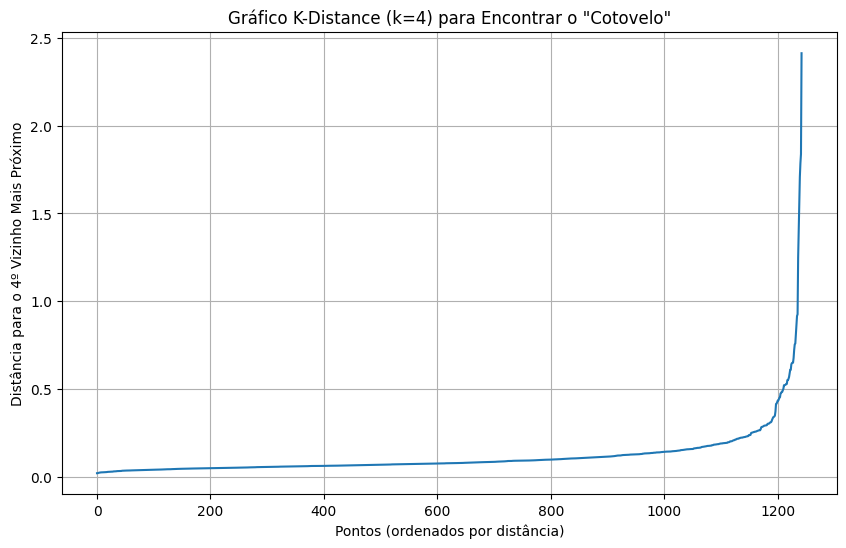

Analise o gráfico acima e procure o 'ponto de inflexão' (cotovelo). O valor no eixo Y nesse ponto é um bom candidato para 'eps'.

[4/7] Aplicando o algoritmo DBSCAN...
Clusterização DBSCAN concluída.

[5/7] Analisando os clusters para interpretação...

Análise dos Clusters Encontrados (Médias das Features):


,retorno_total,pavio_contra
cluster,,
0,-0.000192,0.001459
1,0.009167,0.001839



Análise dos Outliers (Ruído - Cluster -1):


,retorno_total,pavio_contra
0,-0.000729,0.004228


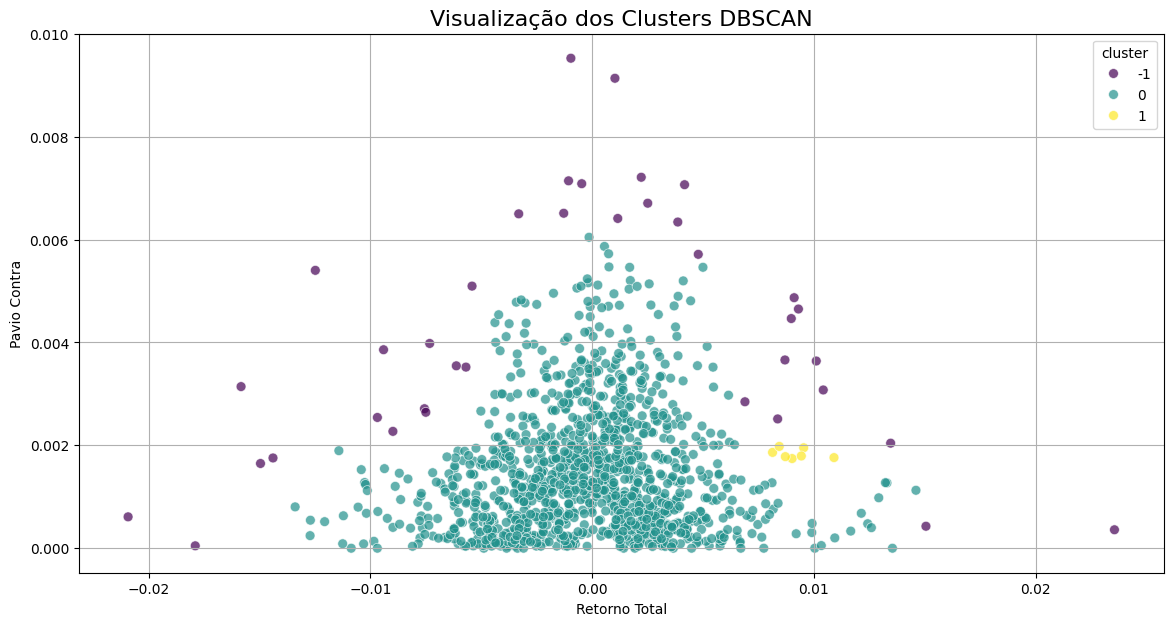


[6/7] Mapeando os clusters para os labels finais...
Mapeamento dinâmico gerado:
{np.int64(0): 'Venda', np.int64(1): 'Compra', -1: 'Indefinido'}


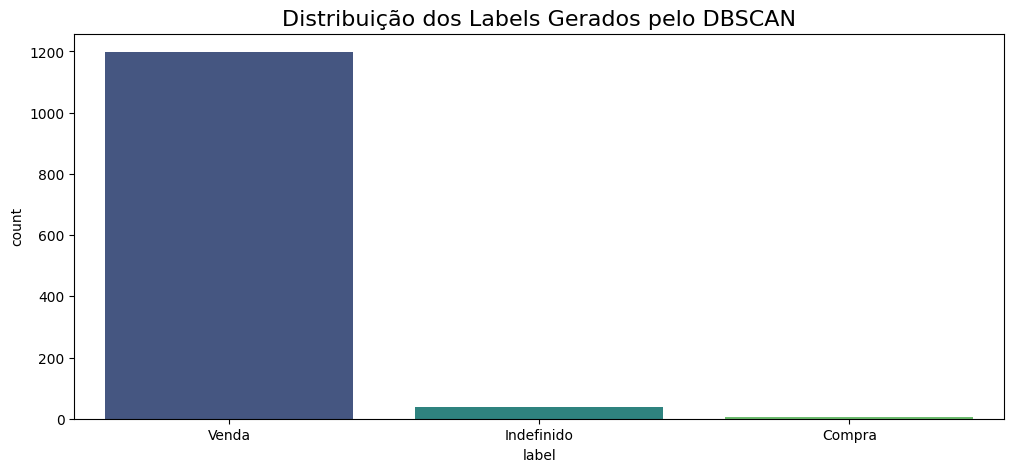


[7/7] Salvando o DataFrame com os labels no arquivo: dados_com_labels_DBSCAN.csv

Processo concluído com sucesso!
Amostra do arquivo final gerado:


,label,cluster,retorno_total,pavio_contra
datetime,,,,
2021-02-22,Venda,0,0.003874,0.004898
2021-02-23,Venda,0,-0.005247,0.001049
2021-02-24,Venda,0,-0.003508,0.001299
2021-02-25,Venda,0,0.001721,0.002366
2021-02-26,Venda,0,-0.010263,0.001277


In [6]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# MODIFICAÇÃO: Importa o DBSCAN e o NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN_9h-12h.csv'
NOME_ARQUIVO_SAIDA = 'dados_com_labels_DBSCAN.csv' # Nome do arquivo de saída alterado

print("--- FASE 1: GERAÇÃO DE LABELS COM CLUSTERIZAÇÃO DBSCAN ---")

# --- PASSO 1: LEITURA E PREPARAÇÃO DOS DADOS ---
print(f"\n[1/7] Lendo o arquivo de dados: {NOME_ARQUIVO_ENTRADA}")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')
    print("Arquivo lido com sucesso.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# --- PASSO 2: CÁLCULO DAS FEATURES PARA LABELING (JANELA 11:00-11:55) ---
print("\n[2/7] Calculando as features descritivas para a janela das 11:00-11:55...")
df_janela_alvo = df_completo.between_time('11:00', '11:55')
daily_agg_features = df_janela_alvo.resample('D').agg(
    Abertura_11h=('Abertura', 'first'),
    Fechamento_11h55=('Fechamento', 'last'),
    Maxima_periodo=('Maxima', 'max'),
    Minima_periodo=('Minima', 'min'),
    Volume_Real_Medio=('Volume_Real', 'mean')
)
daily_agg_features.dropna(inplace=True)

# Engenharia de Features (mantida igual)
daily_agg_features['retorno_total'] = (daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']) / daily_agg_features['Abertura_11h']
daily_agg_features['volatilidade_total'] = (daily_agg_features['Maxima_periodo'] - daily_agg_features['Minima_periodo']) / daily_agg_features['Abertura_11h']
daily_agg_features['posicao_fechamento'] = (daily_agg_features['Fechamento_11h55'] - daily_agg_features['Minima_periodo']) / (daily_agg_features['Maxima_periodo'] - daily_agg_features['Minima_periodo'])
daily_agg_features['drawdown_maximo'] = (daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']) / daily_agg_features['Abertura_11h']
daily_agg_features['runup_maximo'] = (daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']) / daily_agg_features['Abertura_11h']
daily_total_volume = df_completo['Volume_Real'].resample('D').sum()
daily_total_volume_rolling_avg = daily_total_volume.rolling(window=20, min_periods=1).mean()
daily_agg_features['volume_medio_normalizado'] = daily_agg_features['Volume_Real_Medio'] / daily_total_volume_rolling_avg
daily_agg_features.replace([np.inf, -np.inf], np.nan, inplace=True)
daily_agg_features.dropna(inplace=True)
condicao_alta = daily_agg_features['retorno_total'] >= 0
valor_se_alta = daily_agg_features['drawdown_maximo']
valor_se_baixa = daily_agg_features['runup_maximo']
daily_agg_features['pavio_contra'] = np.where(condicao_alta, valor_se_alta, valor_se_baixa)

features_para_cluster = ['retorno_total', 'pavio_contra']
print(f"{len(daily_agg_features)} dias de dados preparados para clusterização.")

# --- PASSO 3: PADRONIZAÇÃO E BUSCA DO EPS PARA DBSCAN ---
print("\n[3/7] Padronizando features e buscando o 'eps' ideal para DBSCAN...")
scaler = StandardScaler()
features_padronizadas = scaler.fit_transform(daily_agg_features.loc[:, features_para_cluster])

# MODIFICAÇÃO: Lógica para encontrar o 'eps' ideal
# k = 2 * número_de_dimensões. Como temos 2 features, k = 4.
k = 4
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(features_padronizadas)
distances, indices = neighbors_fit.kneighbors(features_padronizadas)
k_distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f'Gráfico K-Distance (k={k}) para Encontrar o "Cotovelo"')
plt.xlabel("Pontos (ordenados por distância)")
plt.ylabel(f"Distância para o {k}º Vizinho Mais Próximo")
plt.grid(True)
plt.show()
print("Analise o gráfico acima e procure o 'ponto de inflexão' (cotovelo). O valor no eixo Y nesse ponto é um bom candidato para 'eps'.")

# --- PASSO 4: APLICAÇÃO DO DBSCAN ---
print("\n[4/7] Aplicando o algoritmo DBSCAN...")

# #############################################################################
# AÇÃO NECESSÁRIA: AJUSTE O VALOR DE 'eps' ABAIXO COM BASE NO GRÁFICO GERADO
# #############################################################################
valor_eps_sugerido = 0.4 # <-- MUDE ESTE VALOR com base no cotovelo do gráfico

dbscan = DBSCAN(eps=valor_eps_sugerido, min_samples=k)
daily_agg_features.loc[:, 'cluster'] = dbscan.fit_predict(features_padronizadas)
print("Clusterização DBSCAN concluída.")

# --- PASSO 5: ANÁLISE E INTERPRETAÇÃO DOS CLUSTERS ---
print("\n[5/7] Analisando os clusters para interpretação...")
# O cluster -1 representa "ruído" (outliers). Vamos analisá-lo separadamente.
cluster_analysis = daily_agg_features[daily_agg_features['cluster'] != -1].groupby('cluster')[features_para_cluster].mean().sort_values('retorno_total')
outliers_analysis = daily_agg_features[daily_agg_features['cluster'] == -1][features_para_cluster].mean()

print("\nAnálise dos Clusters Encontrados (Médias das Features):")
display(cluster_analysis)
print("\nAnálise dos Outliers (Ruído - Cluster -1):")
display(outliers_analysis.to_frame().T)

# Visualização dos clusters
plt.figure(figsize=(14, 7))
sns.scatterplot(data=daily_agg_features, x='retorno_total', y='pavio_contra', hue='cluster', palette='viridis', s=50, alpha=0.7)
plt.title('Visualização dos Clusters DBSCAN', fontsize=16)
plt.xlabel('Retorno Total')
plt.ylabel('Pavio Contra')
plt.grid(True)
plt.show()

# --- PASSO 6: MAPEAMENTO DOS CLUSTERS PARA LABELS ---
print("\n[6/7] Mapeando os clusters para os labels finais...")

# MODIFICAÇÃO: Lógica de mapeamento dinâmica para DBSCAN
if not cluster_analysis.empty:
    # Se encontrou clusters, mapeia com base no retorno
    num_clusters_encontrados = len(cluster_analysis)
    if num_clusters_encontrados == 1:
        label_map = {cluster_analysis.index[0]: 'Lateral'}
    elif num_clusters_encontrados == 2:
        label_map = {
            cluster_analysis.index[0]: 'Venda',
            cluster_analysis.index[1]: 'Compra'
        }
    else: # 3 ou mais clusters
        label_map = {
            cluster_analysis.index[0]: 'Venda',
            cluster_analysis.index[-1]: 'Compra' # O último cluster (maior retorno)
        }
        # Todos os clusters intermediários serão 'Lateral'
        for i in range(1, num_clusters_encontrados - 1):
            label_map[cluster_analysis.index[i]] = 'Lateral'
    
    # O cluster -1 (ruído) será mapeado como 'Indefinido' ou 'Lateral'
    label_map[-1] = 'Indefinido'
    
    print("Mapeamento dinâmico gerado:")
    print(label_map)
    
    daily_agg_features.loc[:, 'label'] = daily_agg_features['cluster'].map(label_map)
else:
    print("Nenhum cluster principal encontrado. Todos os pontos foram classificados como ruído.")
    daily_agg_features.loc[:, 'label'] = 'Indefinido'

# Gráfico de contagem
plt.figure(figsize=(12, 5))
sns.countplot(data=daily_agg_features, x='label', order=daily_agg_features['label'].value_counts().index, palette='viridis', hue='label', legend=False)
plt.title('Distribuição dos Labels Gerados pelo DBSCAN', fontsize=16)
plt.show()

# --- PASSO 7: SALVAR O RESULTADO FINAL ---
print(f"\n[7/7] Salvando o DataFrame com os labels no arquivo: {NOME_ARQUIVO_SAIDA}")
df_final_com_labels = daily_agg_features[['label', 'cluster'] + features_para_cluster].copy()
df_final_com_labels.to_csv(NOME_ARQUIVO_SAIDA, sep=';')
print("\nProcesso concluído com sucesso!")
print("Amostra do arquivo final gerado:")
display(df_final_com_labels.head())


## Criando labels atraves da heurística
O código a baixo cria três labels (compra venda e lateral) usando apenas as seguintes features;
* retorno_total: Fechamento_11:55 - Abertura_11:00.
* pavio_contra:
  * quando retorno_total > 0 = Abertura_11 - Minima_periodo.
  * quando retorno_total < 0 = Maxima_periodo - Abertura_11.
  
1. Compra: quando o retorno total é positivo e maior que 50 pontos, e o pavio_contra é menor que 300 pontoas.
2. Venda: quando o retorno total é negativo e maior que 50 pontos, e o pavio_contra é menor que 300 pontoas.
3. Lateral demais casos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN$N_M30_BRUTO.csv'
NOME_ARQUIVO_SAIDA = 'labels.csv'

# --- ETAPA 0: LEITURA E AGREGAÇÃO DOS DADOS ---
print(f"\n[ETAPA 0/5] Lendo e agregando os dados de '{NOME_ARQUIVO_ENTRADA}'...")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')
    
    # Agrupa por dia para criar o DataFrame 'daily_agg_features'
    # A janela de interesse é das 11:00 às 11:55
    df_janela_alvo = df_completo.between_time('11:00', '11:55')
    daily_agg_features = df_janela_alvo.resample('D').agg(   #  Agrupa todos os seus candles de 5 minutos por dia (.resample('D')).
        Abertura_11h=('Abertura', 'first'),  # Crie uma nova coluna chamada Abertura_11h. Para cada grupo diário, encontre a coluna Abertura e pegue o primeiro (first) valor que você encontrar. (Que será, por definição, a abertura do primeiro candle daquele dia)."
        Fechamento_11h55=('Fechamento', 'last'),
        Maxima_periodo=('Maxima', 'max'),   # Crie uma nova coluna chamada Maxima_periodo. Para cada grupo diário, encontre a coluna Maxima e calcule o valor máximo (max) entre todos os candles daquele dia.
        Minima_periodo=('Minima', 'min')
    )

    # O 'D' significa "dia calendário". Isso significa que o pandas cria uma linha para todos os dias no seu intervalo de tempo, incluindo sábados, domingos e feriados.
    # Remove dias sem pregão (fins de semana, feriados)
    daily_agg_features.dropna(inplace=True)
    
    print(f"DataFrame 'daily_agg_features' criado com {len(daily_agg_features)} dias de pregão.")

except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado. Verifique o nome e o caminho.")
    exit()
except Exception as e:
    print(f"Ocorreu um erro inesperado ao ler ou agregar os dados: {e}")
    exit()


# --- PASSO 1: CALCULAR AS FEATURES EM PONTOS ---
print("\n[ETAPA 1/5] Calculando as features em pontos absolutos...")

daily_agg_features['retorno_total'] = (
    daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']
)

condicao_alta = daily_agg_features['retorno_total'] >= 0
pavio_inferior_pontos = daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']
pavio_superior_pontos = daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']
daily_agg_features['pavio_contra'] = np.where(
    condicao_alta, 
    pavio_inferior_pontos, 
    pavio_superior_pontos
)
print("Features em pontos calculadas com sucesso.")


# --- PASSO 2: DEFINIR AS NOVAS CONDIÇÕES E LABELS ---
print("\n[ETAPA 2/5] Definindo as novas condições (Compra/Venda/Lateral)...")

condicoes = [
    # 1. Compra: Retorno > 50 pontos E Risco < 300 pontos
    (daily_agg_features['retorno_total'] > 50) & (daily_agg_features['pavio_contra'] < 250),
    
    # 2. Venda: Retorno < -50 pontos E Risco < 300 pontos
    (daily_agg_features['retorno_total'] < -50) & (daily_agg_features['pavio_contra'] < 250),
]

# Lista de labels correspondente
labels = [
    'Compra',
    'Venda',
]
print("Condições e labels definidos.")


# --- PASSO 3: APLICAR AS REGRAS PARA CRIAR A COLUNA 'label' ---
print("\n[ETAPA 3/5] Aplicando as regras para gerar a coluna 'label'...")

# O 'default' agora é 'Lateral' para qualquer dia que não atenda às condições de Compra ou Venda.
daily_agg_features['label'] = np.select(condicoes, labels, default='Lateral')
print("Coluna 'label' gerada com sucesso.")


# --- PASSO 4: ANÁLISE DA DISTRIBUIÇÃO DOS LABELS ---
print("\n[ETAPA 4/5] Analisando a distribuição dos labels gerados...")

label_counts = daily_agg_features['label'].value_counts()
print("Distribuição dos Labels:")
print(label_counts)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=daily_agg_features, 
    x='label', # Usando x agora que os nomes são curtos
    order=label_counts.index,
    palette='viridis',
    hue='label',
    legend=False
)
plt.title('Distribuição dos Labels Gerados (Compra/Venda/Lateral)', fontsize=16)
plt.ylabel('Quantidade de Dias')
plt.xlabel('Label')
plt.show()


# --- PASSO 5: SALVAR E EXIBIR O RESULTADO ---
print("\n[ETAPA 5/5] Salvando e exibindo o resultado final...")

# Seleciona as colunas mais relevantes para salvar e analisar
df_final_com_labels = daily_agg_features[[
    'retorno_total', 
    'pavio_contra', 
    'label'
]].copy()

# Salva o arquivo final
df_final_com_labels.to_csv(NOME_ARQUIVO_SAIDA, sep=';')
print(f"Arquivo '{NOME_ARQUIVO_SAIDA}' salvo com sucesso.")

print("\nAmostra do DataFrame com os labels finais:")
display(df_final_com_labels.head(10))


## Engenharia de Features e Achatamento
O código a seguir faz o seguinte:

1. abre o dataframe WIN$N_M5_5_ANOS_BRUTO.csv.
2. Agrupa por dia para criar o DataFrame 'daily_agg_features'. A janela de interesse é das 11:00 às 11:55
3. usa as velas das 11:00 até 11:55 para criar variáveis que serão usadas para criar as features, as features serão usada para criar as label (compra, venda, lateral).
4. CALCULAR AS FEATURES EM PONTOS.
5. DEFINIR AS NOVAS CONDIÇÕES E LABELS
6. APLICAR AS REGRAS PARA CRIAR A COLUNA 'label'
7. ANÁLISE DA DISTRIBUIÇÃO DOS LABELS
8. EXIBIR O RESULTADO
9. Seleciona as colunas mais relevantes para salvar e analisar
10. A partir de df_completo, calcula as features de engenharia para todos os candles:
11. Achatando os dados com a ordem correta (por candle) apenas do horário das 09:00 às 11:55.
12. Codificando labels (One-Hot) 
13. Juntar as features de entrada (`X`) e os labels codificados (`Y`) em um único DataFrame.
14. Salvando o dataset bruto final (dataset_bruto.csv)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("Biblioteca TA-Lib não encontrada. Usando implementações alternativas.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN$N_M1_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_final.csv'

# --- FASE 1: GERAÇÃO DE LABELS (LÓGICA MANTIDA) ---
print(f"\n--- FASE 1: GERAÇÃO DE LABELS ---")
print(f"\n[ETAPA 1/5] Lendo e agregando os dados de '{NOME_ARQUIVO_ENTRADA}'...")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')

    # Lista de colunas que devem ser numéricas
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']

    # Força a conversão para tipo numérico.
    # 'errors='coerce'' transforma qualquer valor que não possa ser convertido em NaN (Not a Number).
    for col in colunas_numericas:
        df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce')
        
    # Remove qualquer linha que possa ter gerado um NaN durante a conversão
    # Isso garante que só trabalharemos com dados 100% numéricos e válidos.
    df_completo.dropna(subset=colunas_numericas, inplace=True)
    
    print("Conversão para tipo numérico concluída. Tipos de dados das colunas:")
    print(df_completo[colunas_numericas].dtypes)
    
    df_janela_alvo = df_completo.between_time('11:00', '11:59')
    daily_agg_features = df_janela_alvo.resample('D').agg(
        Abertura_11h=('Abertura', 'first'),
        Fechamento_11h55=('Fechamento', 'last'),
        Maxima_periodo=('Maxima', 'max'),
        Minima_periodo=('Minima', 'min')
    )
    daily_agg_features.dropna(inplace=True)
    print(f"DataFrame 'daily_agg_features' para labels criado com {len(daily_agg_features)} dias.")
except Exception as e:
    print(f"ERRO ao ler ou agregar os dados: {e}")
    exit()

print("\n[ETAPA 2/5] Calculando features para os labels...")
daily_agg_features['retorno_total'] = daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']
condicao_alta = daily_agg_features['retorno_total'] >= 0
pavio_inferior_pontos = daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']
pavio_superior_pontos = daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']
daily_agg_features['pavio_contra'] = np.where(condicao_alta, pavio_inferior_pontos, pavio_superior_pontos)

print("\n[ETAPA 3/5] Aplicando regras para gerar a coluna 'label'...")
condicoes = [
    (daily_agg_features['retorno_total'] > 50) & (daily_agg_features['pavio_contra'] < 250),
    (daily_agg_features['retorno_total'] < -50) & (daily_agg_features['pavio_contra'] < 250),
]
labels = ['Compra', 'Venda']
daily_agg_features['label'] = np.select(condicoes, labels, default='Lateral')

print("\n[ETAPA 4/5] Analisando a distribuição dos labels gerados...")
print(daily_agg_features['label'].value_counts())
plt.figure(figsize=(10, 5))
sns.countplot(data=daily_agg_features, x='label', order=daily_agg_features['label'].value_counts().index, palette='viridis', hue='label', legend=False)
plt.title('Distribuição dos Labels Gerados', fontsize=16)
plt.show()
print("\n--- FASE 1 CONCLUÍDA: LABELS GERADOS EM MEMÓRIA ---")


# --- FASE 2: GERAÇÃO DAS FEATURES DE ENTRADA (X) ---
print("\n--- FASE 2: GERAÇÃO DAS FEATURES DE ENTRADA (X) ---")

# --- ETAPA 6/9: CÁLCULO DAS FEATURES POR CANDLE ---
print("\n[ETAPA 6/9] Calculando as 11 features para cada candle de 5 minutos...")
df_completo.replace(0, 1e-9, inplace=True)
df_completo['mag_decisao'] = abs(df_completo['Fechamento'] - df_completo['Abertura']) / df_completo['Abertura']
df_completo['mov_direcional'] = np.sign(df_completo['Fechamento'] - df_completo['Abertura'])
df_completo['pavio_superior'] = (df_completo['Maxima'] - df_completo[['Abertura', 'Fechamento']].max(axis=1)) / df_completo['Abertura']
df_completo['pavio_inferior'] = (df_completo[['Abertura', 'Fechamento']].min(axis=1) - df_completo['Minima']) / df_completo['Abertura']
df_completo['range_candle'] = (df_completo['Maxima'] - df_completo['Minima']) / df_completo['Abertura']
vol_real_baseline = df_completo['Volume_Real'].rolling(window=50, min_periods=1).mean()
vol_tick_baseline = df_completo['Volume_Tick'].rolling(window=50, min_periods=1).mean()
df_completo['volume_real_norm'] = df_completo['Volume_Real'] / vol_real_baseline
df_completo['volume_tick_norm'] = df_completo['Volume_Tick'] / vol_tick_baseline
df_completo['tamanho_medio_ordem'] = df_completo['Volume_Real'] / df_completo['Volume_Tick']
ma_3 = df_completo['Fechamento'].rolling(window=3).mean()
ma_9 = df_completo['Fechamento'].rolling(window=9).mean()
df_completo['diferenca_MA'] = (ma_3 - ma_9) / df_completo['Fechamento']
if TALIB_INSTALLED:
    df_completo['RSI'] = talib.RSI(df_completo['Fechamento'], timeperiod=14)
    macd, macdsignal, _ = talib.MACD(df_completo['Fechamento'], fastperiod=12, slowperiod=26, signalperiod=9)
    df_completo['MACD'] = macd - macdsignal
else:
    delta = df_completo['Fechamento'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_completo['RSI'] = 100 - (100 / (1 + rs))
    ema_fast = df_completo['Fechamento'].ewm(span=12, adjust=False).mean()
    ema_slow = df_completo['Fechamento'].ewm(span=26, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df_completo['MACD'] = macd_line - signal_line
df_completo.dropna(inplace=True)
print("Features de entrada calculadas com sucesso.")
# --- ETAPA 7/9: "ACHATAR" (FLATTEN) AS FEATURES COM A ORDEM CORRETA ---
print("\n[ETAPA 7/9] Achatando os dados com a ordem correta (por candle)...")
'''
features_por_candle = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem',
    'diferenca_MA', 'RSI', 'MACD'
]
'''
features_por_candle = [
    'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'tamanho_medio_ordem',
    'diferenca_MA']

df_janela_entrada = df_completo.between_time('09:00', '10:59').copy()
df_janela_entrada['dia'] = df_janela_entrada.index.date
dias_completos = df_janela_entrada['dia'].value_counts()
#print(f"dias completos {dias_completos}")
dias_validos = dias_completos[dias_completos == 120].index
df_janela_valida = df_janela_entrada[df_janela_entrada['dia'].isin(dias_validos)].copy()

# --- LÓGICA DE REORDENAÇÃO E ACHATAMENTO ---
# 1. Agrupa os dados por dia
grouped_by_day = df_janela_valida.groupby('dia')

# 2. Para cada dia, achata as features dos 24 candles em uma única linha
daily_flattened_data = []
for day, group in grouped_by_day:
    # Pega apenas as colunas de features e transforma em um array 1D
    flattened_features = group[features_por_candle].values.flatten()
    daily_flattened_data.append(flattened_features)

# 3. Cria os nomes das colunas na ordem correta
colunas_ordenadas = []
for i in range(1, 121): # 120 candles
    for feature in features_por_candle:
        colunas_ordenadas.append(f'{feature}_c{i}')

# 4. Cria o DataFrame final de features
df_features_X = pd.DataFrame(
    daily_flattened_data,
    index=grouped_by_day.groups.keys(), # Usa os dias como índice
    columns=colunas_ordenadas
)
df_features_X.index.name = 'datetime'
df_features_X.index = pd.to_datetime(df_features_X.index)
print("DataFrame de features de entrada (X) achatado com a ordem correta.")

# --- ETAPA 8/9: CODIFICAÇÃO ONE-HOT E JUNÇÃO DOS DADOS ---
print("\n[ETAPA 8/9] Codificando labels (One-Hot) e juntando os DataFrames...")
df_labels_Y = daily_agg_features[['label']]
df_labels_one_hot = pd.get_dummies(df_labels_Y['label'], prefix='label')
df_dataset_bruto = df_features_X.merge(df_labels_one_hot, left_index=True, right_index=True, how='inner').copy()
print("Junção de features e labels codificados concluída.")

# --- ETAPA 9/9: SALVAR E EXIBIR O DATASET BRUTO FINAL ---
print(f"\n[ETAPA 9/9] Salvando o dataset bruto final em '{NOME_ARQUIVO_SAIDA_FINAL}'...")
df_dataset_bruto.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')

print(f"\n--- PROCESSAMENTO COMPLETO ---")
print(f"Dimensões do DataFrame final (dias, features + labels): {df_dataset_bruto.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_bruto)}")

print("\nAmostra do dataset bruto final (features do primeiro e segundo candle, e labels):")
# Mostra as primeiras 11 colunas (candle 1), as próximas 11 (candle 2) e as 3 últimas (labels)
#colunas_amostra = list(df_dataset_bruto.columns[0:11]) + list(df_dataset_bruto.columns[11:22]) + list(df_dataset_bruto.columns[-3:])
#display(df_dataset_bruto[colunas_amostra].head())

# Ajuste nas opções de exibição do Pandas para mostrar mais colunas
# Isso ajuda a evitar que o Jupyter esconda colunas com "..."
pd.set_option('display.max_columns', 300) # Define um limite alto para o número de colunas a serem exibidas
display(df_dataset_bruto.head())
# Opcional: Restaurar as opções de exibição para o padrão depois de usar
pd.reset_option('display.max_columns')


Biblioteca TA-Lib não encontrada. Usando implementações alternativas.

 Lendo e agregando os dados de 'WIN$N_M30_BRUTO.csv'...
Conversão para tipo numérico concluída. Tipos de dados das colunas:
Abertura       int64
Maxima         int64
Minima         int64
Fechamento     int64
Volume_Real    int64
Volume_Tick    int64
dtype: object
 Calculando Feature de Contexto entre dias...
DataFrame 'daily_agg_features' para labels criado com 1243 dias.

 Calculando features para os labels...

Analisando a distribuição dos labels gerados...
label
Venda      444
Compra     401
Lateral    398
Name: count, dtype: int64


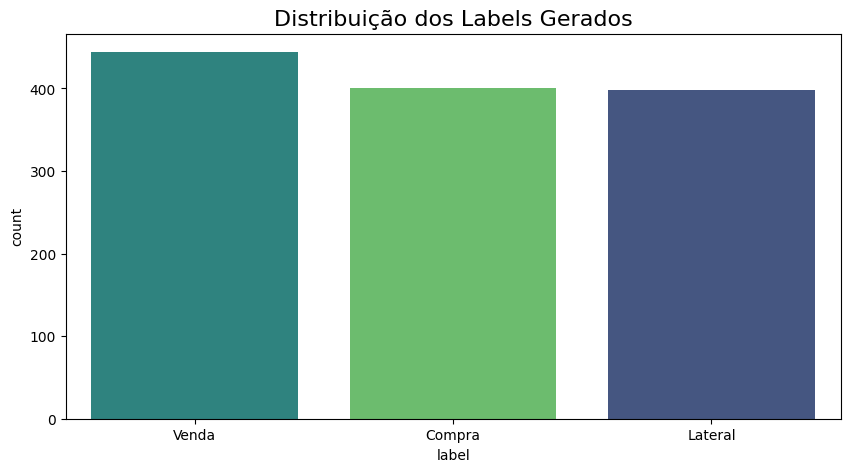


--- LABELS GERADOS EM MEMÓRIA ---

--- GERAÇÃO DAS FEATURES DE ENTRADA (X) ---

 Calculando as features para cada candle de 5 minutos...
Features de entrada calculadas com sucesso.

 Achatando os dados com a ordem correta (por candle)...

Codificando labels (One-Hot) e juntando os DataFrames...
Junção de features e labels codificados concluída.

 Salvando o dataset bruto final em 'dataset_final.csv'...

--- PROCESSAMENTO COMPLETO ---
Dimensões do DataFrame final (dias, features + labels): (1222, 42)
Total de dias válidos no dataset final: 1222

Amostra do dataset bruto final (features do primeiro e segundo candle, e labels):


,gap,range_dia_anterior,atr_dia_anterior,posicao_range_d1,distancia_mm20,mes_sin,mes_cos,dia_mes_sin,dia_mes_cos,dia_semana_sin,dia_semana_cos,mov_direcional_c1,pavio_superior_c1,pavio_inferior_c1,range_candle_c1,volume_real_norm_c1,tamanho_medio_ordem_c1,diferenca_MA_c1,mov_direcional_c2,pavio_superior_c2,pavio_inferior_c2,range_candle_c2,volume_real_norm_c2,tamanho_medio_ordem_c2,diferenca_MA_c2,mov_direcional_c3,pavio_superior_c3,pavio_inferior_c3,range_candle_c3,volume_real_norm_c3,tamanho_medio_ordem_c3,diferenca_MA_c3,mov_direcional_c4,pavio_superior_c4,pavio_inferior_c4,range_candle_c4,volume_real_norm_c4,tamanho_medio_ordem_c4,diferenca_MA_c4,label_Compra,label_Lateral,label_Venda
2021-03-22,0.002417,0.016361,3367.857143,0.761273,0.024693,1.0,6.123234e-17,-0.968077,-0.250653,0.000000,1.000000,-1.0,0.000215,0.000474,0.006629,0.680209,2.768370,-0.002151,-1.0,0.000130,0.000606,0.003031,0.657600,3.204094,-0.003815,1.0,0.001953,0.002431,0.004427,1.419525,3.246519,-0.004909,-1.0,0.000651,0.001606,0.005815,1.573815,3.404403,-0.005575,False,False,True
2021-03-23,-0.008577,0.021911,3171.071429,0.314342,0.008056,1.0,6.123234e-17,-0.998717,-0.050649,0.781831,0.623490,-1.0,0.001923,0.000961,0.005462,0.961424,2.970219,-0.000652,1.0,0.001928,0.000832,0.004731,1.107536,3.068230,-0.002735,-1.0,0.002536,0.003279,0.005859,1.520687,3.255441,-0.005456,1.0,0.002754,0.001793,0.005640,1.690114,3.282855,-0.003664,False,True,False
2021-03-24,0.003401,0.023639,2991.071429,0.207024,0.001634,1.0,6.123234e-17,-0.988468,0.151428,0.974928,-0.222521,1.0,0.003213,0.000264,0.005987,0.890435,3.017107,-0.003401,-1.0,0.000307,0.003249,0.004128,1.107522,3.406667,-0.001684,1.0,0.002548,0.002417,0.005097,1.470966,3.490152,0.000810,1.0,0.002197,0.001010,0.004964,1.619131,3.545568,0.001779,False,True,False
2021-03-25,0.000313,0.029185,2963.571429,0.055807,-0.012119,1.0,6.123234e-17,-0.937752,0.347305,0.433884,-0.900969,-1.0,0.004382,0.004293,0.010284,1.319367,2.890863,-0.010669,1.0,0.000941,0.003270,0.004792,0.905599,2.955605,-0.008744,1.0,0.000403,0.007699,0.011370,1.453059,3.160392,-0.005409,1.0,0.001740,0.003525,0.006559,1.746669,3.417162,-0.001624,False,True,False
2021-03-26,0.001938,0.029378,2968.214286,0.881279,0.004127,1.0,6.123234e-17,-0.848644,0.528964,-0.433884,-0.900969,-1.0,0.000000,0.002022,0.005100,0.695681,2.750715,-0.000323,1.0,0.001191,0.001411,0.005027,0.819436,3.089323,-0.001119,1.0,0.000220,0.000396,0.011658,1.546965,3.408958,0.001470,1.0,0.001305,0.000218,0.004264,1.329979,3.584216,0.004961,False,True,False


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("Biblioteca TA-Lib não encontrada. Usando implementações alternativas.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'WIN$N_M30_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_final.csv'

abertura_features = '9:00'
fechamento_features = '10:30'
abertura_labels = '11:00'
fechamento_labels = '11:30'
quantidade_velas = 4

# --- FASE 1: GERAÇÃO DE LABELS, e feature gap ---
print(f"\n Lendo e agregando os dados de '{NOME_ARQUIVO_ENTRADA}'...")
try:
    df_completo = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')

    # Lista de colunas que devem ser numéricas
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']

    # Força a conversão para tipo numérico.
    # 'errors='coerce'' transforma qualquer valor que não possa ser convertido em NaN (Not a Number).
    for col in colunas_numericas:
        df_completo[col] = pd.to_numeric(df_completo[col], errors='coerce')
        
    # Remove qualquer linha que possa ter gerado um NaN durante a conversão
    # Isso garante que só trabalharemos com dados 100% numéricos e válidos.
    df_completo.dropna(subset=colunas_numericas, inplace=True)
    
    print("Conversão para tipo numérico concluída. Tipos de dados das colunas:")
    print(df_completo[colunas_numericas].dtypes)

    # --- CÁLCULO DAS FEATURES DE CONTEXTO DIÁRIAS (Gap, Volatilidade, Posição)---
    print(" Calculando Feature de Contexto entre dias...")
    # 1. Agrega os dados brutos por dia para obter OHLC diário
    df_diario_contexto = df_completo.resample('D').agg(
       Abertura=('Abertura', 'first'), Maxima=('Maxima', 'max'),
       Minima=('Minima', 'min'), Fechamento=('Fechamento', 'last')
    ).dropna()

    # 2. Calcula o True Range para o ATR
    high_low = df_diario_contexto['Maxima'] - df_diario_contexto['Minima']
    high_close = np.abs(df_diario_contexto['Maxima'] - df_diario_contexto['Fechamento'].shift(1))
    low_close = np.abs(df_diario_contexto['Minima'] - df_diario_contexto['Fechamento'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)

    # 3. Calcula as features baseadas no dia anterior
    df_diario_contexto['range_dia_anterior'] = (df_diario_contexto['Maxima'].shift(1) - df_diario_contexto['Minima'].shift(1)) / df_diario_contexto['Abertura'].shift(1)
    df_diario_contexto['atr_dia_anterior'] = true_range.rolling(window=14, min_periods=1).mean().shift(1)
    
    # 4. Calcula a Média Móvel de 20 dias
    df_diario_contexto['mm20_diaria'] = df_diario_contexto['Fechamento'].rolling(window=20).mean()

    # 5. Calcula as features de relação inter-dia (que usam dados de hoje e de ontem)
    df_diario_contexto['gap'] = (df_diario_contexto['Abertura'] - df_diario_contexto['Fechamento'].shift(1)) / df_diario_contexto['Fechamento'].shift(1)
    df_diario_contexto['posicao_range_d1'] = (df_diario_contexto['Abertura'] - df_diario_contexto['Minima'].shift(1)) / (df_diario_contexto['Maxima'].shift(1) - df_diario_contexto['Minima'].shift(1))
    df_diario_contexto['distancia_mm20'] = (df_diario_contexto['Abertura'] - df_diario_contexto['mm20_diaria'].shift(1)) / df_diario_contexto['mm20_diaria'].shift(1)

    # 6. Seleciona as colunas de features de contexto e remove dias com NaN
    features_contexto_diarias = [
        'gap', 'range_dia_anterior', 'atr_dia_anterior', 
        'posicao_range_d1', 'distancia_mm20'
    ]
    df_diario_contexto.replace([np.inf, -np.inf], np.nan, inplace=True) # Trata possíveis divisões por zero
    df_diario_contexto.dropna(subset=features_contexto_diarias, inplace=True)  

    df_janela_alvo = df_completo.between_time(abertura_labels, fechamento_labels)
    daily_agg_features = df_janela_alvo.resample('D').agg(
        Abertura_11h=('Abertura', 'first'),
        Fechamento_11h55=('Fechamento', 'last'),
        Maxima_periodo=('Maxima', 'max'),
        Minima_periodo=('Minima', 'min')
    )
    daily_agg_features.dropna(inplace=True)
    print(f"DataFrame 'daily_agg_features' para labels criado com {len(daily_agg_features)} dias.")
except Exception as e:
    print(f"ERRO ao ler ou agregar os dados: {e}")
    exit()

print("\n Calculando features para os labels...")
daily_agg_features['retorno_total'] = daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']
condicao_alta = daily_agg_features['retorno_total'] >= 0
pavio_inferior_pontos = daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']
pavio_superior_pontos = daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']
daily_agg_features['pavio_contra'] = np.where(condicao_alta, pavio_inferior_pontos, pavio_superior_pontos)

#  Aplicando regras para gerar a coluna 'label'
condicoes = [
    (daily_agg_features['retorno_total'] > 50) & (daily_agg_features['pavio_contra'] < 250),
    (daily_agg_features['retorno_total'] < -50) & (daily_agg_features['pavio_contra'] < 250),
]
labels = ['Compra', 'Venda']
daily_agg_features['label'] = np.select(condicoes, labels, default='Lateral')

print("\nAnalisando a distribuição dos labels gerados...")
print(daily_agg_features['label'].value_counts())
plt.figure(figsize=(10, 5))
sns.countplot(data=daily_agg_features, x='label', order=daily_agg_features['label'].value_counts().index, palette='viridis', hue='label', legend=False)
plt.title('Distribuição dos Labels Gerados', fontsize=16)
plt.show()
print("\n--- LABELS GERADOS EM MEMÓRIA ---")

# --- FASE 2: GERAÇÃO DAS FEATURES DE ENTRADA (X) ---
print("\n--- GERAÇÃO DAS FEATURES DE ENTRADA (X) ---")

# --- ETAPA 3: CÁLCULO DAS FEATURES POR CANDLE ---
print("\n Calculando as features para cada candle de 5 minutos...")
df_completo.replace(0, 1e-9, inplace=True)
df_completo['mag_decisao'] = abs(df_completo['Fechamento'] - df_completo['Abertura']) / df_completo['Abertura']
df_completo['mov_direcional'] = np.sign(df_completo['Fechamento'] - df_completo['Abertura'])
df_completo['pavio_superior'] = (df_completo['Maxima'] - df_completo[['Abertura', 'Fechamento']].max(axis=1)) / df_completo['Abertura']
df_completo['pavio_inferior'] = (df_completo[['Abertura', 'Fechamento']].min(axis=1) - df_completo['Minima']) / df_completo['Abertura']
df_completo['range_candle'] = (df_completo['Maxima'] - df_completo['Minima']) / df_completo['Abertura']
vol_real_baseline = df_completo['Volume_Real'].rolling(window=50, min_periods=1).mean()
vol_tick_baseline = df_completo['Volume_Tick'].rolling(window=50, min_periods=1).mean()
df_completo['volume_real_norm'] = df_completo['Volume_Real'] / vol_real_baseline
df_completo['volume_tick_norm'] = df_completo['Volume_Tick'] / vol_tick_baseline
df_completo['tamanho_medio_ordem'] = df_completo['Volume_Real'] / df_completo['Volume_Tick']
ma_3 = df_completo['Fechamento'].rolling(window=3).mean()
ma_9 = df_completo['Fechamento'].rolling(window=9).mean()
df_completo['diferenca_MA'] = (ma_3 - ma_9) / df_completo['Fechamento']
if TALIB_INSTALLED:
    df_completo['RSI'] = talib.RSI(df_completo['Fechamento'], timeperiod=14)
    macd, macdsignal, _ = talib.MACD(df_completo['Fechamento'], fastperiod=12, slowperiod=26, signalperiod=9)
    df_completo['MACD'] = macd - macdsignal
else:
    delta = df_completo['Fechamento'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_completo['RSI'] = 100 - (100 / (1 + rs))
    ema_fast = df_completo['Fechamento'].ewm(span=12, adjust=False).mean()
    ema_slow = df_completo['Fechamento'].ewm(span=26, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df_completo['MACD'] = macd_line - signal_line
df_completo.dropna(inplace=True)
print("Features de entrada calculadas com sucesso.")

# --- ETAPA 4: "ACHATAR" (FLATTEN) AS FEATURES COM A ORDEM CORRETA ---
print("\n Achatando os dados com a ordem correta (por candle)...")
'''
features_por_candle = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem',
    'diferenca_MA', 'RSI', 'MACD'
]
'''
features_por_candle = [
    'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'tamanho_medio_ordem',
    'diferenca_MA'
]

df_janela_entrada = df_completo.between_time(abertura_features, fechamento_features).copy()
df_janela_entrada['dia'] = df_janela_entrada.index.date

# Filtrar dias que têm 24 candles E que têm o cálculo de Gap disponível
dias_com_24_candles = df_janela_entrada['dia'].value_counts()
dias_validos_counts = dias_com_24_candles[dias_com_24_candles == quantidade_velas].index
dias_finais = sorted(list(set(pd.to_datetime(dias_validos_counts)) & set(df_diario_contexto.index)))

df_janela_filtrada = df_janela_entrada[df_janela_entrada.index.normalize().isin(dias_finais)]
grouped_by_day = df_janela_filtrada.groupby(df_janela_filtrada.index.normalize())


# Usa uma list comprehension para achatar os dados de forma eficiente
daily_flattened_data = [group[features_por_candle].values.flatten() for day, group in grouped_by_day]

# Garante que os dias no índice do novo DataFrame correspondam aos dados achatados
dias_achatados = sorted(grouped_by_day.groups.keys())

colunas_sequenciais = [f'{feature}_c{i}' for i in range(1, quantidade_velas+1) for feature in features_por_candle]
df_features_sequenciais = pd.DataFrame(daily_flattened_data, index=dias_achatados, columns=colunas_sequenciais)

# --- ETAPA 5: CRIAÇÃO DE FEATURES DE TEMPO CÍCLICAS ---
# O índice do nosso DataFrame de features já é a data, então podemos extrair as informações dele.
df_tempo = pd.DataFrame(index=pd.to_datetime(dias_finais))
df_tempo.index = pd.to_datetime(df_tempo.index) # Garante que o índice é Datetime

# 1. Mês do Ano (ciclo de 12 meses)
df_tempo['mes'] = df_tempo.index.month
df_tempo['mes_sin'] = np.sin(2 * np.pi * df_tempo['mes'] / 12)
df_tempo['mes_cos'] = np.cos(2 * np.pi * df_tempo['mes'] / 12)

# 2. Dia do Mês (ciclo aproximado de 30.44 dias, mas podemos usar o número de dias no mês específico)
# Isso garante que o final de um mês de 31 dias e o final de um de 28 dias sejam mapeados corretamente.
dias_no_mes = df_tempo.index.days_in_month
df_tempo['dia_do_mes'] = df_tempo.index.day
df_tempo['dia_mes_sin'] = np.sin(2 * np.pi * df_tempo['dia_do_mes'] / dias_no_mes)
df_tempo['dia_mes_cos'] = np.cos(2 * np.pi * df_tempo['dia_do_mes'] / dias_no_mes)

# 3. Dia da Semana (ciclo de 7 dias. dayofweek: Segunda=0, Sexta=5)
df_tempo['dia_da_semana'] = df_tempo.index.dayofweek
df_tempo['dia_semana_sin'] = np.sin(2 * np.pi * df_tempo['dia_da_semana'] / 7)
df_tempo['dia_semana_cos'] = np.cos(2 * np.pi * df_tempo['dia_da_semana'] / 7)

# 4. Selecionar apenas as novas colunas de seno e cosseno
features_ciclicas = df_tempo[['mes_sin', 'mes_cos', 'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos']]

# --- ETAPA 6: CODIFICAÇÃO ONE-HOT E JUNÇÃO DOS DADOS ---
print("\nCodificando labels (One-Hot) e juntando os DataFrames...")
# 1. Junta todas as features de contexto (diárias + cíclicas)
df_todas_contexto = df_diario_contexto[features_contexto_diarias].merge(features_ciclicas, left_index=True, right_index=True, how='inner')

# 2. Junta as features de contexto com as features sequenciais
df_todas_as_features = df_todas_contexto.merge(df_features_sequenciais, left_index=True, right_index=True, how='inner')

# 3. Reordena as colunas para a estrutura ideal
colunas_finais_contexto = list(df_todas_contexto.columns)
df_todas_as_features = df_todas_as_features[colunas_finais_contexto + colunas_sequenciais]

# 4. Junta com os labels
df_labels_Y = daily_agg_features[['label']]
df_labels_one_hot = pd.get_dummies(df_labels_Y['label'], prefix='label')
df_dataset_bruto = df_todas_as_features.merge(df_labels_one_hot, left_index=True, right_index=True, how='inner')
print("Junção de features e labels codificados concluída.")

# --- ETAPA 7: SALVAR E EXIBIR O DATASET BRUTO FINAL ---
print(f"\n Salvando o dataset bruto final em '{NOME_ARQUIVO_SAIDA_FINAL}'...")
df_dataset_bruto.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')

print(f"\n--- PROCESSAMENTO COMPLETO ---")
print(f"Dimensões do DataFrame final (dias, features + labels): {df_dataset_bruto.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_bruto)}")

print("\nAmostra do dataset bruto final (features do primeiro e segundo candle, e labels):")
# Mostra as primeiras 11 colunas (candle 1), as próximas 11 (candle 2) e as 3 últimas (labels)
#colunas_amostra = list(df_dataset_bruto.columns[0:11]) + list(df_dataset_bruto.columns[11:22]) + list(df_dataset_bruto.columns[-3:])
#display(df_dataset_bruto[colunas_amostra].head())

# Ajuste nas opções de exibição do Pandas para mostrar mais colunas
# Isso ajuda a evitar que o Jupyter esconda colunas com "..."
pd.set_option('display.max_columns', 300) # Define um limite alto para o número de colunas a serem exibidas
display(df_dataset_bruto.head())
# Opcional: Restaurar as opções de exibição para o padrão depois de usar
pd.reset_option('display.max_columns')


### Criação de features a partir do Mini-Dólar (WDO) deve seguir duas filosofias:

1.  **Features de Espelho:** Criar para o WDO as mesmas features que você já calcula para o WIN. Isso permite que o modelo compare "maçãs com maçãs".
2.  **Features de Interação:** Criar features que meçam a *relação* entre o WIN e o WDO. Estas são as mais poderosas, pois capturam a dinâmica de correlação que move o mercado.

#### Categoria 1: Features de Espelho (Intra-Ativo)

O objetivo aqui é dar ao modelo uma visão completa da dinâmica interna do dólar para cada candle. Você calcularia estas features para o WDO da mesma forma que fez para o WIN.

**Features Essenciais (Cálculo por Candle):**

1.  **`mov_direcional_dolar`**: `np.sign(df['close_dolar'] - df['open_dolar'])`
    *   **Por quê?** Mostra a direção do candle do dólar (1 para alta, -1 para baixa). O modelo pode aprender padrões como "candle de alta no índice + candle de baixa no dólar = forte sinal de compra".

2.  **`range_candle_dolar`**: `(df['high_dolar'] - df['low_dolar']) / df['open_dolar']`
    *   **Por quê?** Mede a volatilidade do dólar naquele candle. Um range grande no dólar pode indicar uma notícia ou um movimento forte que influenciará o índice.

3.  **`volume_real_norm_dolar`**: `df['vol_dolar'] / df['vol_dolar'].rolling(50).mean()`
    *   **Por quê?** Identifica picos de volume no dólar. Um volume anormalmente alto no dólar é um sinal de alerta de que "dinheiro grande" está atuando, e isso quase sempre afeta o índice.

4.  **`diferenca_MA_dolar`**: `(ma_3_dolar - ma_9_dolar) / df['close_dolar']`
    *   **Por quê?** Captura a tendência de curtíssimo prazo do dólar. Ajuda o modelo a entender se o dólar está ganhando ou perdendo momento.

5.  **`RSI_dolar`**: `talib.RSI(df['close_dolar'], timeperiod=14)`
    *   **Por quê?** Mede se o dólar está sobrecomprado ou sobrevendido. Um dólar extremamente sobrecomprado pode sinalizar uma exaustão do movimento de alta, o que pode ser um gatilho para uma recuperação no índice.

---

#### Categoria 2: Features de Interação (Inter-Ativos)

**Estas são as features mais importantes que você pode criar.** Elas medem a relação direta entre os dois ativos no tempo.

**Features Essenciais (Cálculo por Candle):**

6.  **`correlacao_movel_WIN_WDO`**: `df['Fechamento'].rolling(24).corr(df['close_dolar'])`
    *   **Por quê?** Esta é a **feature rainha**. Ela mede a correlação entre os preços de fechamento do índice e do dólar nas últimas 2 horas (24 candles de 5 min). O valor varia de -1 (perfeitamente inverso) a +1 (perfeitamente alinhado). O modelo pode aprender que, quando a correlação negativa histórica (-0.8, por exemplo) começa a enfraquecer (vai para -0.3), o regime do mercado está mudando.

7.  **`spread_WIN_WDO_norm`**: `(df['Fechamento_norm'] - df['close_dolar_norm'])`
    *   **Por quê?** Mede o "afastamento" entre os preços dos dois ativos. Para isso funcionar, você precisa primeiro normalizar ambos os preços (ex: usando um `MinMaxScaler` ou `StandardScaler` sobre uma janela de tempo). Um spread que se alarga muito pode indicar uma oportunidade de reversão à média na relação entre os dois.

8.  **`ratio_vol_WIN_WDO`**: `df['Volume_Real'] / df['vol_dolar']`
    *   **Por quê?** Compara o volume do índice com o do dólar. Um aumento súbito nesse ratio pode significar que o fluxo está entrando com mais força no mercado de índice do que no de dólar, sinalizando uma possível liderança de movimento.


#### Geração do Dataset Híbrido (WIN + WDO)

Este script executa o pipeline completo:
1.  Carrega e junta os dados brutos do WIN e WDO.
2.  Calcula as features de **Contexto Diário** para ambos os ativos.
3.  Gera os **Labels** com base no comportamento futuro do WIN (lógica inalterada).
4.  Calcula as **Features Sequenciais** para ambos os ativos e as de **Interação**.
5.  Calcula as **Features Cíclicas** de tempo.
6.  **Achata e Reordena** as colunas na estrutura híbrida: `[Contexto] -> [Seq. Feature 1] -> [Seq. Feature 2] -> ... -> [Labels]`.
7.  Salva o dataset final, pronto para XGBoost/MLP e facilmente conversível para CNN/RNN.


Biblioteca TA-Lib encontrada.

--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---
Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: 23179

--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---
Features de contexto diário completas calculadas.

--- ETAPA 3: GERANDO LABELS ---
Distribuição dos Labels:
label
Venda      444
Compra     401
Lateral    398
Name: count, dtype: int64


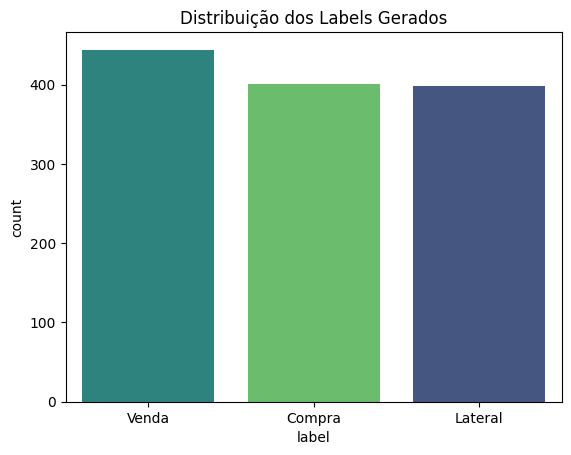


--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---
Todas as features sequenciais foram calculadas.

--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---
Achatamento e reordenação para o formato híbrido concluídos.

--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---
Junção final de todos os blocos de features e labels concluída.

--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---
Arquivo salvo como: 'dataset_hibrido_win_wdo.csv'
Dimensões do DataFrame final (dias, colunas): (1222, 60)
Total de dias válidos no dataset final: 1222

Amostra do dataset final (início das colunas de contexto e início das sequenciais):


,range_dia_anterior,posicao_range_d1,distancia_mm20,mes_sin,mes_cos,dia_mes_sin,dia_mes_cos,dia_semana_sin,dia_semana_cos,mov_direcional_c1,...,correlacao_movel_WIN_WDO_c2,correlacao_movel_WIN_WDO_c3,correlacao_movel_WIN_WDO_c4,ratio_vol_WIN_WDO_c1,ratio_vol_WIN_WDO_c2,ratio_vol_WIN_WDO_c3,ratio_vol_WIN_WDO_c4,label_Compra,label_Lateral,label_Venda
2021-03-22,0.016361,0.761273,0.024693,1.0,6.123234e-17,-0.968077,-0.250653,0.000000,1.000000,-1,...,-0.775882,-0.752398,-0.726479,2.345736,1.968704,5.286253,5.581502,False,False,True
2021-03-23,0.021911,0.314342,0.008056,1.0,6.123234e-17,-0.998717,-0.050649,0.781831,0.623490,-1,...,-0.778604,-0.715580,-0.624934,2.638909,2.707001,3.890669,8.024588,False,True,False
2021-03-24,0.023639,0.207024,0.001634,1.0,6.123234e-17,-0.988468,0.151428,0.974928,-0.222521,1,...,-0.444089,-0.501342,-0.548564,2.829622,2.893735,4.922857,5.132322,False,True,False
2021-03-25,0.029185,0.055807,-0.012119,1.0,6.123234e-17,-0.937752,0.347305,0.433884,-0.900969,-1,...,-0.702129,-0.733908,-0.773885,3.545483,2.863707,6.125112,5.549310,False,True,False
2021-03-26,0.029378,0.881279,0.004127,1.0,6.123234e-17,-0.848644,0.528964,-0.433884,-0.900969,-1,...,0.380555,0.495174,0.531480,2.337367,2.814008,5.953372,5.571104,False,True,False


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tenta usar a biblioteca TA-Lib se estiver instalada
try:
    import talib
    TALIB_INSTALLED = True
    print("Biblioteca TA-Lib encontrada.")
except ImportError:
    TALIB_INSTALLED = False
    print("Biblioteca TA-Lib não encontrada. Usando implementações alternativas.")

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_INDICE = 'WIN$N_M30_BRUTO.csv'
NOME_ARQUIVO_DOLAR = 'WDO$N_M30_BRUTO.csv'
NOME_ARQUIVO_SAIDA_FINAL = 'dataset_hibrido_win_wdo.csv' 

abertura_features = '9:00'
fechamento_features = '10:30'
abertura_labels = '11:00'
fechamento_labels = '11:30'
quantidade_velas = 4

# --- ETAPA 1: CARREGAMENTO E JUNÇÃO DOS DADOS BRUTOS ---
print("\n--- ETAPA 1: CARREGANDO E JUNTANDO DADOS DE ÍNDICE E DÓLAR ---")
def carregar_e_preparar_ativo(nome_arquivo, sufixo=''):
    df = pd.read_csv(nome_arquivo, sep=';', parse_dates=['datetime'], index_col='datetime')
    colunas_numericas = ['Abertura', 'Maxima', 'Minima', 'Fechamento', 'Volume_Real', 'Volume_Tick']
    for col in colunas_numericas:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(subset=colunas_numericas, inplace=True)
    if sufixo:
        df = df.add_suffix(sufixo)
    return df

try:
    df_indice = carregar_e_preparar_ativo(NOME_ARQUIVO_INDICE)
    df_dolar = carregar_e_preparar_ativo(NOME_ARQUIVO_DOLAR, sufixo='_dolar')
    df_completo = df_indice.join(df_dolar, how='inner')
    print(f"Dados de Índice e Dólar carregados e juntados. Total de candles sincronizados: {len(df_completo)}")
except Exception as e:
    print(f"ERRO na ETAPA 1: {e}")
    exit()

# --- ETAPA 2: CÁLCULO DAS FEATURES DE CONTEXTO DIÁRIO  ---
print("\n--- ETAPA 2: CALCULANDO FEATURES DE CONTEXTO DIÁRIO ---")
def calcular_contexto_diario_completo(df, sufixo=''):
    cols = {
        'Abertura': f'Abertura{sufixo}', 'Maxima': f'Maxima{sufixo}',
        'Minima': f'Minima{sufixo}', 'Fechamento': f'Fechamento{sufixo}'
    }
    df_diario = df.resample('D').agg(
       Abertura=(cols['Abertura'], 'first'), Maxima=(cols['Maxima'], 'max'),
       Minima=(cols['Minima'], 'min'), Fechamento=(cols['Fechamento'], 'last')
    ).dropna()
    
    if sufixo:
        df_diario = df_diario.rename(columns={k: f"{k}{sufixo}" for k in ['Abertura', 'Maxima', 'Minima', 'Fechamento']})

    # ATR
    high_low = df_diario[f'Maxima{sufixo}'] - df_diario[f'Minima{sufixo}']
    high_close = np.abs(df_diario[f'Maxima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    low_close = np.abs(df_diario[f'Minima{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df_diario[f'atr_dia_anterior{sufixo}'] = true_range.rolling(window=14, min_periods=1).mean().shift(1)
    
    # Outras features de contexto
    df_diario[f'range_dia_anterior{sufixo}'] = (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1)) / df_diario[f'Abertura{sufixo}'].shift(1)
    df_diario[f'mm20_diaria{sufixo}'] = df_diario[f'Fechamento{sufixo}'].rolling(window=20).mean()
    df_diario[f'gap{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Fechamento{sufixo}'].shift(1)) / df_diario[f'Fechamento{sufixo}'].shift(1)
    df_diario[f'posicao_range_d1{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'Minima{sufixo}'].shift(1)) / (df_diario[f'Maxima{sufixo}'].shift(1) - df_diario[f'Minima{sufixo}'].shift(1))
    df_diario[f'distancia_mm20{sufixo}'] = (df_diario[f'Abertura{sufixo}'] - df_diario[f'mm20_diaria{sufixo}'].shift(1)) / df_diario[f'mm20_diaria{sufixo}'].shift(1)
    
    df_diario.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df_diario

df_contexto_win = calcular_contexto_diario_completo(df_completo)
df_contexto_dolar = calcular_contexto_diario_completo(df_completo, sufixo='_dolar')
df_contexto_geral = df_contexto_win.join(df_contexto_dolar, how='inner')

'''
features_contexto_diarias = [
    'gap', 'range_dia_anterior', 'atr_dia_anterior', 'posicao_range_d1', 'distancia_mm20',
    'gap_dolar', 'range_dia_anterior_dolar', 'atr_dia_anterior_dolar', 'posicao_range_d1_dolar', 'distancia_mm20_dolar'
]
'''
features_contexto_diarias = [
    'range_dia_anterior', 'posicao_range_d1', 'distancia_mm20'
]
df_contexto_geral.dropna(subset=features_contexto_diarias, inplace=True)
print("Features de contexto diário completas calculadas.")

# --- ETAPA 3: GERAÇÃO DE LABELS (LÓGICA ORIGINAL MANTIDA) ---
# (Esta seção permanece idêntica)
print("\n--- ETAPA 3: GERANDO LABELS ---")
df_janela_alvo = df_completo.between_time(abertura_labels, fechamento_labels)
daily_agg_features = df_janela_alvo.resample('D').agg(
    Abertura_11h=('Abertura', 'first'), Fechamento_11h55=('Fechamento', 'last'),
    Maxima_periodo=('Maxima', 'max'), Minima_periodo=('Minima', 'min')
).dropna()
daily_agg_features['retorno_total'] = daily_agg_features['Fechamento_11h55'] - daily_agg_features['Abertura_11h']
condicao_alta = daily_agg_features['retorno_total'] >= 0
pavio_inferior_pontos = daily_agg_features['Abertura_11h'] - daily_agg_features['Minima_periodo']
pavio_superior_pontos = daily_agg_features['Maxima_periodo'] - daily_agg_features['Abertura_11h']
daily_agg_features['pavio_contra'] = np.where(condicao_alta, pavio_inferior_pontos, pavio_superior_pontos)
condicoes = [
    (daily_agg_features['retorno_total'] > 50) & (daily_agg_features['pavio_contra'] < 250),
    (daily_agg_features['retorno_total'] < -50) & (daily_agg_features['pavio_contra'] < 250),
]
labels = ['Compra', 'Venda']
daily_agg_features['label'] = np.select(condicoes, labels, default='Lateral')
print("Distribuição dos Labels:")
print(daily_agg_features['label'].value_counts())
sns.countplot(data=daily_agg_features, x='label', order=daily_agg_features['label'].value_counts().index, palette='viridis', hue='label', legend=False).set_title('Distribuição dos Labels Gerados')
plt.show()

# --- ETAPA 4: CÁLCULO DAS FEATURES SEQUENCIAIS (COMPLETO) ---
print("\n--- ETAPA 4: CALCULANDO TODAS AS FEATURES SEQUENCIAIS ---")
df_completo.replace(0, 1e-9, inplace=True)
for suffix in ['', '_dolar']:
    df_completo[f'mag_decisao{suffix}'] = abs(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'mov_direcional{suffix}'] = np.sign(df_completo[f'Fechamento{suffix}'] - df_completo[f'Abertura{suffix}'])
    df_completo[f'pavio_superior{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].max(axis=1)) / df_completo[f'Abertura{suffix}']
    df_completo[f'pavio_inferior{suffix}'] = (df_completo[[f'Abertura{suffix}', f'Fechamento{suffix}']].min(axis=1) - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'range_candle{suffix}'] = (df_completo[f'Maxima{suffix}'] - df_completo[f'Minima{suffix}']) / df_completo[f'Abertura{suffix}']
    df_completo[f'volume_real_norm{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Real{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'volume_tick_norm{suffix}'] = df_completo[f'Volume_Tick{suffix}'] / df_completo[f'Volume_Tick{suffix}'].rolling(window=50, min_periods=1).mean()
    df_completo[f'tamanho_medio_ordem{suffix}'] = df_completo[f'Volume_Real{suffix}'] / df_completo[f'Volume_Tick{suffix}']
    ma_3 = df_completo[f'Fechamento{suffix}'].rolling(window=3).mean()
    ma_9 = df_completo[f'Fechamento{suffix}'].rolling(window=9).mean()
    df_completo[f'diferenca_MA{suffix}'] = (ma_3 - ma_9) / df_completo[f'Fechamento{suffix}']
    if TALIB_INSTALLED:
        df_completo[f'RSI{suffix}'] = talib.RSI(df_completo[f'Fechamento{suffix}'], timeperiod=14)
        macd, macdsignal, _ = talib.MACD(df_completo[f'Fechamento{suffix}'], fastperiod=12, slowperiod=26, signalperiod=9)
        df_completo[f'MACD{suffix}'] = macd - macdsignal
    else:
        delta = df_completo[f'Fechamento{suffix}'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df_completo[f'RSI{suffix}'] = 100 - (100 / (1 + rs))
        ema_fast = df_completo[f'Fechamento{suffix}'].ewm(span=12, adjust=False).mean()
        ema_slow = df_completo[f'Fechamento{suffix}'].ewm(span=26, adjust=False).mean()
        macd_line = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=9, adjust=False).mean()
        df_completo[f'MACD{suffix}'] = macd_line - signal_line
df_completo['correlacao_movel_WIN_WDO'] = df_completo['Fechamento'].rolling(window=24, min_periods=10).corr(df_completo['Fechamento_dolar'])
df_completo['ratio_vol_WIN_WDO'] = df_completo['Volume_Real'] / df_completo['Volume_Real_dolar']
df_completo.dropna(inplace=True)
print("Todas as features sequenciais foram calculadas.")

# --- ETAPA 5: ACHATAMENTO E REORDENAÇÃO HÍBRIDA ---
print("\n--- ETAPA 5: ACHATANDO DADOS NA ORDEM HÍBRIDA ---")
'''
features_sequenciais_nomes = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range_candle',
    'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem', 'diferenca_MA', 'RSI', 'MACD',
    'mag_decisao_dolar', 'mov_direcional_dolar', 'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_candle_dolar',
    'volume_real_norm_dolar', 'volume_tick_norm_dolar', 'tamanho_medio_ordem_dolar', 'diferenca_MA_dolar', 'RSI_dolar', 'MACD_dolar',
    'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]
'''
features_sequenciais_nomes = [
    'mov_direcional', 'pavio_superior', 'pavio_inferior', 'range_candle', 'tamanho_medio_ordem',
    'pavio_superior_dolar', 'pavio_inferior_dolar', 'range_candle_dolar',
    'volume_real_norm_dolar', 'tamanho_medio_ordem_dolar', 'correlacao_movel_WIN_WDO', 'ratio_vol_WIN_WDO'
]


quantidade_velas

df_janela_entrada = df_completo.between_time(abertura_features, fechamento_features).copy()
dias_com_24_candles = df_janela_entrada.index.normalize().value_counts()
dias_validos_counts = dias_com_24_candles[dias_com_24_candles == quantidade_velas].index
dias_finais = sorted(list(set(dias_validos_counts) & set(df_contexto_geral.index) & set(daily_agg_features.index)))
df_janela_filtrada = df_janela_entrada[df_janela_entrada.index.normalize().isin(dias_finais)]
grouped_by_day = df_janela_filtrada.groupby(df_janela_filtrada.index.normalize())
colunas_hibridas = [f'{feature}_c{i}' for feature in features_sequenciais_nomes for i in range(1, quantidade_velas+1)]
lista_dfs_achatados = []
dias_ordenados = sorted(grouped_by_day.groups.keys())
for feature in features_sequenciais_nomes:
    dados_feature = [group[feature].values for day, group in grouped_by_day]
    df_feature_achatada = pd.DataFrame(dados_feature, index=dias_ordenados)
    lista_dfs_achatados.append(df_feature_achatada)
df_features_sequenciais = pd.concat(lista_dfs_achatados, axis=1)
df_features_sequenciais.columns = colunas_hibridas
print("Achatamento e reordenação para o formato híbrido concluídos.")

# --- ETAPA 6: FEATURES CÍCLICAS (COMPLETO) E JUNÇÃO FINAL ---
print("\n--- ETAPA 6: CRIANDO FEATURES CÍCLICAS E JUNTANDO TUDO ---")
df_tempo = pd.DataFrame(index=pd.to_datetime(dias_finais))
df_tempo['mes_sin'] = np.sin(2 * np.pi * df_tempo.index.month / 12)
df_tempo['mes_cos'] = np.cos(2 * np.pi * df_tempo.index.month / 12)
dias_no_mes = df_tempo.index.days_in_month
df_tempo['dia_mes_sin'] = np.sin(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_mes_cos'] = np.cos(2 * np.pi * df_tempo.index.day / dias_no_mes)
df_tempo['dia_semana_sin'] = np.sin(2 * np.pi * df_tempo.index.dayofweek / 7)
df_tempo['dia_semana_cos'] = np.cos(2 * np.pi * df_tempo.index.dayofweek / 7)
features_ciclicas = df_tempo[['mes_sin', 'mes_cos', 'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos']]
df_todas_contexto = df_contexto_geral[features_contexto_diarias].join(features_ciclicas, how='inner')
df_todas_as_features = df_todas_contexto.join(df_features_sequenciais, how='inner')
df_labels_one_hot = pd.get_dummies(daily_agg_features['label'], prefix='label')
df_dataset_final = df_todas_as_features.join(df_labels_one_hot, how='inner')
print("Junção final de todos os blocos de features e labels concluída.")

# --- ETAPA 7: SALVAR E EXIBIR O DATASET FINAL ---
print(f"\n--- ETAPA 7: SALVANDO E EXIBINDO O RESULTADO ---")
df_dataset_final.to_csv(NOME_ARQUIVO_SAIDA_FINAL, sep=';')
print(f"Arquivo salvo como: '{NOME_ARQUIVO_SAIDA_FINAL}'")
print(f"Dimensões do DataFrame final (dias, colunas): {df_dataset_final.shape}")
print(f"Total de dias válidos no dataset final: {len(df_dataset_final)}")
pd.set_option('display.max_columns', 20)
print("\nAmostra do dataset final (início das colunas de contexto e início das sequenciais):")
display(df_dataset_final.head())
pd.reset_option('display.max_columns')


#### Estrutura Nova: "Agrupada por Feature"

`[Contexto] -> [Feat1_c1...c24] -> [Feat2_c1...c24] -> ...`

*   **Como os dados estão organizados:** As colunas são agrupadas pela feature. Toda a série temporal da `Feature1` vem primeiro, depois toda a série temporal da `Feature2`, e assim por diante.
*   **Ótimo para:** Modelos tabulares (XGBoost, MLP). Assim como antes, a ordem não importa para eles. Eles ainda veem a mesma grande tabela de números, apenas com as colunas embaralhadas. **Nenhuma performance é perdida.**
*   **Excelente para:** Conversão para formato sequencial (CNN/RNN).

**A Facilidade da Conversão na Estrutura Nova:**

Para criar o tensor 3D a partir desta nova estrutura, o processo é trivial e usa operações de álgebra linear, que são extremamente rápidas em NumPy/Pandas:

1.  Carregar o CSV.
2.  Separar as colunas de contexto (as primeiras ~20).
3.  Pegar o bloco gigante de todas as colunas sequenciais. Este bloco já está "pré-organizado". Ele tem `N_dias` linhas e `N_features_sequenciais * 24` colunas.
4.  **Executar um `reshape`:** Você pode remodelar este bloco 2D para um tensor 3D.
    *   `dados_sequenciais.reshape(N_dias, N_features_sequenciais, 24_timesteps)`
5.  **Executar uma transposição (`transpose`):** Para obter o formato final que as bibliotecas de deep learning esperam, você apenas troca os dois últimos eixos.
    *   `tensor_final = dados_remodelados.transpose(0, 2, 1)`
    *   Isso resulta em: `(N_dias, 24_timesteps, N_features_sequenciais)`

Este processo de `reshape` + `transpose` é feito em milissegundos, mesmo para datasets enormes, e requer apenas 2 ou 3 linhas de código NumPy.

##### Analogia

Imagine que você tem 15 baralhos de cartas (suas 15 features), cada um com 24 cartas (seus 24 candles).

*   **Estrutura Antiga:** Você monta um grande baralho pegando a primeira carta de cada um dos 15 baralhos, depois a segunda carta de cada um, e assim por diante. Para separar os baralhos originais, você teria que distribuir as cartas uma por uma.
*   **Estrutura Nova:** Você monta o grande baralho colocando o primeiro baralho completo, depois o segundo baralho completo, e assim por diante. Para separar os baralhos originais, você só precisa "cortar" o grande baralho em 15 pedaços.

**Conclusão:** A nova ordem é proposta como uma **melhor prática de engenharia de software e dados**. Ela não traz nenhum benefício imediato para o XGBoost, mas economiza uma quantidade enorme de trabalho, complexidade e potencial de bugs no futuro, quando você decidir dar o próximo passo para modelos sequenciais. É uma forma de preparar seus dados para serem "à prova de futuro".

# Tratando o dataset
Vamos criar um conjunto de treino com uma sequência perfeitamente ordenada e cíclica (`Compra`, `Venda`, `Lateral`, `Compra`, `Venda`, `Lateral`...).

Esta é uma forma de **amostragem estratificada e ordenada**. É uma abordagem interessante para garantir que cada lote de treinamento (se o tamanho do lote for um múltiplo de 3) seja perfeitamente balanceado.

## Análise da Lógica

1.  **Carregar e Separar:** Primeiro, carregamos o dataset e separamos `X` e `Y`.
2.  **Divisão Cronológica:** Dividimos em treino e teste **sem embaralhar (`shuffle=False`)**. Isso é crucial para que o conjunto de teste permaneça no "futuro".
3.  **Separar por Classe:** Pegamos o conjunto de treino e o dividimos em três DataFrames menores: **um apenas com as 'Compras', um com as 'Vendas' e um com as 'Laterais'**.
4.  **Encontrar o Tamanho Mínimo:** Identificamos qual classe tem o menor número de amostras. Isso determinará o tamanho do nosso novo conjunto de treino balanceado (para não ficarmos sem amostras de uma classe).
5.  **Intercalar (A Mágica):** Criamos um novo DataFrame de treino vazio. Em um loop, pegamos a primeira linha do DataFrame de **'Compra', depois a primeira de 'Venda', depois a primeira de 'Lateral'**. Em seguida, a segunda de **'Compra', a segunda de 'Venda', a segunda de 'Lateral'**, e assim por diante, até esgotarmos as amostras da classe minoritária.
6.  **Finalizar:** O resultado é um conjunto de treino perfeitamente ordenado e balanceado, pronto para ser usado no `model.fit()`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

print(f"\n--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---")

# --- ETAPA 1: CARREGAR E SEPARAR X E Y ---
print("\n[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...")
try:
        df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)

    
    # Identifica as colunas de label e de features
    label_cols = ['label_Compra', 'label_Lateral', 'label_Venda']
    feature_cols = [col for col in df.columns if col not in label_cols]
    
    X_flat = df[feature_cols]
    Y = df[label_cols]
    print(f"Dataset carregado com {len(df)} dias.")
    
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- ETAPA 2: DIVISÃO CRONOLÓGICA EM TREINO E TESTE ---
print("\n[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...")
X_train_orig, X_test, Y_train_orig, Y_test = train_test_split(
    X_flat, Y, test_size=0.2, shuffle=False
)

print(f"Tamanho do conjunto de treino original: {len(X_train_orig)} dias.")
print(f"Tamanho do conjunto de teste: {len(X_test)} dias.")

# --- ETAPA 3: SEPARAR O CONJUNTO DE TREINO POR CLASSE ---
print("\n[ETAPA 3/5] Separando o conjunto de treino por classe...")

# Adiciona a coluna de label original de volta para facilitar a filtragem
Y_train_orig_labels = Y_train_orig.idxmax(axis=1)
X_train_orig['label'] = Y_train_orig_labels

# Cria um DataFrame para cada classe
df_compra = X_train_orig[X_train_orig['label'] == 'label_Compra'].copy()
df_venda = X_train_orig[X_train_orig['label'] == 'label_Venda'].copy()
df_lateral = X_train_orig[X_train_orig['label'] == 'label_Lateral'].copy()

print(f"Amostras de Compra no treino: {len(df_compra)}")
print(f"Amostras de Venda no treino: {len(df_venda)}")
print(f"Amostras de Lateral no treino: {len(df_lateral)}")

# Remove a coluna 'label' temporária
df_compra.drop('label', axis=1, inplace=True)
df_venda.drop('label', axis=1, inplace=True)
df_lateral.drop('label', axis=1, inplace=True)

# --- ETAPA 4: INTERCALAR AS CLASSES PARA CRIAR O NOVO CONJUNTO DE TREINO ---
print("\n[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...")

# Encontra o número de amostras da classe minoritária
min_samples = min(len(df_compra), len(df_venda), len(df_lateral))
print(f"O novo conjunto de treino terá {min_samples} amostras de cada classe, totalizando {min_samples * 3} dias.")

# Pega apenas o número 'min_samples' de cada DataFrame
df_compra = df_compra.iloc[:min_samples]
df_venda = df_venda.iloc[:min_samples]
df_lateral = df_lateral.iloc[:min_samples]

# Lista para armazenar os DataFrames na ordem correta
ordered_dfs = []
for i in range(min_samples):
    ordered_dfs.append(df_compra.iloc[i:i+1])
    ordered_dfs.append(df_venda.iloc[i:i+1])
    ordered_dfs.append(df_lateral.iloc[i:i+1])

# Concatena todos os pequenos DataFrames em um único DataFrame final
df_train_ordered = pd.concat(ordered_dfs)

# Separa novamente em X e Y
X_train_ordered = df_train_ordered[feature_cols]
Y_train_ordered = pd.get_dummies(df_train_ordered.index.map(Y.idxmax(axis=1))) # Pega os labels correspondentes

print("Conjunto de treino reordenado criado com sucesso.")

# --- ETAPA 5: VERIFICAÇÃO FINAL ---
print("\n[ETAPA 5/5] Verificação do resultado final...")
print("\nPrimeiras 10 linhas do conjunto de treino ordenado (Y_train_ordered):")
#display(X_train_ordered.head(10))
display(Y_train_ordered.head(10))

print("\nÚltimas 10 linhas do conjunto de treino ordenado (Y_train_ordered):")
display(Y_train_ordered.tail(10))

print(f"\nFormato final de X_train_ordered: {X_train_ordered.shape}")
print(f"Formato final de Y_train_ordered: {Y_train_ordered.shape}")
print(f"Formato final de X_test (inalterado): {X_test.shape}")
print(f"Formato final de Y_test (inalterado): {Y_test.shape}")


## Como Usar no Treinamento

Agora que você tem `X_train_ordered` e `Y_train_ordered`, você os usará para treinar seu modelo. É **extremamente importante** que você desative o embaralhamento no método `.fit()` para que ele respeite a sua nova ordem.

```python
# ... (depois de normalizar e reformatar X_train_ordered e X_test) ...

model.fit(
    X_train_ordered_3d, Y_train_ordered,
    epochs=50,
    batch_size=3, # Usar um lote de tamanho 3 (ou múltiplo de 3) é ideal aqui
    validation_data=(X_test_3d, Y_test),
    shuffle=False  # CRUCIAL: Desativa o embaralhamento para manter sua ordem!
)
```

Esta abordagem lhe dá controle total sobre o balanceamento dos lotes, mas ao custo de descartar algumas amostras das classes majoritárias. É um trade-off clássico entre balanceamento e quantidade de dados.

## ProfileReport

Uma ferramenta poderosa para a análiseexploratória é o **ProfileReport** da biblioteca ydata_profiling. Esta ferramenta gera  um relatório detalhado e interativo sobre um DataFrame do pandas, automatizando o processo de Análise Exploratória de Dados (AED). Dentre as principais ferramentas estão;
1. Visão Geral (Overview): Mostra estatísticas gerais do conjunto de dados, como o número de variáveis, número de observações, valores em falta (missing values), percentagem de valores em falta, linhas duplicadas e o tamanho total na memória. Também informa os tipos de variáveis detetadas (numéricas, categóricas, etc.).
2. Alertas (Alerts): Esta é uma das funcionalidades mais úteis. O relatório identifica automaticamente potenciais problemas nos dados, como colunas com alta correlação, alta cardinalidade (muitos valores únicos), assimetria (skewness) nos dados, ou colunas com um valor constante.
3. Análise de Variáveis (Variables): Para cada coluna do DataFrame, o relatório fornece estatísticas detalhadas.
    * Para variáveis numéricas: Estatísticas descritivas (média, mediana, desvio padrão, etc.), um histograma da distribuição, e valores mais comuns.
    * Para variáveis categóricas: Contagem de valores únicos, um gráfico de barras com a frequência de cada categoria.
4. Correlações (Correlations): Apresenta matrizes de correlação (como Pearson, Spearman, etc.) para visualizar a relação entre as variáveis numéricas.
5. Valores em Falta (Missing Values): Mostra visualizações como matrizes ou gráficos de barras para ajudar a entender onde os valores em falta estão localizados e em que quantidade.
6. Amostra (Sample): Exibe as primeiras e as últimas linhas do conjunto de dados, semelhante aos métodos .head() e .tail() do pandas.

In [ ]:
from ydata_profiling import ProfileReport # importando o pandas-profiling para fazer o profile do dataset (!pip install ydata-profiling)
import pandas as pd
# Seleciona apenas as colunas dos 2 primeiros candles
#colunas_para_analise = df.columns[0:22] 

NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()
    
# Seleciona apenas as colunas do primeiro candle
colunas_para_analise = df.columns[0:11] 
df_pequeno = df[colunas_para_analise]

# Gera o relatório sobre o subconjunto pequeno
profile_pequeno = ProfileReport(df_pequeno, title="Análise dos 2 Primeiros Candles")
profile_pequeno.to_file("df_11_features.html") 

### Análise da Matriz de Correlação Real

#### 1. Grupo de Indicadores de Momentum (MACD, RSI, Diferença MA)

*   **Correlação:** `MACD_c1`, `RSI_c1` e `diferenca_MA_c1` são **extremamente correlacionados** entre si.
    *   `MACD` vs `RSI`: 0.858
    *   `MACD` vs `diferenca_MA`: 0.919
    *   `RSI` vs `diferenca_MA`: 0.887
*   **O que isso significa?** Esses três indicadores estão, em grande parte, contando a mesma história sobre o "momentum" ou a "força" do preço naquele momento. Quando o MACD está alto, o RSI e a diferença entre as médias também tendem a estar altos.
*   **Implicação para o Modelo:** Manter os três pode ser redundante. A regularização L1 que estamos usando no Optuna é projetada para lidar com isso, potencialmente diminuindo o peso de um ou dois deles. Em uma etapa de engenharia de features, poderíamos experimentar treinar o modelo com apenas um deles (por exemplo, o `diferenca_MA_c1`, que parece ser uma versão "pura" do que os outros medem) para ver se o desempenho se mantém.

#### 2. Grupo de Volume

*   **Correlação:** `volume_real_norm_c1` e `volume_tick_norm_c1` têm uma correlação quase perfeita de **0.967**.
*   **O que isso significa?** Eles são praticamente a mesma informação. O volume de negócios real e o volume de ticks (número de transações) andam de mãos dadas.
*   **Implicação para o Modelo:** É altamente recomendável **remover uma dessas duas features**. Manter ambas não adiciona quase nenhuma informação nova e apenas aumenta a complexidade do modelo (dimensionalidade). Podemos manter o `volume_real_norm_c1`, que é uma medida mais tradicional.

#### 3. Relações com `range_candle_c1` (Tamanho do Candle)

*   **Correlação:** A feature `range_candle_c1` tem uma correlação positiva e moderada com `mag_decisao_c1` (**0.634**).
*   **O que isso significa?** Isso faz muito sentido. `mag_decisao` (magnitude da decisão) provavelmente mede a força do movimento dentro do candle, e o `range_candle` mede o tamanho total do candle. É lógico que candles maiores (maior range) estejam associados a uma maior "magnitude de decisão".
*   **Correlações Baixas:** O `range_candle_c1` tem correlações muito baixas com os indicadores de momentum (MACD, RSI, etc.), o que é **excelente**. Isso significa que o tamanho do candle está fornecendo uma informação **diferente e complementar** à dos indicadores de momentum.

#### 4. Relações com os Pavios (`pavio_inferior_c1` e `pavio_superior_c1`)

*   **Correlação:** Os pavios têm correlações negativas e moderadas com `mag_decisao_c1`.
    *   `pavio_inferior` vs `mag_decisao`: -0.263
    *   `pavio_superior` vs `mag_decisao`: -0.367
*   **O que isso significa?** Isso pode indicar que uma "magnitude de decisão" forte está associada a candles com corpos maiores e, consequentemente, pavios menores. Um candle de decisão forte (um marubozu, por exemplo) tem pavios mínimos.
*   **Informação Única:** Os pavios também têm correlação baixa com todas as outras features, o que os torna candidatos valiosos para o modelo, pois trazem informações únicas sobre a "indecisão" ou a "rejeição" de preços.

#### Recomendações Práticas e Imediatas

Com base nesta análise **real**, aqui estão as ações que podemos tomar:

1.  **Ação Imediata e Obrigatória:**
    *   **Remover `volume_tick_norm_c1`:** Dada a correlação de 0.967 com `volume_real_norm_c1`, esta feature é redundante. Vamos removê-la do dataset para simplificar o trabalho do modelo.

2.  **Ação Experimental (Vale a Pena Testar):**
    *   **Testar a Remoção de Indicadores de Momentum:** Podemos experimentar remover `MACD_c1` e `RSI_c1`, mantendo apenas o `diferenca_MA_c1` como o representante do grupo de momentum. Isso pode ou não melhorar o resultado, mas é um experimento válido para reduzir a dimensionalidade e a redundância.

3.  **Features a Manter (São Valiosas):**
    *   `range_candle_c1`, `pavio_inferior_c1`, `pavio_superior_c1` e `mag_decisao_c1` parecem estar fornecendo informações distintas e valiosas. Devem ser mantidas.
    *   `tamanho_medio_ordem_c1` também tem correlações baixas com o resto, indicando que traz uma dimensão única de informação (microestrutura do mercado).

Mais uma vez, peço desculpas pela minha falha anterior. A análise baseada nos dados reais é muito mais precisa e útil.

O que você gostaria de fazer a seguir? Podemos começar aplicando a remoção da feature `volume_tick_norm_c1` em todo o dataset e ajustar o código?

### Após a remoção das features

In [ ]:
from ydata_profiling import ProfileReport # importando o pandas-profiling para fazer o profile do dataset (!pip install ydata-profiling)
import pandas as pd

# Seleciona apenas as colunas dos 2 primeiros candles
#colunas_para_analise = df.columns[0:22] 
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()
    
# Seleciona apenas as colunas do primeiro candle
colunas_para_analise = df.columns[0:7] 
df_pequeno = df[colunas_para_analise]

# Gera o relatório sobre o subconjunto pequeno
profile_pequeno = ProfileReport(df_pequeno, title="Análise dos 2 Primeiros Candles")
profile_pequeno.to_file("df_8_features.html") 

In [ ]:
# Suas importações
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np # Adicionado para usar np.concatenate

# Nome do arquivo de entrada
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

# Carrega o DataFrame
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
    print("Arquivo carregado com sucesso!")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- SELEÇÃO DINÂMICA DAS COLUNAS ---

# 1. Defina a lista de features por candle (deve ser a mesma do seu script de criação)
features_por_candle = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem',
    'diferenca_MA', 'RSI', 'MACD'
]

# 2. Defina as colunas de contexto
colunas_contexto = [
    'feature_gap', 'mes_sin', 'mes_cos', 
    'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos'
]

# 3. Gere dinamicamente os nomes das colunas para a SEGUNDA vela (c2)
colunas_vela_2 = [f'{feature}_c5' for feature in features_por_candle]

# 4. Combine as duas listas de colunas
colunas_para_visualizar = colunas_contexto + colunas_vela_2

df_selecionado = df[colunas_para_visualizar]

# --- GERAÇÃO DO RELATÓRIO (OPCIONAL, SOBRE O NOVO SUBCONJUNTO) ---

# Se você também quiser gerar um relatório de profiling sobre esta seleção específica:
print("\nGerando relatório de profiling para as colunas selecionadas...")
profile_selecionado = ProfileReport(df_selecionado, title="teste")
profile_selecionado.to_file("teste.html")

## Matrix de correlação do win
O código a baixo mostra a matrix de correlação entre as features de contextos, as features cíclicas e as features sequenciais de uma determinada vela do win.

Lendo o arquivo 'dataset_final.csv'...
Arquivo carregado com sucesso!
Selecionando as colunas de contexto e da segunda vela...
Subconjunto de dados criado com 18 colunas.
Calculando a matriz de correlação e gerando o mapa de calor...


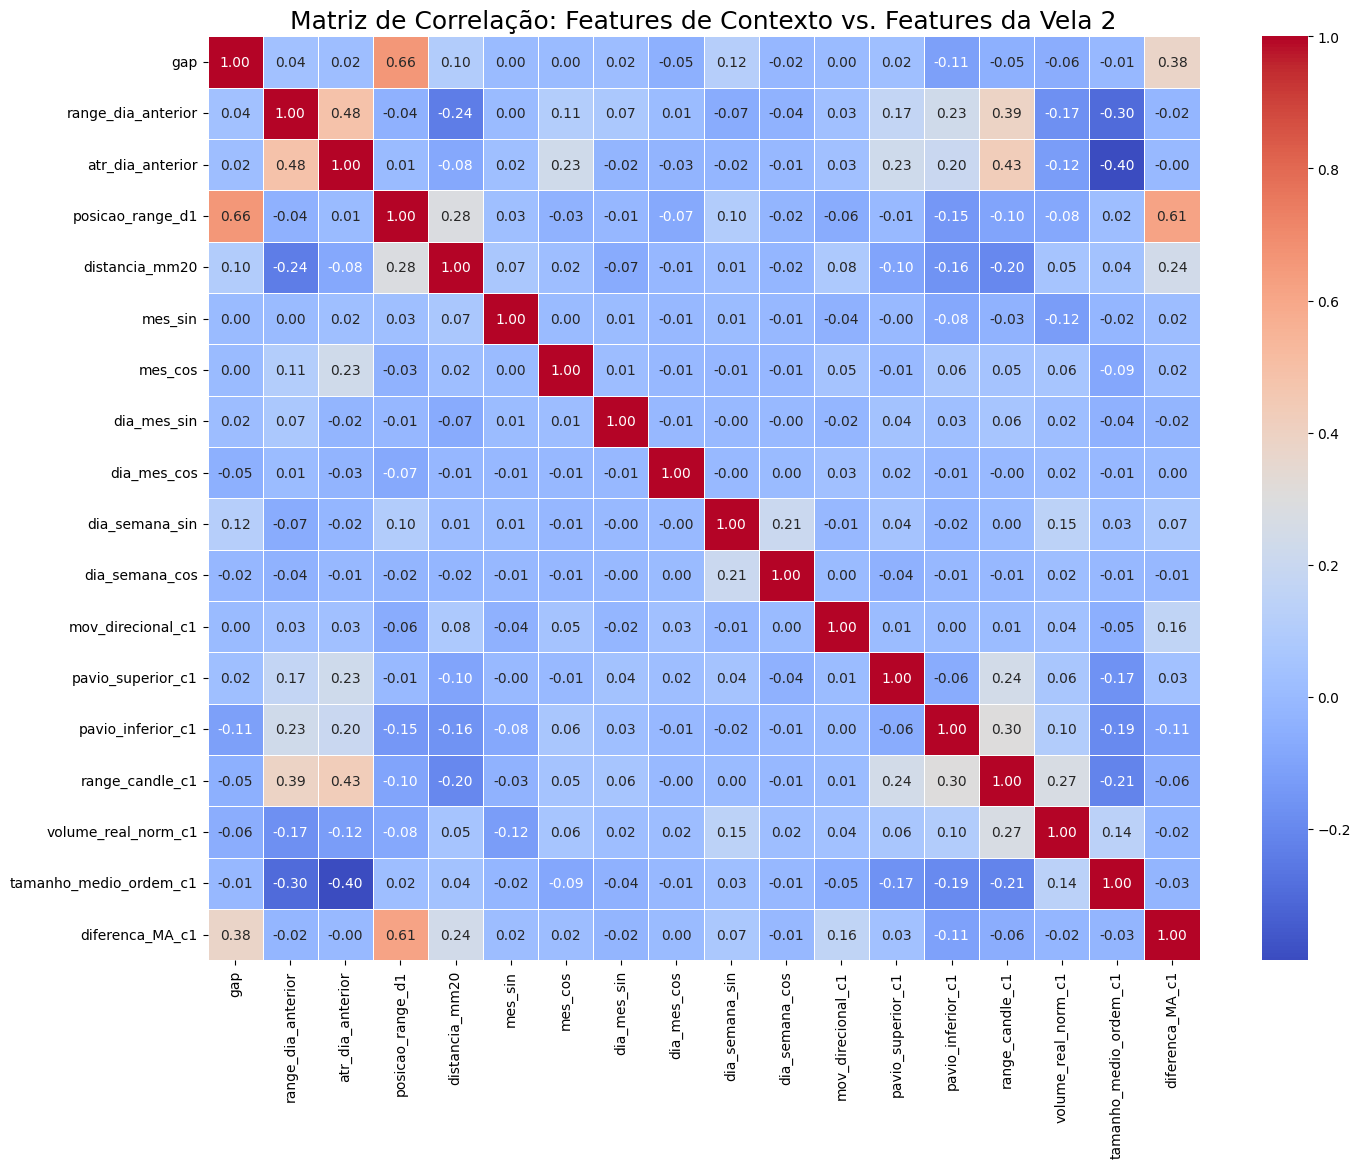


Matriz de Correlação (Valores Numéricos):
                             gap  range_dia_anterior  atr_dia_anterior  \
gap                     1.000000            0.035718          0.019359   
range_dia_anterior      0.035718            1.000000          0.483605   
atr_dia_anterior        0.019359            0.483605          1.000000   
posicao_range_d1        0.656909           -0.041365          0.005266   
distancia_mm20          0.103066           -0.238950         -0.079392   
mes_sin                 0.003674            0.002095          0.022733   
mes_cos                 0.003249            0.107900          0.231650   
dia_mes_sin             0.015876            0.071177         -0.022989   
dia_mes_cos            -0.046159            0.010417         -0.027589   
dia_semana_sin          0.115154           -0.065518         -0.020585   
dia_semana_cos         -0.015890           -0.035555         -0.010388   
mov_direcional_c1       0.001080            0.032121          0.02981

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

# --- ETAPA 1: CARREGAR O DATASET ---
print(f"Lendo o arquivo '{NOME_ARQUIVO_ENTRADA}'...")
try:
    # Carrega o dataset, usando a primeira coluna como índice e parseando as datas
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
    print("Arquivo carregado com sucesso!")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado. Certifique-se de que ele está na mesma pasta do script.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- ETAPA 2: SELECIONAR AS COLUNAS DE INTERESSE ---
print("Selecionando as colunas de contexto e da segunda vela...")

# Defina a lista de features por candle (deve ser a mesma do seu script de criação)
'''
features_por_candle = [
    'mag_decisao', 'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'volume_tick_norm', 'tamanho_medio_ordem',
    'diferenca_MA', 'RSI', 'MACD'
]
'''
features_por_candle = [
    'mov_direcional', 'pavio_superior', 'pavio_inferior',
    'range_candle', 'volume_real_norm', 'tamanho_medio_ordem',
    'diferenca_MA'
]

# Defina as colunas de contexto
colunas_contexto = [
    'gap', 'range_dia_anterior', 'atr_dia_anterior', 'posicao_range_d1', 'distancia_mm20',
    'mes_sin', 'mes_cos', 
    'dia_mes_sin', 'dia_mes_cos', 'dia_semana_sin', 'dia_semana_cos'
]

# Gere dinamicamente os nomes das colunas para a segunda vela (c2)
colunas_vela_2 = [f'{feature}_c1' for feature in features_por_candle]

# Combine as duas listas de colunas
colunas_para_analise = colunas_contexto + colunas_vela_2

# Crie um novo DataFrame contendo apenas as colunas selecionadas
try:
    df_selecionado = df[colunas_para_analise]
    print(f"Subconjunto de dados criado com {df_selecionado.shape[1]} colunas.")
except KeyError as e:
    print(f"\nERRO: A coluna {e} não foi encontrada. Verifique se os nomes em 'features_por_candle' e 'colunas_contexto' estão corretos.")
    exit()

# --- ETAPA 3: CALCULAR E VISUALIZAR A MATRIZ DE CORRELAÇÃO ---
print("Calculando a matriz de correlação e gerando o mapa de calor...")

# Calcula a matriz de correlação
correlation_matrix = df_selecionado.corr()

# Configura o tamanho da figura para melhor visualização
plt.figure(figsize=(16, 12))

# Cria o mapa de calor (heatmap) usando a biblioteca Seaborn
heatmap = sns.heatmap(
    correlation_matrix, 
    annot=True,          # Exibe os valores de correlação dentro de cada célula
    cmap='coolwarm',     # Escolhe um mapa de cores (azul para negativo, vermelho para positivo)
    fmt=".2f",           # Formata os números para terem duas casas decimais
    linewidths=.5        # Adiciona pequenas linhas entre as células para separá-las
)

# Adiciona um título ao gráfico
plt.title('Matriz de Correlação: Features de Contexto vs. Features da Vela 2', fontsize=18)

# Exibe o gráfico
plt.show()

# Opcional: Imprimir a matriz de correlação no console
print("\nMatriz de Correlação (Valores Numéricos):")
print(correlation_matrix)



## Matrix de correlação do win e won
O código a baixo mostra a matrix de correlação entre as features de Contexto Diário, Features de Tempo Cíclicas, Features Sequenciais do win e won para cada vela.

--- ETAPA 1: Carregando o dataset 'dataset_hibrido_win_wdo.csv' ---
Dataset carregado com sucesso.

--- ETAPA 2: Identificando os diferentes tipos de features (com Regex) ---
Features de Contexto/Cíclicas encontradas: 9
Nomes base de Features Sequenciais encontrados: 12

Exemplos de Nomes Base Sequenciais: ['correlacao_movel_WIN_WDO', 'mov_direcional', 'pavio_inferior', 'pavio_inferior_dolar', 'pavio_superior']
Exemplos de Colunas de Contexto/Cíclicas: ['range_dia_anterior', 'posicao_range_d1', 'distancia_mm20', 'mes_sin', 'mes_cos']

--- ETAPA 3: Gerando heatmaps de correlação para cada candle ---

--- Processando Candle 1 ---


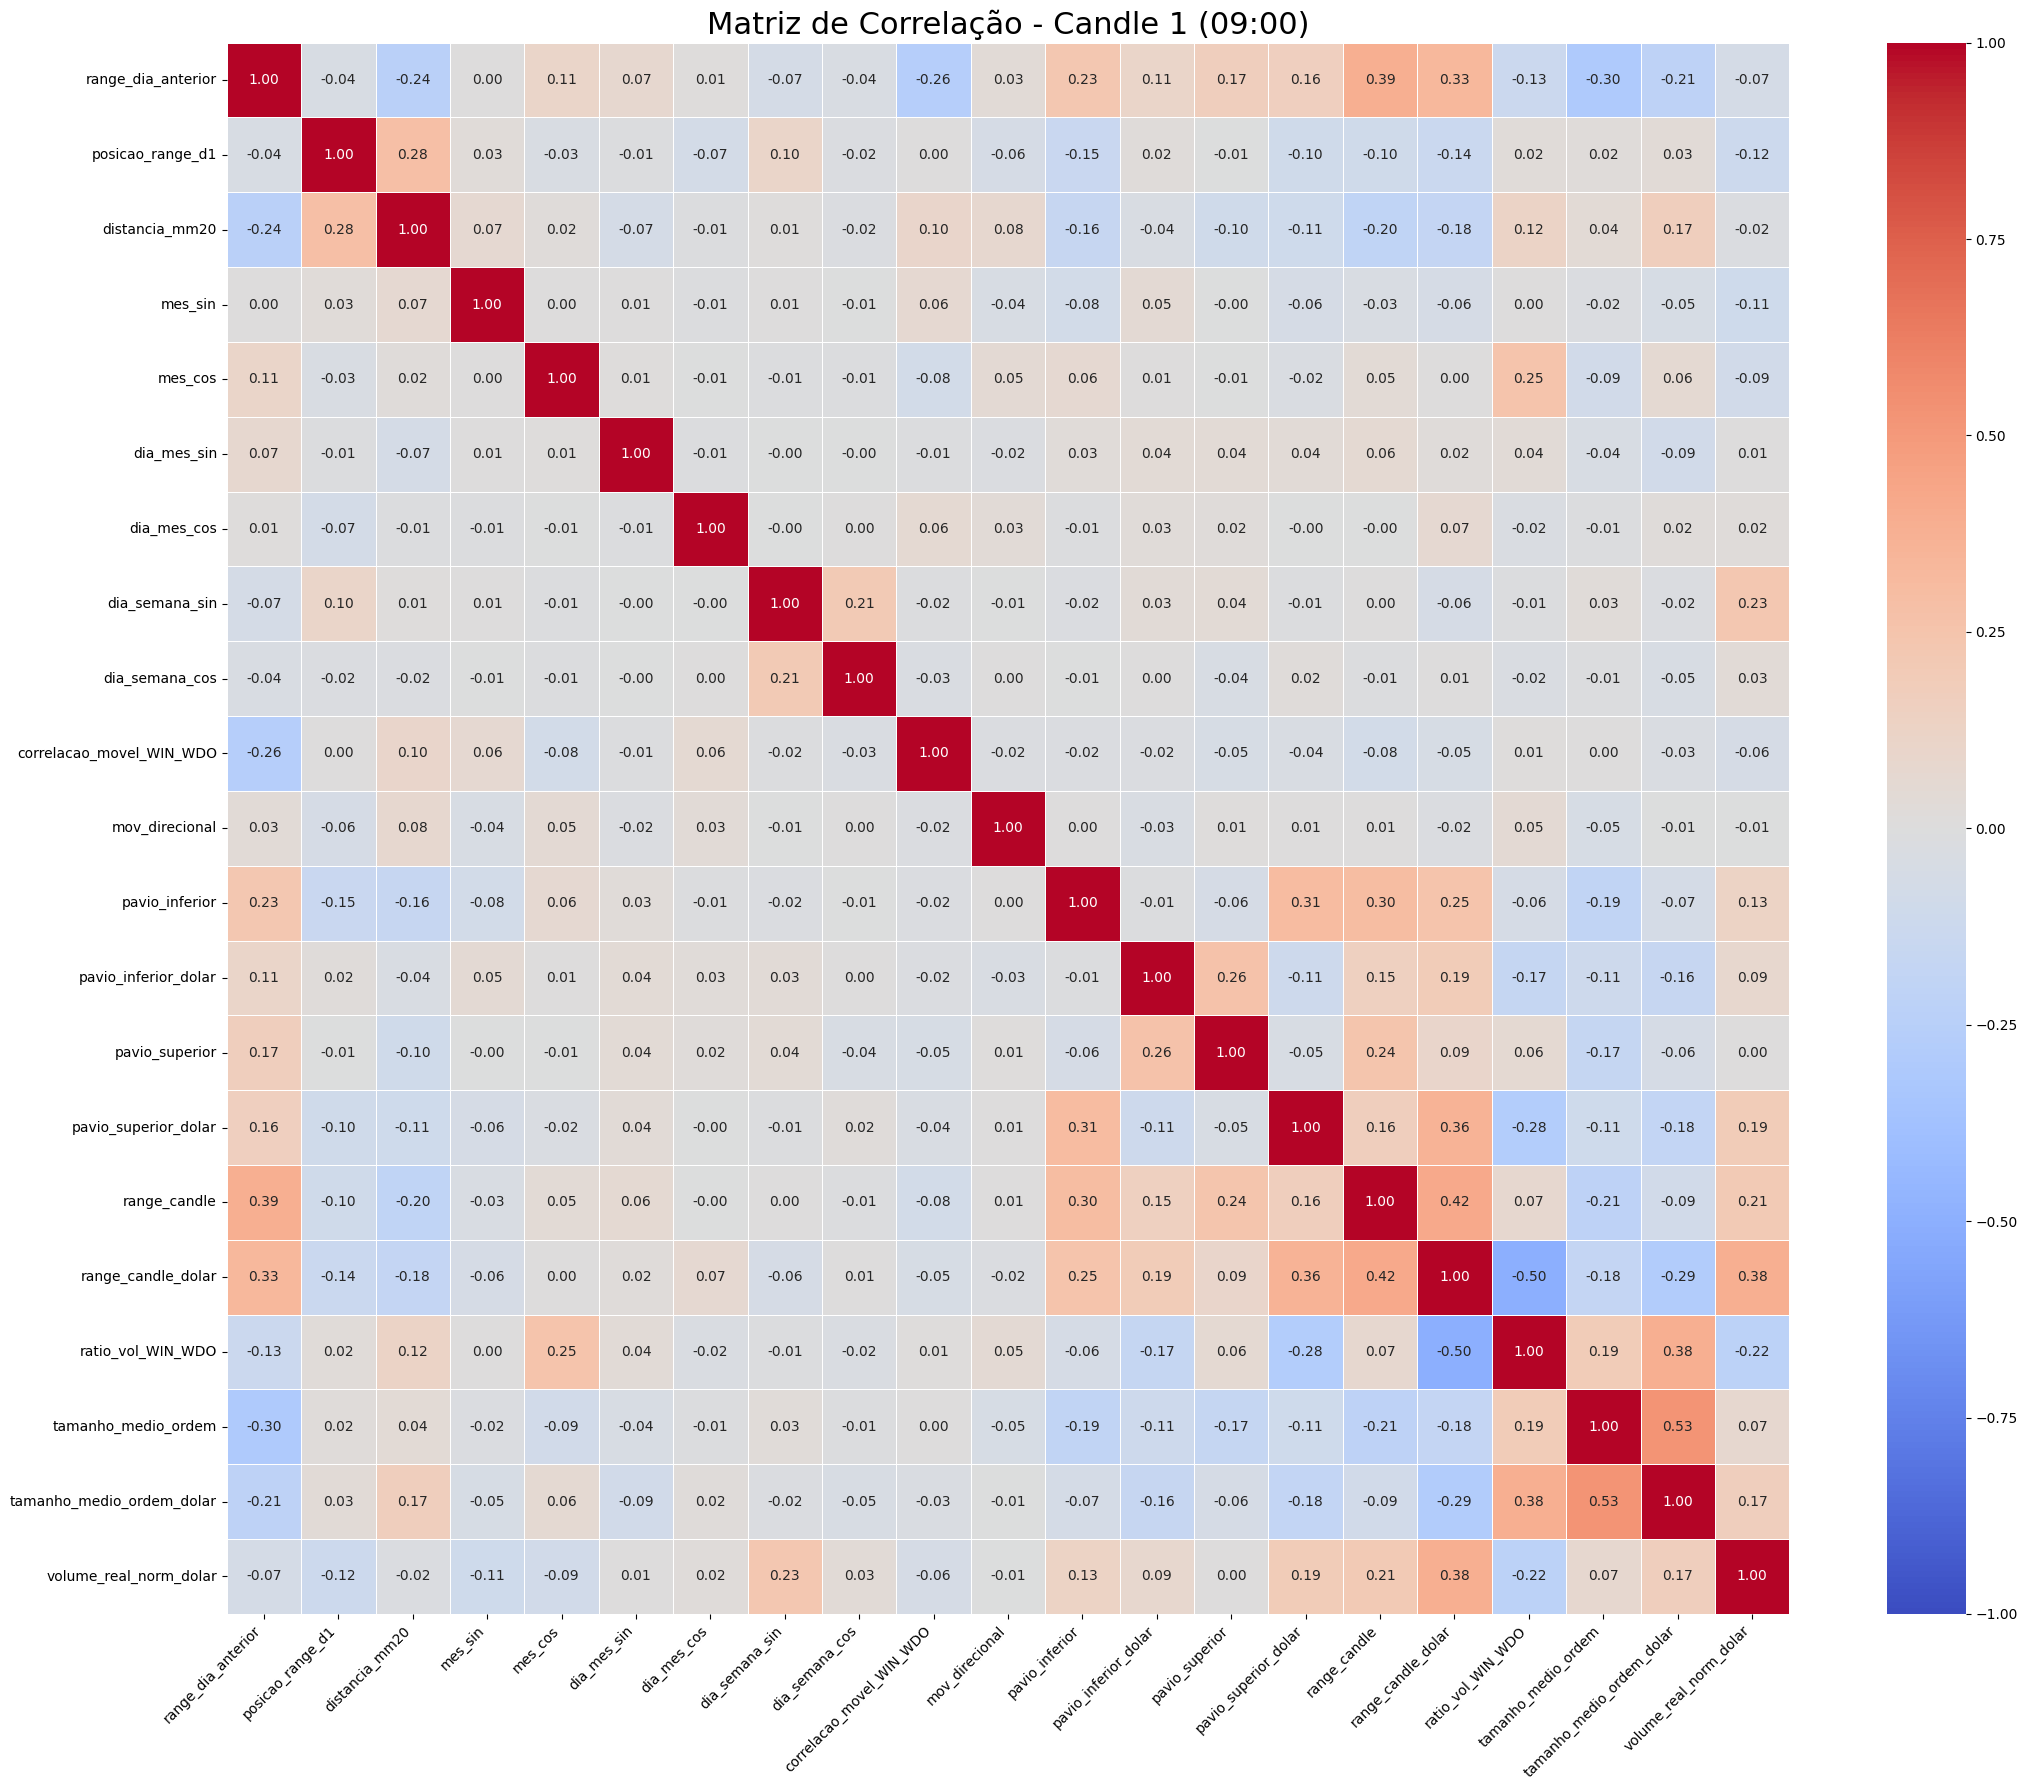


--- Processando Candle 2 ---


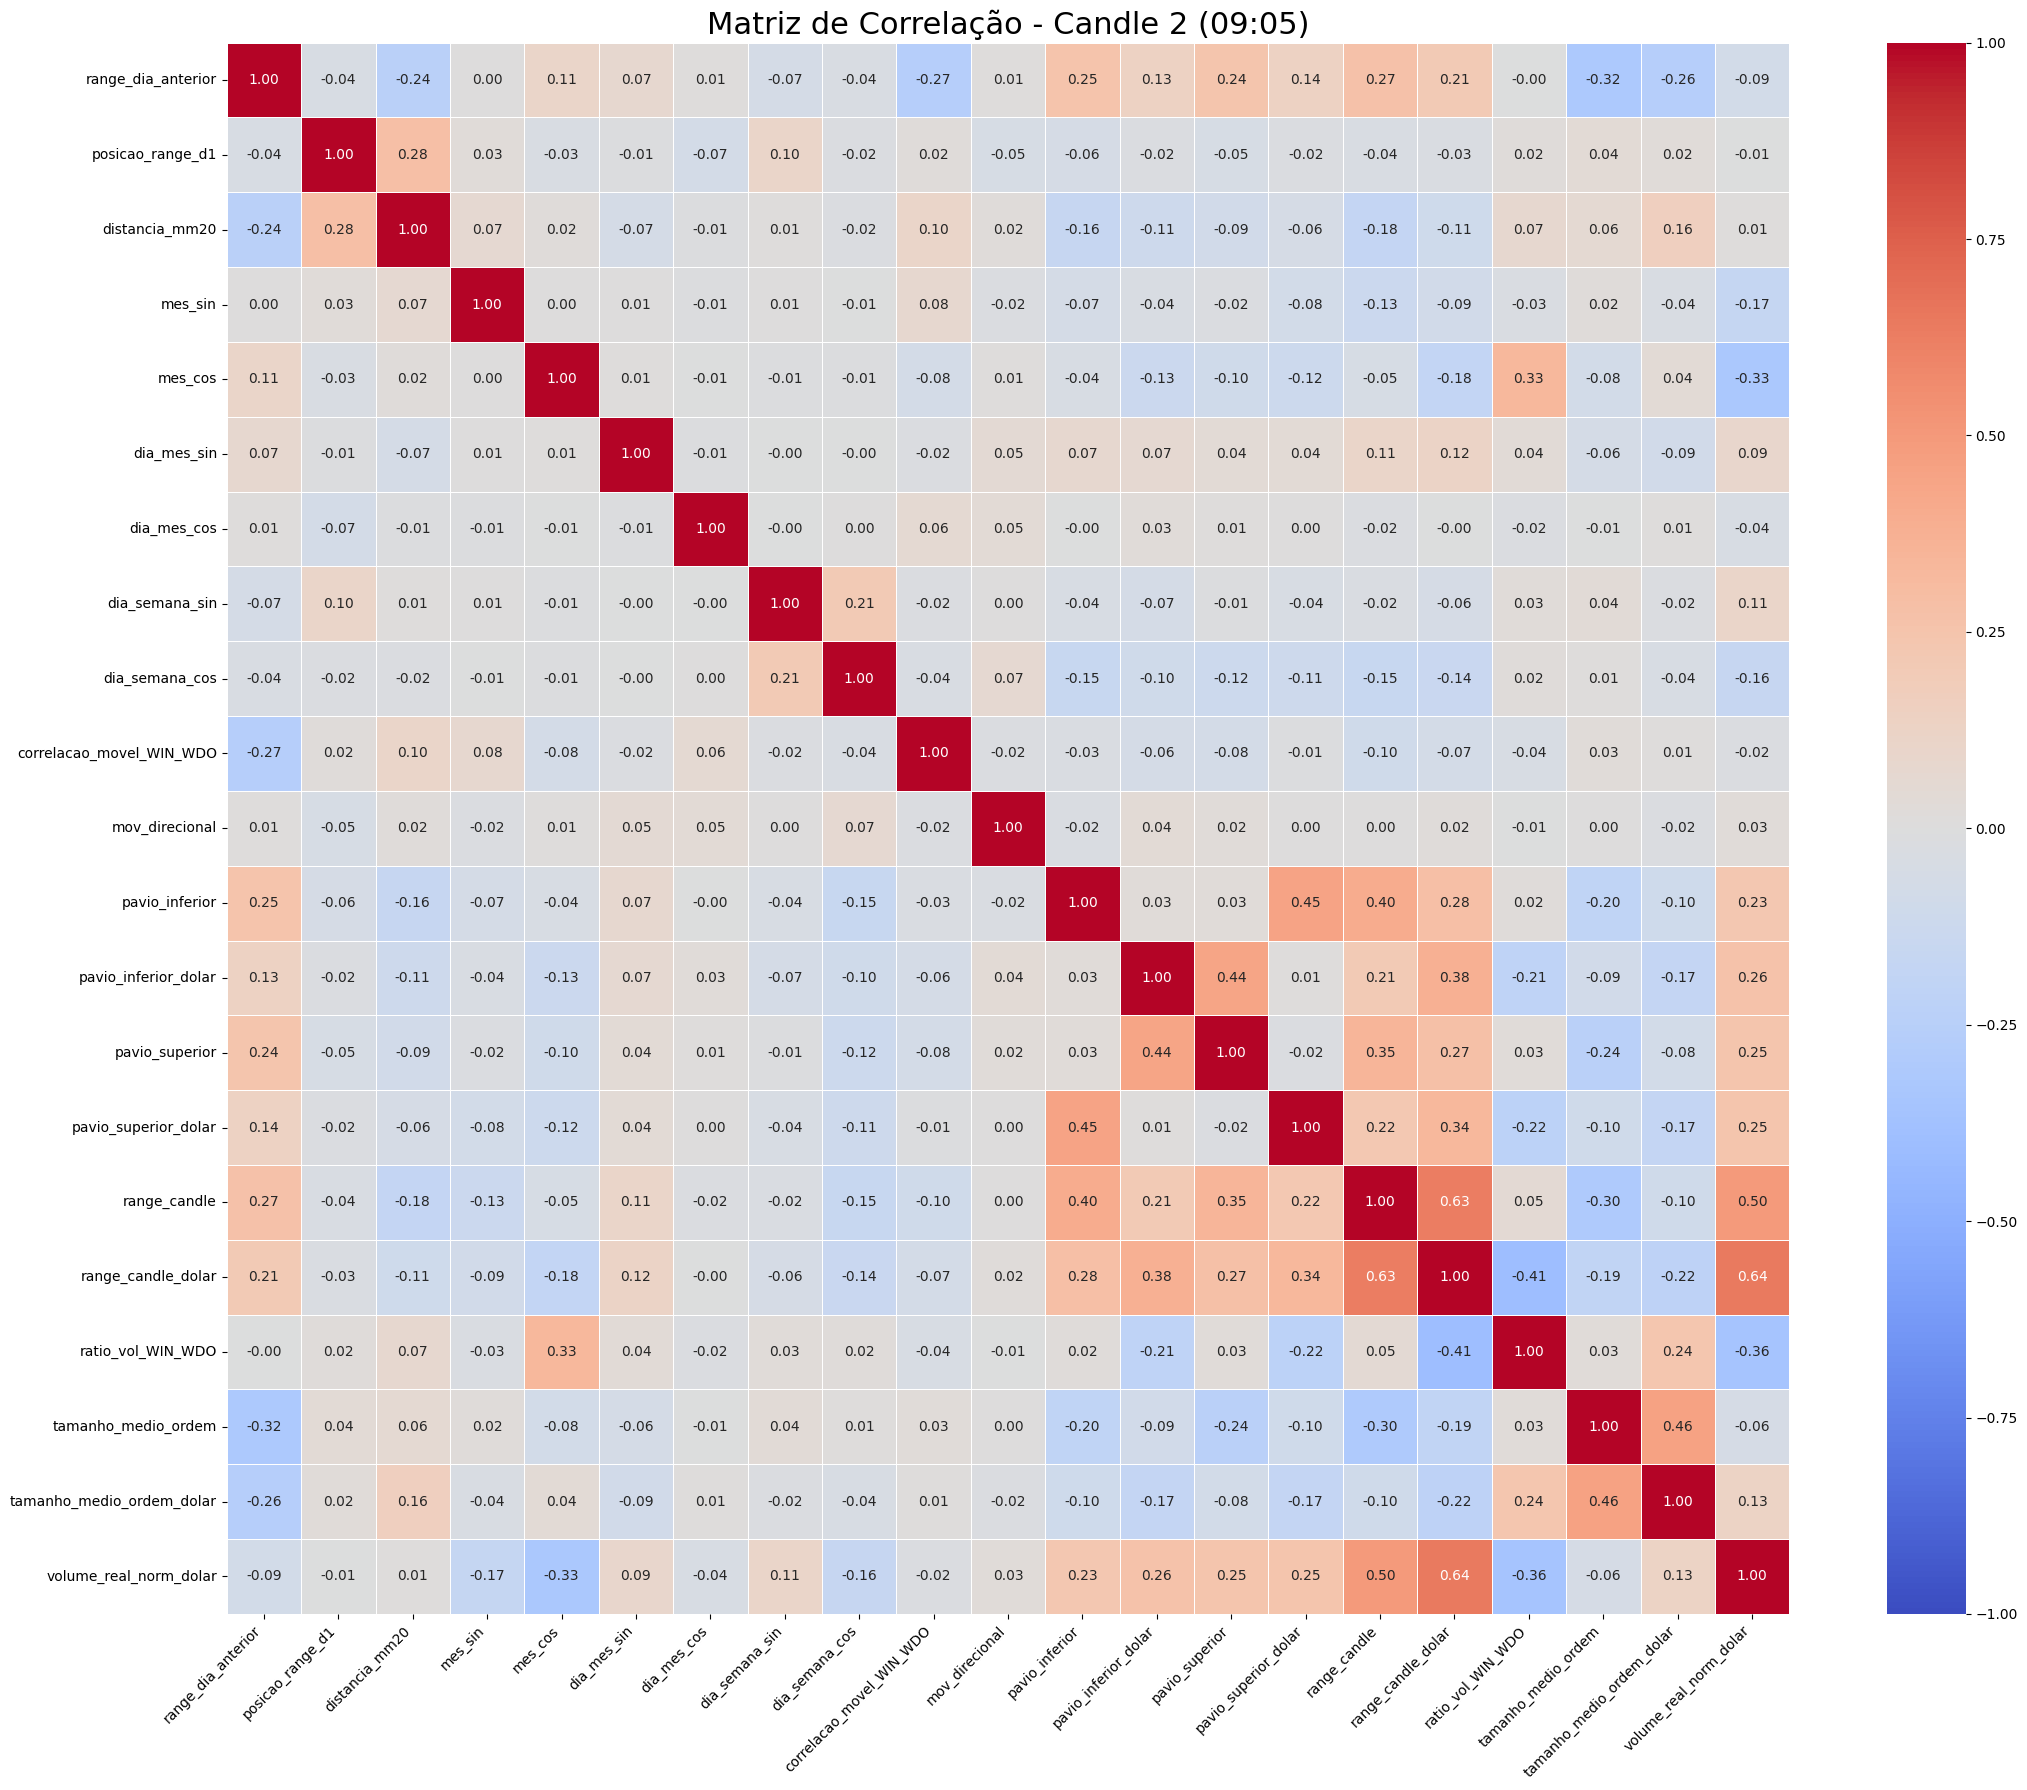


--- Processando Candle 3 ---


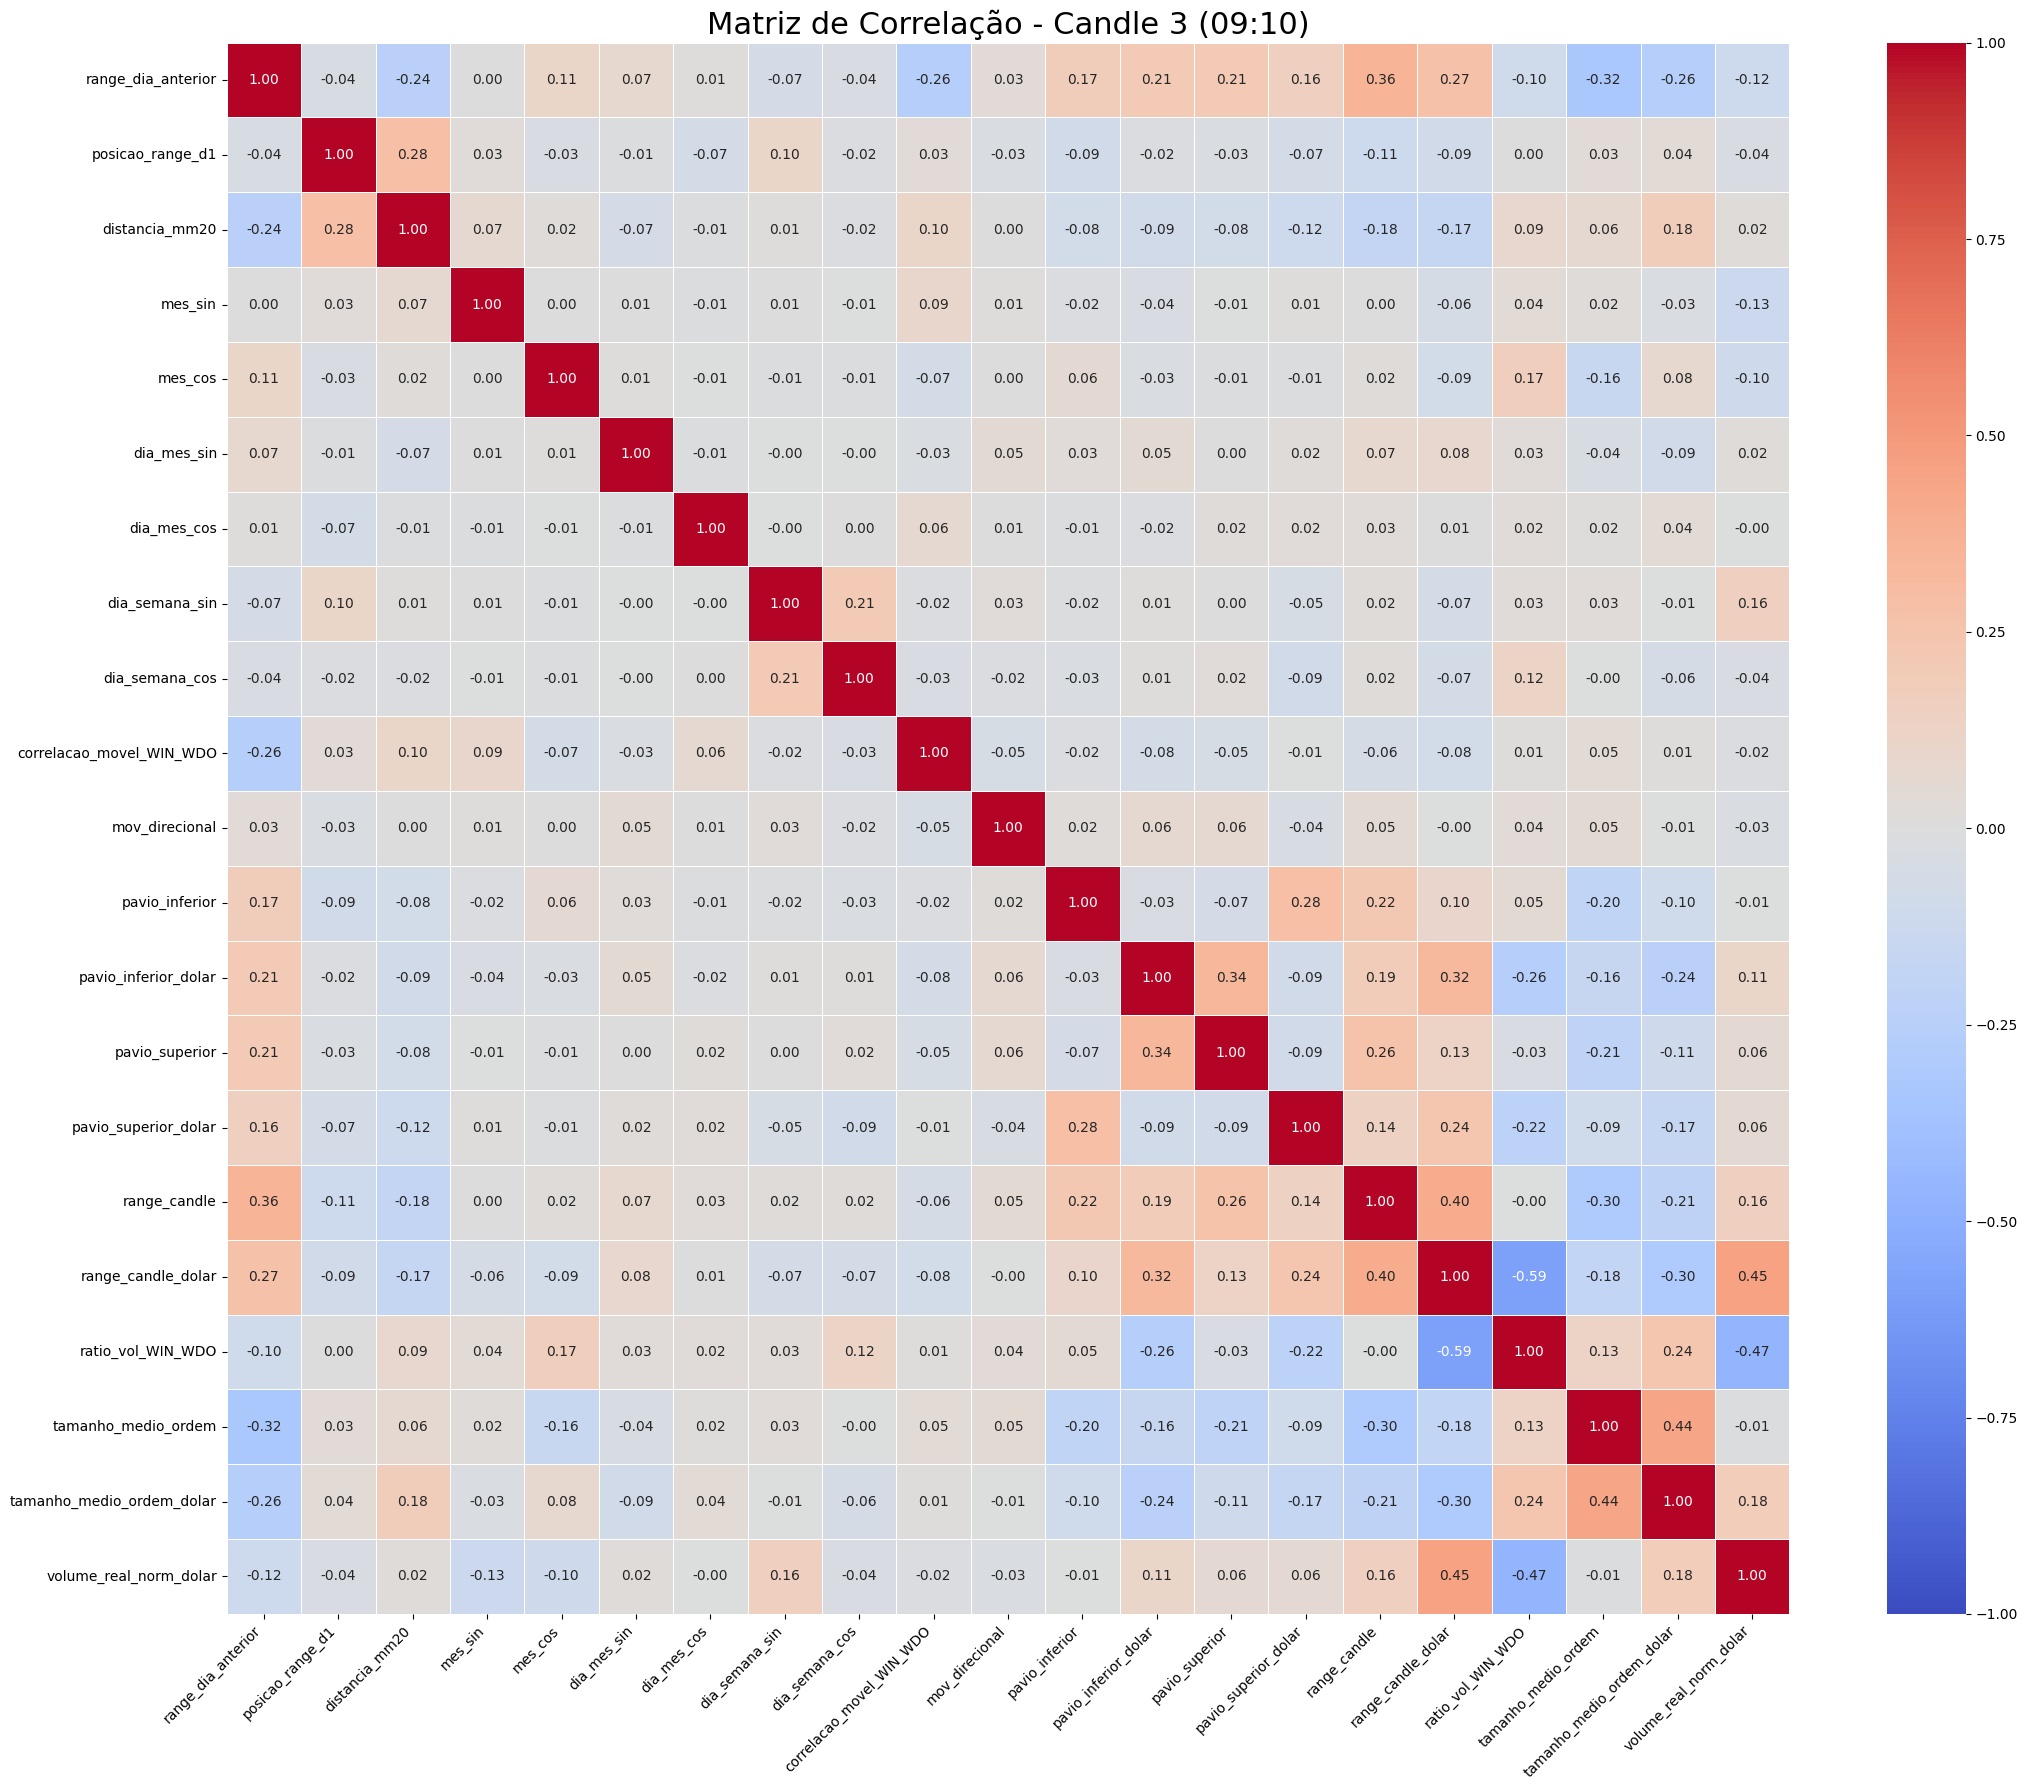


--- Processando Candle 4 ---


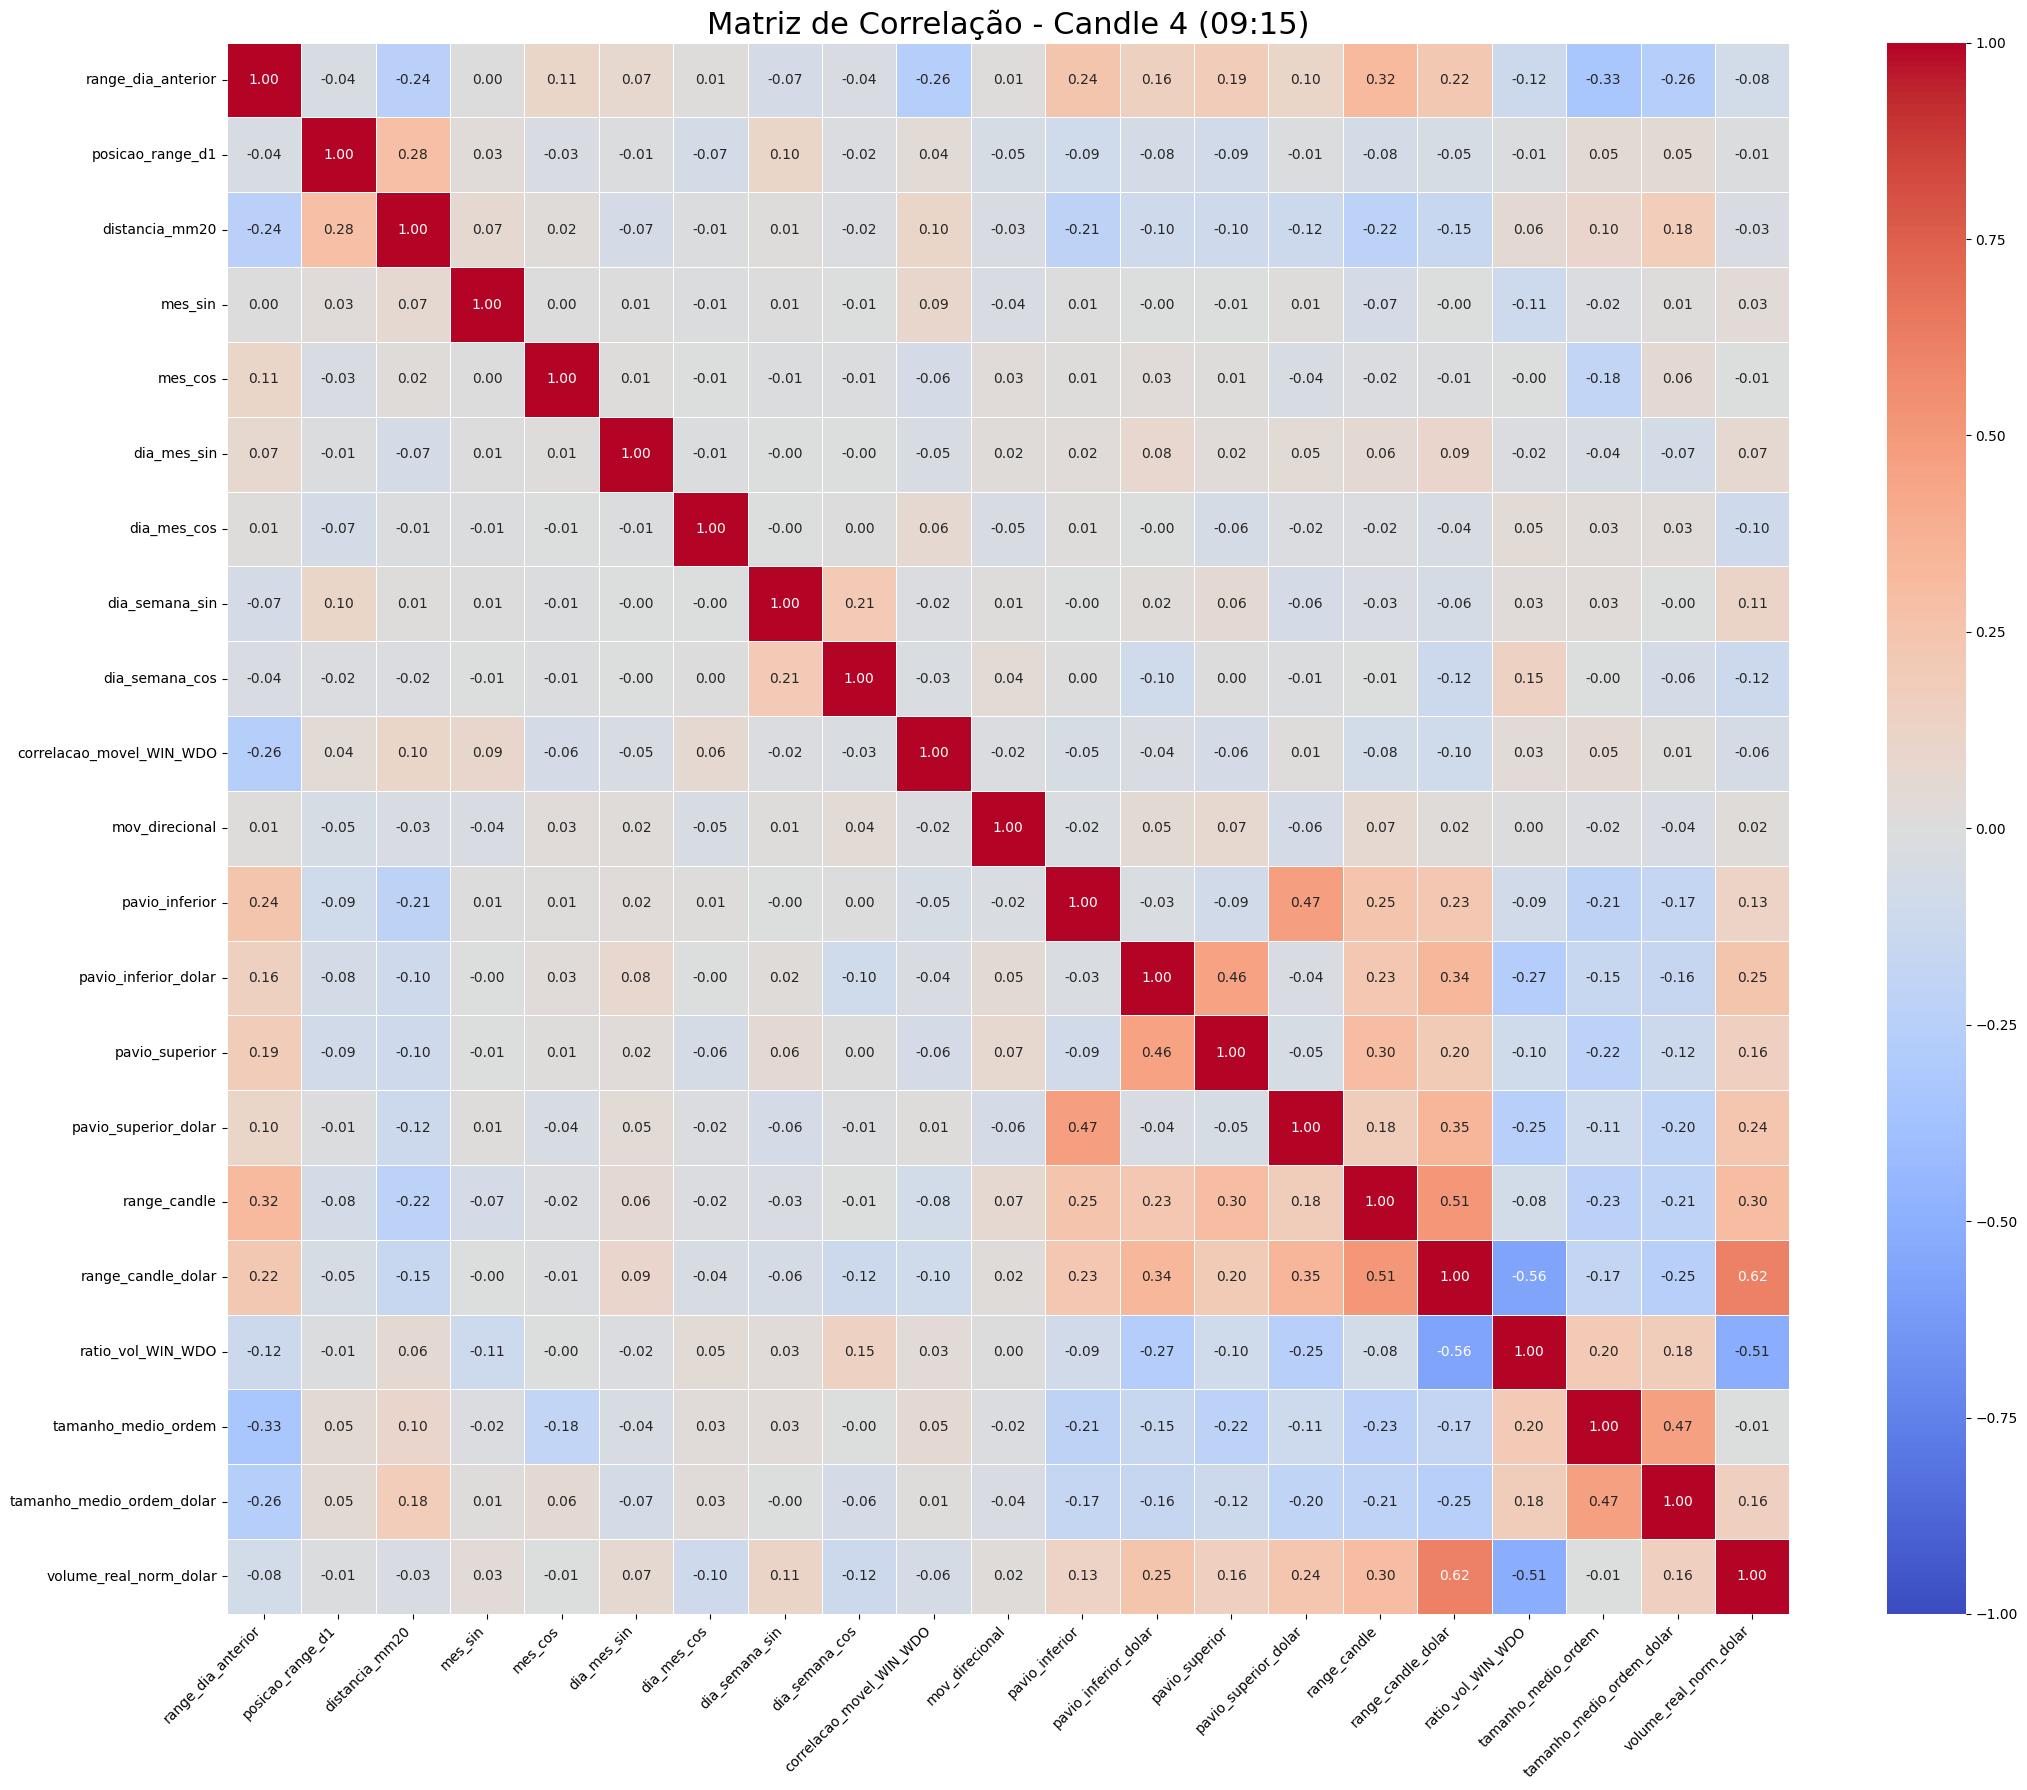


--- Análise de todas as velas concluída ---


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NUM_CANDLES_PARA_ANALISAR = 4 # Total de candles na sua janela de entrada (09:00 - 10:55)

# --- ETAPA 1: CARREGAR O DATASET FINAL ---
print(f"--- ETAPA 1: Carregando o dataset '{NOME_ARQUIVO_DATASET}' ---")
try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
    # Remove as colunas de label para a análise de correlação
    df_features = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])
    print("Dataset carregado com sucesso.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado. Execute o script de geração de dados primeiro.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o dataset: {e}")
    exit()

# --- ETAPA 2: IDENTIFICAR OS GRUPOS DE FEATURES (VERSÃO CORRIGIDA) ---
print("\n--- ETAPA 2: Identificando os diferentes tipos de features (com Regex) ---")

import re # Importa a biblioteca de expressões regulares

# Regex para encontrar colunas que terminam com _c<numero>, ex: _c1, _c24
regex_sequencial = re.compile(r'_c\d+$')

# Features de Contexto e Cíclicas são aquelas que NÃO correspondem ao padrão sequencial
colunas_contexto_ciclicas = [col for col in df_features.columns if not regex_sequencial.search(col)]

# Nomes base das features sequenciais
# Usamos um truque para pegar os nomes únicos antes do sufixo '_c<numero>'
nomes_base_sequenciais = sorted(list(set([regex_sequencial.sub('', col) for col in df_features.columns if regex_sequencial.search(col)])))

print(f"Features de Contexto/Cíclicas encontradas: {len(colunas_contexto_ciclicas)}")
print(f"Nomes base de Features Sequenciais encontrados: {len(nomes_base_sequenciais)}")
print("\nExemplos de Nomes Base Sequenciais:", nomes_base_sequenciais[:5])
print("Exemplos de Colunas de Contexto/Cíclicas:", colunas_contexto_ciclicas[:5])


# --- ETAPA 3: GERAR MATRIZ DE CORRELAÇÃO PARA CADA CANDLE ---
print("\n--- ETAPA 3: Gerando heatmaps de correlação para cada candle ---")

# Loop para cada candle de 1 a 24
for i in range(1, NUM_CANDLES_PARA_ANALISAR + 1):
    
    print(f"\n--- Processando Candle {i} ---")
    
    # Seleciona as colunas sequenciais para o candle atual
    colunas_sequenciais_candle_i = [f'{nome_base}_c{i}' for nome_base in nomes_base_sequenciais]
    
    # Junta as colunas de contexto com as sequenciais do candle atual
    colunas_para_analise = colunas_contexto_ciclicas + colunas_sequenciais_candle_i
    df_analise_candle = df_features[colunas_para_analise]
    
    # Renomeia as colunas sequenciais para remover o sufixo '_ci' para um gráfico mais limpo
    df_analise_candle.columns = colunas_contexto_ciclicas + nomes_base_sequenciais
    
    # Calcula a matriz de correlação
    corr_matrix = df_analise_candle.corr()
    
    # Gera o heatmap
    plt.figure(figsize=(22, 18))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        linewidths=.5,
        vmin=-1, vmax=1 # Fixa a escala de cores para comparação entre gráficos
    )
    
    # Calcula o horário do candle
    hora_inicio = 9
    minuto_inicio = (i - 1) * 5
    hora_final = hora_inicio + (minuto_inicio // 60)
    minuto_final = minuto_inicio % 60
    horario_str = f"{hora_final:02d}:{minuto_final:02d}"
    
    plt.title(f'Matriz de Correlação - Candle {i} ({horario_str})', fontsize=22)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

print("\n--- Análise de todas as velas concluída ---")


## Normalização

O que você fez ao dividir pelo `preço de abertura` foi o **Passo 1: Normalização de Domínio**. Agora você precisa fazer o **Passo 2: Normalização Estatística**.

Vamos entender a diferença e por que ambos são indispensáveis.

### A Diferença entre as Duas Normalizações

**1. Normalização de Domínio (o que você já fez):**

*   **Objetivo:** Tornar os dados **comparáveis ao longo do tempo** e **estacionários**.
*   **Como:** Dividindo pelo preço (`open`).
*   **O que ela resolve:** O problema do preço do ativo mudar de 100.000 para 150.000 ao longo dos anos. Você transformou a pergunta de "quantos pontos o candle se moveu?" para "qual porcentagem do seu valor o candle se moveu?".
*   **Resultado:** Features como `retorno_candle`, `range_candle`, etc., que agora são consistentes em diferentes regimes de preço.

**O Problema que Permanece:**
Mesmo após essa normalização, suas features ainda vivem em **escalas diferentes umas das outras**.

*   `retorno_candle` pode variar, por exemplo, de -0.005 a +0.005.
*   `RSI_14` (que você não dividiu por `open`) varia de 0 a 100.
*   `Volume_Real_Norm` pode variar de 0.5 a 5.0.

Para uma Rede Neural, um valor de `50.0` na coluna `RSI_14` é numericamente **muito maior** do que um valor de `0.005` na coluna `retorno_candle`.

**2. Normalização Estatística (o que você precisa fazer agora):**

*   **Objetivo:** Colocar todas as features na **mesma escala numérica**, para que a Rede Neural as trate com a mesma importância inicial.
*   **Como:** Usando `StandardScaler` ou `MinMaxScaler` do Scikit-learn.
*   **O que ela resolve:** O problema de uma feature (como o RSI) ter uma magnitude numérica muito maior que outra (como o retorno), o que faria o modelo dar um peso indevido a ela no início do treinamento.
*   **Resultado:** Todas as colunas do seu DataFrame de features (`X`) terão uma distribuição similar (ex: média 0 e desvio padrão 1 para `StandardScaler`, ou valores entre 0 e 1 para `MinMaxScaler`).

### Como e Quando Aplicar a Segunda Normalização

1.  **Divida seus Dados:** Antes de tudo, separe seu conjunto de dados `X` e `Y` em conjuntos de **Treino** e **Teste**. É crucial que o conjunto de teste permaneça "intocado".

2.  **Ajuste o Scaler APENAS nos Dados de Treino:**
    ```python
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split

    # Supondo que X é seu df_features_X e Y são seus labels
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    scaler = StandardScaler()

    # Ajusta (calcula a média e o desvio padrão) APENAS nos dados de treino
    X_train_scaled = scaler.fit_transform(X_train)
    ```

3.  **Transforme os Dados de Teste (e futuros dados reais):**
    ```python
    # Usa a média e o desvio padrão JÁ CALCULADOS no treino para transformar os dados de teste
    X_test_scaled = scaler.transform(X_test)
    ```
    Isso evita o "vazamento de dados" (data leakage), garantindo que nenhuma informação do conjunto de teste influencie o treinamento.

**Conclusão:** A normalização que você já fez foi essencial para a **validade temporal** das suas features. A segunda normalização, com `StandardScaler`, é essencial para a **convergência e estabilidade** do treinamento da sua Rede Neural. Ambas são etapas indispensáveis e não redundantes.

## Padronizar ou normalizar?

"Padronização" e "Normalização" são dois dos termos mais confundidos no pré-processing de dados, mas eles se referem a duas transformações matemáticas distintas com objetivos diferentes.

A resposta curta e direta para o seu caso (e para a maioria das aplicações de Redes Neurais) é:

**A Padronização (`StandardScaler`) é quase sempre a melhor escolha.**

### Normalização (Min-Max Scaling)

*   **O que faz?** Transforma os dados para que eles fiquem em um intervalo fixo, geralmente entre **0 e 1** (ou -1 e 1).
*   **Fórmula:** `X_norm = (X - X_min) / (X_max - X_min)`
*   **Quando é útil?** É útil para algoritmos que esperam que os dados estejam em uma escala fixa e bem definida, como algumas técnicas de processamento de imagem ou algoritmos que calculam distâncias e não são robustos a outliers.

*   **Principal Desvantagem (A Razão para NÃO Usar Aqui):** A Normalização é **extremamente sensível a outliers**. Imagine que sua feature `RSI` normalmente varia entre 20 e 80. Se, por algum erro ou evento extremo, você tiver um único valor de 200 em seu conjunto de treino, o `X_max` se tornará 200. Isso fará com que todos os seus outros valores "normais" (entre 20 e 80) sejam espremidos em um intervalo muito pequeno (ex: entre 0.1 e 0.4). A variação original e importante entre 20 e 80 é perdida, e o outlier domina completamente a escala.

### Padronização (Standardization / Z-score Normalization)

*   **O que faz?** Transforma os dados para que eles tenham uma **média de 0** e um **desvio padrão de 1**.
*   **Fórmula:** `X_std = (X - média) / desvio_padrão`
*   **Quando é útil?** É a técnica de pré-processamento padrão para a maioria dos algoritmos de Machine Learning, incluindo **Redes Neurais**, SVMs e Regressão Logística.

*   **Principais Vantagens (A Razão para USAR Aqui):**
    1.  **Robustez a Outliers:** A Padronização não tem um limite superior ou inferior fixo. Se um outlier aparecer, ele será transformado em um valor alto (ex: 4.0 ou 5.0), mas ele **não espremerá** o resto dos seus dados. A distribuição relativa entre os pontos "normais" é preservada. Isso é muito mais seguro para dados financeiros, que são cheios de eventos extremos.
    2.  **Alinhamento com a Otimização da Rede Neural:** As funções de ativação das redes neurais (como ReLU, Tanh) e os algoritmos de otimização (como Adam) funcionam de forma mais estável e eficiente quando os dados de entrada estão centrados em torno de zero e têm uma variância semelhante. A Padronização coloca os dados exatamente nesse "ponto ideal" para o treinamento.
    3.  **Preserva a Informação da Distribuição:** Ao contrário da Normalização, que força tudo para um intervalo, a Padronização mantém a forma da distribuição original dos seus dados.


## Remoção de outliers
**Não é correto e é uma prática perigosa para dados financeiros.**

Remover outliers em dados financeiros é como arrancar as páginas de um livro de história que falam sobre guerras ou crises econômicas. Você pode ter uma história mais "agradável", mas ela não representa mais a realidade e não te prepara para o futuro.

### O que é um "Outlier" em Dados Financeiros?

Em muitos campos da ciência (ex: medições de laboratório), um outlier é frequentemente um **erro de medição**. Um sensor com defeito, um erro de digitação, etc. Nesses casos, remover o outlier é a coisa certa a se fazer.

No mercado financeiro, um outlier quase nunca é um erro. Ele é um **evento extremo, mas real**.
*   Um "flash crash".
*   A divulgação de uma notícia de alto impacto (ex: decisão de juros, dados de inflação).
*   O início de uma crise geopolítica.
*   Um "circuit breaker" sendo acionado.

Esses eventos são a **essência da volatilidade e do risco** do mercado. Eles são os momentos em que mais se ganha ou mais se perde dinheiro.

### Por que Remover Outliers Financeiros é Perigoso?

1.  **Cria um Modelo "Míope" e Frágil:** Se você treinar seu modelo apenas com dias "normais" e bem-comportados, ele aprenderá a operar muito bem em um mercado calmo. No entanto, no primeiro dia em que ocorrer um evento extremo (um outlier), o modelo não terá a menor ideia de como reagir. Ele verá valores de features que estão completamente fora da escala que ele já viu, e sua previsão será, na melhor das hipóteses, aleatória e, na pior, desastrosa.

2.  **Perda de Informação Valiosa:** Os outliers contêm informações cruciais sobre a dinâmica do mercado sob estresse. Eles ensinam ao modelo sobre:
    *   **Reversões de pânico:** Como o mercado se comporta no fundo de uma queda acentuada.
    *   **Clímax de euforia:** Como o mercado se comporta no topo de uma alta parabólica.
    *   **A verdadeira natureza do risco:** Os outliers definem os limites do que é "possível" no mercado.

3.  **Invalida o Backtest:** Seu modelo parecerá ter um desempenho fantástico no backtest, porque você removeu todos os dias difíceis. Isso cria uma falsa sensação de segurança. Quando você colocar o modelo para rodar em tempo real, ele inevitavelmente encontrará um desses dias "outlier" e poderá sofrer perdas catastróficas que seu backtest não previu.

### A Abordagem Correta: Usar Ferramentas Robustas a Outliers

Em vez de remover os outliers, a estratégia correta é usar técnicas de pré-processamento e modelagem que sejam **robustas** a eles. E você já está fazendo isso!

1.  **Padronização (`StandardScaler`):** Como discutimos, a padronização é robusta a outliers. Ela não "espreme" os dados normais por causa de um valor extremo. Ela simplesmente atribui ao outlier um valor de Z-score alto (ex: 4, 5 ou mais), sinalizando para a rede: "Ei, este evento foi 4 desvios padrão acima da média, preste atenção!".

2.  **Funções de Ativação Não-Lineares (ReLU):** A função ReLU em suas camadas densas ajuda a lidar com a magnitude das entradas.

3.  **Regularização (Dropout):** Ajuda a prevenir que o modelo se ajuste demais a exemplos específicos, incluindo os outliers, forçando-o a aprender padrões mais gerais.


# Qual tipo de rna e a mais apropriado
Dado que seus dados de entrada (`X`) são uma **sequência de 24 candles**, onde a ordem e as relações entre eles são cruciais, a arquitetura mais apropriada **não é uma Rede Neural Densa (MLP) simples**. Você precisa de uma arquitetura projetada especificamente para aprender com sequências.

**Não use uma Rede Densa (MLP) simples.** Ela "achataria" seu vetor de 240 features e perderia completamente a estrutura sequencial e a relação de vizinhança entre os candles, que são a informação mais importante que você tem.

As duas arquiteturas mais apropriadas e poderosas para este projeto são as **Redes Neurais Convolucionais (CNNs)** e as **Redes Neurais Recorrentes (LSTMs)**. A combinação de ambas é frequentemente a mais poderosa.

## Opção 1: Rede Neural Convolucional 1D (CNN)

*   **Como Funciona?** Pense em uma CNN como um "detector de padrões locais". Ela usa "filtros" (ou kernels) que deslizam sobre a sua sequência de 24 candles. Cada filtro é treinado para reconhecer um padrão específico e de curto prazo.
    *   Um filtro pode aprender a identificar um padrão de "engolfo de alta" que ocorre em 2 candles.
    *   Outro filtro pode aprender a reconhecer um "pico de volume seguido de reversão" que ocorre em 3 candles.
    *   Outro pode aprender a identificar uma "sequência de 3 candles de baixa com pavios superiores longos".
*   **Vantagens para o seu Projeto:**
    1.  **Eficiência Computacional:** São muito mais rápidas de treinar do que as LSTMs.
    2.  **Excelentes em Padrões Locais:** São as melhores em identificar padrões gráficos de curto prazo (padrões de candle, formações de preço) que ocorrem em pequenas janelas dentro da sua sequência de 24 candles.
    3.  **Hierarquia de Features:** Ao empilhar camadas convolucionais, a rede pode aprender a combinar padrões simples em padrões mais complexos. A primeira camada aprende padrões de 2-3 candles, e a segunda camada pode aprender a reconhecer uma sequência desses padrões.
*   **Desvantagens:**
    1.  **Menos Sensível a Relações de Longo Prazo:** Elas não têm uma "memória" explícita. Podem ter dificuldade em relacionar um evento no primeiro candle (09:00) com um evento no último candle (10:55) se a relação for muito sutil.

## Opção 2: Rede Neural Recorrente (LSTM - Long Short-Term Memory)

*   **Como Funciona?** Pense em uma LSTM como um "analista com memória". Ela processa a sua sequência de 24 candles um por um, em ordem cronológica. A cada candle que ela "lê", ela atualiza seu "estado de memória", decidindo o que é importante lembrar do passado e o que pode ser esquecido.
    *   Ao ler o candle 1 (09:00), ela guarda na memória: "o dia começou com um gap de alta e volume forte".
    *   Ao ler o candle 10 (09:45), ela pode atualizar sua memória: "a tendência de alta inicial perdeu força e agora está andando de lado".
    *   Ao ler o candle 24 (10:55), ela tem um resumo contextual de toda a história da manhã, que ela usa para fazer a previsão.
*   **Vantagens para o seu Projeto:**
    1.  **Projetada para Sequências:** É a arquitetura canônica para dados de séries temporais. Sua estrutura interna foi criada para capturar dependências temporais.
    2.  **Excelente em Relações de Longo Prazo:** É a melhor em entender como o contexto do início da manhã (09:00) influencia o final da janela (10:55).
*   **Desvantagens:**
    1.  **Computacionalmente Mais Cara:** É significativamente mais lenta para treinar.
    2.  **Pode se Perder em Detalhes:** Às vezes, pode dar muito peso a eventos recentes e "esquecer" padrões locais importantes que uma CNN capturaria melhor.

## Opção 3 (A Melhor): Arquitetura Híbrida CNN-LSTM

*   **Como Funciona?** Esta abordagem combina o melhor dos dois mundos.
    1.  **Camada CNN primeiro:** A sequência de 24 candles primeiro passa por uma ou duas camadas de CNN 1D. O trabalho da CNN é atuar como um "extrator de features inteligente", identificando os padrões gráficos locais (engolfos, picos de volume, etc.) e transformando a sequência de candles brutos em uma sequência de "eventos de mercado" de alto nível.
    2.  **Camada LSTM depois:** A sequência de "eventos" gerada pela CNN é então alimentada na LSTM. O trabalho da LSTM é analisar a **sequência desses eventos** e entender a narrativa temporal. Por exemplo: "um padrão de 'pico de volume' (detectado pela CNN) seguido por um padrão de 'consolidação' (detectado pela CNN) geralmente leva a um movimento de alta".
*   **Vantagens:**
    1.  **Sinergia:** A CNN extrai os padrões locais de forma eficiente, e a LSTM modela as dependências temporais entre esses padrões.
    2.  **Estado da Arte:** Esta é frequentemente a arquitetura de melhor desempenho para problemas de classificação de séries temporais como o seu.

# Configuração do rna
## Dropout
Dropout é uma das técnicas mais importantes e eficazes para treinar redes neurais, especialmente para prevenir o overfitting. A ideia, embora simples, é extremamente poderosa.

### 1. O Problema: Overfitting (Superajuste)

Primeiro, vamos entender o problema que o Dropout resolve.

Imagine que você está treinando sua RNA para prever os padrões do mercado. Durante o treinamento, a rede ajusta seus milhões de parâmetros (os pesos das conexões) para minimizar o erro nos dados históricos que você forneceu.

O **overfitting** acontece quando a rede fica **boa demais** em prever os dados de treino. Ela não aprende os padrões gerais do mercado; em vez disso, ela praticamente **memoriza** os exemplos específicos do seu conjunto de dados, incluindo o ruído e as coincidências aleatórias.

**A consequência:**
*   O modelo tem um desempenho espetacular nos dados de treino (ex: 99% de acerto).
*   Quando você o coloca para operar com dados novos, do mundo real, que ele nunca viu, o desempenho é terrível. Ele não consegue generalizar.

É como um aluno que decora o gabarito da prova em vez de aprender a matéria. Ele tira 10 na lista de exercícios, mas zera na prova final.

### 2. A Causa do Overfitting: Co-adaptação Complexa

Uma das principais causas do overfitting é um fenômeno chamado **"co-adaptação complexa"**.

Isso acontece quando os neurônios na rede neural desenvolvem uma dependência excessiva uns dos outros. Por exemplo, um neurônio pode aprender a corrigir os erros de outro neurônio. Um pequeno grupo de neurônios pode se tornar "especialista" em detectar um padrão muito específico que só apareceu nos dados de treino.

Essa colaboração excessiva torna a rede muito rígida e frágil. Se um desses neurônios "especialistas" recebe um dado ligeiramente diferente do que ele foi treinado para ver, todo o complexo sistema de dependências pode falhar.

### 3. A Solução: Dropout (Abandono)

O Dropout combate isso de uma maneira brutalmente simples: **durante cada etapa do treinamento, ele desliga (zera) aleatoriamente uma fração dos neurônios de uma camada.**

Vamos usar o seu exemplo: `Dropout(0.3)`.

*   Você coloca uma camada de `Dropout(0.3)` logo após uma camada oculta com, digamos, 100 neurônios.
*   A cada lote de dados de treino que passa pela rede, o Dropout "sorteia" e **desliga temporariamente 30% (ou seja, 30) dos neurônios** dessa camada. A saída deles se torna zero.
*   A informação flui para a próxima camada usando apenas os 70 neurônios restantes.
*   **Importante:** No próximo lote de dados, um **novo conjunto aleatório** de 30 neurônios é desligado.

### 4. Por que Isso Funciona?

1.  **Força a Independência:** Como um neurônio nunca sabe quais de seus "colegas" estarão ativos na próxima vez, ele não pode depender de nenhum deles. Cada neurônio é forçado a aprender a extrair características úteis por conta própria. Ele precisa ser mais robusto e contribuir de forma independente para o resultado final.

2.  **Cria Redes Menores e Diversificadas:** Em cada etapa de treino, o Dropout efetivamente treina uma rede neural diferente, "mais magra". Ao longo de todo o processo de treinamento, é como se você estivesse treinando uma média de milhares de redes neurais diferentes e menores. Essa "média de modelos" (ensemble) é uma técnica comprovada para melhorar a generalização e reduzir o overfitting.

3.  **Regularização:** O Dropout age como uma forma de **regularização**, que é o termo técnico para qualquer técnica que impede o modelo de se tornar complexo demais. Ele adiciona ruído ao processo de aprendizado, forçando o modelo a aprender apenas os padrões mais fortes e consistentes, ignorando as coincidências aleatórias.

**Importante:** O Dropout só é ativo durante o **treinamento**. Quando você usa o modelo para fazer previsões (`model.predict()`) ou para avaliar (`model.evaluate()`), todos os neurônios são usados automaticamente. A biblioteca cuida disso para você.

Em resumo, o Dropout é uma ferramenta indispensável que torna suas redes neurais mais robustas e generalizáveis, forçando-as a aprender de uma maneira mais inteligente e menos dependente.

## A função `softmax`
É a escolha padrão para a camada de saída em problemas de classificação multiclasse por três motivos principais e interligados:

1.  **Converte Saídas em Probabilidades Intuitivas.**
2.  **Garante que a Soma das Probabilidades seja 1.**
3.  **Funciona Perfeitamente com a Função de Perda Correta (Cross-Entropy).**

Vamos detalhar cada um desses pontos.

### O Cenário: Antes do Softmax

Imagine a sua rede neural. Após passar por todas as camadas ocultas, a última camada (antes da função de ativação) produzirá valores brutos, chamados **logits**. Para o seu problema de 3 classes (Compra, Venda, Lateralidade), você terá 3 neurônios na camada de saída, cada um produzindo um logit.

Esses logits podem ser quaisquer números reais, positivos ou negativos. Por exemplo:

*   Neurônio "Compra": `2.7`
*   Neurônio "Venda": `-1.3`
*   Neurônio "Lateralidade": `0.9`

O que esses números significam? `2.7` é o maior, então talvez a rede "pense" que é uma compra? Mas quão confiante ela está? É uma probabilidade de 2.7%? Não. Esses números brutos não são fáceis de interpretar.

É aqui que o `softmax` entra.

### 1. Converte Saídas em Probabilidades Intuitivas

A função `softmax` pega esse vetor de logits `[2.7, -1.3, 0.9]` e o transforma em um vetor de probabilidades, onde cada valor está entre 0 e 1.

A fórmula matemática para cada neurônio é:

`Probabilidade(i) = e^(logit_i) / (Soma de todos os e^(logit_j))`

*   **`e^(logit)` (Função Exponencial):** O primeiro passo é aplicar a função exponencial (`e^x`) a cada logit. Isso tem duas vantagens:
    *   **Torna todos os valores positivos:** Mesmo o logit `-1.3` se tornará um número positivo (`e^-1.3 ≈ 0.27`). Probabilidades não podem ser negativas.
    *   **Amplifica as diferenças:** A função exponencial cresce... exponencialmente! Isso significa que um logit que já é maior (como `2.7`) se tornará *muito* maior em comparação com os outros. Isso ajuda a rede a tomar uma decisão mais "confiante".

### 2. Garante que a Soma das Probabilidades seja 1

O segundo passo da fórmula é a **normalização**. Após calcular `e^(logit)` para cada neurônio, o `softmax` divide cada um desses valores pela soma de todos eles.

Isso força a soma de todas as saídas a ser exatamente **1 (ou 100%)**.

**Continuando nosso exemplo:**

1.  **Logits:** `[2.7, -1.3, 0.9]`
2.  **Aplicar `e^x`:**
    *   `e^2.7 ≈ 14.88`
    *   `e^-1.3 ≈ 0.27`
    *   `e^0.9 ≈ 2.46`
3.  **Soma Total:** `14.88 + 0.27 + 2.46 = 17.61`
4.  **Dividir pela Soma (Normalizar):**
    *   **Prob(Compra):** `14.88 / 17.61 ≈ 0.845`  (ou 84.5%)
    *   **Prob(Venda):** `0.27 / 17.61 ≈ 0.015`   (ou 1.5%)
    *   **Prob(Lateral):** `2.46 / 17.61 ≈ 0.140`   (ou 14.0%)

**Resultado Final:** `[0.845, 0.015, 0.140]`

Agora, a saída é extremamente clara e intuitiva: a rede está **84.5% confiante** de que o padrão é de **Compra**, 1.5% de que é Venda e 14.0% de que é Lateral. A soma é 100%.

### 3. Funciona Perfeitamente com a Função de Perda Cross-Entropy

Este é o ponto mais técnico, mas crucial para o treinamento.

Para treinar a rede, precisamos de uma **função de perda (loss function)** que meça o quão "errada" a previsão foi. Para classificação multiclasse, a função de perda ideal é a **Entropia Cruzada Categórica (Categorical Cross-Entropy)**.

A Entropia Cruzada funciona medindo a "distância" entre a distribuição de probabilidade que o modelo previu e a distribuição de probabilidade verdadeira (o gabarito).

*   **Previsão do Modelo (com softmax):** `[0.845, 0.015, 0.140]`
*   **Gabarito Verdadeiro (se a resposta era "Compra"):** `[1, 0, 0]`

A Entropia Cruzada calcula uma penalidade (erro) que é **muito alta** se o modelo atribui uma probabilidade baixa à classe correta (ex: se ele desse 0.01 para "Compra" quando a resposta era "Compra"). E a penalidade é **muito baixa** se ele atribui uma probabilidade alta à classe correta.

A matemática da Entropia Cruzada e do `softmax` se complementam perfeitamente, tornando o cálculo do gradiente (o ajuste dos pesos da rede) muito estável e eficiente. Elas foram projetadas para trabalhar em conjunto.

### Resumo: Por que não outras funções?

*   **Sigmoid:** É usada para classificação **binária** (sim/não, 0/1) ou **multilabel** (onde uma amostra pode pertencer a várias classes ao mesmo tempo, ex: um filme pode ser "Ação" E "Comédia"). Ela calcula a probabilidade de cada classe de forma independente, então a soma não precisa ser 1.
*   **ReLU ou Linear:** Elas não produzem probabilidades entre 0 e 1, tornando a saída não interpretável e incompatível com a função de perda de Entropia Cruzada.

Portanto, `softmax` é a escolha ideal porque transforma os logits brutos da sua rede em uma distribuição de probabilidade limpa, interpretável e matematicamente otimizada para o processo de treinamento de um classificador multiclasse.

## Função de perda (ou *loss function*) 
É talvez a parte mais importante do treinamento de uma rede neural. Ela é o "professor" que diz à rede o quão errada ela está e em que direção ela precisa se corrigir.

A **Entropia Cruzada Categórica (Categorical Cross-Entropy)** é a parceira perfeita para a `softmax` em problemas de classificação multiclasse. Vamos entender o porquê.

### 1. O Objetivo: Medir o Erro de uma Previsão de Probabilidade

Primeiro, qual é o nosso objetivo? Queremos uma função que meça o "erro" ou a "distância" entre dois objetos:

1.  **A Previsão do Modelo:** Uma distribuição de probabilidades gerada pela `softmax`. Ex: `[0.845, 0.015, 0.140]` para (Compra, Venda, Lateral).
2.  **O Gabarito Verdadeiro:** A resposta correta, também representada como uma distribuição de probabilidade. Ex: `[1, 0, 0]` (se a resposta correta era "Compra").

Não podemos simplesmente subtrair um do outro. Uma perda de `0.1` é boa ou ruim? Precisamos de uma medida mais inteligente, e é isso que a Entropia Cruzada faz.

### 2. A Intuição: Surpresa e Penalidade

A Entropia Cruzada vem da Teoria da Informação e pode ser entendida intuitivamente como uma medida de **"surpresa"**.

Imagine que você é a função de perda. Você sabe que a resposta correta é **Compra**.

*   **Cenário 1:** O modelo prevê `[0.95, 0.02, 0.03]`. Ele está 95% confiante na resposta certa. Você não fica "surpreso". A previsão foi boa. A penalidade (o erro/loss) deve ser **muito baixa**.

*   **Cenário 2:** O modelo prevê `[0.10, 0.60, 0.30]`. Ele está apenas 10% confiante na resposta certa e acha que a resposta mais provável é "Venda". Você fica muito "surpreso" com o quão errada foi a previsão. A penalidade deve ser **muito alta**.

A Entropia Cruzada formaliza matematicamente essa noção de "surpresa": **a perda é o quão surpreso você fica ao ver a probabilidade que o modelo atribuiu à classe que era, de fato, a correta.**

### 3. Como Funciona na Prática (Matemática Simplificada)

A fórmula da Entropia Cruzada para um único exemplo é:

`Loss = - ( y_compra * log(p_compra) + y_venda * log(p_venda) + y_lateral * log(p_lateral) )`

Onde:
*   `y` é o valor do gabarito verdadeiro (0 ou 1).
*   `p` é a probabilidade prevista pelo modelo (saída da softmax).
*   `log` é o logaritmo natural.

Vamos aplicar isso aos nossos cenários. Lembre-se que o gabarito é `[y_compra=1, y_venda=0, y_lateral=0]`.

Como `y_venda` e `y_lateral` são 0, a fórmula se simplifica para:

`Loss = - ( 1 * log(p_compra) ) = -log(p_compra)`

Agora, vamos ver o comportamento da função `-log(x)`:

*   Quando `x` (a probabilidade da classe correta) está perto de **1**, `log(x)` está perto de 0. A perda é **baixa**.
*   Quando `x` está perto de **0**, `log(x)` vai para o infinito negativo. Com o sinal de menos na frente, a perda se torna **infinitamente alta**.

**Aplicando aos Cenários:**

*   **Cenário 1 (Previsão Boa):** `p_compra = 0.95`.
    *   `Loss = -log(0.95) ≈ 0.05`. Uma perda muito pequena. O "professor" está satisfeito.

*   **Cenário 2 (Previsão Ruim):** `p_compra = 0.10`.
    *   `Loss = -log(0.10) ≈ 2.30`. Uma perda muito maior. O "professor" aplica uma grande penalidade.

*   **Cenário 3 (Previsão Horrível):** O modelo prevê `p_compra = 0.0001`.
    *   `Loss = -log(0.0001) ≈ 9.21`. Uma penalidade gigantesca!

Isso é exatamente o que queremos! A função de perda penaliza exponencialmente o modelo por estar confiante na resposta errada e o recompensa por estar confiante na resposta certa.

### 4. Por que é a Parceira Ideal da Softmax?

A combinação `Softmax + Cross-Entropy` é matematicamente elegante. Quando você calcula a derivada da perda em relação aos pesos da rede (o passo fundamental do backpropagation), muitas partes complexas da matemática se cancelam, resultando em um gradiente (a direção da correção) muito simples e estável.

Isso torna o treinamento mais rápido e menos propenso a problemas numéricos, como gradientes que explodem ou desaparecem.

### Resumo

| Função de Perda | Uso Típico | Como Funciona |
| :--- | :--- | :--- |
| **Mean Squared Error (MSE)** | Regressão (prever um número, como o preço) | Calcula a média dos quadrados das diferenças entre o valor real e o previsto. Penaliza grandes erros de forma quadrática. |
| **Binary Cross-Entropy** | Classificação Binária (0 ou 1) | Versão da Entropia Cruzada para apenas duas classes. Usada com a função de ativação `sigmoid`. |
| **Categorical Cross-Entropy** | Classificação Multiclasse (uma classe de várias) | Mede a "surpresa" da previsão de probabilidade do modelo em relação à classe verdadeira. Usada com a função de ativação `softmax`. |

Em suma, a Entropia Cruzada é a maneira mais eficaz de dizer à sua rede o quão errada foi sua distribuição de probabilidade, incentivando-a a atribuir a maior probabilidade possível à classe correta.

## One-Hot Encoding
Para preparar os dados de saída (labels) para o formato [1, 0, 0] (One-Hot Encoding)

### 1. O Problema: Por que não usar números simples?

A primeira ideia que pode surgir é simplesmente atribuir um número a cada categoria:

*   Compra = 0
*   Venda = 1
*   Lateralidade = 2

Isso é chamado de **Label Encoding**. Embora pareça simples, é uma **péssima ideia** para este problema, pois cria uma relação de ordem falsa que confunde a rede neural.

Ao usar `0, 1, 2`, você está implicitamente dizendo ao modelo que:
*   `Venda (1)` é maior que `Compra (0)`.
*   `Lateralidade (2)` é o dobro de `Venda (1)`.
*   A distância entre "Compra" e "Venda" é a mesma que entre "Venda" e "Lateralidade".

Isso não faz nenhum sentido! Não existe uma relação ordinal ou de magnitude entre essas categorias. O modelo tentará encontrar padrões nessa ordem numérica falsa, o que prejudicará severamente seu aprendizado.

### 2. A Solução: One-Hot Encoding

O One-Hot Encoding resolve esse problema criando um vetor binário para cada categoria. O vetor tem o mesmo tamanho do número total de classes. Ele é composto inteiramente de zeros, exceto por um único "1" na posição que corresponde à categoria específica.

**Como funciona para o seu caso (3 classes):**

1.  **Crie um vetor de tamanho 3** para representar as classes (Compra, Venda, Lateralidade).
2.  Para cada categoria, coloque um `1` na sua posição correspondente e `0` nas outras.

| Categoria (Label) | Vetor One-Hot Encoded |
| :--- | :--- |
| **Compra** | `[1, 0, 0]` |
| **Venda** | `[0, 1, 0]` |
| **Lateralidade** | `[0, 0, 1]` |

### 3. Por que Isso é Perfeito para a Rede Neural?

Agora, vamos conectar isso com o que discutimos antes. Lembre-se da saída da sua camada `softmax` e da função de perda `categorical_cross-entropy`.

*   **Saída da Softmax (Previsão):** Um vetor de probabilidades. Ex: `[0.845, 0.015, 0.140]`
*   **Gabarito One-Hot (Verdadeiro):** Um vetor binário. Ex: `[1, 0, 0]` (se a resposta correta for "Compra")

Veja como eles se alinham perfeitamente:

*   A primeira posição em ambos os vetores representa "Compra".
*   A segunda posição em ambos representa "Venda".
*   A terceira posição em ambos representa "Lateralidade".

A função de perda `categorical_cross-entropy` pode agora comparar diretamente esses dois vetores. Ela pega a previsão do modelo (`[0.845, 0.015, 0.140]`) e a compara com o gabarito (`[1, 0, 0]`) para calcular o erro. Ela "sabe" que o objetivo era maximizar o valor na primeira posição e minimizar nas outras duas.

O One-Hot Encoding transforma seu problema de classificação categórica em um formato que permite à rede prever uma distribuição de probabilidade, que é exatamente para o que a combinação `softmax` + `cross-entropy` foi projetada.


## Otimizador e Função de Perda 
São o coração e o cérebro do processo de treinamento de uma rede neural. Eles trabalham em conjunto para garantir que o modelo aprenda de forma eficiente e correta.

Vamos detalhar a função de cada um e por que a combinação **Adam + Categorical Cross-Entropy** é tão poderosa e popular.

### A Analogia: Descendo uma Montanha no Escuro

Imagine que sua rede neural está no topo de uma vasta cordilheira, e o ponto mais baixo do vale é o lugar onde o erro (a perda) é mínimo. Sua tarefa é encontrar esse ponto mais baixo. O problema é que está tudo escuro; você só consegue sentir a inclinação do chão sob seus pés.

*   **Função de Perda (Categorical Cross-Entropy):** É o **mapa da montanha**. Ela define a paisagem. Para cada ponto (combinação de pesos da rede), ela te diz a altitude (o valor do erro/loss). Um erro alto significa que você está no alto de um pico; um erro baixo significa que você está perto de um vale. Seu objetivo é chegar à menor altitude possível.

*   **Otimizador (Adam):** É a sua **estratégia para descer a montanha**. Ele decide o tamanho e a direção de cada passo que você dá para descer. Uma estratégia ruim pode te fazer descer muito devagar, ficar preso em um platô ou até mesmo pular para o outro lado do vale. Uma boa estratégia te leva ao fundo do vale de forma rápida e confiável.

### 1. Função de Perda: `categorical_crossentropy` (O Mapa)

Já discutimos isso em detalhes, mas vamos recapitular seu papel aqui:

*   **O que faz?** Mede o quão "errada" está a previsão de probabilidade da sua camada `softmax` em comparação com o gabarito verdadeiro (One-Hot Encoded).
*   **Como funciona?** Ela calcula uma "penalidade de surpresa". A penalidade é muito alta se o modelo atribui uma probabilidade baixa à classe correta e muito baixa se o modelo está confiante na resposta certa.
*   **Seu Papel no Treinamento:** Ao final de cada passagem de dados, a `categorical_cross-entropy` calcula um único número: o **valor da perda (loss)**. É esse número que o otimizador tentará minimizar. Além disso, o cálculo da perda permite que o algoritmo de *backpropagation* determine a **inclinação (gradiente)** da montanha em cada ponto, ou seja, a direção em que o erro aumenta mais rapidamente.

### 2. Otimizador: `Adam` (A Estratégia de Descida)

"Adam" (Adaptive Moment Estimation) não é apenas um otimizador; ele é considerado um dos melhores e mais robustos otimizadores de propósito geral disponíveis hoje. Ele combina as melhores ideias de dois outros otimizadores populares: **Momentum** e **RMSprop**.

Para entender o Adam, vamos ver o que ele melhora.

#### O Otimizador Mais Simples: Gradiente Descendente (SGD)

*   **Estratégia:** Em cada passo, olhe para a inclinação (gradiente) sob seus pés e dê um passo de tamanho fixo na direção oposta (para baixo).
*   **Problemas:**
    *   **Lento em Platôs:** Se o terreno for quase plano, a inclinação é pequena, e ele dá passos minúsculos, demorando uma eternidade.
    *   **Oscilação em Vales Estreitos:** Em um vale íngreme e estreito, ele pode ficar quicando de uma parede à outra, sem conseguir descer pelo centro.
    *   **Tamanho do Passo Fixo (Taxa de Aprendizado):** Escolher o tamanho do passo é crucial e difícil. Um passo pequeno demora muito; um passo grande pode pular o fundo do vale.

#### Como o Adam Melhora Isso?

O Adam é "adaptativo". Ele ajusta o tamanho do passo (a taxa de aprendizado) para cada peso da rede individualmente, com base no histórico de como eles foram atualizados. Ele faz isso mantendo duas "memórias":

**1. Momento (Momentum) - A Bola de Neve Descendo a Ladeira:**

*   **O que é?** Adam mantém uma média móvel dos **gradientes passados** (a direção dos passos).
*   **Intuição:** Se você está consistentemente descendo na mesma direção por vários passos, você ganha "inércia" (momentum) e acelera naquela direção. Isso ajuda a passar mais rápido por platôs e a suavizar as oscilações em vales estreitos. É como uma bola de neve que ganha velocidade ao rolar.

**2. RMSprop - Adaptação por Gradiente ao Quadrado:**

*   **O que é?** Adam também mantém uma média móvel dos **quadrados dos gradientes passados**.
*   **Intuição:** Essa memória informa ao otimizador o quão "variável" ou "barulhenta" tem sido a inclinação para um peso específico.
    *   Se a inclinação para um peso tem sido consistentemente pequena (terreno plano), o Adam usa essa informação para dar um **passo maior** para aquele peso, ajudando a escapar do platô.
    *   Se a inclinação para um peso tem sido muito grande e variável (vale íngreme), ele dá um **passo menor** para aquele peso, evitando quicar de um lado para o outro.

**Adam = Momentum + RMSprop**

Adam combina essas duas ideias. Ele usa o **Momento** para determinar a direção do passo (para onde ir) e o **RMSprop** para adaptar o tamanho do passo (o quão rápido ir) para cada peso individualmente.

### Por que Adam é a Escolha Padrão?

*   **Eficiente:** Geralmente converge para uma boa solução mais rápido do que outros otimizadores.
*   **Robusto:** Funciona bem em uma ampla variedade de problemas e arquiteturas de rede com pouca necessidade de ajuste de hiperparâmetros. A taxa de aprendizado padrão (`0.001`) costuma ser um ótimo ponto de partida.
*   **Adaptativo:** A capacidade de ter taxas de aprendizado diferentes para cada peso o torna muito poderoso para lidar com os milhões de parâmetros de redes neurais profundas.

## L1 e L2 
São outras duas técnicas de regularização extremamente importantes, muitas vezes usadas em conjunto com o **Dropout**. Enquanto o Dropout ataca o overfitting "desligando" neurônios, L1 e L2 o fazem penalizando os **pesos** da rede.

A ideia central é: **um modelo complexo demais (propenso a overfitting) geralmente tem pesos com valores muito grandes.** A rede aprende a dar uma importância exagerada a certas features de entrada, memorizando o ruído.

L1 e L2 combatem isso adicionando uma "multa" (penalidade) à função de perda, baseada no tamanho dos pesos da rede. Isso força o otimizador a fazer um sacrifício: ele não pode apenas minimizar o erro de previsão; ele também precisa manter os pesos da rede pequenos.

### A Analogia: Orçamento para a Complexidade

Imagine que cada peso na sua rede neural tem um "custo".
*   Um peso grande (ex: 10.5 ou -8.2) é "caro".
*   Um peso pequeno (ex: 0.01 ou -0.02) é "barato".

A regularização L1/L2 dá ao seu modelo um **orçamento de complexidade**. O modelo é incentivado a encontrar a solução mais simples (com pesos menores) que ainda consiga prever bem os dados.

### Regularização L2 (Ridge) - "Penalidade Quadrática"

**Como funciona?**
A L2 adiciona à função de perda a **soma dos quadrados de todos os pesos** da rede, multiplicada por um pequeno fator de regularização (lambda, `λ`).

`Nova Loss = Loss Original (Cross-Entropy) + λ * (soma de todos os pesos²)`

**Qual é o efeito?**
*   **Decaimento de Peso (Weight Decay):** A penalidade quadrática força os pesos a "decaírem" em direção a zero, mas sem necessariamente chegarem a zero.
*   **Distribuição de Importância:** A L2 incentiva a rede a usar um pouco de todas as suas features de entrada, distribuindo a importância entre elas. Ela prefere ter muitos pesos pequenos a ter alguns pesos muito grandes e outros zerados. O resultado é um modelo mais "suave" e menos sensível a pequenas variações nos dados de entrada.
*   **Por que funciona?** Um peso muito grande significa que a saída da rede muda drasticamente com uma pequena mudança na entrada correspondente. Isso é um sinal de instabilidade e overfitting. Ao forçar os pesos a serem pequenos, a L2 torna o modelo mais estável e robusto.

**Intuição:** A L2 é como um "imposto sobre a riqueza" para os pesos. Quanto maior o peso, maior a penalidade quadrática que ele paga. Isso desincentiva a existência de pesos excessivamente grandes.

### Regularização L1 (Lasso) - "Penalidade Absoluta"

**Como funciona?**
A L1 adiciona à função de perda a **soma dos valores absolutos de todos os pesos**, multiplicada pelo fator de regularização (`λ`).

`Nova Loss = Loss Original (Cross-Entropy) + λ * (soma de todos os |pesos|)`

**Qual é o efeito?**
*   **Esparsidade (Sparsity):** Este é o efeito mais importante e distintivo da L1. Como a penalidade é linear (não quadrática), quando um peso não é muito útil, o otimizador descobre que a maneira mais "barata" de lidar com ele é **zerá-lo completamente**.
*   **Seleção de Atributos (Feature Selection):** Ao zerar os pesos de features de entrada inúteis ou redundantes, a L1 efetivamente realiza uma **seleção automática de atributos**. A rede aprende a focar apenas nas features mais importantes, ignorando o resto.

**Intuição:** A L1 é como um "pedágio" fixo para cada peso que não é zero. Para justificar sua existência (e não ser zerado), um peso precisa contribuir significativamente para a redução do erro de previsão, caso contrário, o custo do "pedágio" não compensa.

### Tabela Comparativa: L1 vs. L2 vs. Dropout

| Característica | Regularização L1 (Lasso) | Regularização L2 (Ridge) | Dropout |
| :--- | :--- | :--- | :--- |
| **O que penaliza?** | Valor absoluto dos pesos `|w|` | Quadrado dos pesos `w²` | A presença de neurônios |
| **Efeito Principal** | **Esparsidade**. Zera pesos inúteis. | **Decaimento de Peso**. Encolhe todos os pesos. | Força a independência dos neurônios. |
| **Resultado no Modelo** | **Seleção de Atributos**. Modelo usa poucas features importantes. | Modelo mais "suave", usa todas as features de forma distribuída. | Modelo mais robusto, como uma média de muitas redes menores. |
| **Quando usar?** | Quando você suspeita que muitas das suas features de entrada são irrelevantes. | Quase sempre uma boa ideia. É a regularização mais comum. | Em redes neurais grandes e profundas, quase sempre é benéfico. |
| **Analogia** | Pedágio (custo para existir) | Imposto sobre a riqueza (custo para ser grande) | Trabalho em equipe com membros aleatórios |

### Qual usar?
*   **Comece com L2:** É a escolha mais segura e comum.
*   **Experimente L1:** Se você tem um número muito grande de features de entrada (centenas ou milhares) e suspeita que muitas são ruído.
*   **Use em conjunto com Dropout:** Elas não são mutuamente exclusivas. É muito comum usar um regularizador L2 nos pesos e uma camada de Dropout em seguida para atacar o overfitting de duas maneiras diferentes.

A escolha do fator de regularização `λ` (ex: 0.01, 0.001, 0.0001) é um hiperparâmetro que você ajusta usando o conjunto de validação, assim como a taxa de dropout ou o número de neurônios.

## Early Stopping 
É uma das formas mais intuitivas, eficazes e quase obrigatórias de regularização. Em vez de deixar o modelo treinar por um número fixo de épocas (ex: 100 épocas), o Early Stopping monitora o desempenho do modelo e o interrompe automaticamente quando ele para de melhorar.

É uma técnica pragmática que responde à pergunta: "Qual é o momento ideal para parar de treinar?"

### 1. O Problema: O Ponto Ideal de Treinamento

Quando você treina uma rede neural, o erro no conjunto de **treino** (`loss`) quase sempre continuará diminuindo a cada época. Se você treinar por tempo suficiente, ele chegará perto de zero. Isso acontece porque o modelo está ficando cada vez melhor em memorizar os dados de treino.

No entanto, o erro no conjunto de **validação** (`val_loss`) se comporta de maneira diferente. Ele representa o quão bem o modelo generaliza para dados que não viu no treino.

1.  **Fase de Aprendizagem (Underfitting):** No início, tanto a `loss` do treino quanto a `val_loss` da validação diminuem. O modelo está aprendendo os padrões fundamentais dos dados. Ele ainda é muito simples.

2.  **Ponto Ideal (Best Model):** Há um ponto em que a `val_loss` atinge seu valor mínimo. Este é o "ponto doce", onde o modelo alcançou sua melhor capacidade de generalização. Ele aprendeu os padrões reais sem começar a memorizar o ruído.

3.  **Fase de Superajuste (Overfitting):** Se o treinamento continuar após o ponto ideal, a `loss` do treino continuará caindo, mas a `val_loss` começará a **subir**. Isso é o sinal claro de overfitting. O modelo parou de aprender padrões gerais e começou a memorizar as particularidades e o ruído do conjunto de treino, o que prejudica seu desempenho em dados novos.

**O objetivo do Early Stopping é parar o treinamento exatamente nesse ponto ideal.**

### 2. Como o Early Stopping Funciona

O Early Stopping é implementado como um "callback" no Keras. Um callback é um objeto que pode realizar ações em vários estágios do treinamento (como no final de cada época).

Você configura o callback `EarlyStopping` com algumas regras simples:

*   **`monitor`**: Qual métrica ele deve observar para decidir se o modelo está melhorando? A escolha mais comum e robusta é **`'val_loss'`**.
*   **`patience` (Paciência)**: Quantas épocas o callback deve esperar *depois* de detectar que o modelo parou de melhorar, antes de realmente parar o treinamento? Isso é crucial. O processo de treinamento tem pequenas flutuações; a `val_loss` pode subir um pouco em uma época e depois voltar a cair. A paciência evita que o treinamento pare prematuramente por causa de um pequeno ruído. Um valor comum é entre 5 e 20.
*   **`mode`**: `'min'` ou `'max'`. Indica se o objetivo é minimizar ou maximizar a métrica monitorada. Como estamos monitorando a `val_loss`, queremos minimizá-la, então o modo é `'min'` (que geralmente é o padrão).
*   **`restore_best_weights`**: Este é um parâmetro extremamente útil. Se definido como `True`, quando o treinamento for interrompido, o callback não manterá os pesos da última época, mas sim restaurará os pesos do modelo da época em que a métrica monitorada (`val_loss`) atingiu seu melhor valor. Isso garante que você fique com o melhor modelo possível, e não com um que já começou a overfitar durante as épocas de "paciência".

### Vantagens do Early Stopping

1.  **Regularização Eficaz:** É uma das maneiras mais simples e eficientes de prevenir o overfitting.
2.  **Economia de Tempo e Recursos:** Você não precisa adivinhar o número ideal de épocas. Pode definir um número alto e deixar o modelo treinar apenas o necessário, economizando tempo de computação.
3.  **Simplicidade:** É muito fácil de implementar e configurar.

# Testando Rede Neural Densa (MLP)
**Filosofia:** Ignora completamente a estrutura sequencial. Trata as 264 features como entradas independentes. É um bom baseline para ver se a sequência realmente importa.

**Passos Específicos:**

1.  **Normalizar os Dados (Achatados):**
2.  **Construir o Modelo MLP:**
3.  **Compilar e Treinar:**
4.  **Avaliar:**


--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---

[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...
Dataset carregado com 1222 dias.

[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...
Tamanho do conjunto de treino original: 977 dias.
Tamanho do conjunto de teste: 245 dias.

[ETAPA 3/5] Separando o conjunto de treino por classe...
Amostras de Compra no treino: 303
Amostras de Venda no treino: 367
Amostras de Lateral no treino: 307

[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...
O novo conjunto de treino terá 303 amostras de cada classe, totalizando 909 dias.
Conjunto de treino reordenado criado com sucesso.
Tamanho do conjunto de treino: 909 dias
Tamanho do conjunto de teste: 245 dias

--- [ETAPA 3/7] Aplicando Padronização (StandardScaler) ---
Features de treino e teste padronizadas.

--- [ETAPA 4/7] Construindo a Arquitetura do Modelo MLP ---
Resumo do Modelo:


E:\Users\marcos\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 296)            │        11,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 296)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 153)            │        45,441 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 153)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,743 (225.56 KB)

 Trainable params: 57,743 (225.56 KB)

 Non-trainable params: 0 (0.00 B)


--- [ETAPA 5/7] Compilando o Modelo ---
Modelo compilado com sucesso.

--- [ETAPA 6/7] Treinando o Modelo ---
Epoch 1/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3054 - loss: 1.2226 - val_accuracy: 0.2857 - val_loss: 1.1551
Epoch 2/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3714 - loss: 1.1564 - val_accuracy: 0.3077 - val_loss: 1.1664
Epoch 3/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4264 - loss: 1.0912 - val_accuracy: 0.3297 - val_loss: 1.1671
Epoch 4/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4484 - loss: 1.0739 - val_accuracy: 0.3187 - val_loss: 1.1729
Epoch 5/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4470 - loss: 1.0467 - val_accuracy: 0.3132 - val_loss: 1.1982
Epoch 6/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4649 - loss: 1.0326 - val_accuracy: 0.3132 - val_loss: 1.2040
Epoch 7/500
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5186 - loss: 0.9966 - val_accuracy: 0.3187 - val

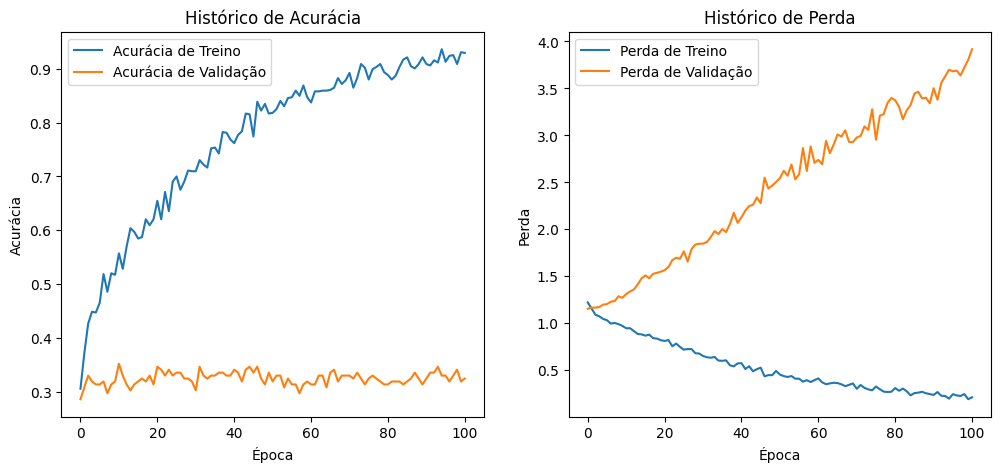


Resultado Final no Conjunto de Teste:
   - Perda (Loss): 1.1474
   - Acurácia (Accuracy): 0.3143
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Relatório de Classificação:
              precision    recall  f1-score   support

      Compra       0.30      0.16      0.21        92
     Lateral       0.35      0.43      0.39        83
       Venda       0.29      0.37      0.32        70

    accuracy                           0.31       245
   macro avg       0.31      0.32      0.31       245
weighted avg       0.31      0.31      0.30       245


Matriz de Confusão:


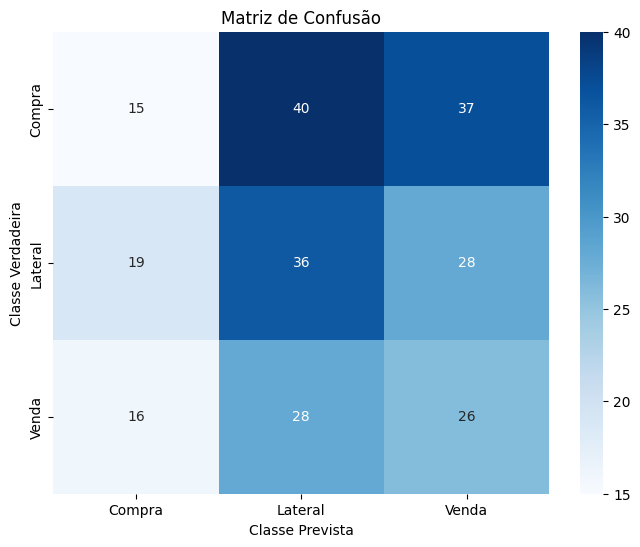

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do TensorFlow e Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam

import tensorflow as tf  #pip install tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2


# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

print(f"\n--- SCRIPT DE REORGANIZAÇÃO ORDENADA DO DATASET DE TREINO ---")

# --- ETAPA 1: CARREGAR E SEPARAR X E Y ---
print("\n[ETAPA 1/5] Carregando o dataset e separando Features (X) e Alvo (Y)...")
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
    
    # Identifica as colunas de label e de features
    label_cols = ['label_Compra', 'label_Lateral', 'label_Venda']
    feature_cols = [col for col in df.columns if col not in label_cols]
    
    X_flat = df[feature_cols]
    Y = df[label_cols]
    print(f"Dataset carregado com {len(df)} dias.")
    
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- ETAPA 2: DIVISÃO CRONOLÓGICA EM TREINO E TESTE ---
print("\n[ETAPA 2/5] Dividindo em conjuntos de treino e teste (80/20, cronológico)...")
X_train_orig, X_test, Y_train_orig, Y_test = train_test_split(
    X_flat, Y, test_size=0.2, shuffle=False
)

print(f"Tamanho do conjunto de treino original: {len(X_train_orig)} dias.")
print(f"Tamanho do conjunto de teste: {len(X_test)} dias.")

# --- ETAPA 3: SEPARAR O CONJUNTO DE TREINO POR CLASSE ---
print("\n[ETAPA 3/5] Separando o conjunto de treino por classe...")

# Adiciona a coluna de label original de volta para facilitar a filtragem
Y_train_orig_labels = Y_train_orig.idxmax(axis=1)
X_train_orig['label'] = Y_train_orig_labels

# Cria um DataFrame para cada classe
df_compra = X_train_orig[X_train_orig['label'] == 'label_Compra'].copy()
df_venda = X_train_orig[X_train_orig['label'] == 'label_Venda'].copy()
df_lateral = X_train_orig[X_train_orig['label'] == 'label_Lateral'].copy()

print(f"Amostras de Compra no treino: {len(df_compra)}")
print(f"Amostras de Venda no treino: {len(df_venda)}")
print(f"Amostras de Lateral no treino: {len(df_lateral)}")

# Remove a coluna 'label' temporária
df_compra.drop('label', axis=1, inplace=True)
df_venda.drop('label', axis=1, inplace=True)
df_lateral.drop('label', axis=1, inplace=True)

# --- ETAPA 4: INTERCALAR AS CLASSES PARA CRIAR O NOVO CONJUNTO DE TREINO ---
print("\n[ETAPA 4/5] Intercalando as classes para criar um conjunto de treino ordenado e balanceado...")

# Encontra o número de amostras da classe minoritária
min_samples = min(len(df_compra), len(df_venda), len(df_lateral))
print(f"O novo conjunto de treino terá {min_samples} amostras de cada classe, totalizando {min_samples * 3} dias.")

# Pega apenas o número 'min_samples' de cada DataFrame
df_compra = df_compra.iloc[:min_samples]
df_venda = df_venda.iloc[:min_samples]
df_lateral = df_lateral.iloc[:min_samples]

# Lista para armazenar os DataFrames na ordem correta
ordered_dfs = []
for i in range(min_samples):
    ordered_dfs.append(df_compra.iloc[i:i+1])
    ordered_dfs.append(df_venda.iloc[i:i+1])
    ordered_dfs.append(df_lateral.iloc[i:i+1])

# Concatena todos os pequenos DataFrames em um único DataFrame final
df_train_ordered = pd.concat(ordered_dfs)

# Separa novamente em X e Y
X_train_ordered = df_train_ordered[feature_cols]
Y_train_ordered = pd.get_dummies(df_train_ordered.index.map(Y.idxmax(axis=1))) # Pega os labels correspondentes

print("Conjunto de treino reordenado criado com sucesso.")

#-------------------------------------------------------------------------------
print(f"Tamanho do conjunto de treino: {len(X_train_ordered)} dias")
print(f"Tamanho do conjunto de teste: {len(X_test)} dias")

# --- 3. PADRONIZAÇÃO DAS FEATURES ---
print("\n--- [ETAPA 3/7] Aplicando Padronização (StandardScaler) ---")

# Inicializar o scaler
scaler = StandardScaler()

# Ajustar o scaler APENAS nos dados de treino e transformar ambos
X_train_scaled = scaler.fit_transform(X_train_ordered)
X_test_scaled = scaler.transform(X_test)
print("Features de treino e teste padronizadas.")

# --- 4. CONSTRUIR A ARQUITETURA DO MODELO MLP ---
print("\n--- [ETAPA 4/7] Construindo a Arquitetura do Modelo MLP ---")

# Fatores de regularização L1 e L2 (hiperparâmetros que você pode ajustar)
l1_factor = 0.00000005  #0.0001
l2_factor = 0.00001  # 0.001

# Construir o modelo MLP
model_mlp = Sequential([
    # Camada de entrada com regularização L1 e L2
    Dense(
        296, #128 
        activation='relu', 
        input_shape=(X_train_scaled.shape[1],),
        kernel_regularizer=l1_l2(l1=l1_factor, l2=l2_factor) # Aplica L1 e L2
    ),
    # Camada de Dropout para regularização
    Dropout(0.4), # Dropout mais agressivo

    # Camada oculta com regularização L1 e L2
    Dense(
        153, #  64
        activation='relu',
        kernel_regularizer=l1_l2(l1=l1_factor, l2=l2_factor)
    ),
    # Camada de Dropout
    Dropout(0.5),

    # Camada de saída com função de ativação Softmax
    Dense(3, activation='softmax')
])

# Exibe um resumo da arquitetura do modelo
print("Resumo do Modelo:")
model_mlp.summary()

# --- 5. COMPILAR O MODELO ---
print("\n--- [ETAPA 5/7] Compilando o Modelo ---")

# Compilar o modelo com Otimizador Adam e Perda Categorical Cross-Entropy
model_mlp.compile(
    optimizer=Adam(learning_rate=0.0004), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado com sucesso.")

# --- 6. TREINAR O MODELO COM EARLY STOPPING ---
print("\n--- [ETAPA 6/7] Treinando o Modelo ---")

# Callback para parar o treino se a perda na validação não melhorar
# Isso previne o overfitting e encontra a melhor versão do modelo
early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitora a perda no conjunto de validação
    patience=100,              # 15 Número de épocas sem melhora antes de parar
    restore_best_weights=True, # Restaura os pesos da melhor época encontrada
    verbose=1
)

# Treinar o modelo
history = model_mlp.fit(
    X_train_scaled,
    Y_train_ordered,
    epochs=500, # 150 Um número alto, pois o EarlyStopping vai parar quando for a hora
    batch_size=6, # múltiplo de 3 para usar a sequência ordenada
    validation_split=0.2, # Usa 20% do treino para validação interna
    shuffle=False,         #Não embaralha os dados de treino a cada época. para usar a sequência ordenada (C, V, L, C, V, L...) 
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. AVALIAR O DESEMPENHO FINAL ---
print("\n--- [ETAPA 7/7] Avaliando o Desempenho no Conjunto de Teste ---")

# Plotar o histórico de treinamento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Histórico de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

# Avaliar o modelo no conjunto de teste (dados que ele nunca viu)
test_loss, test_accuracy = model_mlp.evaluate(X_test_scaled, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

# Gerar previsões para o conjunto de teste para análise detalhada
Y_pred_probs = model_mlp.predict(X_test_scaled)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test.values, axis=1)

# Mapear os índices das classes para os nomes
class_names = ['Compra', 'Lateral', 'Venda']

# Imprimir o relatório de classificação (precisão, recall, f1-score)
print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names))

# Imprimir a Matriz de Confusão
print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão')
plt.show()


### Otimização de hiperparametros com o optuna
Excelente escolha! O Optuna é uma ferramenta fantástica e, embora um pouco mais verbosa que o Keras-Tuner, oferece um poder e uma flexibilidade incríveis.

Para integrar o Optuna ao seu código, faremos o seguinte:

1.  **Instalar o Optuna:** Se ainda não o fez, execute `pip install optuna`.
2.  **Criar a Função `objective`:** Esta é a função principal que o Optuna irá chamar. Ela recebe um objeto `trial` como argumento. Dentro dela, nós:
    *   Sugerimos os hiperparâmetros usando a API do `trial` (ex: `trial.suggest_int`, `trial.suggest_float`).
    *   Construímos, compilamos e treinamos o modelo Keras.
    *   Avaliamos o modelo no conjunto de validação.
    *   **Retornamos** a métrica que queremos otimizar (neste caso, a acurácia de validação).
3.  **Criar um "Study":** Esta é a sessão de otimização. Dizemos a ele para `maximize` a métrica retornada pela função `objective`.
4.  **Executar a Otimização:** Chamamos `study.optimize()` e dizemos quantos `trials` (testes) ele deve executar.
5.  **Analisar e Usar os Resultados:** Após a busca, o Optuna nos dirá qual foi a melhor combinação de hiperparâmetros encontrada. Usaremos esses parâmetros para treinar um modelo final e avaliá-lo no conjunto de teste.

#### Como Executar e Principais Mudanças

1.  **Instale as Dependências:**
    *   `pip install optuna`
    *   `pip install plotly` (necessário para as visualizações do Optuna)

2.  **Execute o Script:** Salve o código e execute-o. Você verá o log do Optuna mostrando cada `trial` que ele completa e a melhor acurácia encontrada até o momento.

3.  **Flexibilidade:** Note como a função `objective` é flexível. Eu adicionei a otimização do **número de camadas** (`n_layers`), algo que é mais complexo de fazer no Keras-Tuner. O Optuna lida com isso de forma elegante.

4.  **Divisão de Dados:** A lógica de divisão de dados mudou um pouco para se adequar ao Optuna. Agora temos:
    *   `X_train_val`, `Y_train_val`: 80% dos dados, usados pelo Optuna para a busca.
    *   `X_test`, `Y_test`: 20% dos dados, mantidos completamente separados para a avaliação final do melhor modelo.
    *   Dentro de cada `trial`, o Optuna subdivide `X_train_val` em conjuntos de treino e validação para avaliar os hiperparâmetros.

5.  **Visualizações:** Ao final, o script irá gerar dois gráficos muito poderosos:
    *   **Histórico de Otimização:** Mostra como a acurácia de validação melhorou a cada `trial`.
    *   **Importância dos Parâmetros:** Mostra quais hiperparâmetros tiveram o maior impacto no resultado final. Isso é extremamente útil para entender o que realmente importa no seu modelo.

Este código lhe dá uma base extremamente poderosa para encontrar a melhor arquitetura e hiperparâmetros para o seu problema.

In [ ]:
pip install optuna

In [ ]:
pip install plotly

[I 2026-02-24 21:04:26,413] A new study created in memory with name: no-name-83caae6c-319c-4287-b858-1b53549da753



--- SCRIPT DE OTIMIZAÇÃO COM OPTUNA (LÓGICA ORDENADA) ---

[ETAPA 1/6] Carregando o dataset...

[ETAPA 2/6] Dividindo em conjuntos de treino e teste (80/20, cronológico)...

[ETAPA 3/6] Criando dataset de treino ordenado (C, V, L)...
Dataset de treino ordenado criado com 909 amostras.

[ETAPA 4/7] Aplicando Padronização (StandardScaler)...
Features padronizadas.

[ETAPA 5/7] Definindo a função 'objective' para o Optuna...

[ETAPA 6/7] Executando o estudo de otimização do Optuna...


[I 2026-02-24 21:04:57,798] Trial 0 finished with value: 0.3791208863258362 and parameters: {'n_layers': 5, 'learning_rate': 0.0007504853437418819, 'l1': 3.874593648640283e-07, 'l2': 0.0005315181804611625, 'batch_size': 18, 'n_units_layer0': 65, 'dropout_layer0': 0.4250329812001257, 'n_units_layer1': 98, 'dropout_layer1': 0.6934001776756897, 'n_units_layer2': 340, 'dropout_layer2': 0.4389337213065416, 'n_units_layer3': 87, 'dropout_layer3': 0.5598638747678111, 'n_units_layer4': 153, 'dropout_layer4': 0.7405956781614147}. Best is trial 0 with value: 0.3791208863258362.
[I 2026-02-24 21:05:53,619] Trial 1 finished with value: 0.32967033982276917 and parameters: {'n_layers': 5, 'learning_rate': 2.1237096385156255e-05, 'l1': 1.2591382716207423e-08, 'l2': 0.0002918542779518629, 'batch_size': 9, 'n_units_layer0': 241, 'dropout_layer0': 0.39557707338812087, 'n_units_layer1': 142, 'dropout_layer1': 0.2294012578765968, 'n_units_layer2': 263, 'dropout_layer2': 0.3609776059613026, 'n_units_layer3


Busca concluída!
Melhor val_accuracy durante a busca: 0.3956
Melhores Hiperparâmetros encontrados:
  - n_layers: 5
  - learning_rate: 0.0008549940720463416
  - l1: 6.444605672461383e-06
  - l2: 0.0005115874011476407
  - batch_size: 9
  - n_units_layer0: 197
  - dropout_layer0: 0.5163236371590717
  - n_units_layer1: 131
  - dropout_layer1: 0.663024387639078
  - n_units_layer2: 252
  - dropout_layer2: 0.5227350116478153
  - n_units_layer3: 142
  - dropout_layer3: 0.7240216775739758
  - n_units_layer4: 120
  - dropout_layer4: 0.7957550010004217

[ETAPA 7/7] Treinando o modelo final com os melhores hiperparâmetros...

Arquitetura do Modelo Final:


Model: "sequential_101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_471 (Dense)               │ (None, 197)            │         7,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_370 (Dropout)           │ (None, 197)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_472 (Dense)               │ (None, 131)            │        25,938 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_371 (Dropout)           │ (None, 131)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_473 (Dense)               │ (None, 252)            │        33,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_372 (Dropout)           │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_474 (Dense)               │ (None, 142)            │        35,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_373 (Dropout)           │ (None, 142)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_475 (Dense)               │ (None, 120)            │        17,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_374 (Dropout)           │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_476 (Dense)               │ (None, 3)              │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,531 (470.82 KB)

 Trainable params: 120,531 (470.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3333 - loss: 1.9280 - val_accuracy: 0.3020 - val_loss: 1.4814
Epoch 2/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3190 - loss: 1.6213 - val_accuracy: 0.3469 - val_loss: 1.4765
Epoch 3/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3146 - loss: 1.5674 - val_accuracy: 0.3755 - val_loss: 1.4715
Epoch 4/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3388 - loss: 1.5338 - val_accuracy: 0.3633 - val_loss: 1.4687
Epoch 5/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3399 - loss: 1.4990 - val_accuracy: 0.3673 - val_loss: 1.4650
Epoch 6/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3476 - loss: 1.4753 - val_accuracy: 0.2776 - val_loss: 1.4615
Epoch 7/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3311 - loss: 1.4753 - val_accuracy: 0.3755 - val_loss: 1.4568
Epoch 8/500
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3674 - loss: 1.4620 - val_accu

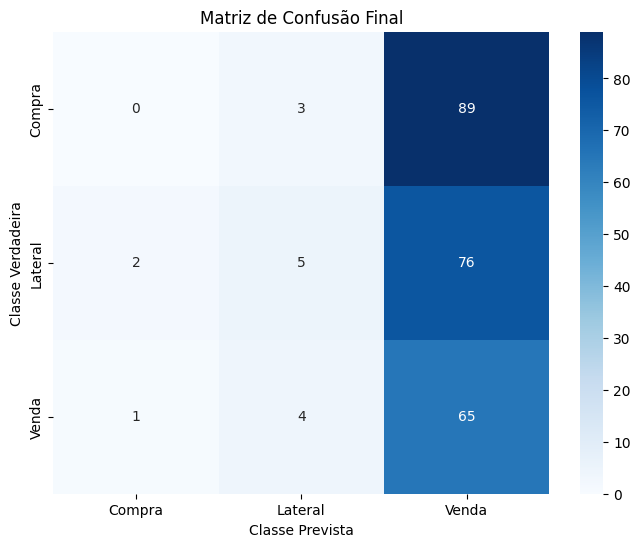


--- VISUALIZAÇÕES DO OPTUNA ---


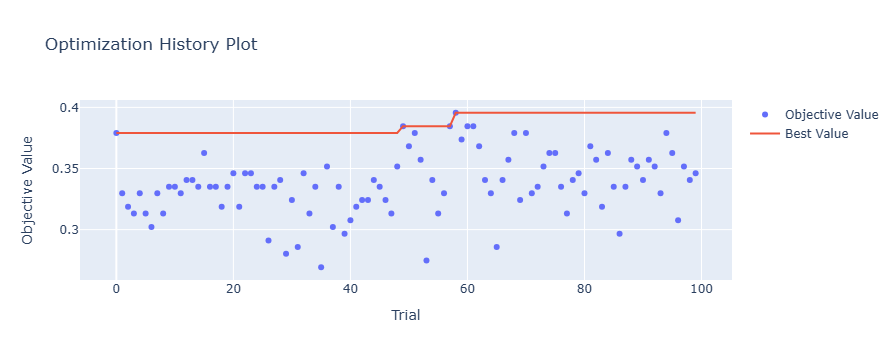

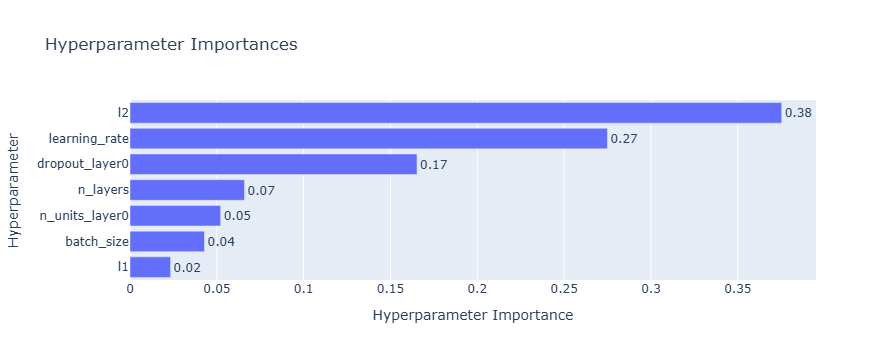

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

# Importações do TensorFlow e Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam

# --- CONFIGURAÇÕES ---
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
#NOME_ARQUIVO_ENTRADA = 'dataset_hibrido_win_wdo.csv'

print(f"\n--- SCRIPT DE OTIMIZAÇÃO COM OPTUNA (LÓGICA ORDENADA) ---")

# --- ETAPA 1: CARREGAR E SEPARAR X E Y ---
print("\n[ETAPA 1/6] Carregando o dataset...")
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
    # Identifica as colunas de label e de features
    label_cols = ['label_Compra', 'label_Lateral', 'label_Venda']
    feature_cols = [col for col in df.columns if col not in label_cols]
    X_flat = df[feature_cols]
    Y = df[label_cols]
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"ERRO ao carregar o arquivo: {e}")
    exit()

# --- ETAPA 2: DIVISÃO CRONOLÓGICA EM TREINO E TESTE ---
print("\n[ETAPA 2/6] Dividindo em conjuntos de treino e teste (80/20, cronológico)...")
X_train_orig, X_test, Y_train_orig, Y_test = train_test_split(
    X_flat, Y, test_size=0.2, shuffle=False
)

# --- ETAPA 3: CRIAR DATASET DE TREINO ORDENADO E BALANCEADO ---
print("\n[ETAPA 3/6] Criando dataset de treino ordenado (C, V, L)...")
# Adiciona a coluna de label original de volta para facilitar a filtragem
Y_train_orig_labels = Y_train_orig.idxmax(axis=1)
X_train_orig['label'] = Y_train_orig_labels

# Cria um DataFrame para cada classe
df_compra = X_train_orig[X_train_orig['label'] == 'label_Compra'].copy()
df_venda = X_train_orig[X_train_orig['label'] == 'label_Venda'].copy()
df_lateral = X_train_orig[X_train_orig['label'] == 'label_Lateral'].copy()

# Remove a coluna 'label' temporária
df_compra.drop('label', axis=1, inplace=True)
df_venda.drop('label', axis=1, inplace=True)
df_lateral.drop('label', axis=1, inplace=True)

# Intercalando as classes para criar um conjunto de treino ordenado e balanceado
# Encontra o número de amostras da classe minoritária
min_samples = min(len(df_compra), len(df_venda), len(df_lateral))

# Pega apenas o número 'min_samples' de cada DataFrame
df_compra = df_compra.iloc[:min_samples]
df_venda = df_venda.iloc[:min_samples]
df_lateral = df_lateral.iloc[:min_samples]

# Lista para armazenar os DataFrames na ordem correta
ordered_dfs = []
for i in range(min_samples):
    ordered_dfs.append(df_compra.iloc[i:i+1])
    ordered_dfs.append(df_venda.iloc[i:i+1])
    ordered_dfs.append(df_lateral.iloc[i:i+1])

# Concatena todos os pequenos DataFrames em um único DataFrame final
df_train_ordered = pd.concat(ordered_dfs)
# Separa novamente em X e Y
X_train_ordered = df_train_ordered[feature_cols]
Y_train_ordered = pd.get_dummies(df_train_ordered.index.map(Y.idxmax(axis=1))) # Pega os labels correspondentes

# Garante que os labels Y correspondam à nova ordem de X
#Y_train_ordered = Y.loc[X_train_ordered.index]

print(f"Dataset de treino ordenado criado com {len(X_train_ordered)} amostras.")

# --- ETAPA 4: PADRONIZAÇÃO DAS FEATURES ---
print("\n[ETAPA 4/7] Aplicando Padronização (StandardScaler)...")
# Inicializa o padronizador.
scaler = StandardScaler()
# Usa o método 'fit_transform' APENAS nos dados de treino. O 'fit' aprende a média e o desvio padrão dos dados de treino.
X_train_scaled = scaler.fit_transform(X_train_ordered)
# Usa o método 'transform' nos dados de teste. Ele aplica a mesma transformação aprendida com os dados de treino,
# evitando qualquer "vazamento de informação" do conjunto de teste.
X_test_scaled = scaler.transform(X_test)
print("Features padronizadas.")

# --- ETAPA 5: DEFINIR A FUNÇÃO OBJECTIVE PARA O OPTUNA ---
print("\n[ETAPA 5/7] Definindo a função 'objective' para o Optuna...")
# Esta função define um "experimento". O Optuna irá chamá-la várias vezes (uma para cada 'trial').
def objective(trial):
    # --- 1. Sugerir Hiperparâmetros ---
    # Para cada 'trial', o Optuna sugere um valor para cada hiperparâmetro dentro do intervalo definido.
    n_layers = trial.suggest_int('n_layers', 1, 5) # Número de camadas ocultas.
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True) # Taxa de aprendizado do otimizador.
    l1_factor = trial.suggest_float('l1', 1e-8, 1e-4, log=True) # Força da regularização L1.
    l2_factor = trial.suggest_float('l2', 1e-5, 1e-3, log=True) # Força da regularização L2.
    # Tamanho do lote (batch_size), restrito a múltiplos de 3 para respeitar a ordem C,V,L.
    batch_size = trial.suggest_categorical('batch_size', [3, 6, 9, 12, 15, 18])

    # --- 2. Construir o Modelo ---
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],))) # Define a forma da camada de entrada.

    # Cria as camadas ocultas dinamicamente, com base no valor de 'n_layers' sugerido pelo Optuna.
    for i in range(n_layers):
        units = trial.suggest_int(f'n_units_layer{i}', 32, 340, step=11) # Neurônios para esta camada.
        dropout_rate = trial.suggest_float(f'dropout_layer{i}', 0.2, 0.8) # Dropout para esta camada.
        model.add(Dense(units=units, activation='relu', kernel_regularizer=l1_l2(l1=l1_factor, l2=l2_factor)))
        model.add(Dropout(dropout_rate))

    model.add(Dense(3, activation='softmax')) # Camada de saída para 3 classes.

    # --- 3. Compilar o Modelo ---
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])

    # --- 4. Treinar o Modelo ---
    # O EarlyStopping para o treino se a 'val_loss' não melhorar por 10 épocas.
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Treina o modelo com os dados ordenados.
    history = model.fit(
        X_train_scaled, Y_train_ordered, epochs=300, batch_size=batch_size,
        validation_split=0.2, # Usa os últimos 20% dos dados de treino para validação.
        shuffle=False,        # Garante que a ordem C,V,L seja mantida durante o treino.
        callbacks=[early_stopping],
        verbose=0 # Desliga o log do Keras para não poluir a saída do Optuna.
    )
    
    # --- 5. Retornar a Métrica de Avaliação ---
    # Pega a acurácia de validação da última época (que é a melhor, graças ao 'restore_best_weights').
    val_accuracy = history.history['val_accuracy'][-1]
    # O valor retornado é o que o Optuna tentará maximizar.
    return val_accuracy

# --- ETAPA 6: EXECUTAR O ESTUDO DE OTIMIZAÇÃO ---
print("\n[ETAPA 6/7] Executando o estudo de otimização do Optuna...")
# Cria um "estudo". 'direction="maximize"' diz ao Optuna que nosso objetivo é maximizar o valor retornado pela função 'objective'.
study = optuna.create_study(direction="maximize")
# Inicia a otimização. O Optuna chamará a função 'objective' 30 vezes, cada vez com um conjunto diferente de hiperparâmetros.
study.optimize(objective, n_trials=100)
##########################################

print("\nBusca concluída!")
# Pega o melhor 'trial' (o que resultou na maior 'val_accuracy').
best_trial = study.best_trial
print(f"Melhor val_accuracy durante a busca: {best_trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
# Imprime os hiperparâmetros que levaram ao melhor resultado.
for key, value in best_trial.params.items():
    print(f"  - {key}: {value}")

# --- ETAPA 7: TREINAR E AVALIAR O MODELO FINAL ---
print("\n[ETAPA 7/7] Treinando o modelo final com os melhores hiperparâmetros...")

# --- 1. Construir o Modelo Final ---
# Constrói um novo modelo, exatamente com a arquitetura e os parâmetros do melhor 'trial'.
final_model = Sequential()
final_model.add(Input(shape=(X_train_scaled.shape[1],)))
for i in range(best_trial.params['n_layers']):
    units = best_trial.params[f'n_units_layer{i}']
    dropout_rate = best_trial.params[f'dropout_layer{i}']
    final_model.add(Dense(
        units=units, activation='relu',
        kernel_regularizer=l1_l2(l1=best_trial.params['l1'], l2=best_trial.params['l2'])
    ))
    final_model.add(Dropout(dropout_rate))
final_model.add(Dense(3, activation='softmax'))

# --- 2. Compilar o Modelo Final ---
final_model.compile(
    optimizer=Adam(learning_rate=best_trial.params['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\nArquitetura do Modelo Final:")
final_model.summary()

# --- 3. Treinar o Modelo Final ---
# Define um EarlyStopping com mais paciência para o treinamento final.
final_early_stopping = EarlyStopping(
    monitor='val_loss', patience=55, # Um pouco mais de paciência para o treino final
    restore_best_weights=True, verbose=1
)

# Treina o modelo final em TODOS os dados de treino ordenados.
# Desta vez, usa o conjunto de TESTE como dados de validação para saber quando parar o treino.
history = final_model.fit(
    X_train_scaled,
    Y_train_ordered,
    epochs=500, # Mais épocas para o treinamento final
    batch_size=best_trial.params['batch_size'],
    shuffle=False, # Mantendo a lógica ordenada.
    validation_data=(X_test_scaled, Y_test), # Usa o conjunto de teste real para validação
    callbacks=[final_early_stopping],
    verbose=1
)

# --- 4. Avaliar o Desempenho Final ---
print("\n--- AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---")
# O callback `restore_best_weights=True` garante que o modelo está no seu melhor estado.
# O método 'evaluate' calcula a perda e a acurácia no conjunto de teste.
test_loss, test_accuracy = final_model.evaluate(X_test_scaled, Y_test, verbose=0)
print(f"   - Perda (Loss) no Teste: {test_loss:.4f}")
print(f"   - Acurácia (Accuracy) no Teste: {test_accuracy:.4f}")

# --- 5. Gerar Relatório de Classificação e Matriz de Confusão ---
# Pede ao modelo para fazer previsões para os dados de teste. A saída são probabilidades.
Y_pred_probs = final_model.predict(X_test_scaled)
# 'argmax' encontra o índice da classe com a maior probabilidade para cada previsão.
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
# Faz o mesmo para os labels verdadeiros, para comparar.
Y_test_classes = np.argmax(Y_test.values, axis=1)
# Define os nomes das classes para os relatórios.
class_names = ['Compra', 'Lateral', 'Venda']

print("\nRelatório de Classificação:")
# Mostra métricas detalhadas (precisão, recall, f1-score) para cada classe.
# 'zero_division=0' evita um aviso caso uma classe nunca seja prevista.
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
# Cria a matriz de confusão para ver visualmente onde o modelo acerta e erra.
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
# Usa o Seaborn para plotar a matriz como um mapa de calor.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final')
plt.show()

# --- 6. Visualizações do Optuna ---
try:
    # Tenta importar a biblioteca 'plotly', necessária para as visualizações.
    import plotly
    print("\n--- VISUALIZAÇÕES DO OPTUNA ---")
    # Gráfico 1: Mostra como a melhor pontuação evoluiu ao longo dos 'trials'.
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()

    # Gráfico 2: Mostra a importância de cada hiperparâmetro. Parâmetros mais importantes
    # são aqueles que mais influenciaram o resultado da acurácia.
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()
except ImportError:
    # Se 'plotly' não estiver instalado, apenas imprime uma mensagem.
    print("\nInstale plotly (`pip install plotly`) para ver as visualizações do Optuna.")


# Testando Rede Neural Convolucional 1D (CNN)
**Filosofia:** Procura por padrões locais (ex: "engolfo de alta", "três soldados brancos") na sequência de candles, independentemente de onde eles apareçam na janela de 2 horas.

**Passos Específicos:**

1.  **Normalizar os Dados (Achatados PRIMEIRO):**
    *   A normalização deve ser feita nos dados achatados para que o `scaler` aprenda a média e o desvio padrão de cada uma das 264 features.
2.  **Reformatar (Reshape) para 3D:**
    *   Agora, transformamos os dados normalizados de volta para o formato `(dias, timesteps, features_por_timestep)`.
3.  **Construir o Modelo CNN 1D:**
    *   A arquitetura usa camadas `Conv1D` e `MaxPooling1D`.
4.  **Compilar e Treinar:**
5.  **Avaliar:**

## Remodelagem do dataset

O processo de modificar os dados do padrão "flat" (achatado) para o padrão da CNN pode ser resumido em **três etapas principais**:

1.  **Divisão Lógica:** Separar o que é **Contexto** do que é **Sequência**.
2.  **Padronização (Scaling):** Ajustar a escala de cada parte de forma independente.
3.  **Remodelagem (Reshape):** Transformar a parte sequencial em uma "imagem" 1D.

### Ponto de Partida: O Padrão "Flat" (para MLP)

Imagine um único dia de dados. No padrão "flat", ele é um **único vetor longo e contínuo**.

*   **Estrutura:** `[Contexto_1, ..., Contexto_11, Vela1_Feat1, Vela1_Feat2, ..., Vela24_Feat7]`
*   **Formato (Shape):** `(1, 179)`  *(11 features de contexto + 168 features sequenciais)*
*   **Visão do Modelo (MLP):** A MLP vê isso como 179 números individuais. Ela não tem ideia de que `Vela1_Feat1` e `Vela2_Feat1` estão relacionados no tempo. Para ela, são apenas as features de índice 12 e 19.

### O Processo de Transformação para a CNN

#### Etapa 1: Divisão Lógica (Separar Contexto da Sequência)

A primeira e mais importante etapa é reconhecer que nem todas as features são iguais. Dividimos o vetor longo em duas partes lógicas:

*   **Parte 1: Vetor de Contexto**
    *   **Conteúdo:** As 11 features que descrevem o "cenário" do dia ('gap', 'range_dia_anterior', 'atr_dia_anterior', 'posicao_range_d1', 'distancia_mm20', 'mes_sin', 'dia_mes_sin', etc.).
    *   **Formato:** `(1, 11)`

*   **Parte 2: Vetor Sequencial**
    *   **Conteúdo:** As 168 features que representam a ação do preço ao longo da manhã (7 feature para cada uma das 24 velas).
    *   **Formato:** `(1, 168)`

#### Etapa 2: Padronização (Scaling) Independente

Como as features de contexto (ex: `atr`) e as sequenciais (ex: `mov_direcional`) têm escalas e distribuições muito diferentes, aplicamos o `StandardScaler` a cada parte separadamente. Isso evita que uma parte "domine" a outra e melhora o treinamento.

#### Etapa 3: Remodelagem (Reshape) da Parte Sequencial

Esta é a etapa que "prepara" os dados para a visão da CNN. Pegamos o vetor sequencial longo e o "dobramos" em uma matriz que representa a passagem do tempo.

*   **O que fazemos:** Pegamos o vetor de `(1, 168)` e o remodelamos.
*   **Como?** Dizemos ao NumPy/Keras: "Organize esses 168 números em **24 passos de tempo**, onde cada passo tem **7 features**."
*   **Resultado:** O formato muda de `(1, 168)` para `(1, 24, 7)`.

### Resultado Final: O Padrão para a CNN

No final, para cada dia, em vez de um único vetor, temos **uma lista com dois arrays separados**:

1.  **Array de Contexto:**
    *   **Formato:** `(1, 11)`
    *   **Visão do Modelo:** Um conjunto de features estáticas. Será processado por camadas `Dense`.

2.  **Array Sequencial Remodelado:**
    *   **Formato:** `(1, 24, 7)`
    *   **Visão do Modelo:** Uma "imagem" 1D com 24 pixels de altura e 7 canais de cor (features). Será processado pela camada `Conv1D`.

Essa transformação permite que a CNN aplique seus filtros (`kernels`) sobre a dimensão temporal (os 24 candles), aprendendo padrões como "três candles de alta seguidos por um de baixa com volume alto", algo que seria quase impossível para a MLP aprender a partir do vetor "flat".


### Código para CNN

Este código fará o seguinte:

1.  **Carregará** o `dataset_final.csv` que você criou.
2.  **Separará** os dados em features de contexto, features sequenciais e labels.
3.  **Dividirá** os dados em conjuntos de treino e teste de forma cronológica.
4.  **Aplicará a padronização** (scaling) corretamente em cada tipo de feature.
5.  **Remodelará** os dados sequenciais para o formato 1D que a CNN espera.
6.  **Construirá** um modelo CNN de múltiplas entradas usando a API Funcional do Keras.
7.  **Compilará e treinará** o modelo.
8.  **Avaliará** o desempenho final no conjunto de teste e exibirá os resultados, incluindo o relatório de classificação e a matriz de confusão.


In [15]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Importações do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- ETAPA 1: DEFINIÇÕES E CARREGAMENTO DOS DADOS ---
print("--- [ETAPA 1/8] Carregando e Definindo Parâmetros ---")

# Nome do arquivo de entrada
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

# Definições que DEVEM ser consistentes com o script de criação do dataset
# É crucial que estes números correspondam à estrutura do seu CSV.
N_FEATURES_CONTEXTO = 11  # 5 diárias (gap, atr, etc) + 6 cíclicas (sin/cos)
N_CANDLES = 4            # 24 candles na janela de entrada
N_FEATURES_POR_CANDLE = 7 # 7 features calculadas para cada candle

# Carrega o dataset
try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
    print(f"Dataset carregado com sucesso. Dimensões: {df.shape}")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# --- ETAPA 2: SEPARAÇÃO DE FEATURES (X) E LABELS (Y) ---
print("\n--- [ETAPA 2/8] Separando Features (X) e Labels (Y) ---")

# As colunas de features são todas, exceto as 3 últimas (labels)
X = df.iloc[:, :-3].values
# As 3 últimas colunas são os labels
Y = df.iloc[:, -3:].values

print(f"Shape de X (bruto): {X.shape}")
print(f"Shape de Y: {Y.shape}")

# --- ETAPA 3: DIVISÃO CRONOLÓGICA EM TREINO E TESTE ---
print("\n--- [ETAPA 3/8] Dividindo em Conjuntos de Treino e Teste (80/20) ---")

# shuffle=False é ESSENCIAL para séries temporais, para não vazar dados do futuro.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print(f"Amostras de treino: {X_train.shape[0]}")
print(f"Amostras de teste: {X_test.shape[0]}")

# --- ETAPA 4: PREPARAÇÃO DOS DADOS PARA MÚLTIPLAS ENTRADAS ---
print("\n--- [ETAPA 4/8] Preparando Dados para Múltiplas Entradas ---")

# 4.1 - Separação das features de contexto e sequenciais
X_train_contexto = X_train[:, :N_FEATURES_CONTEXTO]
X_train_sequencial = X_train[:, N_FEATURES_CONTEXTO:]
X_test_contexto = X_test[:, :N_FEATURES_CONTEXTO]
X_test_sequencial = X_test[:, N_FEATURES_CONTEXTO:]

# 4.2 - Padronização (Scaling)
# Cada tipo de dado é padronizado com seu próprio scaler.
scaler_contexto = StandardScaler()
X_train_contexto_scaled = scaler_contexto.fit_transform(X_train_contexto)
X_test_contexto_scaled = scaler_contexto.transform(X_test_contexto)

scaler_sequencial = StandardScaler()
X_train_sequencial_scaled = scaler_sequencial.fit_transform(X_train_sequencial)
X_test_sequencial_scaled = scaler_sequencial.transform(X_test_sequencial)

# 4.3 - Remodelagem (Reshape) da parte sequencial
# Transforma o vetor longo em uma matriz 3D: (amostras, passos_de_tempo, features_por_passo)
X_train_sequencial_reshaped = X_train_sequencial_scaled.reshape(
    -1, N_CANDLES, N_FEATURES_POR_CANDLE
)
X_test_sequencial_reshaped = X_test_sequencial_scaled.reshape(
    -1, N_CANDLES, N_FEATURES_POR_CANDLE
)

print(f"Shape final dos dados de contexto (treino): {X_train_contexto_scaled.shape}")
print(f"Shape final dos dados sequenciais (treino): {X_train_sequencial_reshaped.shape}")

# 4.4 - Cria a lista de entradas para o modelo
# O Keras espera uma lista de arrays, uma para cada Input do modelo.
X_train_final = [X_train_contexto_scaled, X_train_sequencial_reshaped]
X_test_final = [X_test_contexto_scaled, X_test_sequencial_reshaped]

# --- ETAPA 5: CONSTRUÇÃO DO MODELO CNN DE MÚLTIPLAS ENTRADAS ---
print("\n--- [ETAPA 5/8] Construindo o Modelo CNN ---")

# 5.1 - Ramo da Entrada Sequencial (CNN)
# Define o formato da entrada para os dados dos candles
input_sequencial = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial')
# Primeira camada convolucional: 64 filtros, cada um olhando para 3 candles de uma vez.
conv1 = Conv1D(filters=64, kernel_size=3, activation='relu')(input_sequencial)  # filters_conv_0
# Segunda camada convolucional, para aprender padrões sobre os padrões da primeira.
conv2 = Conv1D(filters=32, kernel_size=3, activation='relu')(conv1)
# Achata a saída da CNN para que possa ser conectada a camadas densas.
flatten_cnn = Flatten()(conv2)
#flatten_cnn = Flatten()(conv2)

# Camada de Dropout para regularizar o ramo da CNN.
dropout_cnn = Dropout(0.2220181437026228)(flatten_cnn)
# 5.2 - Ramo da Entrada de Contexto (MLP)
# Define o formato da entrada para os dados de contexto (gap, atr, cíclicas, etc.)
input_contexto = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto')
# Uma camada densa para processar as features de contexto.
dense_contexto = Dense(48, activation='relu')(input_contexto)  # context_units

# 5.3 - Concatenação e Classificação Final
# Junta a saída processada dos dois ramos (CNN e MLP).
merged = concatenate([dropout_cnn, dense_contexto])
# Camada densa para interpretar as informações combinadas.
dense_final_1 = Dense(96, activation='relu')(merged)
dropout_final = Dropout(0.2503794518495706)(dense_final_1)
# Camada de saída com 3 neurônios (Compra, Lateral, Venda) e ativação softmax.
output = Dense(3, activation='softmax', name='saida')(dropout_final)

# 5.4 - Cria o Modelo Final
# Especifica as entradas e a saída do modelo.
model = Model(inputs=[input_contexto, input_sequencial], outputs=output)

# Exibe um resumo da arquitetura do modelo
print("Resumo do Modelo:")
model.summary()

# --- ETAPA 6: COMPILAÇÃO DO MODELO ---
print("\n--- [ETAPA 6/8] Compilando o Modelo ---")
otimizador_otimizado = Adam(learning_rate=0.0018384564024200595)
model.compile(
    optimizer=otimizador_otimizado,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado com sucesso.")

# --- ETAPA 7: TREINAMENTO DO MODELO ---
print("\n--- [ETAPA 7/8] Treinando o Modelo ---")

# Callbacks para um treinamento mais inteligente
# Para o treinamento se a 'val_loss' não melhorar por 'patience' épocas.
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
# Reduz a taxa de aprendizado se o treinamento estagnar.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001, verbose=1)

# Treina o modelo, passando a lista de entradas.
history = model.fit(
    X_train_final,
    Y_train,
    epochs=200,  # Um número alto, pois o EarlyStopping cuidará de parar.
    batch_size=16,  #16
    shuffle=False, # Essencial manter a ordem cronológica.
    validation_split=0.2, # Usa os últimos 20% do treino para validação.
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- ETAPA 8: AVALIAÇÃO FINAL DO MODELO ---
print("\n--- [ETAPA 8/8] Avaliando o Desempenho Final ---")

# 8.1 - Gráficos de Treinamento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Histórico de Acurácia')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda')
plt.legend()
plt.show()

# 8.2 - Avaliação no Conjunto de Teste (dados nunca vistos)
print("\nAvaliando no conjunto de teste...")
test_loss, test_accuracy = model.evaluate(X_test_final, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

# 8.3 - Relatório de Classificação e Matriz de Confusão
Y_pred_probs = model.predict(X_test_final)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
class_names = ['Compra', 'Lateral', 'Venda']

print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.show()


--- [ETAPA 1/8] Carregando e Definindo Parâmetros ---
Dataset carregado com sucesso. Dimensões: (1222, 42)

--- [ETAPA 2/8] Separando Features (X) e Labels (Y) ---
Shape de X (bruto): (1222, 39)
Shape de Y: (1222, 3)

--- [ETAPA 3/8] Dividindo em Conjuntos de Treino e Teste (80/20) ---
Amostras de treino: 977
Amostras de teste: 245

--- [ETAPA 4/8] Preparando Dados para Múltiplas Entradas ---
Shape final dos dados de contexto (treino): (977, 11)
Shape final dos dados sequenciais (treino): (977, 4, 7)

--- [ETAPA 5/8] Construindo o Modelo CNN ---
Resumo do Modelo:


Model: "functional_849"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_sequencial  │ (None, 4, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2, 64)     │      1,408 │ entrada_sequenci… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 0, 32)     │      6,176 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 0)         │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_contexto    │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_377         │ (None, 0)         │          0 │ flatten_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_479 (Dense)   │ (None, 48)        │        576 │ entrada_contexto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ dropout_377[0][0… │
│ (Concatenate)       │                   │            │ dense_479[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_480 (Dense)   │ (None, 96)        │      4,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_378         │ (None, 96)        │          0 │ dense_480[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ saida (Dense)       │ (None, 3)         │        291 │ dropout_378[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,155 (51.39 KB)

 Trainable params: 13,155 (51.39 KB)

 Non-trainable params: 0 (0.00 B)


--- [ETAPA 6/8] Compilando o Modelo ---
Modelo compilado com sucesso.

--- [ETAPA 7/8] Treinando o Modelo ---
Epoch 1/200


ValueError: Exception encountered when calling Conv1D.call().

[1mNegative dimension size caused by subtracting 3 from 2 for '{{node functional_849_1/conv1d_3_1/convolution}} = Conv2D[T=DT_FLOAT, data_format="NHWC", dilations=[1, 1, 1, 1], explicit_paddings=[], padding="VALID", strides=[1, 1, 1, 1], use_cudnn_on_gpu=true](functional_849_1/conv1d_3_1/convolution/ExpandDims, functional_849_1/conv1d_3_1/convolution/ExpandDims_1)' with input shapes: [?,1,2,64], [1,3,64,32].[0m

Arguments received by Conv1D.call():
  • inputs=tf.Tensor(shape=(None, 2, 64), dtype=float32)

## Otimizar a arquitetura da CNN com o Optuna

A abordagem será muito similar à que usamos para a MLP, mas agora a nossa função `objective` do Optuna irá construir um modelo CNN de múltiplas entradas a cada `trial`, testando diferentes:
*   Número de filtros nas camadas `Conv1D`.
*   Tamanhos de kernel (`kernel_size`).
*   Taxas de `Dropout`.
*   Número de neurônios nas camadas `Dense`.
*   Taxa de aprendizado (`learning_rate`).

### Como o Código Funciona

1.  **Preparação dos Dados (Etapa 1):** A maior mudança aqui é que dividimos os dados em **três** conjuntos: `treino`, `validação` e `teste`.
    *   O `treino` é para o `model.fit()`.
    *   A `validação` é para o `EarlyStopping` e para o Optuna avaliar o desempenho de cada `trial`.
    *   O `teste` é mantido completamente separado e intocado até o final, para a avaliação final do melhor modelo encontrado.

2.  **Função `objective` (Etapa 2):**
    *   **`trial.suggest_*`**: A cada chamada, o Optuna "sugere" um valor para cada hiperparâmetro dentro do intervalo que você definiu.
    *   **Construção Dinâmica:** O modelo é construído do zero usando esses parâmetros sugeridos. Note o loop `for i in range(n_conv_layers):` que permite ao Optuna decidir até mesmo o número de camadas convolucionais.
    *   **Treinamento e Avaliação:** O modelo é treinado e avaliado no conjunto de validação. A acurácia de validação é retornada.
    *   **Retorno:** O valor retornado (`accuracy`) é o que o Optuna tenta maximizar.

3.  **Execução do Estudo (Etapa 3):**
    *   `optuna.create_study(direction="maximize")`: Diz ao Optuna que um valor maior é melhor.
    *   `study.optimize(objective, n_trials=50)`: Executa a função `objective` 50 vezes, usando um algoritmo inteligente (TPE) para escolher os próximos parâmetros a serem testados com base nos resultados anteriores.

4.  **Análise dos Resultados (Etapa 4):**
    *   Após a busca, o Optuna já sabe qual `trial` teve o melhor desempenho. Nós simplesmente pedimos a ele os melhores parâmetros.
    *   As visualizações do Plotly são extremamente úteis para entender quais hiperparâmetros foram mais importantes e como eles influenciaram o resultado.

### Código de Otimização da CNN com Optuna

Este script integra tudo: a preparação dos dados para múltiplas entradas e o loop de otimização do Optuna.

In [16]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import optuna # A biblioteca de otimização
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importações do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- ETAPA 1: DEFINIÇÕES E PREPARAÇÃO DOS DADOS ---
print("--- [ETAPA 1/6] Carregando e Preparando os Dados ---")

NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
N_FEATURES_CONTEXTO = 11
N_CANDLES = 4
N_FEATURES_POR_CANDLE = 7

try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

X = df.iloc[:, :-3].values
Y = df.iloc[:, -3:].values

# Divisão em treino+validação (para o Optuna) e teste final (intocado)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Divisão em treino e validação para cada trial do Optuna
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.2, shuffle=False)

# Função para preparar os dados
def preparar_dados(X_data, scaler_contexto, scaler_sequencial):
    X_contexto = X_data[:, :N_FEATURES_CONTEXTO]
    X_sequencial = X_data[:, N_FEATURES_CONTEXTO:]
    X_contexto_scaled = scaler_contexto.transform(X_contexto)
    X_sequencial_scaled = scaler_sequencial.transform(X_sequencial)
    X_sequencial_reshaped = X_sequencial_scaled.reshape(-1, N_CANDLES, N_FEATURES_POR_CANDLE)
    return [X_contexto_scaled, X_sequencial_reshaped]

# Ajusta os scalers APENAS no conjunto de treino
scaler_contexto = StandardScaler().fit(X_train[:, :N_FEATURES_CONTEXTO])
scaler_sequencial = StandardScaler().fit(X_train[:, N_FEATURES_CONTEXTO:])

# Prepara todos os conjuntos de dados
X_train_final = preparar_dados(X_train, scaler_contexto, scaler_sequencial)
X_val_final = preparar_dados(X_val, scaler_contexto, scaler_sequencial)
X_test_final = preparar_dados(X_test, scaler_contexto, scaler_sequencial)

print("Preparação dos dados concluída.")

# --- ETAPA 2: DEFINIR A FUNÇÃO OBJECTIVE PARA O OPTUNA ---
print("\n--- [ETAPA 2/6] Definindo a Função 'Objective' ---")

def objective(trial):
    # --- Sugestão de Hiperparâmetros ---
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 5)
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5, 7])
    
    ### <<< ALTERAÇÃO AQUI (1/2): Adicionando otimização do dropout da CNN >>> ###
    dropout_cnn_rate = trial.suggest_float('dropout_cnn', 0.2, 0.3)
    
    context_units = trial.suggest_int('context_units', 30, 60, step=10)
    merged_units = trial.suggest_int('merged_units', 60, 120, step=10)
    dropout_final_rate = trial.suggest_float('dropout_final', 0.2, 0.3)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)

    # --- Construção do Modelo ---
    input_sequencial = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial')
    x_cnn = input_sequencial
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'filters_conv_{i}', 10, 110, step=20)
        x_cnn = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same')(x_cnn)
    flatten_cnn = Flatten()(x_cnn)
    
    ### <<< ALTERAÇÃO AQUI (2/2): Aplicando o novo dropout >>> ###
    dropout_cnn = Dropout(dropout_cnn_rate)(flatten_cnn)
    
    input_contexto = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto')
    dense_contexto = Dense(context_units, activation='relu')(input_contexto)
    
    merged = concatenate([dropout_cnn, dense_contexto]) # Usando o dropout_cnn
    dense_final = Dense(merged_units, activation='relu')(merged)
    dropout_final = Dropout(dropout_final_rate)(dense_final)
    output = Dense(3, activation='softmax', name='saida')(dropout_final)
    
    model = Model(inputs=[input_contexto, input_sequencial], outputs=output)
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
    
    model.fit(X_train_final, Y_train, epochs=200, batch_size=16, validation_data=(X_val_final, Y_val), callbacks=[early_stopping], verbose=0)
    
    y_pred_probs = model.predict(X_val_final)
    accuracy = accuracy_score(np.argmax(Y_val, axis=1), np.argmax(y_pred_probs, axis=1))
    return accuracy

# --- ETAPA 3: EXECUTAR O ESTUDO DE OTIMIZAÇÃO ---
print("\n--- [ETAPA 3/6] Iniciando a Otimização com Optuna ---")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)  #50

# --- ETAPA 4: ANÁLISE DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 4/6] Análise dos Resultados da Otimização ---")
best_trial = study.best_trial
print("\nBusca concluída!")
print(f"Melhor Acurácia de Validação: {best_trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
HP = best_trial.params # Armazena os melhores parâmetros em um dicionário
for key, value in HP.items():
    print(f"  - {key}: {value}")

# Visualizações do Optuna (requer 'pip install plotly')
try:
    import plotly
    print("\nExibindo gráficos de otimização...")
    
    # Gráfico 1: Histórico da Otimização
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.show()

    # Gráfico 2: Importância dos Hiperparâmetros
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.show()
    
    # Gráfico 3: Relação entre os parâmetros (Slice Plot)
    # Crie listas de parâmetros para cada gráfico de slice
    params_grupo_1 = ['n_conv_layers', 'kernel_size', 'filters_conv_0']
    params_grupo_2 = ['filters_conv_1', 'dropout_cnn', 'dropout_final']
    params_grupo_3 = ['learning_rate', 'merged_units', 'context_units']

    try:
        optuna.visualization.plot_slice(study, params=params_grupo_1).show()
    except (ValueError, KeyError):
        print("Não foi possível gerar o slice plot para o Grupo 1 (talvez 'filters_conv_1' não exista).")

    print("\nExibindo Slice Plot para o Grupo 2 (Parâmetros de Unidades e Dropout):")
    optuna.visualization.plot_slice(study, params=params_grupo_2).show()
    
    print("\nExibindo Slice Plot para o Grupo 3:")
    optuna.visualization.plot_slice(study, params=params_grupo_3).show()
    
except ImportError:
    print("\nInstale plotly (`pip install plotly`) para ver as visualizações do Optuna.")

# --- NOVA ETAPA 5: TREINAR O MODELO CAMPEÃO ---
print("\n--- [ETAPA 5/6] Treinando o Modelo Final com os Melhores Hiperparâmetros ---")

# 5.1 - Reconstruir o modelo com os melhores hiperparâmetros (HP)
# É crucial reconstruir o modelo exatamente como na função objective
input_sequencial_final = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial_final')
x_cnn_final = input_sequencial_final
# O Optuna pode ter escolhido 1 ou 2 camadas, então precisamos checar
for i in range(HP['n_conv_layers']):
    x_cnn_final = Conv1D(filters=HP[f'filters_conv_{i}'], kernel_size=HP['kernel_size'], activation='relu', padding='same')(x_cnn_final)
flatten_cnn_final = Flatten()(x_cnn_final)
dropout_cnn_final = Dropout(HP['dropout_cnn'])(flatten_cnn_final)

input_contexto_final = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto_final')
dense_contexto_final = Dense(HP['context_units'], activation='relu')(input_contexto_final)

merged_final = concatenate([dropout_cnn_final, dense_contexto_final])
dense_final_1 = Dense(HP['merged_units'], activation='relu')(merged_final)
dropout_final_1 = Dropout(HP['dropout_final'])(dense_final_1)
output_final = Dense(3, activation='softmax', name='saida_final')(dropout_final_1)

final_model = Model(inputs=[input_contexto_final, input_sequencial_final], outputs=output_final)

# 5.2 - Compilar o modelo final
final_model.compile(
    optimizer=Adam(learning_rate=HP['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\nResumo do Modelo Final:")
final_model.summary()

# 5.3 - Preparar os dados de treino completos
# Vamos usar o conjunto de treino + validação para treinar o modelo final
X_train_val_final = preparar_dados(X_train_val, scaler_contexto, scaler_sequencial)

# 5.4 - Treinar o modelo final
print("\nIniciando treinamento final...")
early_stopping_final = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=1)
history = final_model.fit(
    X_train_val_final, Y_train_val,
    epochs=200,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_final],
    verbose=1
)

# --- NOVA ETAPA 6: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
print("\n--- [ETAPA 6/6] Avaliando o Desempenho Final no Conjunto de Teste ---")

print("\nAvaliando no conjunto de teste (dados nunca vistos)...")
test_loss, test_accuracy = final_model.evaluate(X_test_final, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

Y_pred_probs = final_model.predict(X_test_final)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
class_names = ['Compra', 'Lateral', 'Venda']

print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final no Conjunto de Teste')
plt.show()


[I 2026-02-24 22:14:51,672] A new study created in memory with name: no-name-6e20ed34-e57e-455b-a8b8-481e5a410a8c


--- [ETAPA 1/6] Carregando e Preparando os Dados ---
Preparação dos dados concluída.

--- [ETAPA 2/6] Definindo a Função 'Objective' ---

--- [ETAPA 3/6] Iniciando a Otimização com Optuna ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 


[I 2026-02-24 22:15:09,825] Trial 0 finished with value: 0.3673469387755102 and parameters: {'n_conv_layers': 4, 'kernel_size': 5, 'dropout_cnn': 0.20337519835657566, 'context_units': 50, 'merged_units': 100, 'dropout_final': 0.2531127921957325, 'learning_rate': 0.09593953696579939, 'filters_conv_0': 50, 'filters_conv_1': 10, 'filters_conv_2': 10, 'filters_conv_3': 90}. Best is trial 0 with value: 0.3673469387755102.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


[I 2026-02-24 22:15:24,091] Trial 1 finished with value: 0.37755102040816324 and parameters: {'n_conv_layers': 1, 'kernel_size': 5, 'dropout_cnn': 0.25505665317010295, 'context_units': 60, 'merged_units': 120, 'dropout_final': 0.2765705810542706, 'learning_rate': 0.021511152326325163, 'filters_conv_0': 110}. Best is trial 1 with value: 0.37755102040816324.


...

[I 2026-02-24 23:21:51,789] Trial 165 finished with value: 0.4030612244897959 and parameters: {'n_conv_layers': 2, 'kernel_size': 3, 'dropout_cnn': 0.25691391732708346, 'context_units': 60, 'merged_units': 90, 'dropout_final': 0.29011819719053145, 'learning_rate': 0.009377609881361127, 'filters_conv_0': 70, 'filters_conv_1': 90}. Best is trial 116 with value: 0.42346938775510207.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


[I 2026-02-24 23:22:05,713] Trial 166 finished with value: 0.39285714285714285 and parameters: {'n_conv_layers': 2, 'kernel_size': 3, 'dropout_cnn': 0.2549893636692706, 'context_units': 60, 'merged_units': 90, 'dropout_final': 0.2860020071721375, 'learning_rate': 0.015809129965952892, 'filters_conv_0': 30, 'filters_conv_1': 110}. Best is trial 116 with value: 0.42346938775510207.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


[I 2026-02-24 23:22:22,983] Trial 167 finished with value: 0.3826530612244898 and parameters: {'n_conv_layers': 2, 'kernel_size': 3, 'dropout_cnn': 0.24811290595545785, 'context_units': 60, 'merged_units': 90, 'dropout_final': 0.2928454603324868, 'learning_rate': 0.023034864151487276, 'filters_conv_0': 50, 'filters_conv_1': 10}. Best is trial 116 with value: 0.42346938775510207.
[W 2026-02-24 23:22:34,733] Trial 168 failed with parameters: {'n_conv_layers': 2, 'kernel_size': 3, 'dropout_cnn': 0.2633409638995503, 'context_units': 60, 'merged_units': 110, 'dropout_final': 0.2815280530523052, 'learning_rate': 0.00831365476095691, 'filters_conv_0': 90, 'filters_conv_1': 90} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "E:\Users\marcos\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\marcos\AppData\Local\Temp\ipykernel_3532\3437314774.py", line 101, in objectiv

### O que cada gráfico do Optuna mostra 
É a chave para extrair o máximo de valor do processo de otimização. Eles não são apenas imagens bonitas; são ferramentas de diagnóstico que contam a história da sua busca por um modelo melhor.

Vamos analisar os três gráficos principais que você gerou:

1.  **Gráfico de Histórico de Otimização (`plot_optimization_history`)**
2.  **Gráfico de Importância de Hiperparâmetros (`plot_param_importances`)**
3.  **Gráfico de Fatias (`plot_slice`)**

### 1. Gráfico de Histórico de Otimização

**O que ele mostra?**
Este gráfico é o "diário de bordo" da sua otimização. Ele mostra o desempenho de cada `trial` (tentativa) ao longo do tempo.

*   **Eixo X (Trial):** O número da tentativa, de 0 até o final (ex: 0 a 49, para 50 trials).
*   **Eixo Y (Objective Value):** O valor que você está tentando otimizar. No nosso caso, é a **acurácia de validação**.
*   **Pontos Azuis (Objective Value):** Cada ponto azul representa a acurácia de validação alcançada por um único `trial` (uma combinação específica de hiperparâmetros).
*   **Linha Vermelha (Best Value):** A linha vermelha mostra o **melhor valor de acurácia encontrado *até aquele momento***. Ela só sobe ou fica estável, nunca desce.

**Como interpretar?**
*   **Progresso Rápido no Início:** É comum a linha vermelha subir rapidamente nos primeiros trials, pois o Optuna está saindo de configurações ruins e encontrando rapidamente algumas boas.
*   **Estabilização (Platô):** Se a linha vermelha para de subir e fica reta por muitos trials, isso sugere que o Optuna está tendo dificuldade em encontrar uma combinação melhor. Pode significar que você já está perto do desempenho máximo possível com os dados e a arquitetura atuais.
*   **Dispersão dos Pontos:** Se os pontos azuis estão muito espalhados, significa que os hiperparâmetros têm um grande impacto no desempenho (algumas combinações são muito boas, outras muito ruins). Se estiverem todos muito juntos, o impacto é menor.

**Pergunta que ele responde:** "Meu processo de otimização está progredindo e encontrando modelos melhores, ou já atingiu um limite?"

### 2. Gráfico de Importância de Hiperparâmetros

**O que ele mostra?**
Este é, talvez, o gráfico mais importante. Ele classifica os hiperparâmetros do mais ao menos influente no resultado final (a acurácia).

*   **Eixo Y:** Lista dos hiperparâmetros que você está otimizando.
*   **Eixo X (Importance):** Um score que indica o quanto variar aquele hiperparâmetro impactou a acurácia. Barras mais longas significam maior importância.

**Como interpretar?**
*   **Topo da Lista (Barras Longas):** Estes são os "botões" que realmente importam. No seu caso, `learning_rate` e `dropout` provavelmente estarão no topo. Acertar o valor desses parâmetros é crucial para um bom desempenho.
*   **Fim da Lista (Barras Curtas):** Estes são os parâmetros que tiveram pouco ou nenhum impacto. Por exemplo, se `n_conv_layers` tiver uma barra curta, significa que usar 1 ou 2 camadas convolucionais não fez muita diferença no resultado final.

**Pergunta que ele responde:** "Em quais hiperparâmetros eu deveria focar minha atenção? O que realmente move a agulha do desempenho do meu modelo?"

### 3. Gráfico de Fatias (Slice Plot)

**O que ele mostra?**
Este gráfico nos dá uma "fatia" para cada hiperparâmetro, mostrando a relação direta entre o valor do hiperparâmetro e a acurácia obtida.

*   **Cada Sub-gráfico:** Representa um único hiperparâmetro.
*   **Eixo X (do sub-gráfico):** Os diferentes valores que o hiperparâmetro assumiu durante os trials.
*   **Eixo Y (do sub-gráfico):** A acurácia (`Objective Value`) alcançada em cada trial.
*   **Cor dos Pontos:** Pontos mais escuros representam trials mais recentes.

**Como interpretar?**
Este gráfico ajuda a identificar a "região de ouro" para cada parâmetro.
*   **`dropout_final`:** Você provavelmente verá que os pontos mais altos (melhor acurácia) se concentram em uma faixa específica, por exemplo, entre 0.4 e 0.5. Isso lhe diz que o valor ideal de dropout está nessa região.
*   **`learning_rate`:** Você pode ver que taxas de aprendizado muito altas levam a resultados ruins (pontos baixos), enquanto taxas mais baixas levam a resultados melhores (pontos altos).
*   **`filters_conv_0`:** Se os pontos mais altos estiverem todos em `32`, isso confirma que usar mais filtros não ajudou.

**Pergunta que ele responde:** "Para cada hiperparâmetro, qual é a faixa de valores que leva aos melhores resultados?"

Juntos, esses três gráficos fornecem um diagnóstico completo da sua busca, mostrando **se** você está melhorando, **o que** é mais importante para essa melhora e **onde** estão os melhores valores para cada ajuste.

## win + won com Optuna
Otimizar uma arquitetura de Rede Neural Convolucional (CNN) para dados tabulares sequenciais é uma tarefa complexa, e usar uma biblioteca como o Optuna é a abordagem correta para explorar um espaço de busca tão grande de forma eficiente.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (VERSÃO CORRIGIDA) ---
print("--- ETAPA 1: Carregando e preparando os dados para a CNN ---")

import re # Importa a biblioteca de expressões regulares

NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NUM_TIMESTEPS = 120

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não encontrado.")
    exit()

# Separa as features (X) e os labels (y)
y = df[['label_Compra', 'label_Lateral', 'label_Venda']].values
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])

# --- Conversão para o formato 3D (Amostras, Timesteps, Features) ---

# CORREÇÃO APLICADA AQUI: Uso de Regex para separar as colunas
regex_sequencial = re.compile(r'_c\d+$')

# Features de Contexto e Cíclicas são aquelas que NÃO correspondem ao padrão sequencial
context_features = [col for col in X_flat.columns if not regex_sequencial.search(col)]
df_context = X_flat[context_features]

# Nomes base das features sequenciais
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))

# Reorganiza os dados sequenciais para o formato 3D
num_samples = len(df)
num_seq_features = len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))

for i, feature_name in enumerate(seq_feature_names):
    # Constrói a lista de colunas para a feature atual (ex: 'RSI_c1', 'RSI_c2', ...)
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    # Preenche a fatia correspondente no tensor 3D
    X_seq[:, :, i] = X_flat[cols].values

# Combina features de contexto com as sequenciais (repetindo o contexto em cada timestep)
X_context_tiled = np.tile(df_context.values[:, np.newaxis, :], (1, NUM_TIMESTEPS, 1))
X_final_3d = np.concatenate([X_context_tiled, X_seq], axis=-1)

print(f"Formato final dos dados de entrada (X): {X_final_3d.shape}")
print(f"Formato final dos dados de saída (y): {y.shape}")

# --- Divisão em Treino, Validação e Teste ---
# Primeiro, separa 20% para o teste final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_final_3d, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)
# Depois, divide o restante em treino (80%) e validação (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=np.argmax(y_train_val, axis=1)
)

# --- Normalização dos Dados ---
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_flat)

def scale_data(data, scaler):
    original_shape = data.shape
    data_flat = data.reshape(-1, original_shape[-1])
    scaled_flat = scaler.transform(data_flat)
    return scaled_flat.reshape(original_shape)

X_train = scale_data(X_train, scaler)
X_val = scale_data(X_val, scaler)
X_test = scale_data(X_test, scaler)

print("Divisão e normalização dos dados concluídas.")

# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE PARA O OPTUNA (VERSÃO CORRIGIDA) ---
print("\n--- ETAPA 2: Definindo a função objective para o Optuna ---")

def objective(trial):
    tf.keras.backend.clear_session()
    
    model = Sequential()
    input_shape = (X_train.shape[1], X_train.shape[2])
    
    # --- Otimização das Camadas Convolucionais ---
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    
    # Adiciona a primeira camada fora do loop para definir o input_shape
    filters = trial.suggest_int('conv_0_filters', 32, 128, log=True)
    kernel_size = trial.suggest_int('conv_0_kernel_size', 2, 5)
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    
    # CORREÇÃO: Adiciona MaxPooling apenas se a dimensão for grande o suficiente
    if model.output_shape[1] > 2: # model.output_shape[1] é o comprimento da sequência
        model.add(MaxPooling1D(pool_size=2))
        
    use_conv_dropout = trial.suggest_categorical('use_conv_0_dropout', [True, False])
    if use_conv_dropout:
        dropout_rate = trial.suggest_float('conv_0_dropout_rate', 0.1, 0.5)
        model.add(Dropout(dropout_rate))

    # Loop para camadas convolucionais adicionais (se houver)
    for i in range(1, n_conv_layers):
        filters = trial.suggest_int(f'conv_{i}_filters', 32, 128, log=True)
        kernel_size = trial.suggest_int(f'conv_{i}_kernel_size', 2, 5)
        
        # Usar padding='same' ajuda a preservar o tamanho da dimensão
        model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same'))
        model.add(BatchNormalization())
        
        # CORREÇÃO: Adiciona MaxPooling apenas se a dimensão for grande o suficiente
        if model.output_shape[1] > 2:
            model.add(MaxPooling1D(pool_size=2))
            
        use_conv_dropout = trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False])
        if use_conv_dropout:
            dropout_rate = trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.5)
            model.add(Dropout(dropout_rate))
            
    model.add(Flatten())
    
    # --- Otimização das Camadas Densas (lógica inalterada) ---
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 256, log=True)
        model.add(Dense(units, activation='relu'))
        
        use_dense_dropout = trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False])
        if use_dense_dropout:
            dropout_rate = trial.suggest_float(f'dense_{i}_dropout_rate', 0.2, 0.6)
            model.add(Dropout(dropout_rate))
            
    model.add(Dense(3, activation='softmax'))
    
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )
    
    val_accuracy = model.evaluate(X_val, y_val, verbose=0)[1]
    return val_accuracy


# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 3: Executando a otimização com Optuna ---")
# Queremos maximizar a acurácia
study = optuna.create_study(direction='maximize')
# N_TRIALS controla quantas combinações serão testadas. 50-100 é um bom começo.
study.optimize(objective, n_trials=300)
################################################

print("\nOtimização concluída!")
print("Melhor trial:")
trial = study.best_trial
print(f"  Valor (Acurácia de Validação): {trial.value:.4f}")
print("  Melhores Hiperparâmetros:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# --- ETAPA 4: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Gerando gráficos de análise da otimização ---")
# Histórico de Otimização
fig_history = plot_optimization_history(study)
fig_history.show()

# Importância dos Hiperparâmetros
fig_importance = plot_param_importances(study)
fig_importance.show()

# Slice Plot (mostra a relação de cada hiperparâmetro com o resultado)
# Pode gerar muitos gráficos, vamos mostrar apenas alguns dos mais importantes
try:
    important_params = [p[0] for p in study.trials_dataframe().columns if 'params_' in p][:5] # Pega os 5 primeiros
    for param in important_params:
        param_name = param.replace('params_', '')
        fig_slice = plot_slice(study, params=[param_name])
        fig_slice.show()
except Exception as e:
    print(f"Não foi possível gerar o Slice Plot: {e}")


# --- ETAPA 5: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO ---
print("\n--- ETAPA 5: Treinando e avaliando o melhor modelo encontrado ---")

# Constrói o modelo final com os melhores hiperparâmetros
best_params = study.best_params
tf.keras.backend.clear_session()
best_model = Sequential()
input_shape = (X_train.shape[1], X_train.shape[2])

# Camadas Convolucionais
for i in range(best_params['n_conv_layers']):
    filters = best_params[f'conv_{i}_filters']
    kernel_size = best_params[f'conv_{i}_kernel_size']
    if i == 0:
        best_model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=input_shape))
    else:
        best_model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
    best_model.add(BatchNormalization())
    best_model.add(MaxPooling1D(pool_size=2))
    if best_params[f'use_conv_{i}_dropout']:
        best_model.add(Dropout(best_params[f'conv_{i}_dropout_rate']))

best_model.add(Flatten())

# Camadas Densas
for i in range(best_params['n_dense_layers']):
    units = best_params[f'dense_{i}_units']
    best_model.add(Dense(units, activation='relu'))
    if best_params[f'use_dense_{i}_dropout']:
        best_model.add(Dropout(best_params[f'dense_{i}_dropout_rate']))

best_model.add(Dense(3, activation='softmax'))

# Compilação
optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
best_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("\nResumo do Melhor Modelo:")
best_model.summary()

# Treinamento final (usando também os dados de validação para um modelo mais robusto)
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
early_stopping = EarlyStopping(monitor='loss', patience=10)

history = best_model.fit(
    X_train_full, y_train_full,
    epochs=150, # Pode aumentar um pouco para o treino final
    batch_size=best_params['batch_size'],
    callbacks=[early_stopping],
    verbose=1
)

# --- Avaliação Final no Conjunto de Teste ---
print("\n--- Avaliação Final no Conjunto de Teste (Dados Nunca Vistos) ---")
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")
print(f"Loss no Teste: {test_loss:.4f}")

# Matriz de Confusão e Relatório de Classificação
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nRelatório de Classificação:")
class_names = ['Compra', 'Lateral', 'Venda']
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.show()


### arquitetura de **Múltiplas Entradas**.

1.  **Caminho Sequencial (CNN):** As features sequenciais são processadas por uma ou mais camadas `Conv1D` e `MaxPooling1D`. O resultado é "achatado" (Flatten) para criar um vetor de resumo dos padrões encontrados na sequência.
2.  **Caminho Estático (Densa):** As features de contexto e cíclicas são processadas por sua própria camada `Dense`, criando um resumo do cenário do dia.
3.  **Concatenação e Classificação:** Os dois vetores de resumo são concatenados e passados para as camadas densas finais para a classificação.

**Diagrama:**
```
                 [Features Sequenciais]          [Features de Contexto/Cíclicas]
                           |                                   |
                Conv1D -> MaxPooling1D                        Densa
                           |                                   |
                        Flatten                                |
                           |                                   |
                     [Resumo Sequencial]                  [Resumo de Contexto]
                                 \                             /
                                  \                           /
                                   --- Concatenação ---
                                           |
                                         Densa
                                           |
                                     Classificação
```


A seguir, apresento o script de otimização da CNN, modificado para usar esta arquitetura mais inteligente. As mudanças são muito parecidas com as que fizemos para a LSTM:

1.  **Preparação dos Dados (`ETAPA 1`):** Idêntica à nova versão da LSTM, criando `X_seq` e `X_context` separados.
2.  **Função `objective` (`ETAPA 2`):** Reescrita usando a API Funcional do Keras para construir os dois caminhos (CNN e Densa) e concatená-los.
3.  **Treinamento Final (`ETAPA 5`):** Adaptado para a nova arquitetura.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
import re

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (PARA MÚLTIPLAS ENTRADAS) ---
print("--- ETAPA 1: Carregando e preparando os dados para o modelo de Múltiplas Entradas ---")
# (Esta etapa é idêntica à do script LSTM v2, então a lógica é a mesma)
NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NUM_TIMESTEPS = 4#quantidade de vela
try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não encontrado.")
    exit()
y = df[['label_Compra', 'label_Lateral', 'label_Venda']].values
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))
X_context = X_flat[context_feature_names].values

#print("amostra de X_context: ")
#display(X_flat[context_feature_names].head(10))

num_samples, num_seq_features = len(df), len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values
    #print("amostra de X_seq: ")
    #print(cols)

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)
X_seq_train, X_seq_val, X_context_train, X_context_val, y_train, y_val = train_test_split(
    X_seq_train_val, X_context_train_val, y_train_val, test_size=0.2, random_state=42, stratify=np.argmax(y_train_val, axis=1)
)
scaler_seq = StandardScaler()
X_seq_train_flat = X_seq_train.reshape(-1, X_seq_train.shape[-1])
scaler_seq.fit(X_seq_train_flat)
scaler_context = StandardScaler()
scaler_context.fit(X_context_train)
def scale_seq_data(data, scaler):
    original_shape = data.shape
    data_flat = data.reshape(-1, original_shape[-1])
    scaled_flat = scaler.transform(data_flat)
    return scaled_flat.reshape(original_shape)
X_seq_train = scale_seq_data(X_seq_train, scaler_seq)
X_seq_val = scale_seq_data(X_seq_val, scaler_seq)
X_seq_test = scale_seq_data(X_seq_test, scaler_seq)
X_context_train = scaler_context.transform(X_context_train)
X_context_val = scaler_context.transform(X_context_val)
X_context_test = scaler_context.transform(X_context_test)
print("Divisão e normalização dos dados concluídas.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE (CNN COM MÚLTIPLAS ENTRADAS) ---
print("\n--- ETAPA 2: Definindo a função objective para a CNN de Múltiplas Entradas ---")

def objective(trial):
    tf.keras.backend.clear_session()
    
    # --- Definição das Entradas ---
    input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='input_sequencial')
    input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
    
    # --- Caminho 1: Processamento Sequencial (CNN) ---
    x_seq = input_seq
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'conv_{i}_filters', 32, 128, log=True)
        kernel_size = trial.suggest_int(f'conv_{i}_kernel_size', 2, 5)
        x_seq = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same')(x_seq)
        x_seq = BatchNormalization()(x_seq)
        if x_seq.shape[1] > 2: # Adiciona pooling apenas se a dimensão for grande o suficiente
            x_seq = MaxPooling1D(pool_size=2)(x_seq)
        if trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]):
            x_seq = Dropout(trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.5))(x_seq)
    x_seq = Flatten()(x_seq)
            
    # --- Caminho 2: Processamento Estático (Densa) ---
    x_context = input_context
    context_dense_units = trial.suggest_int('context_dense_units', 16, 64, log=True)
    x_context = Dense(context_dense_units, activation='relu')(x_context)
    
    # --- Concatenação dos Caminhos ---
    combined = concatenate([x_seq, x_context])
    
    # --- Classificador Final (Camadas Densas) ---
    x = combined
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 2)
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 128, log=True)
        x = Dense(units, activation='relu')(x)
        if trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]):
            x = Dropout(trial.suggest_float(f'dense_{i}_dropout_rate', 0.2, 0.6))(x)
            
    output = Dense(3, activation='softmax', name='output')(x)
    
    # --- Construção e Compilação do Modelo ---
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    # --- Treinamento ---
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    model.fit(
        [X_seq_train, X_context_train], y_train,
        validation_data=([X_seq_val, X_context_val], y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )
    
    val_accuracy = model.evaluate([X_seq_val, X_context_val], y_val, verbose=0)[1]
    return val_accuracy

# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 3: Executando a otimização com Optuna para a CNN ---")
study = optuna.create_study(direction='maximize')
###########################################
study.optimize(objective, n_trials=50)
##########################################
print("\nOtimização concluída!")
print("Melhor trial:")
trial = study.best_trial
print(f"  Valor (Acurácia de Validação): {trial.value:.4f}")
print("  Melhores Hiperparâmetros:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# --- ETAPA 4: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Gerando gráficos de análise da otimização ---")
plot_optimization_history(study).show()
plot_param_importances(study).show()

# --- ETAPA 5: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO CNN ---
print("\n--- ETAPA 5: Treinando e avaliando o melhor modelo CNN encontrado ---")
best_params = study.best_params
tf.keras.backend.clear_session()

# Reconstrução do melhor modelo
input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='input_sequencial')
input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
x_seq = input_seq
for i in range(best_params['n_conv_layers']):
    filters = best_params[f'conv_{i}_filters']
    kernel_size = best_params[f'conv_{i}_kernel_size']
    x_seq = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same')(x_seq)
    x_seq = BatchNormalization()(x_seq)
    if x_seq.shape[1] > 2:
        x_seq = MaxPooling1D(pool_size=2)(x_seq)
    if best_params[f'use_conv_{i}_dropout']:
        x_seq = Dropout(best_params[f'conv_{i}_dropout_rate'])(x_seq)
x_seq = Flatten()(x_seq)
x_context = Dense(best_params['context_dense_units'], activation='relu')(input_context)
combined = concatenate([x_seq, x_context])
x = combined
for i in range(best_params['n_dense_layers']):
    units = best_params[f'dense_{i}_units']
    x = Dense(units, activation='relu')(x)
    if best_params[f'use_dense_{i}_dropout']:
        x = Dropout(best_params[f'dense_{i}_dropout_rate'])(x)
output = Dense(3, activation='softmax', name='output')(x)
best_model = Model(inputs=[input_seq, input_context], outputs=output)
optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
best_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print("\nResumo do Melhor Modelo CNN:")
best_model.summary()

# Treinamento final
X_seq_train_full = np.concatenate([X_seq_train, X_seq_val])
X_context_train_full = np.concatenate([X_context_train, X_context_val])
y_train_full = np.concatenate([y_train, y_val])
early_stopping = EarlyStopping(monitor='loss', patience=10)
history = best_model.fit(
    [X_seq_train_full, X_context_train_full], y_train_full,
    epochs=150,
    batch_size=best_params['batch_size'],
    callbacks=[early_stopping],
    verbose=1
)

# --- Avaliação Final no Conjunto de Teste ---
print("\n--- Avaliação Final no Conjunto de Teste (Dados Nunca Vistos) ---")
test_loss, test_accuracy = best_model.evaluate([X_seq_test, X_context_test], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")
print(f"Loss no Teste: {test_loss:.4f}")
y_pred_probs = best_model.predict([X_seq_test, X_context_test])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print("\nRelatório de Classificação:")
class_names = ['Compra', 'Lateral', 'Venda']
print(classification_report(y_true, y_pred, target_names=class_names))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.show()


# Testando Rede Neural Recorrente (LSTM) 
**Filosofia:** Processa a sequência de 24 candles em ordem, mantendo uma "memória" do que viu nos candles anteriores para influenciar a interpretação dos candles atuais. Ideal para capturar a evolução da tendência.

**Passos Específicos:**

1.  **Normalizar e Reformatar para 3D:**
    *   Os passos são **exatamente os mesmos da CNN**. Você precisa dos dados no formato 3D `(dias, timesteps, features)`.
2.  **Construir o Modelo LSTM:**
    *   A arquitetura usa camadas `LSTM`.
3.  **Compilar e Treinar:**
4.  **Avaliar:**

## A preparação dos dados para um modelo LSTM
É **quase idêntica** à preparação para uma CNN, pois ambas são arquiteturas sequenciais que esperam uma entrada 3D. A principal diferença não está na preparação dos dados, mas sim em como a camada da rede neural processa esses dados.

### Ponto de Partida: O Padrão "Flat"

Assim como antes, começamos com um vetor longo e "achatado" para cada dia.

*   **Estrutura:** `[Contexto_1, ..., Contexto_11, Vela1_Feat1, ..., Vela24_Feat7]`
*   **Formato (Shape):** `(1, 179)`
*   **Visão do Modelo (LSTM):** Se você alimentasse isso diretamente em uma LSTM (o que é possível, mas não ideal), ela trataria cada uma das 179 features como um "passo de tempo" em uma sequência muito longa, o que não reflete a estrutura real dos seus dados.

### O Processo de Transformação para a LSTM

As etapas são as mesmas da CNN.

#### Etapa 1: Divisão Lógica (Separar Contexto da Sequência)

Exatamente a mesma da CNN. Dividimos o vetor em duas partes:

*   **Parte 1: Vetor de Contexto**
    *   **Conteúdo:** As 11 features de cenário (`gap`, `atr`, etc.).
    *   **Formato:** `(1, 11)`

*   **Parte 2: Vetor Sequencial**
    *   **Conteúdo:** As 168 features dos candles.
    *   **Formato:** `(1, 168)`

#### Etapa 2: Padronização (Scaling) Independente

Exatamente a mesma da CNN. Aplicamos o `StandardScaler` separadamente a cada parte para normalizar suas escalas.

#### Etapa 3: Remodelagem (Reshape) da Parte Sequencial

Esta etapa também é idêntica à da CNN, mas a interpretação pela camada LSTM é um pouco diferente.

*   **O que fazemos:** Pegamos o vetor sequencial de `(1, 168)` e o remodelamos.
*   **Como?** Dizemos ao Keras: "Organize esses 168 números em **24 passos de tempo**, onde cada passo tem **7 features**."
*   **Resultado:** O formato muda de `(1, 168)` para `(1, 24, 7)`.

### Resultado Final: O Padrão para a LSTM

O resultado final é uma lista com dois arrays, exatamente como na CNN:

1.  **Array de Contexto:**
    *   **Formato:** `(1, 11)`
    *   **Como a LSTM usa:** Será processado por camadas `Dense` separadas.

2.  **Array Sequencial Remodelado:**
    *   **Formato:** `(1, 24, 7)`
    *   **Como a LSTM usa:** Esta é a entrada principal para a camada `LSTM`. A camada irá iterar através dos **24 passos de tempo**. Em cada passo (cada candle), ela receberá o vetor de 7 features daquele candle e atualizará seu "estado de memória" interno antes de passar para o próximo candle.

### A Diferença Conceitual entre CNN e LSTM

Embora o formato dos dados de entrada seja o mesmo, a forma como as camadas os processam é diferente:

*   **CNN (`Conv1D`):**
    *   **Visão:** Vê a sequência como uma "imagem 1D".
    *   **Mecanismo:** Aplica filtros (`kernels`) que olham para **vários passos de tempo de uma vez** (ex: 3 candles) para encontrar padrões espaciais/locais. É ótima em encontrar "motivos" que podem aparecer em qualquer lugar da sequência.
    *   **Analogia:** Um detetive que usa uma lupa para encontrar pistas específicas (padrões de candle) em uma linha do tempo.

*   **LSTM:**
    *   **Visão:** Vê a sequência como uma **narrativa temporal**.
    *   **Mecanismo:** Processa a sequência **um passo de tempo de cada vez**, mantendo uma memória interna (o "estado da célula") que acumula informação do passado. Ela decide o que "lembrar" e o que "esquecer" a cada novo passo.
    *   **Analogia:** Um leitor que lê uma história palavra por palavra, construindo o entendimento do enredo em sua mente à medida que avança.


## Treinado um modelo LSTM

Este código completo fará o seguinte:
1.  Reutilizará toda a lógica de preparação de dados da CNN (carregar, separar, escalar, remodelar).
2.  **Construirá** um modelo de múltiplas entradas, mas desta vez usando uma camada `LSTM` para processar os dados sequenciais.
3.  **Compilará e treinará** o novo modelo LSTM.
4.  **Avaliará** o desempenho e apresentará os resultados, assim como fizemos com a CNN, para que possamos comparar.


In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Importações do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Model
# A única importação de camada que muda é a LSTM
from tensorflow.keras.layers import Input, Dense, LSTM, Flatten, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- ETAPA 1: DEFINIÇÕES E CARREGAMENTO DOS DADOS ---
print("--- [ETAPA 1/8] Carregando e Definindo Parâmetros ---")

# Esta seção é IDÊNTICA à do script da CNN
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
N_FEATURES_CONTEXTO = 11
N_CANDLES = 4
N_FEATURES_POR_CANDLE = 7

try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
    print(f"Dataset carregado com sucesso. Dimensões: {df.shape}")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# --- ETAPA 2, 3 e 4: PREPARAÇÃO DOS DADOS ---
# O processo de preparação dos dados é exatamente o mesmo para a LSTM.
print("\n--- [ETAPA 2, 3, 4/8] Preparando os Dados (idêntico à CNN) ---")

# 2. Separação X e Y
X = df.iloc[:, :-3].values
Y = df.iloc[:, -3:].values

# 3. Divisão Cronológica Treino/Teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# 4. Preparação para Múltiplas Entradas (Separar, Escalar, Remodelar)
X_train_contexto = X_train[:, :N_FEATURES_CONTEXTO]
X_train_sequencial = X_train[:, N_FEATURES_CONTEXTO:]
X_test_contexto = X_test[:, :N_FEATURES_CONTEXTO]
X_test_sequencial = X_test[:, N_FEATURES_CONTEXTO:]

scaler_contexto = StandardScaler()
X_train_contexto_scaled = scaler_contexto.fit_transform(X_train_contexto)
X_test_contexto_scaled = scaler_contexto.transform(X_test_contexto)

scaler_sequencial = StandardScaler()
X_train_sequencial_scaled = scaler_sequencial.fit_transform(X_train_sequencial)
X_test_sequencial_scaled = scaler_sequencial.transform(X_test_sequencial)

X_train_sequencial_reshaped = X_train_sequencial_scaled.reshape(-1, N_CANDLES, N_FEATURES_POR_CANDLE)
X_test_sequencial_reshaped = X_test_sequencial_scaled.reshape(-1, N_CANDLES, N_FEATURES_POR_CANDLE)

X_train_final = [X_train_contexto_scaled, X_train_sequencial_reshaped]
X_test_final = [X_test_contexto_scaled, X_test_sequencial_reshaped]

print("Preparação dos dados concluída.")

# --- ETAPA 5: CONSTRUÇÃO DO MODELO LSTM DE MÚLTIPLAS ENTRADAS ---
print("\n--- [ETAPA 5/8] Construindo o Modelo LSTM ---")

HP = {
    'lstm_units': 96,
    'lstm_dropout': 0.33097588979189624,
    'context_units': 16,
    'merged_units': 64,
    'dropout_final': 0.46615459893811495,
    'learning_rate': 0.009500926178143423
}

# 5.1 - Ramo da Entrada Sequencial (LSTM)
# A entrada é a mesma: uma sequência de 24 candles com 7 features cada.
input_sequencial = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial')

# AQUI ESTÁ A MUDANÇA PRINCIPAL: Usamos uma camada LSTM em vez de Conv1D.
# A LSTM processa a sequência inteira e, por padrão, retorna apenas a saída do último passo de tempo.
# O número (ex: 64) representa a dimensionalidade do "estado de memória" da LSTM.
# `return_sequences=True` seria usado se quiséssemos empilhar outra camada LSTM.
lstm_layer = LSTM(
    units=HP['lstm_units'], 
    dropout=HP['lstm_dropout'], 
    recurrent_dropout=HP['lstm_dropout'] # Usando o mesmo dropout para a recorrência
)(input_sequencial)

# Ramo da Entrada de Contexto (MLP)
input_contexto = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto')
dense_contexto = Dense(units=HP['context_units'], activation='relu')(input_contexto)

# 5.3 - Concatenação e Classificação Final - Idêntico ao modelo CNN
# Junta a saída processada dos dois ramos (LSTM e MLP).
merged = concatenate([lstm_layer, dense_contexto])
dense_final_1 = Dense(units=HP['merged_units'], activation='relu')(merged)
dropout_final = Dropout(HP['dropout_final'])(dense_final_1)
output = Dense(3, activation='softmax', name='saida')(dropout_final)

# 5.4 - Cria o Modelo Final
model = Model(inputs=[input_contexto, input_sequencial], outputs=output)

# Exibe um resumo da arquitetura do modelo
print("Resumo do Modelo:")
model.summary()

# --- ETAPA 6: COMPILAÇÃO DO MODELO ---
print("\n--- [ETAPA 6/8] Compilando o Modelo ---")
# (Idêntico ao script da CNN)
otimizador_otimizado = Adam(learning_rate=HP['learning_rate'])
model.compile(
    optimizer=otimizador_otimizado,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado com sucesso.")

# --- ETAPA 7: TREINAMENTO DO MODELO ---
print("\n--- [ETAPA 7/8] Treinando o Modelo ---")
# (Idêntico ao script da CNN)
early_stopping = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001, verbose=1)

history = model.fit(
    X_train_final,
    Y_train,
    epochs=200,
    batch_size=16,
    shuffle=False,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- ETAPA 8: AVALIAÇÃO FINAL DO MODELO ---
print("\n--- [ETAPA 8/8] Avaliando o Desempenho Final ---")
# (Esta seção é idêntica à do script da CNN, permitindo uma comparação direta)

# 8.1 - Gráficos de Treinamento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.title('Histórico de Acurácia')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Histórico de Perda')
plt.legend()
plt.show()

# 8.2 - Avaliação no Conjunto de Teste
print("\nAvaliando no conjunto de teste...")
test_loss, test_accuracy = model.evaluate(X_test_final, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

# 8.3 - Relatório de Classificação e Matriz de Confusão
Y_pred_probs = model.predict(X_test_final)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
class_names = ['Compra', 'Lateral', 'Venda']

print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.show()


## Hiper parametros com o Optuna
Vamos criar um script que:

1.  **Otimiza uma LSTM com Optuna:** Define um espaço de busca para os hiperparâmetros da LSTM (unidades de memória, dropout, etc.) e executa a otimização.
2.  **Analisa os Resultados:** Mostra os melhores parâmetros encontrados e exibe os gráficos de diagnóstico do Optuna.
3.  **Treina o Modelo Campeão:** Usa os melhores parâmetros para construir e treinar um modelo LSTM final.
4.  **Avalia o Desempenho Final:** Testa o modelo campeão no conjunto de dados de teste (que ele nunca viu) e apresenta um relatório completo com acurácia, matriz de confusão e outras métricas.

In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import optuna # A biblioteca de otimização
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importações do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Model
# A importação chave aqui é a camada LSTM
from tensorflow.keras.layers import Input, Dense, LSTM, Flatten, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- ETAPA 1: DEFINIÇÕES E PREPARAÇÃO DOS DADOS ---
print("--- [ETAPA 1/6] Carregando e Preparando os Dados ---")

# Parâmetros do Dataset (idênticos aos scripts anteriores)
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
N_FEATURES_CONTEXTO = 11
N_CANDLES = 4
N_FEATURES_POR_CANDLE = 7

try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

X = df.iloc[:, :-3].values
Y = df.iloc[:, -3:].values

# Divisão em treino+validação (para o Optuna) e teste final (intocado)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Divisão em treino e validação para cada trial do Optuna
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.2, shuffle=False)

# Função para preparar os dados (idêntica aos scripts anteriores)
def preparar_dados(X_data, scaler_contexto, scaler_sequencial):
    X_contexto = X_data[:, :N_FEATURES_CONTEXTO]
    X_sequencial = X_data[:, N_FEATURES_CONTEXTO:]
    X_contexto_scaled = scaler_contexto.transform(X_contexto)
    X_sequencial_scaled = scaler_sequencial.transform(X_sequencial)
    X_sequencial_reshaped = X_sequencial_scaled.reshape(-1, N_CANDLES, N_FEATURES_POR_CANDLE)
    return [X_contexto_scaled, X_sequencial_reshaped]

# Ajusta os scalers APENAS no conjunto de treino
scaler_contexto = StandardScaler().fit(X_train[:, :N_FEATURES_CONTEXTO])
scaler_sequencial = StandardScaler().fit(X_train[:, N_FEATURES_CONTEXTO:])
print("amostra de scaler_contexto: ")
display(scaler_contexto.head(10))
print("amostra de scaler_sequencial: ")
display(scaler_sequencial.head(10))
# Prepara todos os conjuntos de dados
X_train_final = preparar_dados(X_train, scaler_contexto, scaler_sequencial)
X_val_final = preparar_dados(X_val, scaler_contexto, scaler_sequencial)
X_test_final = preparar_dados(X_test, scaler_contexto, scaler_sequencial)

print("Preparação dos dados concluída.")

# --- ETAPA 2: DEFINIR A FUNÇÃO OBJECTIVE PARA A LSTM ---
print("\n--- [ETAPA 2/6] Definindo a Função 'Objective' para a LSTM ---")

def objective(trial):
    # --- Sugestão de Hiperparâmetros para a LSTM ---
    
    # Ramo da LSTM
    lstm_units = trial.suggest_int('lstm_units', 60, 140, step=20)
    lstm_dropout = trial.suggest_float('lstm_dropout', 0.2, 0.5) # Dropout da própria camada LSTM
    
    # Ramo de Contexto
    context_units = trial.suggest_int('context_units', 10, 50, step=10)
    
    # Parte Final (Merge)
    merged_units = trial.suggest_int('merged_units', 30, 120, step=20)
    dropout_final_rate = trial.suggest_float('dropout_final', 0.3, 0.7)
    
    # Compilação
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # --- Construção do Modelo LSTM ---
    
    # Ramo Sequencial (LSTM)
    input_sequencial = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial')
    # A camada LSTM processa a sequência. O dropout recorrente ajuda a regularizar o estado interno.
    lstm_layer = LSTM(units=lstm_units, dropout=lstm_dropout, recurrent_dropout=lstm_dropout)(input_sequencial)
    
    # Ramo de Contexto (MLP)
    input_contexto = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto')
    dense_contexto = Dense(units=context_units, activation='relu')(input_contexto)
    
    # Concatenação e Classificação
    merged = concatenate([lstm_layer, dense_contexto])
    dense_final = Dense(units=merged_units, activation='relu')(merged)
    dropout_final = Dropout(dropout_final_rate)(dense_final)
    output = Dense(3, activation='softmax', name='saida')(dropout_final)
    
    model = Model(inputs=[input_contexto, input_sequencial], outputs=output)
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
    
    model.fit(X_train_final, Y_train, epochs=100, batch_size=32, validation_data=(X_val_final, Y_val), callbacks=[early_stopping], verbose=0)
    
    y_pred_probs = model.predict(X_val_final)
    accuracy = accuracy_score(np.argmax(Y_val, axis=1), np.argmax(y_pred_probs, axis=1))
    return accuracy

# --- ETAPA 3: EXECUTAR O ESTUDO DE OTIMIZAÇÃO ---
print("\n--- [ETAPA 3/6] Iniciando a Otimização da LSTM com Optuna ---")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) # 50 trials é um bom ponto de partida

# --- ETAPA 4: ANÁLISE DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 4/6] Análise dos Resultados da Otimização ---")
best_trial = study.best_trial
print("\nBusca concluída!")
print(f"Melhor Acurácia de Validação: {best_trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados para a LSTM:")
HP = best_trial.params # Armazena os melhores parâmetros
for key, value in HP.items():
    print(f"  - {key}: {value}")

try:
    import plotly
    print("\nExibindo gráficos de otimização...")
    optuna.visualization.plot_optimization_history(study).show()
    optuna.visualization.plot_param_importances(study).show()
except ImportError:
    print("\nInstale plotly para ver as visualizações do Optuna.")

# --- ETAPA 5: TREINAR O MODELO LSTM CAMPEÃO ---
print("\n--- [ETAPA 5/6] Treinando o Modelo LSTM Final com os Melhores Hiperparâmetros ---")

# 5.1 - Reconstruir o modelo com os melhores hiperparâmetros (HP)
input_sequencial_final = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial_final')
lstm_layer_final = LSTM(units=HP['lstm_units'], dropout=HP['lstm_dropout'], recurrent_dropout=HP['lstm_dropout'])(input_sequencial_final)

input_contexto_final = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto_final')
dense_contexto_final = Dense(units=HP['context_units'], activation='relu')(input_contexto_final)

merged_final = concatenate([lstm_layer_final, dense_contexto_final])
dense_final_1 = Dense(units=HP['merged_units'], activation='relu')(merged_final)
dropout_final_1 = Dropout(HP['dropout_final'])(dense_final_1)
output_final = Dense(3, activation='softmax', name='saida_final')(dropout_final_1)

final_model = Model(inputs=[input_contexto_final, input_sequencial_final], outputs=output_final)

# 5.2 - Compilar o modelo final
final_model.compile(optimizer=Adam(learning_rate=HP['learning_rate']), loss='categorical_crossentropy', metrics=['accuracy'])
print("\nResumo do Modelo LSTM Final:")
final_model.summary()

# 5.3 - Preparar os dados de treino completos e treinar
X_train_val_final = preparar_dados(X_train_val, scaler_contexto, scaler_sequencial)
print("\nIniciando treinamento final...")
early_stopping_final = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=1)
history = final_model.fit(
    X_train_val_final, Y_train_val,
    epochs=200,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stopping_final],
    verbose=1
)

# --- ETAPA 6: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
print("\n--- [ETAPA 6/6] Avaliando o Desempenho Final no Conjunto de Teste ---")

print("\nAvaliando no conjunto de teste (dados nunca vistos)...")
test_loss, test_accuracy = final_model.evaluate(X_test_final, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

Y_pred_probs = final_model.predict(X_test_final)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
class_names = ['Compra', 'Lateral', 'Venda']

print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final da LSTM no Conjunto de Teste')
plt.show()


## win + wdo com opetuma
O processo será muito semelhante ao da CNN, mas a arquitetura do modelo será diferente. Em vez de camadas convolucionais que agem como "detectores de padrões" locais, usaremos camadas LSTM que mantêm uma "memória" do que viram nos candles anteriores para informar a análise do candle atual.

### Abordagem 1: "Ingênua" 

*   **Como funciona:** Repetimos as features de contexto e cíclicas em cada um dos 24 passos de tempo e alimentamos tudo junto na LSTM.
*   **Diagrama:**
    ```
    [Contexto + Sequencial_c1] -> LSTM_Passo1
                                     |
    [Contexto + Sequencial_c2] -> LSTM_Passo2
                                     |
                                     ...
                                     |
    [Contexto + Sequencial_c24] -> LSTM_Passo24 -> [Saída LSTM] -> Densa -> Classificação
    ```
*   **Prós:**
    *   Simples de implementar.
*   **Contras:**
    *   **Redundância Massiva:** A LSTM é forçada a "reaprender" as mesmas features de contexto 24 vezes. Isso é computacionalmente ineficiente.
    *   **Risco de "Esquecimento":** Em sequências muito longas, a LSTM pode começar a "esquecer" as informações dos primeiros passos. Embora 24 passos não seja muito longo, o risco existe.
    *   **Confusão de Sinais:** A rede pode ter dificuldade em distinguir entre um sinal que é estático (contexto) e um que está mudando (sequencial).

O pipeline completo será:

1.  **Preparação dos Dados:** O código carregará seu dataset e o converterá para o formato 3D `(amostras, timesteps, features)`, que é exatamente o mesmo formato que a LSTM espera. Esta etapa não muda.
2.  **Definição do Otimizador (Optuna):** Criaremos uma nova função `objective` para construir e avaliar modelos LSTM. O Optuna sugerirá valores para os hiperparâmetros que você listou (nº de camadas LSTM, unidades, dropout, learning rate, etc.).
3.  **Execução da Otimização:** O Optuna testará dezenas de combinações para encontrar a arquitetura LSTM que produz a melhor acurácia.
4.  **Visualização dos Resultados:** Geraremos os mesmos gráficos essenciais do Optuna (histórico, importância e slice plots) para entender o que o otimizador aprendeu.
5.  **Treinamento do Melhor Modelo:** Usaremos os melhores hiperparâmetros encontrados para treinar um modelo LSTM final.
6.  **Avaliação Final:** Avaliaremos o modelo final no conjunto de teste, mostrando a matriz de confusão e o relatório de classificação para ver seu desempenho em dados nunca vistos.

**Pré-requisitos:** As bibliotecas são as mesmas da CNN. Se você já as instalou, está pronto.
`pip install tensorflow optuna scikit-learn plotly`

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
import re

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
# Esta etapa é idêntica à da CNN, pois o formato de entrada 3D é o mesmo.
print("--- ETAPA 1: Carregando e preparando os dados para a LSTM ---")

NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NUM_TIMESTEPS = 4

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não encontrado.")
    exit()

y = df[['label_Compra', 'label_Lateral', 'label_Venda']].values
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])

regex_sequencial = re.compile(r'_c\d+$')
context_features = [col for col in X_flat.columns if not regex_sequencial.search(col)]
df_context = X_flat[context_features]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))

num_samples = len(df)
num_seq_features = len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))

for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values

X_context_tiled = np.tile(df_context.values[:, np.newaxis, :], (1, NUM_TIMESTEPS, 1))
X_final_3d = np.concatenate([X_context_tiled, X_seq], axis=-1)

print(f"Formato final dos dados de entrada (X): {X_final_3d.shape}")
print(f"Formato final dos dados de saída (y): {y.shape}")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_final_3d, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=np.argmax(y_train_val, axis=1)
)

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_flat)

def scale_data(data, scaler):
    original_shape = data.shape
    data_flat = data.reshape(-1, original_shape[-1])
    scaled_flat = scaler.transform(data_flat)
    return scaled_flat.reshape(original_shape)

X_train = scale_data(X_train, scaler)
X_val = scale_data(X_val, scaler)
X_test = scale_data(X_test, scaler)

print("Divisão e normalização dos dados concluídas.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE PARA O OPTUNA (LSTM) ---
print("\n--- ETAPA 2: Definindo a função objective para a LSTM ---")

def objective(trial):
    tf.keras.backend.clear_session()
    
    model = Sequential()
    input_shape = (X_train.shape[1], X_train.shape[2])
    
    # --- Otimização das Camadas LSTM ---
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 3)
    
    for i in range(n_lstm_layers):
        # Para a última camada LSTM, return_sequences deve ser False
        # Para as camadas anteriores, deve ser True para empilhar
        return_sequences = (i < n_lstm_layers - 1)
        
        units = trial.suggest_int(f'lstm_{i}_units', 32, 256, log=True)
        
        if i == 0:
            model.add(LSTM(units=units, return_sequences=return_sequences, input_shape=input_shape))
        else:
            model.add(LSTM(units=units, return_sequences=return_sequences))
        
        model.add(BatchNormalization())
        
        use_lstm_dropout = trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False])
        if use_lstm_dropout:
            dropout_rate = trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.5)
            model.add(Dropout(dropout_rate))
            
    # --- Camadas Densas após as LSTMs ---
    # É comum ter uma ou mais camadas densas para a classificação final
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 2)
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 128, log=True)
        model.add(Dense(units, activation='relu'))
        use_dense_dropout = trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False])
        if use_dense_dropout:
            dropout_rate = trial.suggest_float(f'dense_{i}_dropout_rate', 0.2, 0.6)
            model.add(Dropout(dropout_rate))
            
    # Camada de saída
    model.add(Dense(3, activation='softmax'))
    
    # --- Otimização do Learning Rate e do Otimizador ---
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    # --- Otimização do Tamanho do Batch ---
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100, # EarlyStopping controlará o número real de épocas
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )
    
    val_accuracy = model.evaluate(X_val, y_val, verbose=0)[1]
    return val_accuracy

# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 3: Executando a otimização com Optuna para a LSTM ---")
study = optuna.create_study(direction='maximize')
#################################
study.optimize(objective, n_trials=50) # Testará 50 combinações
#######################################
print("\nOtimização concluída!")
print("Melhor trial:")
trial = study.best_trial
print(f"  Valor (Acurácia de Validação): {trial.value:.4f}")
print("  Melhores Hiperparâmetros:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# --- ETAPA 4: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Gerando gráficos de análise da otimização ---")
plot_optimization_history(study).show()
plot_param_importances(study).show()
# O Slice Plot pode ser muito útil para entender o impacto de cada parâmetro
try:
    important_params = [p[0] for p in study.trials_dataframe().columns if 'params_' in p][:5]
    for param in important_params:
        param_name = param.replace('params_', '')
        plot_slice(study, params=[param_name]).show()
except Exception as e:
    print(f"Não foi possível gerar o Slice Plot: {e}")

# --- ETAPA 5: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO LSTM ---
# A última linha do seu prompt pedia para treinar a CNN, mas vou assumir que você quis dizer a LSTM.
print("\n--- ETAPA 5: Treinando e avaliando o melhor modelo LSTM encontrado ---")

best_params = study.best_params
tf.keras.backend.clear_session()
best_model = Sequential()
input_shape = (X_train.shape[1], X_train.shape[2])

# Camadas LSTM
for i in range(best_params['n_lstm_layers']):
    return_sequences = (i < best_params['n_lstm_layers'] - 1)
    units = best_params[f'lstm_{i}_units']
    if i == 0:
        best_model.add(LSTM(units=units, return_sequences=return_sequences, input_shape=input_shape))
    else:
        best_model.add(LSTM(units=units, return_sequences=return_sequences))
    best_model.add(BatchNormalization())
    if best_params[f'use_lstm_{i}_dropout']:
        best_model.add(Dropout(best_params[f'lstm_{i}_dropout_rate']))

# Camadas Densas
for i in range(best_params['n_dense_layers']):
    units = best_params[f'dense_{i}_units']
    best_model.add(Dense(units, activation='relu'))
    if best_params[f'use_dense_{i}_dropout']:
        best_model.add(Dropout(best_params[f'dense_{i}_dropout_rate']))

best_model.add(Dense(3, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
best_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("\nResumo do Melhor Modelo LSTM:")
best_model.summary()

# Treinamento final
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
early_stopping = EarlyStopping(monitor='loss', patience=10)

history = best_model.fit(
    X_train_full, y_train_full,
    epochs=150,
    batch_size=best_params['batch_size'],
    callbacks=[early_stopping],
    verbose=1
)

# --- Avaliação Final no Conjunto de Teste ---
print("\n--- Avaliação Final no Conjunto de Teste (Dados Nunca Vistos) ---")
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")
print(f"Loss no Teste: {test_loss:.4f}")

y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nRelatório de Classificação:")
class_names = ['Compra', 'Lateral', 'Venda']
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.show()


### "Múltiplas Entradas
É uma técnica avançada e muito poderosa que lida com dados heterogêneos (sequenciais e estáticos) de forma mais inteligente.

*   **Como funciona:** Criamos dois "caminhos" separados para os dados que se encontram no final.
    1.  **Caminho Sequencial:** As features sequenciais (e apenas elas) são alimentadas em uma ou mais camadas LSTM. A saída final da LSTM é um vetor que resume a "história da manhã".
    2.  **Caminho Estático:** As features de contexto e cíclicas (que são estáticas para o dia) são alimentadas diretamente em sua própria camada Densa. A saída é um vetor que resume o "cenário do dia".
    3.  **Concatenação:** Os dois vetores de resumo (da LSTM e da Densa) são concatenados (juntados lado a lado).
    4.  **Classificador Final:** Este vetor combinado é então passado para uma ou mais camadas Densas finais que fazem a classificação.

*   **Diagrama:**
    ```
                     [Features Sequenciais]          [Features de Contexto/Cíclicas]
                               |                                   |
                             LSTM                                 Densa
                               |                                   |
                         [Resumo Sequencial]                  [Resumo de Contexto]
                                     \                             /
                                      \                           /
                                       --- Concatenação ---
                                               |
                                             Densa
                                               |
                                         Classificação
    ```

*   **Prós:**
    *   **Eficiência:** Cada tipo de dado é processado pela camada mais apropriada. A LSTM foca apenas no que ela faz de melhor: analisar sequências.
    *   **Clareza de Sinais:** A rede aprende representações separadas para a dinâmica sequencial e para o contexto estático, o que pode levar a um aprendizado mais robusto.
    *   **Sem Redundância:** As features de contexto são processadas apenas uma vez, tornando o modelo mais rápido e eficiente.
*   **Contras:**
    *   **Implementação Mais Complexa:** Requer o uso da API Funcional do Keras, em vez da API Sequencial, que é um pouco mais verbosa.

O código a seguir implementa exatamente o que você pediu. Ele foi reestruturado para usar a **API Funcional do Keras**, que é necessária para construir modelos com múltiplos "caminhos" de dados.

### Principais Mudanças no Código:

1.  **Preparação dos Dados (`ETAPA 1`):** Agora, em vez de criar um único tensor 3D, vamos criar **duas entradas separadas**:
    *   `X_seq`: Um tensor 3D contendo apenas as features sequenciais `(amostras, 24, num_features_sequenciais)`.
    *   `X_context`: Um tensor 2D contendo as features de contexto e cíclicas `(amostras, num_features_contexto)`.
    *   A divisão em treino/validação/teste agora é feita para ambas as entradas.

2.  **Função `objective` (`ETAPA 2`):** Esta é a maior mudança.
    *   Usaremos `tf.keras.Input` para definir as duas entradas do modelo.
    *   Construiremos os dois "caminhos" (LSTM para dados sequenciais, Densa para dados de contexto) separadamente.
    *   Usaremos `tf.keras.layers.concatenate` para juntar as saídas dos dois caminhos.
    *   O restante do modelo (camadas densas finais e de saída) será construído sobre este tensor concatenado.
    *   O `model.fit()` agora receberá uma lista de inputs: `[X_train_seq, X_train_context]`.

3.  **Treinamento Final (`ETAPA 5`):** O processo de reconstruir e treinar o melhor modelo também será adaptado para a nova arquitetura de múltiplas entradas.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
import re

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS (PARA MÚLTIPLAS ENTRADAS) ---
print("--- ETAPA 1: Carregando e preparando os dados para o modelo de Múltiplas Entradas ---")

NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NUM_TIMESTEPS = 4  #quantidade de vela

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não encontrado.")
    exit()

y = df[['label_Compra', 'label_Lateral', 'label_Venda']].values
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])

# --- Separação dos dados em Sequenciais e de Contexto ---
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))

# Entrada 1: Dados de Contexto (2D)
X_context = X_flat[context_feature_names].values
#print("amostra de X_context: ")
#display(X_flat[context_feature_names].head(10))

# Entrada 2: Dados Sequenciais (3D)
num_samples = len(df)
num_seq_features = len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values
    #print("amostra de X_seq: ")
    #print(cols)

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

# --- Divisão em Treino, Validação e Teste para AMBAS as entradas ---
# Primeiro, separa 20% para o teste final
X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)
# Depois, divide o restante em treino (80%) e validação (20%)
X_seq_train, X_seq_val, X_context_train, X_context_val, y_train, y_val = train_test_split(
    X_seq_train_val, X_context_train_val, y_train_val, test_size=0.2, random_state=42, stratify=np.argmax(y_train_val, axis=1)
)

# --- Normalização dos Dados (separadamente para cada tipo de entrada) ---
scaler_seq = StandardScaler()
X_seq_train_flat = X_seq_train.reshape(-1, X_seq_train.shape[-1])
scaler_seq.fit(X_seq_train_flat)

scaler_context = StandardScaler()
scaler_context.fit(X_context_train)

def scale_seq_data(data, scaler):
    original_shape = data.shape
    data_flat = data.reshape(-1, original_shape[-1])
    scaled_flat = scaler.transform(data_flat)
    return scaled_flat.reshape(original_shape)

# Aplicando a normalização
X_seq_train = scale_seq_data(X_seq_train, scaler_seq)
X_seq_val = scale_seq_data(X_seq_val, scaler_seq)
X_seq_test = scale_seq_data(X_seq_test, scaler_seq)

X_context_train = scaler_context.transform(X_context_train)
X_context_val = scaler_context.transform(X_context_val)
X_context_test = scaler_context.transform(X_context_test)

print("Divisão e normalização dos dados concluídas.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE (ARQUITETURA MÚLTIPLAS ENTRADAS) ---
print("\n--- ETAPA 2: Definindo a função objective para a arquitetura de Múltiplas Entradas ---")

def objective(trial):
    tf.keras.backend.clear_session()
    
    # --- Definição das Entradas ---
    input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='input_sequencial')
    input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
    
    # --- Caminho 1: Processamento Sequencial (LSTM) ---
    x_seq = input_seq
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 3)
    for i in range(n_lstm_layers):
        return_sequences = (i < n_lstm_layers - 1)
        units = trial.suggest_int(f'lstm_{i}_units', 32, 256, log=True)
        x_seq = LSTM(units=units, return_sequences=return_sequences)(x_seq)
        x_seq = BatchNormalization()(x_seq)
        if trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]):
            x_seq = Dropout(trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.5))(x_seq)
            
    # --- Caminho 2: Processamento Estático (Densa) ---
    x_context = input_context
    context_dense_units = trial.suggest_int('context_dense_units', 16, 64, log=True)
    x_context = Dense(context_dense_units, activation='relu')(x_context)
    
    # --- Concatenação dos Caminhos ---
    combined = concatenate([x_seq, x_context])
    
    # --- Classificador Final (Camadas Densas) ---
    x = combined
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 2)
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'dense_{i}_units', 32, 128, log=True)
        x = Dense(units, activation='relu')(x)
        if trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]):
            x = Dropout(trial.suggest_float(f'dense_{i}_dropout_rate', 0.2, 0.6))(x)
            
    output = Dense(3, activation='softmax', name='output')(x)
    
    # --- Construção e Compilação do Modelo ---
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    # --- Treinamento ---
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    model.fit(
        [X_seq_train, X_context_train], y_train,
        validation_data=([X_seq_val, X_context_val], y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )
    
    val_accuracy = model.evaluate([X_seq_val, X_context_val], y_val, verbose=0)[1]
    return val_accuracy

# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 3: Executando a otimização com Optuna ---")
study = optuna.create_study(direction='maximize')
######################################
study.optimize(objective, n_trials=50)
########################################
print("\nOtimização concluída!")
print("Melhor trial:")
trial = study.best_trial
print(f"  Valor (Acurácia de Validação): {trial.value:.4f}")
print("  Melhores Hiperparâmetros:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# --- ETAPA 4: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Gerando gráficos de análise da otimização ---")
plot_optimization_history(study).show()
plot_param_importances(study).show()
try:
    important_params = [p[0] for p in study.trials_dataframe().columns if 'params_' in p][:5]
    for param in important_params:
        param_name = param.replace('params_', '')
        plot_slice(study, params=[param_name]).show()
except Exception as e:
    print(f"Não foi possível gerar o Slice Plot: {e}")

# --- ETAPA 5: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO ---
print("\n--- ETAPA 5: Treinando e avaliando o melhor modelo encontrado ---")

best_params = study.best_params
tf.keras.backend.clear_session()

# Reconstrução do melhor modelo usando a API Funcional
input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='input_sequencial')
input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')

x_seq = input_seq
for i in range(best_params['n_lstm_layers']):
    return_sequences = (i < best_params['n_lstm_layers'] - 1)
    units = best_params[f'lstm_{i}_units']
    x_seq = LSTM(units=units, return_sequences=return_sequences)(x_seq)
    x_seq = BatchNormalization()(x_seq)
    if best_params[f'use_lstm_{i}_dropout']:
        x_seq = Dropout(best_params[f'lstm_{i}_dropout_rate'])(x_seq)

x_context = Dense(best_params['context_dense_units'], activation='relu')(input_context)
combined = concatenate([x_seq, x_context])

x = combined
for i in range(best_params['n_dense_layers']):
    units = best_params[f'dense_{i}_units']
    x = Dense(units, activation='relu')(x)
    if best_params[f'use_dense_{i}_dropout']:
        x = Dropout(best_params[f'dense_{i}_dropout_rate'])(x)

output = Dense(3, activation='softmax', name='output')(x)
best_model = Model(inputs=[input_seq, input_context], outputs=output)

optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
best_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("\nResumo do Melhor Modelo:")
best_model.summary()
# tf.keras.utils.plot_model(best_model, show_shapes=True) # Descomente para visualizar a arquitetura

# Treinamento final
X_seq_train_full = np.concatenate([X_seq_train, X_seq_val])
X_context_train_full = np.concatenate([X_context_train, X_context_val])
y_train_full = np.concatenate([y_train, y_val])
early_stopping = EarlyStopping(monitor='loss', patience=10)

history = best_model.fit(
    [X_seq_train_full, X_context_train_full], y_train_full,
    epochs=150,
    batch_size=best_params['batch_size'],
    callbacks=[early_stopping],
    verbose=1
)

# --- Avaliação Final no Conjunto de Teste ---
print("\n--- Avaliação Final no Conjunto de Teste (Dados Nunca Vistos) ---")
test_loss, test_accuracy = best_model.evaluate([X_seq_test, X_context_test], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")
print(f"Loss no Teste: {test_loss:.4f}")

y_pred_probs = best_model.predict([X_seq_test, X_context_test])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nRelatório de Classificação:")
class_names = ['Compra', 'Lateral', 'Venda']
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.show()


# Juntar uma CNN com uma RNN (como a LSTM)
Juntar uma CNN com uma RNN (como a LSTM) é uma técnica muito avançada e poderosa, frequentemente usada em problemas complexos de séries temporais. Essa arquitetura híbrida, conhecida como **CNN-LSTM**, tenta combinar o melhor dos dois mundos.

A ideia é usar a CNN como um "extrator de features" inteligente e, em seguida, alimentar essas features para uma LSTM, que é especialista em encontrar padrões na sequência dessas features.

## Como Funciona a Arquitetura CNN-LSTM?

Vamos visualizar o fluxo de dados:

1.  **Entrada:** A entrada continua sendo a mesma matriz 3D que já preparamos: `(N_dias, 24, 7)` (24 candles, 7 features por candle).

2.  **Camada CNN (O "Detector de Padrões Locais"):**
    *   A camada `Conv1D` atua primeiro. Como já vimos, seu `kernel` (filtro) desliza sobre a sequência de 24 candles.
    *   Se o `kernel_size` for 3, ele olha para os candles (c1, c2, c3), depois (c2, c3, c4), e assim por diante.
    *   **O Pulo do Gato:** A CNN não aprende apenas *um* padrão. Se você usa 64 filtros, ela aprende **64 padrões locais diferentes** (ex: "padrão de reversão de 3 candles", "padrão de aumento de volume", etc.).
    *   A saída da camada CNN é uma nova sequência, mas em vez de ter 7 features, ela agora tem 64 "meta-features" que representam a presença ou ausência desses padrões locais em cada ponto da sequência. A saída tem a forma `(N_dias, 24, 64)`.

3.  **Camada LSTM (O "Intérprete da História"):**
    *   Agora, em vez de alimentar a LSTM com os dados brutos dos candles, nós a alimentamos com a **sequência de padrões** que a CNN encontrou.
    *   A LSTM recebe essa sequência de `(24, 64)` e sua tarefa é encontrar padrões *na ordem em que esses padrões locais aparecem*.
    *   Ela pode aprender coisas como: "Se o 'padrão de reversão' (encontrado pela CNN) aparece no início da manhã, seguido pelo 'padrão de baixo volume' no meio, então a probabilidade de um movimento forte no final é alta."

4.  **Concatenação e Classificação Final:**
    *   A saída da LSTM (que resume a "história" contada pelos padrões da CNN) é então concatenada com as nossas já conhecidas **features de contexto** (gap, dia da semana, etc.).
    *   Uma ou mais camadas `Dense` finais olham para essa informação combinada (resumo da história dos candles + contexto do dia) para fazer a previsão final.

### Analogia: Lendo um Texto

*   **Dados Brutos:** As letras de um parágrafo.
*   **CNN:** Seus olhos, que reconhecem **palavras** (padrões locais de letras). Ela transforma a sequência de letras em uma sequência de palavras.
*   **LSTM:** Seu cérebro, que lê a **sequência de palavras** e entende o significado da **frase inteira** (o padrão temporal de longo prazo).
*   **Features de Contexto:** O título do capítulo onde o parágrafo está.
*   **Previsão Final:** Com base no significado da frase e no título do capítulo, você prevê o que acontecerá no próximo parágrafo.

### Vantagens e Desvantagens

**Vantagens:**
*   **Poder de Extração:** Combina a habilidade da CNN de aprender padrões espaciais/locais complexos com a habilidade da LSTM de aprender padrões temporais/sequenciais.
*   **Redução de Ruído:** A CNN pode atuar como um filtro de ruído, passando para a LSTM apenas as informações mais relevantes (os padrões que ela aprendeu a reconhecer).
*   **Estado da Arte:** Para muitos problemas de séries temporais complexas (como análise de vídeo, classificação de áudio e alguns problemas financeiros), esta arquitetura representa o estado da arte.

**Desvantagens:**
*   **Complexidade e Custo Computacional:** É um modelo muito mais "pesado", com mais camadas e parâmetros. O treinamento será significativamente mais lento.
*   **Risco de Overfitting AINDA MAIOR:** Este é o ponto crucial para o seu problema. Se a CNN e a LSTM, sozinhas, já sofreram de overfitting severo, um modelo ainda mais complexo e poderoso tem uma chance ainda maior de "decorar" o ruído dos dados de treino. Um modelo mais potente não consegue criar um sinal que não existe nos dados.

## Construir um modelo CNN-LSTM 

Este código irá construir um modelo híbrido CNN-LSTM, mantendo a nossa estrutura de múltiplas entradas para as features de contexto.

### Como a Arquitetura CNN-LSTM Será Construída

1.  **Entrada Sequencial:** Recebe os dados no formato `(24, 7)`.
2.  **Camada `Conv1D`:** Atua como um extrator de features. Ela desliza sobre os 24 candles e aprende a detectar padrões locais (ex: padrões de 3 candles). A sua saída será uma nova sequência, por exemplo, `(24, 64)`, onde 64 é o número de padrões que ela aprendeu a detectar.
3.  **Camada `LSTM`:** Recebe a sequência de "padrões" gerada pela CNN. Sua tarefa é aprender a ordem e a relação entre esses padrões ao longo do tempo.
4.  **Ramo de Contexto:** Processa as 11 features de contexto em paralelo, exatamente como antes.
5.  **Concatenação e Classificação:** A saída da LSTM (que resume a "história" dos candles) é combinada com a saída do ramo de contexto. Camadas `Dense` finais fazem a classificação.


In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Importações do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Model
# Importamos Conv1D e LSTM
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- ETAPA 1: DEFINIÇÕES E PREPARAÇÃO DOS DADOS ---
# (Esta parte é idêntica e não precisa de alterações)
print("--- [ETAPA 1/5] Carregando e Preparando os Dados ---")
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
N_FEATURES_CONTEXTO = 11
N_CANDLES = 4
N_FEATURES_POR_CANDLE = 7
df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
X = df.iloc[:, :-3].values
Y = df.iloc[:, -3:].values
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

def preparar_dados(X_data, scaler_contexto, scaler_sequencial):
    X_contexto = X_data[:, :N_FEATURES_CONTEXTO]
    X_sequencial = X_data[:, N_FEATURES_CONTEXTO:]
    X_contexto_scaled = scaler_contexto.transform(X_contexto)
    X_sequencial_scaled = scaler_sequencial.transform(X_sequencial)
    X_sequencial_reshaped = X_sequencial_scaled.reshape(-1, N_CANDLES, N_FEATURES_POR_CANDLE)
    return [X_contexto_scaled, X_sequencial_reshaped]

scaler_contexto = StandardScaler().fit(X_train_val[:, :N_FEATURES_CONTEXTO])
scaler_sequencial = StandardScaler().fit(X_train_val[:, N_FEATURES_CONTEXTO:])

X_train_val_final = preparar_dados(X_train_val, scaler_contexto, scaler_sequencial)
X_test_final = preparar_dados(X_test, scaler_contexto, scaler_sequencial)
print("Preparação dos dados concluída.")


# --- ETAPA 2: CONSTRUÇÃO DO MODELO HÍBRIDO CNN-LSTM ---
print("\n--- [ETAPA 2/5] Construindo o Modelo Híbrido CNN-LSTM ---")

# Hiperparâmetros (usaremos valores razoáveis como ponto de partida)
# Em um cenário real, estes valores seriam otimizados com Optuna.
N_FILTERS_CNN_1 = 32 # Filtros para a primeira camada CNN
N_FILTERS_CNN_2 = 128 # Filtros para a segunda camada CNN
KERNEL_SIZE_CNN_1 = 5
KERNEL_SIZE_CNN_2 = 3
DROPOUT_CNN_1 =  0.3600001499987558
N_UNITS_LSTM_1 = 96  # Unidades para a primeira camada LSTM
N_UNITS_LSTM_2 = 128  # Unidades para a segunda camada LSTM
N_UNITS_CONTEXTO = 64
N_UNITS_MERGED_1 = 128 # Unidades para a primeira camada Dense
N_UNITS_MERGED_2 = 96 # Unidades para a segunda camada Dense  
DROPOUT_LSTM_1 = 0.3
DROPOUT_LSTM_2 = 0.3
DROPOUT_MLP_1 = 0.24569123201673118
DROPOUT_MLP_2 = 0.3181163703678749
LEARNING_RATE = 0.0004412959852292267

# 2.1 Ramo da Entrada Sequencial (CNN-LSTM)
input_sequencial = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial')

# Bloco CNN
# A camada Conv1D atua primeiro para extrair features locais.
# 'padding="same"' garante que o comprimento da sequência (24) seja mantido.
cnn_layer_1 = Conv1D(filters=N_FILTERS_CNN_1, kernel_size=KERNEL_SIZE_CNN_1, activation='relu', padding='same')(input_sequencial)

dropout_conv_1 = Dropout(DROPOUT_CNN_1)(cnn_layer_1)

#  Segunda Camada Convolucional
#    Ela recebe a saída da primeira camada (cnn_layer_1) como sua entrada.
cnn_layer_2 = Conv1D(filters=N_FILTERS_CNN_2, kernel_size=KERNEL_SIZE_CNN_2, activation='relu', padding='same')(dropout_conv_1)

# Bloco LSTM Empilhado
# A primeira LSTM retorna a sequência completa para a segunda
lstm_layer_1 = LSTM(
    units=N_UNITS_LSTM_1, 
    dropout=DROPOUT_LSTM_1, 
    recurrent_dropout=DROPOUT_LSTM_1,
    return_sequences=True  # <<< ESSENCIAL
)(cnn_layer_2)

# A segunda (e última) LSTM retorna apenas o vetor de resumo final
lstm_output = LSTM(
    units=N_UNITS_LSTM_2, 
    dropout=DROPOUT_LSTM_2, 
    recurrent_dropout=DROPOUT_LSTM_2
)(lstm_layer_1)

# 2.2 Ramo de Contexto (MLP)
input_contexto = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto')
dense_contexto = Dense(units=N_UNITS_CONTEXTO, activation='relu')(input_contexto)

# 2.3 Concatenação e Classificação Final
merged = concatenate([lstm_output, dense_contexto])

# Primeira camada densa pós-concatenação
dense_final_1 = Dense(units=N_UNITS_MERGED_1, activation='relu')(merged)
dropout_1 = Dropout(DROPOUT_MLP_1)(dense_final_1)

# Segunda camada densa
dense_final_2 = Dense(units=N_UNITS_MERGED_2, activation='relu')(dropout_1)
dropout_2 = Dropout(DROPOUT_MLP_2)(dense_final_2)

# Camada de Saída
output = Dense(3, activation='softmax', name='saida')(dropout_2)

# 2.4 Cria o Modelo Final
model = Model(inputs=[input_contexto, input_sequencial], outputs=output)

print("Resumo do Modelo Híbrido CNN-LSTM:")
model.summary()


# --- ETAPA 3: COMPILAÇÃO DO MODELO ---
print("\n--- [ETAPA 3/5] Compilando o Modelo ---")
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado com sucesso.")


# --- ETAPA 4: TREINAMENTO DO MODELO ---
print("\n--- [ETAPA 4/5] Treinando o Modelo ---")
early_stopping = EarlyStopping(monitor='loss', patience=20, verbose=1, restore_best_weights=True)
history = model.fit(
    X_train_val_final,
    Y_train_val,
    epochs=500,
    batch_size=100,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)


# --- ETAPA 5: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
# (Esta parte é idêntica e não precisa de alterações)
print("\n--- [ETAPA 5/5] Avaliando o Desempenho Final no Conjunto de Teste ---")
print("\nAvaliando no conjunto de teste...")
test_loss, test_accuracy = model.evaluate(X_test_final, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

Y_pred_probs = model.predict(X_test_final)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
class_names = ['Compra', 'Lateral', 'Venda']

print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão do Modelo CNN-LSTM no Teste')
plt.show()


## Otimização de Arquitetura Profunda com Optuna
Este script implementa a otimização dos hiperparâmetros:
* quantas camadas convolucionais
* tamanho do filtros das camadas convolucionais.
* tamanho dos kernels das camadas.
* drop ou entre as camadas convolucionais.
* unidades para a camada de features de contexto
* quantas camadas lstm
* quantas unidades para cada camada lstm
* dropouts entre as camadas lstm.
* quantas camadas dense
* quantas unidades para cada camada dense
* dropouts das camadas dense
* taxa de aprendizagem
* qual otimizador
* qual função de perda
* quantas epocas

In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importações do TensorFlow e Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, Dropout, concatenate
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping

# --- ETAPA 1: DEFINIÇÕES E PREPARAÇÃO DOS DADOS ---
print("--- [ETAPA 1/6] Carregando e Preparando os Dados ---")
# (Esta parte é idêntica e não precisa de alterações)
NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'
N_FEATURES_CONTEXTO = 11
N_CANDLES = 4
N_FEATURES_POR_CANDLE = 7

df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
X = df.iloc[:, :-3].values
Y = df.iloc[:, -3:].values
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.2, shuffle=False)

def preparar_dados(X_data, scaler_contexto, scaler_sequencial):
    X_contexto = X_data[:, :N_FEATURES_CONTEXTO]
    X_sequencial = X_data[:, N_FEATURES_CONTEXTO:]
    X_contexto_scaled = scaler_contexto.transform(X_contexto)
    X_sequencial_scaled = scaler_sequencial.transform(X_sequencial)
    X_sequencial_reshaped = X_sequencial_scaled.reshape(-1, N_CANDLES, N_FEATURES_POR_CANDLE)
    return [X_contexto_scaled, X_sequencial_reshaped]

scaler_contexto = StandardScaler().fit(X_train[:, :N_FEATURES_CONTEXTO])
scaler_sequencial = StandardScaler().fit(X_train[:, N_FEATURES_CONTEXTO:])
X_train_final = preparar_dados(X_train, scaler_contexto, scaler_sequencial)
X_val_final = preparar_dados(X_val, scaler_contexto, scaler_sequencial)
X_test_final = preparar_dados(X_test, scaler_contexto, scaler_sequencial)
print("Preparação dos dados concluída.")

# --- ETAPA 2: DEFINIR A FUNÇÃO OBJECTIVE COMPLETA ---
print("\n--- [ETAPA 2/6] Definindo a Função 'Objective' Completa ---")

def objective(trial):
    # --- SUGESTÃO DE HIPERPARÂMETROS ---
    
    # Parâmetros do Otimizador e Treinamento
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    # --- CONSTRUÇÃO DINÂMICA DO MODELO ---
    
    # 1. Ramo Sequencial (CNN -> LSTM)
    input_sequencial = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial')
    x = input_sequencial # 'x' será a saída da última camada processada

    # Bloco CNN
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 2)
    for i in range(n_conv_layers):
        filters = trial.suggest_int(f'filters_conv_{i}', 32, 128, step=32)
        kernel_size = trial.suggest_categorical(f'kernel_size_conv_{i}', [3, 5])
        x = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same')(x)
        # Dropout opcional após cada camada convolucional
        if trial.suggest_categorical(f'use_dropout_conv_{i}', [True, False]):
            dropout_rate = trial.suggest_float(f'dropout_conv_{i}', 0.1, 0.4)
            x = Dropout(dropout_rate)(x)

    # Bloco LSTM
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 2)
    for i in range(n_lstm_layers):
        units = trial.suggest_int(f'units_lstm_{i}', 32, 128, step=32)
        dropout_lstm = trial.suggest_float(f'dropout_lstm_{i}', 0.1, 0.4)
        recurrent_dropout_lstm = trial.suggest_float(f'recurrent_dropout_lstm_{i}', 0.1, 0.4)
        # A última camada LSTM NÃO deve retornar sequências
        return_sequences = (i < n_lstm_layers - 1)
        x = LSTM(units=units, 
                 dropout = dropout_lstm,
                 recurrent_dropout = recurrent_dropout_lstm,
                 return_sequences=return_sequences)(x)

    # 2. Ramo de Contexto (MLP)
    input_contexto = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto')
    dense_contexto = Dense(units=trial.suggest_int('context_units', 16, 64, step=16), activation='relu')(input_contexto)

    # 3. Concatenação e Bloco Dense Final
    merged = concatenate([x, dense_contexto])
    
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 2)
    for i in range(n_dense_layers):
        units = trial.suggest_int(f'units_dense_{i}', 32, 128, step=32)
        merged = Dense(units=units, activation='relu')(merged)
        dropout_rate = trial.suggest_float(f'dropout_dense_{i}', 0.2, 0.5)
        merged = Dropout(dropout_rate)(merged)

    # 4. Camada de Saída
    output = Dense(3, activation='softmax', name='saida')(merged)
    
    model = Model(inputs=[input_contexto, input_sequencial], outputs=output)
    
    # --- COMPILAÇÃO E TREINAMENTO ---
    if optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate)
        
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
    
    model.fit(X_train_final, Y_train, epochs=100, batch_size=32, validation_data=(X_val_final, Y_val), callbacks=[early_stopping], verbose=0)
    
    # --- AVALIAÇÃO ---
    y_pred_probs = model.predict(X_val_final)
    accuracy = accuracy_score(np.argmax(Y_val, axis=1), np.argmax(y_pred_probs, axis=1))
    return accuracy

# --- ETAPA 3: EXECUTAR O ESTUDO DE OTIMIZAÇÃO ---
print("\n--- [ETAPA 3/6] Iniciando a Otimização de Arquitetura Profunda ---")
# Aumente o n_trials para uma busca mais completa (ex: 100, 200 ou mais)
N_TRIALS = 50

print(f"Executando {N_TRIALS} trials. Isso pode levar MUITAS horas.")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

# --- ETAPA 4: ANÁLISE DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 4/6] Análise dos Resultados da Otimização ---")
best_trial = study.best_trial
print("\nBusca concluída!")
print(f"Melhor Acurácia de Validação: {best_trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
HP = best_trial.params
for key, value in HP.items():
    print(f"  - {key}: {value}")

try:
    import plotly
    print("\nExibindo gráficos de otimização...")
    
    # Gráfico 1: Histórico da Otimização
    optuna.visualization.plot_optimization_history(study).show()
    
    # Gráfico 2: Importância dos Hiperparâmetros
    optuna.visualization.plot_param_importances(study).show()

    # Gráfico 3: Gráficos de Fatia (Slice Plots) em grupos para melhor visualização
    
    # Grupo 1: Parâmetros da Arquitetura Geral
    params_grupo_1 = [
        'optimizer', 'learning_rate', 'n_conv_layers', 
        'n_lstm_layers', 'n_dense_layers'
    ]
    print("\nExibindo Slice Plot para Arquitetura Geral:")
    optuna.visualization.plot_slice(study, params=params_grupo_1).show()

    # Grupo 2: Parâmetros das Camadas Convolucionais (CNN)
    # Usamos um loop para pegar todos os parâmetros de CNN que possam existir
    params_grupo_2 = [p for p in HP.keys() if 'conv' in p]
    if params_grupo_2:
        print("\nExibindo Slice Plot para Camadas CNN:")
        optuna.visualization.plot_slice(study, params=params_grupo_2).show()

    # Grupo 3: Parâmetros das Camadas Recorrentes (LSTM)
    params_grupo_3 = [p for p in HP.keys() if 'lstm' in p]
    if params_grupo_3:
        print("\nExibindo Slice Plot para Camadas LSTM:")
        optuna.visualization.plot_slice(study, params=params_grupo_3).show()

    # Grupo 4: Parâmetros das Camadas Densas (MLP)
    params_grupo_4 = [p for p in HP.keys() if 'context' in p or 'dense' in p]
    if params_grupo_4:
        print("\nExibindo Slice Plot para Camadas Dense:")
        optuna.visualization.plot_slice(study, params=params_grupo_4).show()

except ImportError:
    print("\nInstale plotly (`pip install plotly`) para ver as visualizações do Optuna.")
except Exception as e:
    print(f"\nOcorreu um erro ao gerar os gráficos: {e}")

# --- ETAPA 5: TREINAR O MODELO CAMPEÃO ---
print("\n--- [ETAPA 5/6] Treinando o Modelo Final com os Melhores Hiperparâmetros ---")

# 5.1 - Reconstruir o modelo campeão com os melhores hiperparâmetros (HP)
# Esta parte precisa replicar a lógica da função objective
input_sequencial_final = Input(shape=(N_CANDLES, N_FEATURES_POR_CANDLE), name='entrada_sequencial_final')
x_final = input_sequencial_final
for i in range(HP['n_conv_layers']):
    x_final = Conv1D(filters=HP[f'filters_conv_{i}'], kernel_size=HP[f'kernel_size_conv_{i}'], activation='relu', padding='same')(x_final)
    if HP[f'use_dropout_conv_{i}']:
        x_final = Dropout(HP[f'dropout_conv_{i}'])(x_final)
for i in range(HP['n_lstm_layers']):
    return_sequences = (i < HP['n_lstm_layers'] - 1)
    x_final = LSTM(units=HP[f'units_lstm_{i}'], 
                   dropout=HP[f'dropout_lstm_{i}'],
                   recurrent_dropout=HP[f'recurrent_dropout_lstm_{i}'], 
                   return_sequences=return_sequences)(x_final)
input_contexto_final = Input(shape=(N_FEATURES_CONTEXTO,), name='entrada_contexto_final')
dense_contexto_final = Dense(units=HP['context_units'], activation='relu')(input_contexto_final)
merged_final = concatenate([x_final, dense_contexto_final])
for i in range(HP['n_dense_layers']):
    merged_final = Dense(units=HP[f'units_dense_{i}'], activation='relu')(merged_final)
    merged_final = Dropout(HP[f'dropout_dense_{i}'])(merged_final)
output_final = Dense(3, activation='softmax', name='saida_final')(merged_final)
final_model = Model(inputs=[input_contexto_final, input_sequencial_final], outputs=output_final)

# 5.2 - Compilar o modelo final
if HP['optimizer'] == 'Adam':
    optimizer_final = Adam(learning_rate=HP['learning_rate'])
elif HP['optimizer'] == 'RMSprop':
    optimizer_final = RMSprop(learning_rate=HP['learning_rate'])
else:
    optimizer_final = SGD(learning_rate=HP['learning_rate'])
final_model.compile(optimizer=optimizer_final, loss='categorical_crossentropy', metrics=['accuracy'])
print("\nResumo do Modelo Final:")
final_model.summary()

# 5.3 - Preparar os dados de treino completos e treinar
X_train_val_final = preparar_dados(X_train_val, scaler_contexto, scaler_sequencial)
print("\nIniciando treinamento final...")
early_stopping_final = EarlyStopping(monitor='loss', patience=50, restore_best_weights=True, verbose=1)
history = final_model.fit(X_train_val_final, Y_train_val, epochs=500, batch_size=16, shuffle=False, callbacks=[early_stopping_final], verbose=1)

# --- ETAPA 6: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
print("\n--- [ETAPA 6/6] Avaliando o Desempenho Final no Conjunto de Teste ---")
# (Esta parte é idêntica e não precisa de alterações)
print("\nAvaliando no conjunto de teste (dados nunca vistos)...")
test_loss, test_accuracy = final_model.evaluate(X_test_final, Y_test, verbose=0)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Perda (Loss): {test_loss:.4f}")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")
Y_pred_probs = final_model.predict(X_test_final)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)
class_names = ['Compra', 'Lateral', 'Venda']
print("\nRelatório de Classificação:")
print(classification_report(Y_test_classes, Y_pred_classes, target_names=class_names, zero_division=0))
print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test_classes, Y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final do Modelo Otimizado')
plt.show()


## win + wdo com optuna
1.  **Camadas CNN no início:** Atuam como "extratores de features" automáticos. Elas analisam a sequência de 24 candles e aprendem a identificar padrões locais complexos (como formações de candles, picos de volume, etc.), transformando a sequência "bruta" em uma representação mais abstrata e de nível superior.
2.  **Camadas LSTM em seguida:** Recebem essa sequência de features abstratas (a saída da CNN) e usam sua "memória" para entender as dependências temporais e a ordem desses padrões.

É como ter um analista júnior (a CNN) que identifica padrões em pequenos trechos do gráfico e passa suas anotações para um analista sênior (a LSTM) que entende a "história" completa que esses padrões contam.

Vamos construir o pipeline de otimização para esta arquitetura, que também usará o modelo de **Múltiplas Entradas** para lidar com os dados de contexto de forma eficiente.


In [ ]:
# ==============================================================================
# SCRIPT DE OTIMIZAÇÃO E TREINAMENTO DE CNN-LSTM PARA CLASSIFICAÇÃO
# VERSÃO MODIFICADA PARA INCLUIR PADDING E POOL_SIZE NA OTIMIZAÇÃO
# ==============================================================================

# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import re
from tensorflow.keras import regularizers

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- ETAPA 1: Carregando e preparando os dados para o modelo CNN-LSTM ---")
NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NUM_TIMESTEPS = 4   #quantidade de velas 
try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# Prepara os dados (X e y) e reconstrói o tensor 3D
y = df[['label_Compra', 'label_Lateral', 'label_Venda']].values
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])
regex_sequencial = re.compile(r'_c\d+$')
context_feature_names = [col for col in X_flat.columns if not regex_sequencial.search(col)]
seq_feature_names = sorted(list(set([regex_sequencial.sub('', col) for col in X_flat.columns if regex_sequencial.search(col)])))
X_context = X_flat[context_feature_names].values
num_samples, num_seq_features = len(df), len(seq_feature_names)
X_seq = np.zeros((num_samples, NUM_TIMESTEPS, num_seq_features))
for i, feature_name in enumerate(seq_feature_names):
    cols = [f'{feature_name}_c{j}' for j in range(1, NUM_TIMESTEPS + 1)]
    X_seq[:, :, i] = X_flat[cols].values

print(f"Formato dos dados de Contexto (X_context): {X_context.shape}")
print(f"Formato dos dados Sequenciais (X_seq): {X_seq.shape}")

# Divisão em treino, validação e teste
X_seq_train_val, X_seq_test, X_context_train_val, X_context_test, y_train_val, y_test = train_test_split(
    X_seq, X_context, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)
X_seq_train, X_seq_val, X_context_train, X_context_val, y_train, y_val = train_test_split(
    X_seq_train_val, X_context_train_val, y_train_val, test_size=0.2, random_state=42, stratify=np.argmax(y_train_val, axis=1)
)

# Padronização dos dados
scaler_seq = StandardScaler()
X_seq_train_flat = X_seq_train.reshape(-1, X_seq_train.shape[-1])
scaler_seq.fit(X_seq_train_flat)
scaler_context = StandardScaler()
scaler_context.fit(X_context_train)
def scale_seq_data(data, scaler):
    original_shape = data.shape
    data_flat = data.reshape(-1, original_shape[-1])
    scaled_flat = scaler.transform(data_flat)
    return scaled_flat.reshape(original_shape)
X_seq_train = scale_seq_data(X_seq_train, scaler_seq)
X_seq_val = scale_seq_data(X_seq_val, scaler_seq)
X_seq_test = scale_seq_data(X_seq_test, scaler_seq)
X_context_train = scaler_context.transform(X_context_train)
X_context_val = scaler_context.transform(X_context_val)
X_context_test = scaler_context.transform(X_context_test)
print("Divisão e normalização dos dados concluídas.")


# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE  (ARQUITETURA CNN-LSTM) ---
print("\n--- ETAPA 2: Definindo a função objective para a arquitetura CNN-LSTM ---")

def create_model(trial):
    # --- Pré-definição de todos os hiperparâmetros possíveis ---
    # Parâmetros de Otimização
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    
    # Parâmetros da Arquitetura
    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 3)
    n_lstm_layers = trial.suggest_int('n_lstm_layers', 1, 2)
    n_dense_layers = trial.suggest_int('n_dense_layers', 1, 3)
    context_dense_units = trial.suggest_int('context_dense_units', 16, 128, log=True)

    # O Optuna sugere um valor para l1 e l2. Vamos usá-los para criar um regularizador.
    l1_strength = trial.suggest_float('l1_strength', 1e-8, 1e-2, log=True)
    l2_strength = trial.suggest_float('l2_strength', 1e-8, 1e-2, log=True)
    kernel_regularizer = regularizers.l1_l2(l1=l1_strength, l2=l2_strength)

    # Parâmetros para até 3 camadas CNN
    conv_filters = [trial.suggest_int(f'conv_{i}_filters', 16, 128, log=True) for i in range(3)]
    conv_kernels = [trial.suggest_int(f'conv_{i}_kernel_size', 2, 7) for i in range(3)]
    # === NOVA ALTERAÇÃO AQUI ===
    conv_paddings = [trial.suggest_categorical(f'conv_{i}_padding', ['causal', 'same']) for i in range(3)]
    conv_pools = [trial.suggest_categorical(f'conv_{i}_pool_size', [1, 2, 3]) for i in range(3)]
    use_conv_dropouts = [trial.suggest_categorical(f'use_conv_{i}_dropout', [True, False]) for i in range(3)]
    conv_dropout_rates = [trial.suggest_float(f'conv_{i}_dropout_rate', 0.1, 0.9) for i in range(3)]

    # Parâmetros para até 2 camadas LSTM
    lstm_units = [trial.suggest_int(f'lstm_{i}_units', 32, 256, log=True) for i in range(2)]
    use_lstm_dropouts = [trial.suggest_categorical(f'use_lstm_{i}_dropout', [True, False]) for i in range(2)]
    lstm_dropout_rates = [trial.suggest_float(f'lstm_{i}_dropout_rate', 0.1, 0.9) for i in range(2)]

    # Parâmetros para até 3 camadas Dense
    dense_units = [trial.suggest_int(f'dense_{i}_units', 32, 256, log=True) for i in range(3)]
    use_dense_dropouts = [trial.suggest_categorical(f'use_dense_{i}_dropout', [True, False]) for i in range(3)]
    dense_dropout_rates = [trial.suggest_float(f'dense_{i}_dropout_rate', 0.1, 0.9) for i in range(3)]

    # --- Construção do Modelo ---
    tf.keras.backend.clear_session()
    input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]), name='input_sequencial')
    input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
    
    # Ramo Sequencial
    current_seq = input_seq
    for i in range(n_conv_layers):
        # === APLICAÇÃO DO REGULARIZADOR ===
        current_seq = Conv1D(filters=conv_filters[i], kernel_size=conv_kernels[i], activation='relu', padding=conv_paddings[i], kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if use_conv_dropouts[i]:
            current_seq = Dropout(rate=conv_dropout_rates[i])(current_seq)
        
        pool_size = conv_pools[i]
        if current_seq.shape[1] > pool_size:
             current_seq = MaxPooling1D(pool_size=pool_size)(current_seq)
    
    for i in range(n_lstm_layers):
        return_sequences = (i < n_lstm_layers - 1)
         # === APLICAÇÃO DO REGULARIZADOR ===
        current_seq = LSTM(units=lstm_units[i], return_sequences=return_sequences, kernel_regularizer=kernel_regularizer)(current_seq)
        current_seq = BatchNormalization()(current_seq)
        if use_lstm_dropouts[i]:
            current_seq = Dropout(rate=lstm_dropout_rates[i])(current_seq)

    # Ramo de Contexto
    input_context = Input(shape=(X_context_train.shape[1],), name='input_contexto')
    x_context = Dense(units=context_dense_units, activation='relu')(input_context)

    # Concatenação e Camadas Finais
    x = concatenate([current_seq, x_context])
    for i in range(n_dense_layers):
        x = Dense(units=dense_units[i], activation='relu')(x)
        if use_dense_dropouts[i]:
            x = Dropout(rate=dense_dropout_rates[i])(x)
            
    output = Dense(3, activation='softmax', name='output')(x)
    model = Model(inputs=[input_seq, input_context], outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == 'Adam' else tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def objective(trial):
    model = create_model(trial)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    model.fit(
        [X_seq_train, X_context_train], y_train,
        validation_data=([X_seq_val, X_context_val], y_val),
        epochs=1000, # Um número alto, o EarlyStopping vai parar antes
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)],
        verbose=0
    )
    
    val_accuracy = model.evaluate([X_seq_val, X_context_val], y_val, verbose=0)[1]
    return val_accuracy

# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 3: Executando a otimização com Optuna para a CNN-LSTM ---")
study = optuna.create_study(direction='maximize')
#########################################################################
study.optimize(objective, n_trials=150) # Aumentar para 100+ para melhores resultados
#########################################################################
print("\nOtimização concluída!")
best_trial = study.best_trial
print(f"  Melhor Acurácia de Validação: {best_trial.value:.4f}")
print("  Melhores Hiperparâmetros:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# --- ETAPA 4: VISUALIZAÇÃO DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- ETAPA 4: Gerando gráficos de análise da otimização ---")
plot_optimization_history(study).show()
plot_param_importances(study).show()

# --- ETAPA 5: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO ---
print("\n--- ETAPA 5: Treinando e avaliando o melhor modelo encontrado ---")
# Reconstrói o melhor modelo usando a função create_model com o best_trial
best_model = create_model(best_trial)
print("\nResumo do Melhor Modelo CNN-LSTM:")
best_model.summary()

# Treinamento final com todos os dados de treino+validação
X_seq_train_full = np.concatenate([X_seq_train, X_seq_val])
X_context_train_full = np.concatenate([X_context_train, X_context_val])
y_train_full = np.concatenate([y_train, y_val])

history = best_model.fit(
    [X_seq_train_full, X_context_train_full], y_train_full,
    epochs=1000, # Treina por mais épocas no final
    batch_size=best_trial.params['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=50)],
    verbose=1
)

# Avaliação Final no Conjunto de Teste
print("\n--- Avaliação Final no Conjunto de Teste (Dados Nunca Vistos) ---")
test_loss, test_accuracy = best_model.evaluate([X_seq_test, X_context_test], y_test)
print(f"Acurácia no Teste: {test_accuracy:.4f}")
print(f"Loss no Teste: {test_loss:.4f}")
y_pred_probs = best_model.predict([X_seq_test, X_context_test])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print("\nRelatório de Classificação:")
class_names = ['Compra', 'Lateral', 'Venda']
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão no Conjunto de Teste'); plt.show()


[I 2026-03-02 22:10:57,066] A new study created in memory with name: no-name-2650caec-2336-4129-8ee8-4144384be96a


--- ETAPA 1: Carregando e preparando os dados para o modelo CNN-LSTM ---
Formato dos dados de Contexto (X_context): (1222, 9)
Formato dos dados Sequenciais (X_seq): (1222, 4, 12)
Divisão e normalização dos dados concluídas.

--- ETAPA 2: Definindo a função objective para a arquitetura CNN-LSTM ---

--- ETAPA 3: Executando a otimização com Optuna para a CNN-LSTM ---


[I 2026-03-02 22:11:24,357] Trial 0 finished with value: 0.3163265287876129 and parameters: {'learning_rate': 0.001109014736750186, 'optimizer': 'RMSprop', 'n_conv_layers': 2, 'n_lstm_layers': 1, 'n_dense_layers': 1, 'context_dense_units': 58, 'l1_strength': 2.2633370243639876e-05, 'l2_strength': 0.00013990194786828804, 'conv_0_filters': 35, 'conv_1_filters': 110, 'conv_2_filters': 62, 'conv_0_kernel_size': 7, 'conv_1_kernel_size': 2, 'conv_2_kernel_size': 5, 'conv_0_padding': 'causal', 'conv_1_padding': 'causal', 'conv_2_padding': 'same', 'conv_0_pool_size': 2, 'conv_1_pool_size': 2, 'conv_2_pool_size': 2, 'use_conv_0_dropout': True, 'use_conv_1_dropout': True, 'use_conv_2_dropout': False, 'conv_0_dropout_rate': 0.27945744174392995, 'conv_1_dropout_rate': 0.19275609234001057, 'conv_2_dropout_rate': 0.4589988724870895, 'lstm_0_units': 177, 'lstm_1_units': 98, 'use_lstm_0_dropout': False, 'use_lstm_1_dropout': False, 'lstm_0_dropout_rate': 0.6721695612602672, 'lstm_1_dropout_rate': 0.28

# Outras alternativas de Machine Learning
Excelente pergunta! É muito fácil ficar "preso" no mundo das Redes Neurais (RNAs), mas existem muitas outras famílias de algoritmos de Machine Learning que podem ser extremamente eficazes para problemas de séries temporais e classificação, como o seu.

Muitas vezes, modelos mais "clássicos" podem superar redes neurais complexas, especialmente quando o dataset não é gigantesco ou quando a interpretabilidade do modelo é importante.

## 1. Modelos Baseados em Árvores (Tree-Based Models)

Esta é, de longe, a alternativa **mais popular e poderosa** para dados tabulares e de séries temporais "achatadas". Em vez de aprenderem funções matemáticas contínuas como as RNAs, eles aprendem uma série de regras de decisão "se-então".

**Como Funciona:**
Você usaria o seu dataset "flat" (achatado), onde cada linha representa um dia e as colunas são todas as suas features (contexto + features dos 24 candles).

*   **Gradient Boosting Machines (GBM):**
    *   **Algoritmos:** **XGBoost**, **LightGBM** e **CatBoost**. Estes são os "reis" das competições de Machine Learning (como as do Kaggle) para dados tabulares.
    *   **Como Funciona:** Eles constroem centenas ou milhares de "árvores de decisão" simples em sequência. Cada nova árvore é treinada para corrigir os erros da árvore anterior. O resultado é um modelo extremamente poderoso e preciso.
    *   **Vantagens:**
        *   **Performance de Ponta:** Frequentemente superam as RNAs em dados tabulares.
        *   **Rapidez:** O treinamento é muito mais rápido que o de uma rede neural profunda.
        *   **Robustez:** Lidam bem com features de diferentes escalas e não requerem uma padronização tão rigorosa.
        *   **Interpretabilidade:** Permitem calcular a "importância das features" (Feature Importance), mostrando exatamente quais variáveis o modelo mais usou para tomar suas decisões.

*   **Random Forest:**
    *   **Como Funciona:** Cria centenas de árvores de decisão independentes, cada uma treinada em uma amostra aleatória dos seus dados e features. A previsão final é a "votação" da maioria das árvores.
    *   **Vantagens:** Mais simples e rápido de treinar que o Gradient Boosting, e muito resistente a overfitting. É um excelente modelo de *baseline*.

**Recomendação:** Se você fosse tentar uma alternativa, **comece com o LightGBM ou o XGBoost**. Eles são o padrão da indústria para este tipo de problema.

## 2. Máquinas de Vetores de Suporte (Support Vector Machines - SVM)

**Como Funciona:**
O SVM tenta encontrar um "hiperplano" (uma linha ou plano em múltiplas dimensões) que melhor separa as diferentes classes (Compra, Venda, Lateral) no seu espaço de features. Ele foca em encontrar a maior "margem" possível entre as classes.

*   **Vantagens:**
    *   **Eficaz em Alta Dimensão:** Funciona muito bem quando você tem um grande número de features.
    *   **Kernel Trick:** Usando "kernels" (como o RBF), o SVM pode encontrar fronteiras de decisão não-lineares muito complexas, funcionando em problemas onde as classes não são linearmente separáveis.
*   **Desvantagens:**
    *   **Lento para Treinar:** O custo computacional aumenta drasticamente com o número de amostras (dias). Pode ser muito lento para datasets grandes.
    *   **Sensível a Hiperparâmetros:** A escolha do kernel e de seus parâmetros (como `C` e `gamma`) é crucial e requer otimização.


## 3. Modelos Estatísticos Clássicos (para Análise, não para Previsão Direta)

Embora não sejam usados da mesma forma que os modelos de ML, eles são ferramentas de análise cruciais.

*   **ARIMA / SARIMA:**
    *   **Como Funciona:** Modelos estatísticos que tentam prever um valor futuro de uma série temporal com base em seus próprios valores passados (AutoRegressivo), nos erros passados (Média Móvel - Moving Average) e na diferenciação para tornar a série estacionária.
    *   **Uso no seu caso:** Você não usaria um ARIMA para prever "Compra/Venda/Lateral". Em vez disso, você poderia usá-lo para prever o **preço de fechamento** da próxima vela. A previsão do ARIMA poderia então se tornar uma **nova feature** para o seu modelo de ML principal (XGBoost ou RNA). Isso é uma forma de *stacking* ou *feature engineering*.


### Resumo e Recomendação Estratégica

| Modelo | Vantagens | Desvantagens | Melhor para... |
| :--- | :--- | :--- | :--- |
| **XGBoost / LightGBM** | **Performance de ponta, rápido, robusto, interpretável.** | Menos "mágico" que Deep Learning, requer dados "achatados". | **Sua primeira e melhor alternativa às RNAs.** |
| **Random Forest** | Simples, rápido, resistente a overfitting. | Geralmente um pouco menos preciso que GBMs. | Criar um modelo de baseline forte e rápido. |
| **SVM** | Bom com muitas features, pode criar fronteiras complexas. | Lento para treinar, sensível a hiperparâmetros. | Problemas onde a separação geométrica das classes é a chave. |
| **ARIMA** | Fundamentado em estatística, ótimo para análise univariada. | Não lida com múltiplas features, assume linearidade. | Gerar previsões de preço como uma nova feature para outros modelos. |

**Recomendação Final:**

1.  **Mantenha seu dataset "achatado"** (com todas as features de contexto e sequenciais em uma única linha por dia).
2.  **Use o `lightgbm.LGBMClassifier` ou `xgboost.XGBClassifier`**.
3.  **Use o Optuna para otimizar seus hiperparâmetros** (como `n_estimators`, `learning_rate`, `max_depth`, etc., que são os equivalentes dos hiperparâmetros das RNAs).

# XGBoost
Mudar para o XGBoost é um passo muito inteligente e prático. Ele é um dos algoritmos mais poderosos e respeitados para dados tabulares, e o processo de treinamento e otimização é muito mais rápido do que com redes neurais profundas.

Vamos construir um script completo que faz o ciclo de vida de um projeto com XGBoost:
1.  **Carrega os Dados:** Lê o `dataset_final.csv`.
2.  **Prepara os Dados:** Usa o dataset "achatado" (flat) e codifica os labels para o formato que o XGBoost entende (0, 1, 2).
3.  **Otimiza com Optuna:** Encontra os melhores hiperparâmetros para o XGBoost.
4.  **Analisa os Resultados:** Mostra os melhores parâmetros e a importância das features (uma grande vantagem do XGBoost!).
5.  **Treina o Modelo Final:** Usa os melhores parâmetros para treinar o modelo campeão.
6.  **Avalia no Teste:** Mostra o desempenho final no conjunto de teste.

## Diferenças Cruciais em Relação às RNAs

*   **Dados "Achatados" (Flat):** O XGBoost não entende sequências. Ele espera uma matriz 2D, onde cada linha é um dia e cada coluna é uma feature. Nosso `dataset_final.csv` já está nesse formato, então não precisamos do `reshape` ou de múltiplas entradas.
*   **Sem `StandardScaler` Obrigatório:** Modelos baseados em árvores não são sensíveis à escala das features. A padronização não é necessária, o que simplifica o pré-processamento.
*   **Labels Numéricos:** Em vez de One-Hot Encoding (`[0, 0, 1]`), o XGBoost para classificação multiclasse espera um único número inteiro para cada classe (ex: Compra=0, Lateral=1, Venda=2).

## Construindo um modelo XgBoost
O DART (Dropout-based Additive Regression Trees) introduz uma camada extra de regularização ao "desligar" aleatoriamente algumas das árvores durante o treinamento, forçando o modelo a não depender excessivamente de um pequeno subconjunto de árvores fortes.

O código a seguir está estruturado para ser claro e fácil de modificar. Ele:
1.  Define todos os hiperparâmetros em variáveis no início do script.
2.  Usa o booster `dart` e inclui seus parâmetros específicos.
3.  Treina o modelo XGBoost.
4.  Avalia o desempenho no conjunto de teste e mostra os resultados.

In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importa o classificador XGBoost
import xgboost as xgb

# --- ETAPA 1: DEFINIÇÃO DOS HIPERPARÂMETROS EM VARIÁVEIS ---
print("--- [ETAPA 1/5] Definindo Hiperparâmetros ---")

# Parâmetros da Tarefa e Booster
#Define qual modelo base usar a cada iteração.
booster_type = 'dart'       # Booster a ser usado: 'gbtree', 'gblinear' ou 'dart'
'''
gbtree: Usa árvores de decisão (o que quase todo mundo usa).
gblinear: Usa um modelo linear, transformando o XGBoost em uma regressão linear/logística regularizada.
dart: Uma variação do gbtree que usa uma técnica de dropout para evitar que árvores posteriores corrijam excessivamente os erros das anteriores.
'''

#  Define a função de perda a ser minimizada.
objective_param = 'multi:softmax' # Objetivo da tarefa: 'multi:softmax' para classificação multiclasse
'''
reg:squarederror: Para problemas de regressão.
binary:logistic: Para classificação binária (retorna probabilidades).
multi:softmax: Para classificação multiclasse (retorna a classe prevista). Você precisa definir num_class.
multi:softprob: Para classificação multiclasse (retorna as probabilidades de cada classe).
'''

# A métrica usada para avaliação no conjunto de validação (e para o early stopping).
eval_metric_param = 'mlogloss'
'''
rmse: Root Mean Squared Error (para regressão).
logloss: Para classificação binária.
mlogloss: Para classificação multiclasse.
auc: Area Under the Curve.
error: Taxa de erro de classificação.
'''

# Parâmetros do Booster (Ajuste estes valores para experimentar)
max_depth_param = 6         # Profundidade máxima de cada árvore (Controla diretamente a complexidade do modelo. Valores maiores permitem que o modelo aprenda relações mais complexas, mas aumentam drasticamente o risco de overfitting. Valores comuns ficam entre 3 e 10.)
learning_rate_param = 0.05  # Taxa de aprendizado (eta)
n_estimators_param = 500    # Número de árvores (rodadas de boosting) 

# Parâmetros de Regularização e Amostragem
subsample_param = 0.8       # Fração de amostras (linhas) por árvore (Usar um valor menor que 1.0 (ex: 0.8) introduz aleatoriedade e ajuda a prevenir o overfitting.)
colsample_bytree_param = 0.8 # Fração de features (colunas) por árvore ( Ajuda a prevenir o overfitting e é útil quando você tem muitas features.)
gamma_param = 0.1           # Redução de perda mínima para fazer um split (Quanto maior o gamma, mais "conservador" o algoritmo será, fazendo menos divisões e criando árvores mais simples.)
lambda_param = 1.0          # Regularização L2 (Ridge)
alpha_param = 0.5           # Regularização L1 (Lasso)

# Parâmetros Específicos do Booster DART
# (Estes são ignorados se o booster não for 'dart')
sample_type_dart = 'uniform' # Como selecionar as árvores para dropar: 'uniform' ou 'weighted'
normalize_type_dart = 'tree' # Como normalizar os pesos: 'tree' ou 'forest'
rate_drop_dart = 0.1         # Fração de árvores a serem dropadas a cada iteração
skip_drop_dart = 0.5         # Probabilidade de pular o passo de dropout (para não dropar árvores em todas as iterações)

print("Hiperparâmetros definidos.")

# --- ETAPA 2: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("\n--- [ETAPA 2/5] Carregando e Preparando os Dados ---")

NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# Separa as features (X) e os labels (Y)
X = df.iloc[:, :-3].values
Y_onehot = df.iloc[:, -3:].values
Y = np.argmax(Y_onehot, axis=1)

# Divisão cronológica em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print("Preparação dos dados concluída.")

# --- ETAPA 3: CONSTRUÇÃO DO MODELO XGBOOST-DART ---
print("\n--- [ETAPA 3/5] Construindo o Modelo ---")

# Cria o modelo usando as variáveis definidas na Etapa 1
# O ** é usado para desempacotar o dicionário de parâmetros
model = xgb.XGBClassifier(
    # Parâmetros Gerais e da Tarefa
    objective=objective_param,
    booster=booster_type,
    eval_metric=eval_metric_param,
    num_class=3, # Temos 3 classes: Compra, Lateral, Venda
    
    # Parâmetros do Booster
    n_estimators=n_estimators_param,
    learning_rate=learning_rate_param,
    max_depth=max_depth_param,
    
    # Parâmetros de Amostragem
    subsample=subsample_param,
    colsample_bytree=colsample_bytree_param,
    
    # Parâmetros de Regularização
    gamma=gamma_param,
    reg_lambda=lambda_param, # Note que o nome do parâmetro é 'reg_lambda'
    reg_alpha=alpha_param,   # e 'reg_alpha' no construtor
    
    # Parâmetros Específicos do DART
    sample_type=sample_type_dart,
    normalize_type=normalize_type_dart,
    rate_drop=rate_drop_dart,
    skip_drop=skip_drop_dart,
    
    # Outros
    random_state=42,
    n_jobs=-1 # Usa todos os núcleos da CPU para acelerar o treinamento
)

print("Modelo XGBoost com booster DART construído.")

# --- ETAPA 4: TREINAMENTO DO MODELO ---
print("\n--- [ETAPA 4/5] Treinando o Modelo ---")
print(f"Treinando com {n_estimators_param} estimadores...")

# Treina o modelo no conjunto de dados de treino completo
# Não usamos early stopping aqui, pois estamos treinando um modelo final com parâmetros fixos
model.fit(X_train, Y_train, verbose=False)

print("Treinamento concluído.")

# --- ETAPA 5: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
print("\n--- [ETAPA 5/5] Avaliando o Desempenho Final no Conjunto de Teste ---")
print("\nAvaliando no conjunto de teste (dados nunca vistos)...")

# Faz as previsões no conjunto de teste
Y_pred = model.predict(X_test)

# Calcula a acurácia
test_accuracy = accuracy_score(Y_test, Y_pred)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

# Mapeia os labels numéricos de volta para texto para o relatório
class_names = ['Compra', 'Lateral', 'Venda']
print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final do XGBoost-DART no Teste')
plt.show()


## Descobrindo hiperparametros do XgBoost com o Optuna
Este é o fluxo de trabalho ideal.

O script a seguir fará exatamente o que você pediu:
1.  **Otimizará um modelo XGBoost com booster `dart`** usando o Optuna. O espaço de busca incluirá os parâmetros específicos do DART.
2.  **Analisará os Resultados da Otimização**, mostrando os melhores hiperparâmetros encontrados.
3.  **Treinará o Modelo Final** com a "receita" campeã encontrada pelo Optuna.
4.  **Avaliará o Desempenho Final** no conjunto de teste, exibindo a acurácia, o relatório de classificação e a matriz de confusão.
5.  **Mostrará Gráficos de Análise**, incluindo a importância das features (do modelo final) e os gráficos de otimização do Optuna.

In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
# Importa as bibliotecas necessárias para manipulação de dados, machine learning e visualização.
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna # A biblioteca para otimização de hiperparâmetros

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- [ETAPA 1/7] Carregando e Preparando os Dados ---")

# Define o nome do arquivo de entrada. Este dataset já contém todas as features
# de contexto, cíclicas e sequenciais no formato "achatado".
NOME_ARQUIVO_DATASET = 'dataset_final.csv' # Use o nome do seu dataset final aqui

try:
    # Tenta carregar o dataset. 'index_col=0' define a primeira coluna (datetime) como o índice.
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    # Se o arquivo não for encontrado, exibe uma mensagem de erro e encerra o script.
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# Separa as features (X) dos labels (y).
# Os labels estão nas últimas 3 colunas (one-hot encoded).
y_one_hot = df[['label_Compra', 'label_Lateral', 'label_Venda']]
# Converte o formato one-hot (ex: [0, 1, 0]) para um único número (ex: 1) usando np.argmax.
# Este é o formato que o XGBoost espera para classificação multiclasse.
y = np.argmax(y_one_hot.values, axis=1)
# X são todas as colunas, exceto as 3 colunas de label.
X = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])

# Divide os dados em conjuntos de Treino, Validação e Teste.
# 1. Separa 20% dos dados para o conjunto de Teste final (dados que o modelo nunca verá até a avaliação final).
#    'stratify=y' garante que a proporção de classes (Compra, Lateral, Venda) seja a mesma em todos os conjuntos.
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 2. Divide o restante (80%) em Treino e Validação. A validação será usada pelo Optuna para avaliar cada "trial".
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

# Converte os dados para o formato DMatrix, que é a estrutura de dados interna do XGBoost.
# Isso otimiza o uso de memória e a velocidade do treinamento.
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

print("Preparação dos dados concluída.")

# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE (COM API NATIVA) ---
print("\n--- [ETAPA 2/7] Definindo a Função 'Objective' com a API Nativa do XGBoost ---")

# A função 'objective' é o coração da otimização. O Optuna a chama repetidamente,
# passando um objeto 'trial' que é usado para sugerir novos valores de hiperparâmetros.
def objective(trial):
    # Define o espaço de busca dos hiperparâmetros.
    # Para cada parâmetro, definimos um tipo (int, float) e um intervalo de busca.
    params = {
        'objective': 'multi:softprob', # Retorna probabilidades para cada classe.
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'booster': 'dart',
        'eta': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True), # 'eta' é o nome do learning_rate na API nativa.
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True), # Regularização L2
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),   # Regularização L1
        'sample_type': trial.suggest_categorical('sample_type', ['uniform', 'weighted']),
        'normalize_type': trial.suggest_categorical('normalize_type', ['tree', 'forest']),
        'rate_drop': trial.suggest_float('rate_drop', 1e-8, 0.3, log=True),
        'skip_drop': trial.suggest_float('skip_drop', 1e-8, 0.5, log=True),
        'random_state': 42
    }
    
    # O número de estimadores agora é o número máximo de rodadas.
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    
    # Treina o modelo UMA ÚNICA VEZ usando a API Nativa (xgb.train).
    # O early stopping é feito internamente pelo XGBoost de forma otimizada.
    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=n_estimators,
        evals=[(dval, 'validation')],
        early_stopping_rounds=50, # Para o treino se a performance não melhorar em 50 rodadas.
        verbose_eval=False # Desliga os logs de cada rodada para não poluir a saída.
    )
    
    # Faz a previsão no conjunto de validação.
    # 'bst.best_iteration' garante que usamos o modelo da melhor rodada, não da última.
    preds_prob = bst.predict(dval, iteration_range=(0, bst.best_iteration))
    preds = np.argmax(preds_prob, axis=1)
    
    # Salva o número real de árvores usadas (encontrado pelo early stopping) como um atributo do trial.
    # Isso é crucial para treinar o modelo final com o número exato de árvores.
    trial.set_user_attr("best_n_estimators", bst.best_iteration)
    
    # Calcula e retorna a acurácia, que o Optuna tentará maximizar.
    accuracy = accuracy_score(y_val, preds)
    return accuracy

# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 3/7] Executando a Otimização com Optuna ---")

##########################################################
N_TRIALS = 100 # Número de combinações a serem testadas. 100 é um bom começo.
##########################################################

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)

# --- ETAPA 4: ANÁLISE DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 4/7] Análise dos Resultados da Otimização ---")
best_trial = study.best_trial
print("\nBusca concluída!")
print(f"Melhor Acurácia de Validação: {best_trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in best_trial.params.items():
    print(f"  - {key}: {value}")

# --- ETAPA 5: TREINAMENTO DO MELHOR MODELO ---
print("\n--- [ETAPA 5/7] Treinando o Modelo Final ---")

# Pega os melhores hiperparâmetros
HP = best_trial.params
# Pega o número de estimadores encontrado pelo early stopping
n_estimators_final = best_trial.user_attrs['best_n_estimators']

# Monta o dicionário final de parâmetros, ajustando 'learning_rate' para 'eta'
final_params = {
    'objective': 'multi:softprob', 'num_class': 3, 'eval_metric': 'mlogloss', 'booster': 'dart',
    'eta': HP['learning_rate'], 'max_depth': HP['max_depth'],
    'subsample': HP['subsample'], 'colsample_bytree': HP['colsample_bytree'],
    'gamma': HP['gamma'], 'lambda': HP['lambda'], 'alpha': HP['alpha'],
    'sample_type': HP['sample_type'], 'normalize_type': HP['normalize_type'],
    'rate_drop': HP['rate_drop'], 'skip_drop': HP['skip_drop'],
    'random_state': 42
}

# Junta os dados de treino e validação para o treinamento final, usando o máximo de dados possível.
dtrain_full = xgb.DMatrix(np.concatenate([X_train.values, X_val.values]), label=np.concatenate([y_train, y_val]))

# Treina o modelo final com os parâmetros otimizados e o número exato de rodadas.
final_model = xgb.train(
    final_params,
    dtrain_full,
    num_boost_round=n_estimators_final,
    verbose_eval=False
)
print("Treinamento final concluído.")

# --- ETAPA 6: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
print("\n--- [ETAPA 6/7] Avaliando o Desempenho Final no Conjunto de Teste ---")
# Avalia o modelo no conjunto de teste (dados nunca vistos) para ter uma estimativa imparcial da performance.
y_pred_prob = final_model.predict(dtest)
y_pred = np.argmax(y_pred_prob, axis=1)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nResultado Final no Conjunto de Teste: - Acurácia (Accuracy): {test_accuracy:.4f}")

class_names = ['Compra', 'Lateral', 'Venda']
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final do XGBoost-DART no Teste')
plt.show()

# --- ETAPA 7: ANÁLISE DA IMPORTÂNCIA DAS FEATURES ---
print("\n--- [ETAPA 7/7] Analisando a Importância das Features ---")

# CORREÇÃO: Chamamos .get_score() diretamente no objeto 'final_model', que já é um 'Booster'.
# 'gain' mede a contribuição média de uma feature para a redução do erro.
importance = final_model.get_score(importance_type='gain')

# O XGBoost nomeia as features como 'f0', 'f1', etc. Este passo mapeia esses nomes de volta
# para os nomes originais das colunas do nosso DataFrame.
feature_names = X.columns
mapped_importances = {feature_names[int(k[1:])]: v for k, v in importance.items() if int(k[1:]) < len(feature_names)}

# Cria um DataFrame do Pandas para facilitar a ordenação e manipulação.
importance_df = pd.DataFrame(list(mapped_importances.items()), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plotar a importância das features
plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 20 Features Mais Importantes (XGBoost-DART por Ganho)')
plt.tight_layout()
plt.show()


## win + wdo com optuna
Modelos baseados em árvores são extremamente poderosos, rápidos de treinar e muito mais fáceis de interpretar do que redes neurais. O `dart` adiciona uma forma de dropout para árvores, o que pode torná-lo mais robusto contra overfitting, similar ao que o Dropout faz em redes neurais.

O código a seguir implementa um pipeline completo para otimizar um modelo XGBoost com `dart` usando o Optuna.

1.  **Preparação dos Dados:** Carregará o seu dataset, mas desta vez usaremos os dados **achatados (2D)**, que é o formato que o XGBoost espera.
2.  **Definição do Otimizador (Optuna):** Criará uma função `objective` onde o Optuna sugerirá valores para todos os hiperparâmetros que você listou, incluindo os específicos do `dart` (`rate_drop`, `skip_drop`).
3.  **Execução da Otimização:** O Optuna testará várias combinações para encontrar os melhores hiperparâmetros.
4.  **Atribuição a Variáveis:** Após a otimização, os melhores valores encontrados serão atribuídos às variáveis que você solicitou (`max_depth`, `learning_rate`, etc.).
5.  **Treinamento do Melhor Modelo:** Usará essas variáveis para treinar um modelo XGBoost final.
6.  **Avaliação e Análise de Features:** Avaliará o modelo no conjunto de teste e, crucialmente, plotará um gráfico de **Importância das Features**, mostrando quais das suas 500+ features o modelo considerou mais úteis.


In [ ]:
pip install --upgrade xgboost


In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
# Importa as bibliotecas necessárias para manipulação de dados, machine learning e visualização.
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna # A biblioteca para otimização de hiperparâmetros

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- ETAPA 1: Carregando e preparando os dados para o XGBoost ---")

# Define o nome do arquivo de entrada. Este dataset já contém todas as features de contexto,
# cíclicas e sequenciais (WIN, WDO, Interação) no formato "achatado".
NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'

try:
    # Tenta carregar o dataset. 'index_col=0' define a primeira coluna (datetime) como o índice.
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    # Se o arquivo não for encontrado, exibe uma mensagem de erro e encerra o script.
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# Separa as features (X) dos labels (y).
# Os labels estão nas últimas 3 colunas (one-hot encoded).
y_one_hot = df[['label_Compra', 'label_Lateral', 'label_Venda']]
# Converte o formato one-hot (ex: [0, 1, 0]) para um único número (ex: 1) usando np.argmax.
# Este é o formato que o XGBoost espera para classificação multiclasse.
y = np.argmax(y_one_hot.values, axis=1)
# X são todas as colunas, exceto as 3 colunas de label.
X = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])

# Divide os dados em conjuntos de Treino, Validação e Teste.
# 1. Separa 20% dos dados para o conjunto de Teste final (dados que o modelo nunca verá até a avaliação final).
#    'stratify=y' garante que a proporção de classes (Compra, Lateral, Venda) seja a mesma em todos os conjuntos.
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 2. Divide o restante (80%) em Treino e Validação. A validação será usada pelo Optuna para avaliar cada "trial".
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

# Converte os dados para o formato DMatrix, que é a estrutura de dados interna do XGBoost.
# Isso otimiza o uso de memória e a velocidade do treinamento.
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

print("Divisão e conversão para DMatrix concluídas.")

# --- ETAPA 2: DEFINIÇÃO DA FUNÇÃO OBJECTIVE (COM API NATIVA) ---
print("\n--- ETAPA 2: Definindo a função objective com a API Nativa do XGBoost ---")

# A função 'objective' é o coração da otimização. O Optuna a chama repetidamente,
# passando um objeto 'trial' que é usado para sugerir novos valores de hiperparâmetros.
def objective(trial):
    # Define o espaço de busca dos hiperparâmetros.
    # Para cada parâmetro, definimos um tipo (int, float) e um intervalo de busca.
    params = {
        'objective': 'multi:softprob', # Retorna probabilidades para cada classe.
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'booster': 'dart',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # 'eta' é o nome do learning_rate na API nativa.
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True), # Regularização L2
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),   # Regularização L1
        'rate_drop': trial.suggest_float('rate_drop', 1e-8, 0.5, log=True), # Parâmetros do DART
        'skip_drop': trial.suggest_float('skip_drop', 1e-8, 0.5, log=True)
    }
    
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    
    # Treina o modelo usando a API Nativa (xgb.train), que é universalmente compatível com early stopping.
    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=n_estimators,
        evals=[(dval, 'validation')],
        early_stopping_rounds=50, # Para o treino se a performance não melhorar em 50 rodadas.
        verbose_eval=False # Desliga os logs de cada rodada para não poluir a saída.
    )
    
    # Faz a previsão no conjunto de validação.
    # 'bst.best_iteration' garante que usamos o modelo da melhor rodada, não da última.
    preds_prob = bst.predict(dval, iteration_range=(0, bst.best_iteration))
    # Converte as probabilidades (ex: [0.1, 0.7, 0.2]) para a classe com maior probabilidade (ex: 1).
    preds = np.argmax(preds_prob, axis=1)
    
    # Calcula e retorna a acurácia, que o Optuna tentará maximizar.
    accuracy = accuracy_score(y_val, preds)
    return accuracy

# --- ETAPA 3: EXECUÇÃO DA OTIMIZAÇÃO ---
print("\n--- ETAPA 3: Executando a otimização com Optuna ---")
# Cria um "estudo" do Optuna, definindo que queremos maximizar a métrica.
study = optuna.create_study(direction='maximize')
# Inicia a otimização. 'n_trials' define quantas combinações de hiperparâmetros serão testadas.
##########################################################
study.optimize(objective, n_trials=300)
####################################################
# --- ETAPA 4: ATRIBUIR MELHORES PARÂMETROS A VARIÁVEIS ---
print("\n--- ETAPA 4: Atribuindo os melhores parâmetros a variáveis ---")
# Pega o dicionário com os melhores parâmetros encontrados pelo Optuna.
best_params = study.best_params
# Monta o dicionário final de parâmetros para o modelo, ajustando nomes como 'learning_rate' para 'eta'.
final_params = {
    'objective': 'multi:softprob', 'num_class': 3, 'eval_metric': 'mlogloss', 'booster': 'dart',
    'max_depth': best_params['max_depth'], 'eta': best_params['learning_rate'],
    'subsample': best_params['subsample'], 'colsample_bytree': best_params['colsample_bytree'],
    'gamma': best_params['gamma'], 'lambda': best_params['lambda'], 'alpha': best_params['alpha'],
    'rate_drop': best_params['rate_drop'], 'skip_drop': best_params['skip_drop']
}
n_estimators_final = best_params['n_estimators']
print("Hiperparâmetros otimizados definidos.")

# --- ETAPA 5: TREINAMENTO E AVALIAÇÃO DO MELHOR MODELO ---
print("\n--- ETAPA 5: Treinando e avaliando o melhor modelo XGBoost ---")
# Para o modelo final, juntamos os dados de treino e validação para usar o máximo de dados possível.
dtrain_full = xgb.DMatrix(np.concatenate([X_train.values, X_val.values]), label=np.concatenate([y_train, y_val]))

# Treina o modelo final com os parâmetros otimizados.
# Não usamos early stopping aqui, pois já temos o número ideal de estimadores do Optuna.
final_model = xgb.train(
    final_params,
    dtrain_full,
    num_boost_round=n_estimators_final,
    verbose_eval=False
)
print("Treinamento do modelo final concluído.")

# Avaliação Final no Conjunto de Teste (dados nunca vistos).
y_pred_prob = final_model.predict(dtest)
y_pred = np.argmax(y_pred_prob, axis=1)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia no Teste: {test_accuracy:.4f}")

class_names = ['Compra', 'Lateral', 'Venda']
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto'); plt.ylabel('Verdadeiro'); plt.title('Matriz de Confusão no Teste'); plt.show()

# --- ETAPA 6: ANÁLISE DA IMPORTÂNCIA DAS FEATURES (MODIFICADO) ---
print("\n--- ETAPA 6: Analisando a Importância das Features ---")

# Pega a importância de cada feature do modelo treinado. 'gain' é uma boa métrica que mede
# a contribuição média de uma feature para a redução do erro do modelo.
importances = final_model.get_score(importance_type='gain')

# O XGBoost nomeia as features como 'f0', 'f1', etc. Este passo mapeia esses nomes de volta
# para os nomes originais das colunas do nosso DataFrame.
feature_names = X.columns
mapped_importances = {feature_names[int(k[1:])]: v for k, v in importances.items() if int(k[1:]) < len(feature_names)}

# Cria um DataFrame do Pandas para facilitar a ordenação e manipulação.
feature_importance_df = pd.DataFrame(list(mapped_importances.items()), columns=['feature', 'importance'])
# Ordena o DataFrame da feature mais importante para a menos importante.
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# --- GRÁFICO 1: TOP 100 FEATURES MAIS IMPORTANTES ---
print("\nGerando gráfico das 100 features MAIS importantes...")
top_100_features = feature_importance_df.head(100)

plt.figure(figsize=(12, 20)) # Altura aumentada para acomodar 100 barras.
plt.barh(range(len(top_100_features)), top_100_features['importance'], align='center')
plt.yticks(range(len(top_100_features)), top_100_features['feature'])
plt.xlabel("Ganho Médio (Importância)")
plt.title("Importância das Features (XGBoost - Top 100 por Ganho)")
plt.gca().invert_yaxis() # Inverte o eixo para mostrar a mais importante no topo.
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: 100 FEATURES MENOS IMPORTANTES ---
print("\nGerando gráfico das 100 features MENOS importantes...")
bottom_100_features = feature_importance_df.tail(100)
# Reordena de forma ascendente para o gráfico ficar mais intuitivo (menos importante no topo).
bottom_100_features = bottom_100_features.sort_values('importance', ascending=True)

plt.figure(figsize=(12, 20))
plt.barh(range(len(bottom_100_features)), bottom_100_features['importance'], align='center')
plt.yticks(range(len(bottom_100_features)), bottom_100_features['feature'])
plt.xlabel("Ganho Médio (Importância)")
plt.title("As 100 Features MENOS Importantes (XGBoost)")
plt.tight_layout()
plt.show()

# Verifica se alguma feature não foi usada pelo modelo (importância = 0).
features_com_importancia_zero = len(feature_names) - len(mapped_importances)
if features_com_importancia_zero > 0:
    print(f"\nAVISO: {features_com_importancia_zero} features tiveram importância zero e não foram usadas pelo modelo.")


# VSM (Support Vector Machines)
Mudar para uma Máquina de Vetores de Suporte (SVM) é um ótimo passo para explorar uma família completamente diferente de algoritmos. Em vez de árvores de decisão (XGBoost) ou neurônios (RNAs), o SVM tenta encontrar a melhor "fronteira" ou "rua" que separa as classes de dados no espaço de features.

Vamos construir um script completo que segue o nosso fluxo de trabalho profissional:
1.  **Carrega os Dados:** Lê o `dataset_final.csv`.
2.  **Prepara os Dados:** Usa o dataset "achatado" (flat), mas, crucialmente, **aplica `StandardScaler`**, pois o SVM é muito sensível à escala das features.
3.  **Otimiza com Optuna:** Encontra os melhores hiperparâmetros para o SVM, focando no tipo de `kernel` e seus parâmetros (`C` e `gamma`).
4.  **Analisa os Resultados:** Mostra os melhores parâmetros encontrados.
5.  **Treina o Modelo Final:** Usa os melhores parâmetros para treinar o modelo campeão.
6.  **Avalia no Teste:** Mostra o desempenho final no conjunto de teste.

## Diferenças Cruciais em Relação ao XGBoost

*   **Necessidade de Padronização (`StandardScaler`):** **Esta é a mudança mais importante.** O SVM calcula distâncias entre os pontos de dados. Se uma feature (como `range_candle_c1`) tiver uma escala muito maior que outra (como `gap`), ela dominará o cálculo da distância. O `StandardScaler` garante que todas as features tenham a mesma importância inicial, o que é **essencial** para o bom funcionamento do SVM.
*   **Hiperparâmetros Diferentes:** Em vez de `n_estimators` e `max_depth`, vamos otimizar os parâmetros chave do SVM:
    *   `C`: O parâmetro de regularização. Controla o trade-off entre ter uma fronteira de decisão suave e classificar corretamente o máximo de pontos de treino.
    *   `kernel`: O tipo de "lente" que o SVM usa para ver os dados. O `rbf` (Radial Basis Function) é o mais poderoso e comum, pois pode criar fronteiras não-lineares complexas.
    *   `gamma`: Um parâmetro do kernel `rbf`. Define o quão "longe" a influência de um único ponto de treino alcança.

In [ ]:
# --- ETAPA 0: IMPORTAÇÕES ---
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler # <<< IMPORTANTE PARA SVM
from sklearn.svm import SVC # Support Vector Classifier

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- [ETAPA 1/6] Carregando e Preparando os Dados para SVM ---")

NOME_ARQUIVO_ENTRADA = 'dataset_final.csv'

try:
    df = pd.read_csv(NOME_ARQUIVO_ENTRADA, index_col=0, sep=';', parse_dates=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# Separa as features (X) e os labels (Y)
X = df.iloc[:, :-3].values
Y_onehot = df.iloc[:, -3:].values
Y = np.argmax(Y_onehot, axis=1)

# Divisão cronológica em treino+validação e teste final
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Divisão em treino e validação para o Optuna
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.2, shuffle=False)

# --- PADRONIZAÇÃO (SCALING) - ESSENCIAL PARA SVM ---
print("Aplicando StandardScaler nas features...")
scaler = StandardScaler()
# Ajusta o scaler APENAS nos dados de treino
X_train_scaled = scaler.fit_transform(X_train)
# Aplica a mesma transformação nos dados de validação e teste
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
# O scaler para o treino final será ajustado no X_train_val completo
scaler_final = StandardScaler().fit(X_train_val)
X_train_val_scaled = scaler_final.transform(X_train_val)
X_test_final_scaled = scaler_final.transform(X_test)


print("Preparação e padronização dos dados concluídas.")

# --- ETAPA 2: DEFINIR A FUNÇÃO OBJECTIVE PARA O OPTUNA ---
print("\n--- [ETAPA 2/6] Definindo a Função 'Objective' para SVM ---")

def objective(trial):
    # Define o espaço de busca dos hiperparâmetros do SVM
    # O kernel 'rbf' é geralmente o mais poderoso
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])
    
    # Parâmetro de regularização C
    C = trial.suggest_float('C', 1e-2, 1e2, log=True)
    
    # Parâmetro gamma, específico para os kernels 'rbf' e 'poly'
    gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
    
    # Cria e treina o modelo SVM
    model = SVC(C=C, kernel=kernel, gamma=gamma, random_state=42)
    
    # Treina nos dados padronizados
    model.fit(X_train_scaled, Y_train)
    
    # Avalia o desempenho no conjunto de validação padronizado
    preds = model.predict(X_val_scaled)
    accuracy = accuracy_score(Y_val, preds)
    
    return accuracy

# --- ETAPA 3: EXECUTAR O ESTUDO DE OTIMIZAÇÃO ---
print("\n--- [ETAPA 3/6] Iniciando a Otimização com Optuna ---")
######################
N_TRIALS = 500 # SVM pode ser mais lento, 50 trials é um bom começo
##################
print(f"Executando {N_TRIALS} trials...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

# --- ETAPA 4: ANÁLISE DOS RESULTADOS DA OTIMIZAÇÃO ---
print("\n--- [ETAPA 4/6] Análise dos Resultados da Otimização ---")
best_trial = study.best_trial
print("\nBusca concluída!")
print(f"Melhor Acurácia de Validação: {best_trial.value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
HP = best_trial.params
for key, value in HP.items():
    print(f"  - {key}: {value}")

# --- ETAPA 5: TREINAR O MODELO FINAL ---
print("\n--- [ETAPA 5/6] Treinando o Modelo Final ---")

# Cria e treina o modelo final com os melhores hiperparâmetros
# no conjunto de treino+validação completo e PADRONIZADO
final_model = SVC(**HP, random_state=42)
final_model.fit(X_train_val_scaled, Y_train_val)

print("Treinamento final concluído.")
# Nota: SVMs padrão não oferecem um método direto e simples de "importância de features" como o XGBoost.

# --- ETAPA 6: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
print("\n--- [ETAPA 6/6] Avaliando o Desempenho Final no Conjunto de Teste ---")
print("\nAvaliando no conjunto de teste (dados nunca vistos)...")

# Faz as previsões no conjunto de teste PADRONIZADO
Y_pred = final_model.predict(X_test_final_scaled)

# Calcula a acurácia
test_accuracy = accuracy_score(Y_test, Y_pred)
print(f"\nResultado Final no Conjunto de Teste:")
print(f"   - Acurácia (Accuracy): {test_accuracy:.4f}")

# Mapeia os labels numéricos de volta para texto para o relatório
class_names = ['Compra', 'Lateral', 'Venda']
print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred, target_names=class_names, zero_division=0))

print("\nMatriz de Confusão:")
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão Final do SVM no Teste')
plt.show()


# DBSCAN
Usar um algoritmo de clustering como o DBSCAN nesse contexto é uma abordagem muito criativa e inteligente. É uma forma de fazer "análise não supervisionada" para descobrir se existem "tipos de manhã" recorrentes nos seus dados, sem depender dos labels que criamos.

A ideia é: em vez de *dizermos* ao modelo o que é uma manhã de "Compra", "Venda" ou "Lateral", vamos pedir ao DBSCAN para ele *descobrir* se os dados se agrupam naturalmente em tipos de comportamento.

## O Que o DBSCAN Pode Nos Dizer?

Ao aplicar o DBSCAN no seu dataset achatado (nas 592 features que representam a manhã das 09:00 às 11:55), você pode descobrir coisas como:

1.  **Regimes de Mercado:** O DBSCAN pode identificar "clusters" que correspondem a diferentes regimes de mercado. Por exemplo:
    *   **Cluster 0:** Manhãs de baixa volatilidade, com movimentos laterais (um "dia morno").
    *   **Cluster 1:** Manhãs de forte tendência de alta, com volume crescente.
    *   **Cluster 2:** Manhãs de forte tendência de baixa, com picos de volume no dólar.
    *   **Cluster 3:** Manhãs de alta volatilidade, com muitas reversões (um "dia volátil e errático").

2.  **Identificação de Ruído (Outliers):** A maior vantagem do DBSCAN é sua capacidade de identificar "ruído" (pontos que não pertencem a nenhum cluster). No nosso caso, esses seriam os **dias atípicos**, manhãs que não se parecem com nenhuma outra. Isso é extremamente valioso, pois permite separar os dias com padrões recorrentes dos dias "estranhos" que podem confundir um modelo de machine learning.

3.  **Validação das Features:** Se os clusters encontrados pelo DBSCAN se alinharem bem com os labels que você criou (`Compra`, `Venda`, `Lateral`), isso seria uma forte validação de que sua engenharia de features e sua lógica de labeling capturaram a estrutura real dos dados.

## Como Implementar (Passo a Passo)

O processo envolve algumas etapas importantes, principalmente a **redução de dimensionalidade**, que é crucial antes de aplicar algoritmos de clustering.

## Como Interpretar os Resultados

1.  **Contagem de Clusters:** O primeiro output mostrará quantos clusters o DBSCAN encontrou e quantos dias foram classificados como ruído (`-1`). Se ele encontrar 2 ou 3 clusters principais e um número razoável de ruído, é um ótimo sinal. Se ele colocar tudo em um único cluster ou classificar a maioria como ruído, você precisará ajustar os parâmetros `eps` e `min_samples`.

2.  **Visualização:** O gráfico de dispersão lhe dará uma ideia visual da separação. Clusters bem definidos aparecerão como "ilhas" de cores distintas. Os pontos de ruído (geralmente pretos ou de uma cor diferente) estarão espalhados.

3.  **Tabela de Contingência (A Parte Mais Importante):** Esta tabela cruzará os clusters do DBSCAN com os seus labels (`Compra`, `Venda`, `Lateral`).
    *   **Cenário Ideal:** Você veria que, por exemplo, o `Cluster 0` é composto majoritariamente por dias de `Lateral`, o `Cluster 1` por dias de `Compra`, e o `Cluster 2` por dias de `Venda`. Isso seria uma validação espetacular do seu trabalho.
    *   **Cenário Realista:** É mais provável que você veja tendências. Por exemplo, o `Cluster 0` pode ter 70% de dias de `Lateral` e 30% de outros tipos. O `Cluster 1` pode ser uma mistura de `Compra` e `Venda` (indicando um "cluster de tendência", independentemente da direção).

Esta análise não supervisionada é um passo excelente para ganhar uma compreensão mais profunda e imparcial da estrutura dos seus dados.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA # Para redução de dimensionalidade
import matplotlib.pyplot as plt
import seaborn as sns

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- ETAPA 1: Carregando e preparando os dados ---")

#NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NOME_ARQUIVO_DATASET = 'dataset_final.csv'

try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()

# Seleciona apenas as features de entrada (o dataset achatado)
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])

print(f"Dataset carregado com {X_flat.shape[0]} dias e {X_flat.shape[1]} features por dia.")

# --- ETAPA 2: NORMALIZAÇÃO DOS DADOS ---
print("\n--- ETAPA 2: Normalizando os dados com StandardScaler ---")
# A normalização é crucial para algoritmos baseados em distância como o DBSCAN.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# --- ETAPA 3: REDUÇÃO DE DIMENSIONALIDADE COM PCA ---
print("\n--- ETAPA 3: Reduzindo a dimensionalidade com PCA ---")
# Aplicar DBSCAN em 592 dimensões é computacionalmente caro e sofre da "maldição da dimensionalidade".
# O PCA vai encontrar as combinações de features mais importantes e reduzir o dataset para poucas dimensões (componentes).

# Vamos reduzir para um número menor de componentes, ex: 10.
# Você pode experimentar este valor.
pca = PCA(n_components=10) 
X_pca = pca.fit_transform(X_scaled)

print(f"Dados reduzidos para {X_pca.shape[1]} componentes principais.")
print(f"Variância explicada pelos {X_pca.shape[1]} componentes: {np.sum(pca.explained_variance_ratio_):.2%}")


# --- ETAPA 4: APLICAÇÃO DO DBSCAN ---
print("\n--- ETAPA 4: Aplicando o DBSCAN para encontrar clusters ---")

# DBSCAN tem dois hiperparâmetros principais:
# - eps: A distância máxima entre dois pontos para serem considerados vizinhos.
# - min_samples: O número mínimo de pontos em uma vizinhança para formar um cluster.

# A escolha desses valores é a parte mais difícil. Geralmente requer experimentação.
# Vamos começar com valores que costumam funcionar bem após PCA e normalização.
dbscan = DBSCAN(eps=1.5, min_samples=10) 
clusters = dbscan.fit_predict(X_pca)

# Adiciona os resultados do clustering de volta ao DataFrame original
X_flat['cluster_dbscan'] = clusters

# --- ETAPA 5: ANÁLISE DOS RESULTADOS ---
print("\n--- ETAPA 5: Analisando os resultados do clustering ---")

# Conta quantos dias caíram em cada cluster.
# O cluster -1 é especial: representa o "ruído" (outliers).
cluster_counts = X_flat['cluster_dbscan'].value_counts().sort_index()

print("Distribuição dos dias por cluster:")
print(cluster_counts)

n_clusters = len(cluster_counts[cluster_counts.index != -1])
n_noise = cluster_counts.get(-1, 0)

print(f"\nResumo:")
print(f"   - Número de clusters encontrados: {n_clusters}")
print(f"   - Número de dias atípicos (ruído): {n_noise}")


# --- ETAPA 6: VISUALIZAÇÃO DOS CLUSTERS ---
print("\n--- ETAPA 6: Visualizando os clusters ---")

# Para visualizar, usamos os 2 primeiros componentes do PCA.
# Esta é uma "sombra" 2D do nosso espaço de 10 dimensões.
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=X_flat['cluster_dbscan'], 
    palette='viridis',
    s=50, # Tamanho dos pontos
    alpha=0.7
)
plt.title('Visualização dos Clusters DBSCAN (usando os 2 primeiros Componentes Principais)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

# --- ANÁLISE EXTRA: Comparando Clusters com seus Labels Originais ---
# Vamos ver se os clusters encontrados pelo DBSCAN correspondem aos seus labels.
df_analise = df.copy()
df_analise['label'] = np.argmax(df_analise[['label_Compra', 'label_Lateral', 'label_Venda']].values, axis=1)
df_analise['label'] = df_analise['label'].map({0: 'Compra', 1: 'Lateral', 2: 'Venda'})
df_analise['cluster_dbscan'] = clusters

# Cria uma tabela de contingência (crosstab)
contingency_table = pd.crosstab(df_analise['cluster_dbscan'], df_analise['label'])

print("\n--- Análise Extra: Relação entre Clusters DBSCAN e Labels Originais ---")
print("A tabela abaixo mostra, para cada cluster, quantos dias de 'Compra', 'Lateral' e 'Venda' ele contém.")
print(contingency_table)


## Encontrando **eps**
Não podemos simplesmente chutar valores para `eps`. A técnica padrão para encontrar um bom valor de `eps` é usar um **"k-distance graph"**.

A lógica é a seguinte:
1.  Para cada ponto no nosso dataset, encontramos a distância para seu *k*-ésimo vizinho mais próximo (onde *k* é o nosso `min_samples`).
2.  Plotamos essas distâncias em um gráfico, ordenadas da menor para a maior.
3.  Procuramos por um "cotovelo" (um "joelho") no gráfico. O ponto de "cotovelo" representa um limiar onde a distância para o vizinho mais próximo começa a aumentar drasticamente. Este ponto é um excelente candidato para o valor de `eps`.

### Como Usar o Novo Código:

1.  **Execute o script novamente**, incluindo esta nova etapa.
2.  **Observe o Gráfico:** Você verá um gráfico que sobe. Procure o ponto onde a curva começa a subir de forma quase vertical. Esse é o "cotovelo".
3.  **Identifique o Valor de `eps`:** Olhe para o eixo Y nesse ponto do cotovelo. O valor correspondente será o nosso novo `eps`. Por exemplo, se o cotovelo estiver na altura de `eps = 3.5`, esse é o valor que usaremos.
4.  **Atualize a ETAPA 4:** Volte para a sua `ETAPA 4` e substitua o `eps=1.5` pelo novo valor que você encontrou.
5.  **Execute o Resto do Código:** Com o novo `eps`, o DBSCAN terá uma chance muito maior de encontrar clusters significativos.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors # Importa a biblioteca para o k-distance graph
import matplotlib.pyplot as plt
import seaborn as sns

# --- ETAPA 1: CARREGAMENTO E PREPARAÇÃO DOS DADOS ---
print("--- ETAPA 1: Carregando e preparando os dados ---")
#NOME_ARQUIVO_DATASET = 'dataset_hibrido_win_wdo.csv'
NOME_ARQUIVO_DATASET = 'dataset_final.csv'
try:
    df = pd.read_csv(NOME_ARQUIVO_DATASET, sep=';', index_col=0)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{NOME_ARQUIVO_DATASET}' não foi encontrado.")
    exit()
X_flat = df.drop(columns=['label_Compra', 'label_Lateral', 'label_Venda'])
print(f"Dataset carregado com {X_flat.shape[0]} dias e {X_flat.shape[1]} features por dia.")

# --- ETAPA 2: NORMALIZAÇÃO DOS DADOS ---
print("\n--- ETAPA 2: Normalizando os dados com StandardScaler ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# --- ETAPA 3: REDUÇÃO DE DIMENSIONALIDADE COM PCA ---
print("\n--- ETAPA 3: Reduzindo a dimensionalidade com PCA ---")
# Reduzir para um número maior de componentes pode capturar mais variância e ajudar o clustering.
# Vamos tentar com 20 componentes.
n_componentes_pca = 20
pca = PCA(n_components=n_componentes_pca) 
X_pca = pca.fit_transform(X_scaled)
print(f"Dados reduzidos para {X_pca.shape[1]} componentes principais.")
print(f"Variância explicada pelos {X_pca.shape[1]} componentes: {np.sum(pca.explained_variance_ratio_):.2%}")

# --- ETAPA 4: ENCONTRAR O VALOR IDEAL DE EPS (NOVA ETAPA) ---
print("\n--- ETAPA 4: Encontrando o valor ideal de 'eps' com o gráfico K-Distance ---")
# A regra de bolso para 'min_samples' (que define 'k') é 2 * número_de_dimensões.
# Como usamos PCA com 20 componentes, nosso k será 2 * 20 = 40.
k = 2 * n_componentes_pca
print(f"Calculando as distâncias para k = {k}...")

# Calcula a distância de cada ponto para seus k vizinhos mais próximos.
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Pega a distância para o k-ésimo vizinho e ordena.
k_distances = np.sort(distances[:, k-1], axis=0)

# Plota o gráfico k-distance para encontrar o "cotovelo".
plt.figure(figsize=(12, 7))
plt.plot(k_distances)
plt.title(f'Gráfico K-Distance (k={k}) para Encontrar o "Cotovelo"')
plt.xlabel("Pontos (ordenados por distância)")
plt.ylabel(f"Distância para o {k}º Vizinho Mais Próximo")
plt.grid(True)
plt.show()
print("Analise o gráfico acima e procure o 'ponto de inflexão' (cotovelo). O valor no eixo Y nesse ponto é um bom candidato para 'eps'.")


# --- ETAPA 5: APLICAÇÃO DO DBSCAN ---
print("\n--- ETAPA 5: Aplicando o DBSCAN para encontrar clusters ---")

# #############################################################################
# AÇÃO NECESSÁRIA: AJUSTE O VALOR DE 'eps' ABAIXO COM BASE NO GRÁFICO GERADO
# #############################################################################
# Exemplo: Se o cotovelo no gráfico estiver em y=4.5, mude para eps=4.5.
# O valor inicial é um chute e provavelmente precisará ser alterado.
valor_eps_sugerido = 39 # <-- MUDE ESTE VALOR

dbscan = DBSCAN(eps=valor_eps_sugerido, min_samples=k) 
clusters = dbscan.fit_predict(X_pca)

# Adiciona os resultados do clustering de volta ao DataFrame original
X_flat['cluster_dbscan'] = clusters

# --- ETAPA 6: ANÁLISE DOS RESULTADOS ---
print("\n--- ETAPA 6: Analisando os resultados do clustering ---")
cluster_counts = X_flat['cluster_dbscan'].value_counts().sort_index()
print("Distribuição dos dias por cluster:")
print(cluster_counts)
n_clusters = len(cluster_counts[cluster_counts.index != -1])
n_noise = cluster_counts.get(-1, 0)
print(f"\nResumo:")
print(f"   - Número de clusters encontrados: {n_clusters}")
print(f"   - Número de dias atípicos (ruído): {n_noise}")

# --- ETAPA 7: VISUALIZAÇÃO DOS CLUSTERS ---
print("\n--- ETAPA 7: Visualizando os clusters ---")
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=X_flat['cluster_dbscan'], 
    palette='viridis',
    s=50,
    alpha=0.7
)
plt.title('Visualização dos Clusters DBSCAN (usando os 2 primeiros Componentes Principais)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

# --- ETAPA 8: ANÁLISE EXTRA - COMPARAÇÃO COM LABELS ORIGINAIS ---
# Apenas executa esta análise se algum cluster foi encontrado
if n_clusters > 0:
    print("\n--- ETAPA 8: Análise Extra: Relação entre Clusters DBSCAN e Labels Originais ---")
    df_analise = df.copy()
    df_analise['label'] = np.argmax(df_analise[['label_Compra', 'label_Lateral', 'label_Venda']].values, axis=1)
    df_analise['label'] = df_analise['label'].map({0: 'Compra', 1: 'Lateral', 2: 'Venda'})
    df_analise['cluster_dbscan'] = clusters
    
    contingency_table = pd.crosstab(df_analise['cluster_dbscan'], df_analise['label'])
    
    print("A tabela abaixo mostra, para cada cluster, quantos dias de 'Compra', 'Lateral' e 'Venda' ele contém.")
    print(contingency_table)
else:
    print("\n--- ETAPA 8: Análise Extra pulada, pois nenhum cluster foi encontrado. ---")
    print("Ajuste o valor de 'eps' na ETAPA 5 e tente novamente.")



## Usando os dados OHLCV (preço de abertura e fechamento, preço máximo e mínimo, e volume)

Isso é fundamentalmente diferente da análise anterior, onde estávamos procurando por "tipos de manhã". Agora, estamos procurando por "tipos de *vela*".

### O Que o DBSCAN Pode Nos Dizer Aqui?

Ao aplicar o DBSCAN em cada linha (cada candle de 5 minutos) do seu arquivo, podemos descobrir arquétipos de candles, como:

*   **Cluster 0:** Candles de alta volatilidade e alto volume (explosões de preço).
*   **Cluster 1:** Candles de baixa volatilidade e baixo volume (períodos de calmaria ou "Dojis").
*   **Cluster 2:** Candles de tendência de alta com volume de suporte (corpo grande, pavio pequeno, volume crescente).
*   **Cluster 3:** Candles de reversão com pavios longos (sombras superiores/inferiores pronunciadas).
*   **Ruído (-1):** Candles com formas ou volumes completamente anormais que não se encaixam em nenhum padrão.

Encontrar esses clusters seria incrivelmente útil para a engenharia de features. Em vez de usar as 11 features que calculamos manualmente (`range_candle`, `pavio_superior`, etc.), poderíamos simplesmente usar o **ID do cluster** como uma única e poderosa feature categórica que resume o "tipo" do candle.

### Como Implementar (Passo a Passo)

O processo é muito semelhante ao anterior, mas aplicado a um conjunto de dados diferente e com uma interpretação diferente.

1.  **Engenharia de Features por Candle:** Não podemos usar os dados OHLCV diretamente, pois eles não são normalizados (o preço de 5500 é muito maior que o volume de 35459 em termos de magnitude, mas não de importância). Precisamos criar features que descrevam a *forma* e o *comportamento* do candle, independentemente do seu nível de preço. As features que já criamos (`range_candle`, `pavio_superior`, etc.) são perfeitas para isso.
2.  **Normalização:** Essencial para o DBSCAN.
3.  **Análise de `eps`:** Usaremos o mesmo método do gráfico k-distance para encontrar o `eps` ideal.
4.  **Aplicação do DBSCAN:** Executaremos o algoritmo.
5.  **Análise e Visualização:** Veremos quantos "tipos de candle" foram encontrados.

### Como Usar e Interpretar:

1.  **Execute o Código:** Ele vai gerar o gráfico K-Distance na Etapa 3.
2.  **Encontre o `eps`:** Olhe o gráfico e identifique o "cotovelo". Como agora temos muito mais pontos (um por candle, não por dia), a curva pode ser diferente. O valor de `eps` provavelmente será menor.
3.  **Ajuste e Re-execute:** Mude o `valor_eps_sugerido` na Etapa 4 e rode o script novamente.
4.  **Analise a Tabela Final:** A parte mais importante será a tabela "Análise das Características Médias de Cada Arquétipo". Ela mostrará, para cada cluster, os valores médios das features.
    *   Procure por um cluster com `corpo_norm` baixo e `pavio_sup_norm` e `pavio_inf_norm` altos (um Doji/candle de indecisão).
    *   Procure por um cluster com `corpo_norm` alto e pavios baixos (um Marubozu/candle de tendência forte).
    *   Procure por um cluster com `volume_real` muito acima da média (um candle de exaustão ou ignição).

Esta análise pode revelar padrões fascinantes e te dar uma nova e poderosa feature categórica para usar nos seus modelos supervisionados.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

# --- ETAPA 1: CARREGAMENTO E ENGENHARIA DE FEATURES POR CANDLE ---
print("--- ETAPA 1: Carregando e criando features para cada candle ---")

#NOME_ARQUIVO_ENTRADA = 'WIN_9h-12h.csv'
NOME_ARQUIVO_ENTRADA = 'WIN$N_M30_BRUTO.csv'


try:
    # Carrega os dados brutos do WDO
    df_raw = pd.read_csv(NOME_ARQUIVO_ENTRADA, sep=';', parse_dates=['datetime'], index_col='datetime')
    df_raw.dropna(inplace=True)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()

# Cria um DataFrame de features para o clustering
df_features = pd.DataFrame(index=df_raw.index)

# Engenharia de Features para descrever a FORMA e o COMPORTAMENTO do candle
# (Usando uma lógica similar à que já desenvolvemos)
df_features['range_candle'] = (df_raw['Maxima'] - df_raw['Minima'])
df_features['corpo_candle'] = abs(df_raw['Abertura'] - df_raw['Fechamento'])
df_features['pavio_superior'] = df_raw['Maxima'] - df_raw[['Abertura', 'Fechamento']].max(axis=1)
df_features['pavio_inferior'] = df_raw[['Abertura', 'Fechamento']].min(axis=1) - df_raw['Minima']
df_features['volume_real'] = df_raw['Volume_Real']
df_features['volume_tick'] = df_raw['Volume_Tick']

# Remove candles com range zero para evitar divisão por zero
df_features = df_features[df_features['range_candle'] > 0]

# Normaliza o corpo e os pavios pelo range do candle
df_features['corpo_norm'] = df_features['corpo_candle'] / df_features['range_candle']
df_features['pavio_sup_norm'] = df_features['pavio_superior'] / df_features['range_candle']
df_features['pavio_inf_norm'] = df_features['pavio_inferior'] / df_features['range_candle']

# Seleciona as features finais para o clustering
features_para_cluster = [
    'corpo_norm', 
    'pavio_sup_norm', 
    'pavio_inf_norm',
    'volume_real', # Manteremos os volumes para ver se eles ajudam a separar
    'volume_tick'
]
X = df_features[features_para_cluster].copy()

print(f"Dataset de features de candles criado com {X.shape[0]} candles e {X.shape[1]} features.")

# --- ETAPA 2: NORMALIZAÇÃO DOS DADOS ---
print("\n--- ETAPA 2: Normalizando as features com StandardScaler ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ETAPA 3: ENCONTRAR O VALOR IDEAL DE EPS ---
print("\n--- ETAPA 3: Encontrando o valor ideal de 'eps' com o gráfico K-Distance ---")
# k = 2 * número_de_dimensões = 2 * 5 = 10
k = 10
print(f"Calculando as distâncias para k = {k}...")

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(12, 7))
plt.plot(k_distances)
plt.title(f'Gráfico K-Distance (k={k}) para Encontrar o "Cotovelo"')
plt.xlabel("Candles (ordenados por distância)")
plt.ylabel(f"Distância para o {k}º Vizinho Mais Próximo")
plt.grid(True)
plt.show()
print("Analise o gráfico acima e procure o 'ponto de inflexão' (cotovelo). O valor no eixo Y nesse ponto é um bom candidato para 'eps'.")

# --- ETAPA 4: APLICAÇÃO DO DBSCAN ---
print("\n--- ETAPA 4: Aplicando o DBSCAN para encontrar arquétipos de candles ---")

# #############################################################################
# AÇÃO NECESSÁRIA: AJUSTE O VALOR DE 'eps' ABAIXO COM BASE NO GRÁFICO GERADO
# #############################################################################
valor_eps_sugerido = 0.7 # <-- MUDE ESTE VALOR com base no cotovelo do gráfico

dbscan = DBSCAN(eps=valor_eps_sugerido, min_samples=k) 
clusters = dbscan.fit_predict(X_scaled)
X['cluster'] = clusters

# --- ETAPA 5: ANÁLISE E VISUALIZAÇÃO DOS RESULTADOS ---
print("\n--- ETAPA 5: Analisando os resultados do clustering ---")
cluster_counts = X['cluster'].value_counts().sort_index()
print("Distribuição dos candles por cluster (arquétipo):")
print(cluster_counts)
n_clusters = len(cluster_counts[cluster_counts.index != -1])
n_noise = cluster_counts.get(-1, 0)
print(f"\nResumo:")
print(f"   - Número de arquétipos (clusters) encontrados: {n_clusters}")
print(f"   - Número de candles atípicos (ruído): {n_noise}")

# Visualização usando PCA para reduzir para 2D
if n_clusters > 0:
    print("\nVisualizando os clusters encontrados...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=X_pca[:, 0], 
        y=X_pca[:, 1], 
        hue=X['cluster'], 
        palette='viridis',
        s=10, # Pontos menores, pois temos muitos
        alpha=0.5
    )
    plt.title('Visualização dos Arquétipos de Candles (Clusters DBSCAN)')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend(title='Arquétipo ID')
    plt.grid(True)
    plt.show()

    # Análise das características de cada cluster
    print("\n--- Análise das Características Médias de Cada Arquétipo ---")
    cluster_analysis = X.groupby('cluster')[features_para_cluster].mean()
    print(cluster_analysis)
else:
    print("\nNenhum cluster encontrado. Tente ajustar o valor de 'eps' na ETAPA 4.")



# Sarima
Ele assume que o valor futuro de uma série temporal é uma função de seus valores passados e dos erros de previsão passados. O modelo é composto por três partes:

1.  **AR (AutoRegressive - p):** A parte "Auto-Regressiva".
    *   **Ideia:** O valor de hoje depende dos valores de ontem, anteontem, etc.
    *   **Parâmetro (p):** O número de observações passadas (lags) a serem incluídas no modelo. Se `p=3`, o modelo usa os valores dos 3 últimos períodos para prever o próximo.

2.  **I (Integrated - d):** A parte "Integrada".
    *   **Ideia:** Para que o ARIMA funcione, a série temporal precisa ser **estacionária** (sua média, variância e autocorrelação não mudam com o tempo). Preços de ativos quase nunca são estacionários (eles têm uma tendência de subir ou descer).
    *   **Ação:** A "integração" consiste em diferenciar a série (calcular a diferença entre um valor e o valor anterior) uma ou mais vezes até que ela se torne estacionária.
    *   **Parâmetro (d):** O número de vezes que a diferenciação é aplicada. Para preços, `d=1` é quase sempre suficiente (transformando a série de preços em uma série de retornos).

3.  **MA (Moving Average - q):** A parte de "Média Móvel" (não confundir com o indicador técnico!).
    *   **Ideia:** A previsão pode ser melhorada se levarmos em conta os erros que cometemos nas previsões passadas.
    *   **Parâmetro (q):** O número de erros de previsão passados a serem incluídos no modelo. Se `q=2`, o modelo usa os erros dos 2 últimos períodos para se ajustar.

O modelo final é especificado como **ARIMA(p, d, q)**. O grande desafio é encontrar os valores ótimos para `p`, `d` e `q`.

SARIMA é a versão "turbinada" do ARIMA. O "S" significa **Seasonal** (Sazonal).

**SARIMA (p, d, q) (P, D, Q)m**

Ele adiciona um segundo conjunto de parâmetros (P, D, Q) para modelar a **sazonalidade** presente nos dados.

*   **m:** O número de períodos em cada ciclo sazonal. (Ex: `m=12` para dados mensais com sazonalidade anual, `m=7` para dados diários com sazonalidade semanal).
*   **(P, D, Q):** São os equivalentes sazonais dos parâmetros (p, d, q). Eles capturam as dependências e os erros relacionados aos mesmos períodos em ciclos anteriores. Por exemplo, a venda de sorvete em janeiro é relacionada à venda em janeiros passados.


## Usar velas de 1h para prever o valor de fechamento da próxima hora
*   **Objetivo:** Dado o histórico de preços de fechamento de hora em hora, prever o preço de fechamento da *próxima hora*.
*   **Modelo:** SARIMA (ARIMA Sazonal).
*   **Dados:** Preços de fechamento de velas de 1 hora dos últimos 5 anos.

### Passo a Passo da Construção e Análise

#### Etapa 1: Preparação da Série Temporal

1.  **Carregar e Agregar:** Primeiro, você carregaria seu arquivo de dados brutos que contem os valores de fechamento para o timeframe de 1 hora.
2.  **Análise de Estacionariedade (A Etapa Mais Importante):**
    *   Modelos SARIMA exigem que a série seja **estacionária** (média e variância constantes ao longo do tempo).
    *   Uma série de preços de ativos **nunca é estacionária**. Ela tem uma tendência (sobe ou desce ao longo dos anos) e sua volatilidade muda.
    *   **Teste:** Você aplicaria um teste estatístico, como o **Teste de Dickey-Fuller Aumentado (ADF)**. O resultado para a série de preços brutos certamente diria que ela **não é estacionária**.
    *   **Ação (Parâmetro `d`):** Para torná-la estacionária, você precisa **diferenciar** a série. A primeira diferenciação (`d=1`) transforma a série de preços em uma série de **retornos horários** (`preço_hoje - preço_ontem`).
    *   Você aplicaria o teste ADF novamente na série de retornos. Provavelmente, ela agora seria estacionária. Portanto, você já sabe que seu modelo será um **SARIMA(p, 1, q)(P, D, Q)m**.

O código a seguir fará:

1.  Carregará os dados do arquivo `WIN$N_H1.csv`.
2.  Isolará a coluna `Close`.
3.  Executará o Teste de Dickey-Fuller Aumentado (ADF) na série de preços original.
4.  Interpretará o resultado e dirá se a série é estacionária.
5.  Aplicará uma diferenciação (`d=1`) para criar a série de retornos.
6.  Executará o teste ADF novamente na série diferenciada.
7.  Interpretará o novo resultado e concluirá se a série se tornou estacionária.

##### Como Interpretar a Saída

Quando você executar o código, preste atenção principalmente no **p-valor** em cada um dos dois testes.

1.  **Teste na Série Original (Preços):**
    *   Você verá um gráfico que claramente mostra uma tendência ao longo do tempo (não é "plano").
    *   O **p-valor** será muito alto (provavelmente algo como 0.8 ou 0.9).
    *   A conclusão será: **A série é NÃO-ESTACIONÁRIA**. Isso acontece porque o preço de hoje é fortemente dependente do preço de ontem, criando uma "memória" longa que viola a condição de estacionariedade.

2.  **Teste na Série Diferenciada (Retornos):**
    *   Você verá um gráfico que se parece muito mais com "ruído branco". Ele não terá uma tendência clara e sua oscilação será em torno de zero.
    *   O **p-valor** será extremamente baixo (muito próximo de 0.0).
    *   A conclusão será: **A série é ESTACIONÁRIA**. Ao olhar para as diferenças de preço (retornos) em vez dos níveis de preço, você removeu a tendência e a "memória" de longo prazo, tornando a série adequada para modelos como o SARIMA.

Este exercício prático é a demonstração perfeita do porquê o parâmetro `d=1` é quase sempre o ponto de partida para modelar séries temporais financeiras.


In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller# pip install statsmodels
import matplotlib.pyplot as plt
import seaborn as sns

# --- ETAPA 1: CARREGAR E PREPARAR OS DADOS ---
print("--- [ETAPA 1/4] Carregando e Preparando os Dados ---")

#NOME_ARQUIVO_ENTRADA = 'WIN$N_H1.csv'
NOME_ARQUIVO_ENTRADA = 'WIN$N_M30.csv'

try:
    df = pd.read_csv(
        NOME_ARQUIVO_ENTRADA,
        sep='\s+',  # Usa um ou mais espaços como separador
        header=0,   # A primeira linha é o cabeçalho
        skiprows=[1] # Pula a segunda linha que contém '----' ou similar (se houver)
    )

    # Limpa os nomes das colunas, removendo '<' e '>'
    df.columns = df.columns.str.replace('<', '').str.replace('>', '').str.lower()

    # Combina as colunas 'date' e 'time' em uma única coluna 'datetime'
    # O formato '%Y.%m.%d %H:%M:%S' corresponde a "2021.02.17 13:00:00"
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y.%m.%d %H:%M:%S')
    
    # Define a nova coluna 'datetime' como o índice do DataFrame
    df.set_index('datetime', inplace=True)
    
    # Isola a série de preços de fechamento
    serie_precos = df['close'].dropna()
    #serie_precos = df['vol'].dropna()
    
    print(f"Dados carregados e formatados com sucesso. Total de {len(serie_precos)} observações horárias.")
    print("Amostra do DataFrame processado:")
    print(serie_precos.head())
    
except FileNotFoundError:
    print(f"ERRO: O arquivo '{NOME_ARQUIVO_ENTRADA}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"Ocorreu um erro inesperado durante o carregamento: {e}")
    exit()

# --- ETAPA 2: TESTE DE ESTACIONARIEDADE NA SÉRIE ORIGINAL ---
print("\n--- [ETAPA 2/4] Testando a Estacionariedade da Série de Preços Original ---")

# Função para executar e interpretar o teste ADF
def teste_adf(serie, nome_serie):
    """Executa o teste ADF e imprime os resultados de forma clara."""
    print(f"\nResultados do Teste de Dickey-Fuller Aumentado para '{nome_serie}':")
    
    # Executa o teste
    resultado_adf = adfuller(serie)
    
    # Extrai e imprime os resultados
    print(f'   Estatística do Teste (ADF Statistic): {resultado_adf[0]:.4f}')
    print(f'   p-valor (p-value): {resultado_adf[1]:.4f}')
    print(f'   Número de Lags Usados: {resultado_adf[2]}')
    print(f'   Número de Observações Usadas: {resultado_adf[3]}')
    print('   Valores Críticos:')
    for key, value in resultado_adf[4].items():
        print(f'      {key}: {value:.4f}')
        
    # Interpretação do resultado
    print("\n   --- Conclusão ---")
    if resultado_adf[1] <= 0.05:
        print(f"   p-valor ({resultado_adf[1]:.4f}) é menor ou igual a 0.05.")
        print("   >> Rejeitamos a hipótese nula. A série é considerada ESTACIONÁRIA.")
    else:
        print(f"   p-valor ({resultado_adf[1]:.4f}) é maior que 0.05.")
        print("   >> Falhamos em rejeitar a hipótese nula. A série é considerada NÃO-ESTACIONÁRIA.")

# Executa o teste na série de preços
teste_adf(serie_precos, "Preços de Fechamento (Original)")

# Visualização da série original
plt.figure(figsize=(12, 6))
serie_precos.plot()
plt.title('Série Temporal de Preços de Fechamento Horários (Original)')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.grid(True)
plt.show()


# --- ETAPA 3: APLICAR DIFERENCIAÇÃO (d=1) ---
print("\n--- [ETAPA 3/4] Aplicando Diferenciação de Primeira Ordem (d=1) ---")

# .diff(1) calcula a diferença entre um elemento e o anterior
# .dropna() remove o primeiro valor, que será NaN
serie_retornos = serie_precos.diff(1).dropna()

print("Série de retornos horários criada com sucesso.")

# Visualização da série diferenciada
plt.figure(figsize=(12, 6))
serie_retornos.plot()
plt.title('Série Temporal de Retornos Horários (Diferenciada)')
plt.xlabel('Data')
plt.ylabel('Diferença de Preço')
plt.grid(True)
plt.show()

# --- ETAPA 4: TESTE DE ESTACIONARIEDADE NA SÉRIE DIFERENCIADA ---
print("\n--- [ETAPA 4/4] Testando a Estacionariedade da Série de Retornos (Diferenciada) ---")

# Executa o teste na série de retornos
teste_adf(serie_retornos, "Retornos Horários (Diferenciada)")


#### Etapa 2: Identificação dos Parâmetros do Modelo

Esta é a parte "artesanal" da modelagem SARIMA.

1.  **Identificar a Sazonalidade (Parâmetro `m`):**
    *   Você precisa encontrar ciclos que se repetem. Com dados horários, você tem múltiplos ciclos:
        *   **Sazonalidade Diária:** O padrão do pregão (abertura volátil, calmaria do almoço, etc.). Um dia de pregão tem cerca de 9 horas. Então, `m=9` é um candidato.
        *   **Sazonalidade Semanal:** O padrão da semana (ex: sextas-feiras são diferentes de segundas). Isso seria `m = 9 horas/dia * 5 dias/semana = 45`.
    *   Você escolheria o ciclo mais forte, provavelmente o diário (`m=9`).

2.  **Identificar os Parâmetros (p, q) e (P, Q):**
    *   Você plotaria os gráficos de **Autocorrelação (ACF)** e **Autocorrelação Parcial (PACF)** da sua série de retornos (a série diferenciada).
    *   **ACF (Autocorrelation Function):** Mostra a correlação da série com suas versões defasadas (lags). Ajuda a identificar o parâmetro `q`.
    *   **PACF (Partial Autocorrelation Function):** Mostra a correlação "direta" com um lag, removendo o efeito dos lags intermediários. Ajuda a identificar o parâmetro `p`.
    *   Picos nesses gráficos em lags específicos (ex: lag 1, 2, 9, 18) sugerem os valores para `p`, `q`, `P` e `Q`.

3.  **Alternativa Automática:**
    *   Em vez da análise manual, você usaria a função `auto_arima` da biblioteca `pmdarima`. Ela funciona como um "Optuna para SARIMA", testando várias combinações de (p,d,q)(P,D,Q) e retornando a que tem o melhor score (geralmente AIC - Critério de Informação de Akaike).

##### Usando auto_arima
Usar o `auto_arima` da biblioteca `pmdarima` é a maneira mais eficiente e moderna de encontrar os melhores parâmetros para um modelo SARIMA. Ele automatiza o processo tedioso de analisar gráficos ACF/PACF e testar combinações manualmente.

O código a seguir fará:
1.  Carregará e preparará seus dados de 1 hora (usando a mesma lógica que já validamos).
2.  Dividirá os dados em um conjunto de treino e um pequeno conjunto de validação para ter uma ideia do desempenho.
3.  Usará a função `auto_arima` no conjunto de treino para encontrar a melhor combinação de parâmetros `(p,d,q)(P,D,Q)m`.
4.  Imprimirá um resumo do melhor modelo encontrado, que inclui os parâmetros e outras estatísticas.
5.  Treinará o modelo final com os melhores parâmetros.
6.  Fará previsões no conjunto de validação e mostrará um gráfico comparando as previsões com os valores reais.

###### O que Esperar da Saída

1.  **Log do `auto_arima`:** A opção `trace=True` fará com que o programa imprima cada combinação de parâmetros que ele testa e o "score" AIC de cada uma. Isso é ótimo para ver o processo de busca.
2.  **Resumo do Modelo:** Ao final da busca, ele imprimirá uma tabela de resumo do **melhor modelo**, mostrando os parâmetros `(p,d,q)(P,D,Q)[9]` que ele encontrou.
3.  **Gráfico de Previsão:** O gráfico mostrará os dados reais em azul e a previsão do SARIMA em vermelho. Você provavelmente observará o que discutimos: a linha vermelha seguirá a linha azul muito de perto, parecendo uma versão "atrasada" dela. Ela será incapaz de prever as viradas bruscas do mercado.
4.  **RMSE:** O Erro Quadrático Médio (RMSE) lhe dará uma medida numérica do erro de previsão.



In [ ]:
pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
import pmdarima as pm    # pip install pmdarima
import matplotlib.pyplot as plt

# --- ETAPA 1: CARREGAR E PREPARAR OS DADOS ---
print("--- [ETAPA 1/4] Carregando e Preparando os Dados ---")

NOME_ARQUIVO_ENTRADA = 'WIN$N_M30.csv'

try:
    df = pd.read_csv(
        NOME_ARQUIVO_ENTRADA,
        sep='\s+',
        header=0
    )
    df.columns = df.columns.str.replace('<', '').str.replace('>', '').str.lower()
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y.%m.%d %H:%M:%S')
    df.set_index('datetime', inplace=True)
    serie_precos = df['close'].dropna()
    s#erie_precos = df['vol'].dropna()
    print(f"Dados carregados com sucesso. Total de {len(serie_precos)} observações.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar os dados: {e}")
    exit()

# --- ETAPA 2: DIVIDIR OS DADOS EM TREINO E VALIDAÇÃO ---
print("\n--- [ETAPA 2/4] Dividindo os dados em Treino e Validação ---")

# Vamos usar os últimos 100 pontos (aproximadamente 10 dias de pregão) para validação
##########################################################
n_validacao = 10
#####################################################################
treino = serie_precos[:-n_validacao]
validacao = serie_precos[-n_validacao:]

print(f"Tamanho do conjunto de treino: {len(treino)}")
print(f"Tamanho do conjunto de validação: {len(validacao)}")

# --- ETAPA 3: EXECUTAR O AUTO_ARIMA PARA ENCONTRAR OS MELHORES PARÂMETROS ---
print("\n--- [ETAPA 3/4] Executando auto_arima para encontrar o melhor modelo SARIMA ---")
print("Isso pode levar alguns minutos...")

# Configurações do auto_arima
# d=1: Já sabemos que a série precisa de uma diferenciação.
# m=9: Sazonalidade diária (aprox. 9 horas de pregão).
# stepwise=True: Faz uma busca mais inteligente e rápida.
# trace=True: Mostra os resultados de cada modelo testado.
modelo_automatico = pm.auto_arima(
    treino, 
    start_p=1, start_q=1,
    test='adf',       # Usa o teste ADF para encontrar o 'd' automaticamente (deve encontrar d=1)
    max_p=3, max_q=3, # Limita o espaço de busca para p e q
    m=9,              #(True) Define o período da sazonalidade (diária)
    d=None,           # (None) Deixa o auto_arima encontrar o 'd'
    seasonal=True,    # Habilita a busca por parâmetros sazonais (P, D, Q)
    start_P=0, 
    D=None,           # Deixa o auto_arima encontrar o 'D'
    trace=True,
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

# Imprime o resumo do melhor modelo encontrado
print("\n--- Resumo do Melhor Modelo Encontrado ---")
print(modelo_automatico.summary())

# --- ETAPA 4: TREINAR O MODELO FINAL E AVALIAR NA VALIDAÇÃO ---
print("\n--- [ETAPA 4/4] Treinando o modelo final e fazendo previsões ---")

# O objeto retornado pelo auto_arima já é o modelo treinado nos dados de treino
# Agora, vamos fazer previsões para o período de validação
n_periodos = len(validacao)
previsoes, conf_int = modelo_automatico.predict(n_periods=n_periodos, return_conf_int=True)

# Cria um DataFrame com as previsões para facilitar a plotagem
indice_previsao = pd.date_range(start=validacao.index[0], periods=n_periodos, freq='H')
df_previsao = pd.DataFrame(previsoes, index=indice_previsao, columns=['Previsão'])
df_limite_inferior = pd.DataFrame(conf_int[:, 0], index=indice_previsao, columns=['Limite Inferior'])
df_limite_superior = pd.DataFrame(conf_int[:, 1], index=indice_previsao, columns=['Limite Superior'])

# Plotar os resultados
plt.figure(figsize=(15, 7))
plt.plot(serie_precos[-500:], label='Dados Históricos (Últimos 500 pontos)') # Mostra um contexto maior
plt.plot(validacao, color='blue', label='Valores Reais (Validação)')
plt.plot(df_previsao, color='red', label='Previsão SARIMA')
plt.fill_between(df_limite_inferior.index, 
                 df_limite_inferior.iloc[:, 0], 
                 df_limite_superior.iloc[:, 0], 
                 color='k', alpha=.15, label='Intervalo de Confiança')

plt.title('Previsão SARIMA vs. Valores Reais')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.grid(True)
plt.show()

# Análise do erro
rmse = np.sqrt(np.mean((previsoes - validacao.values)**2))
print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}")

# --- ETAPA 5: GERAR TABELA COMPARATIVA ---
print("\n--- [ETAPA 5/5] Gerando Tabela Comparativa: Real vs. Previsto ---")

# CORREÇÃO APLICADA AQUI:
# 1. Usamos .values para pegar apenas os números de 'validacao', ignorando seu índice.
#    Isso garante que estamos combinando dois arrays NumPy puros.
# 2. Criamos o DataFrame a partir dos arrays numéricos.
# 3. Atribuímos o índice de 'validacao' ao novo DataFrame, garantindo o alinhamento perfeito.

df_comparativo = pd.DataFrame({
    'Valor Real': validacao.values,
    'Valor Previsto': previsoes,
    'Resíduo (Erro)': validacao.values - previsoes
})

# Atribui o índice de data/hora correto ao nosso novo DataFrame
df_comparativo.index = validacao.index

# Formata os números para melhor legibilidade
# deixar sem separador de milhar e sem casas decimais (arredonda para inteiro)
pd.options.display.float_format = '{:.0f}'.format

# Exibe a tabela completa
print("\nTabela Comparativa dos 100 pontos do conjunto de validação:")
print(df_comparativo)

# Exibe o início e o fim para confirmar
print("\n--- Início da Tabela ---")
print(df_comparativo.head(10))
print("\n--- Fim da Tabela ---")
print(df_comparativo.tail(10))




#### Etapa 3: Avaliação e o "Choque de Realidade"

Ao avaliar as previsões do SARIMA contra os valores reais do conjunto de teste, você muito provavelmente observaria o seguinte:

1.  **O Modelo Prevê o Último Valor Conhecido:** A previsão do SARIMA para a próxima hora será, na maioria das vezes, **extremamente próxima do preço de fechamento da hora atual**.
2.  **Incapacidade de Prever "Surtos":** O modelo será completamente incapaz de prever movimentos súbitos e de alta volatilidade causados por notícias, dados econômicos ou mudanças de sentimento. Ele é "cego" para o mundo exterior.
3.  **Métricas de Erro Enganosas:** Métricas como o Erro Quadrático Médio (RMSE) podem parecer baixas, mas isso é apenas porque o modelo está fazendo uma previsão muito "preguiçosa" e segura (prever o último valor).
4.  **Acurácia Direcional Ruim:** Se você converter as previsões em "sobe" ou "desce", a acurácia será muito próxima de 50%, o equivalente a jogar uma moeda.

##### Analise dos resutados da tabela
A tabela mostra de forma inequívoca o que os gráficos e as estatísticas já indicavam: o modelo SARIMA, apesar de ser o melhor modelo *linear* possível para esses dados, opera com um erro significativo e persistente, na casa de 1.000 a 2.000 pontos, e é incapaz de prever as variações do mercado, apenas reagindo a elas.

**Conclusão do Capítulo SARIMA:**
Você provou com sucesso que uma abordagem que usa apenas o histórico de preços não é suficiente. Isso valida e justifica plenamente a necessidade de usar modelos mais robustos (como o XGBoost) e, crucialmente, o seu conjunto de 264 features, que fornecem um contexto muito mais rico para o modelo aprender.

* Analisar features correlacionadas, e retreinar.
* usar as features atuias, e regressão para prever O Movimento Direcional: (fechamento - abertura) / Abertura (corpo direcional normalizado), ao longo do tempo. Usar 3 modelos (5, 10 e 15 min) a cada 5 minutos, e um de 30 mim a cada 30 minutos.
* Usar as ias anteriores para alimentar outra rna de aprendizado por reforço.
* 

* usar velas de 1 minuto, das 9 ate 15h00
* usar tres rnas. umas somente para compra, outra para lateral, outra para venda, com saida binária